In [3]:
# ============================================================
# BRISC2025 TRUE Joint Multi-task Brain Tumor Framework
# Classification + Segmentation in ONE shared model
#
# UPDATED VERSION:
#   1. One shared encoder/decoder/classification model is still used
#   2. Training is now TRUE joint multitask optimization
#   3. Classification and segmentation gradients are accumulated together
#   4. One optimizer step is made per joint CLS+SEG step
#   5. LAMBDA_CLS and LAMBDA_SEG are now actually used
#   6. One combined validation score selects ONE best joint checkpoint
#   7. Final test evaluates classification and segmentation from the SAME checkpoint
#   8. Full journal figure generation after training
# ============================================================

import os, math, random, warnings, time, json, hashlib, copy
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
from PIL import Image, ImageEnhance

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

warnings.filterwarnings("ignore")

try:
    import timm
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
    import timm

try:
    import matplotlib
    matplotlib.use("Agg")          # non-interactive backend (safe for scripts)
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.gridspec as gridspec
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.ticker import MaxNLocator
    MATPLOTLIB_OK = True
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib"])
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.gridspec as gridspec
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.ticker import MaxNLocator
    MATPLOTLIB_OK = True

try:
    from sklearn.metrics import (
        confusion_matrix, classification_report,
        roc_curve, auc, precision_recall_curve,
        average_precision_score
    )
    from sklearn.preprocessing import label_binarize
    SKLEARN_OK = True
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
    from sklearn.metrics import (
        confusion_matrix, classification_report,
        roc_curve, auc, precision_recall_curve,
        average_precision_score
    )
    from sklearn.preprocessing import label_binarize
    SKLEARN_OK = True


# ============================================================
# CONFIG
# ============================================================
ROOT = r"C:\Users\cse.majib\Desktop\Data sets\14 june\20june\archive (2)\brisc2025"

OUT_DIR = "./runs_brisc2025_multitask_gated_unet"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

SEED        = 2025
IMG_SIZE    = 224
BATCH_SIZE  = 2

# Classification split ratios for leak-safe train/val/test creation.
# The code combines all classification images first, then splits them safely.
CLS_VAL_RATIO  = 0.15
CLS_TEST_RATIO = 0.15

MAX_EPOCHS  = 100
LR          = 2e-4
WEIGHT_DECAY= 5e-5
NUM_WORKERS = 0

USE_AMP           = True
FREEZE_BACKBONES  = True

# Accuracy boosters / regularization
# MixUp is applied ONLY to classification batches. Segmentation masks are kept unchanged.
USE_MIXUP          = True
MIXUP_ALPHA        = 0.20
MIXUP_PROB         = 0.50
CLS_LABEL_SMOOTHING= 0.05

# EMA usually gives a more stable/better final checkpoint for validation and testing.
USE_EMA            = True
EMA_DECAY          = 0.999

# Training stability and adaptive learning rate.
GRAD_CLIP_NORM     = 1.0
LR_PLATEAU_FACTOR  = 0.50
LR_PLATEAU_PATIENCE= 5
MIN_LR             = 1e-7

# Light MRI-safe augmentation.
USE_LIGHT_AUG      = True
ROTATE_DEGREES     = 10
BRIGHTNESS_JITTER  = 0.10
CONTRAST_JITTER    = 0.10

# Optional segmentation booster: BCE + Dice + Focal.
USE_FOCAL_SEG      = True
FOCAL_ALPHA        = 0.25
FOCAL_GAMMA        = 2.0
FOCAL_WEIGHT       = 0.50

# Loss weights used in the TRUE joint multitask objective:
# total_loss = LAMBDA_CLS * classification_loss + LAMBDA_SEG * segmentation_loss
LAMBDA_CLS = 1.0
LAMBDA_SEG = 1.0

# Use labels from segmentation samples too, when available.
# Your log showed missing_labels=0, so this gives the classifier more labeled images.
CLS_FROM_SEG_SAMPLES = True

# One single checkpoint is selected using this combined validation score:
# combined_score = COMBINED_CLS_WEIGHT * val_cls_acc + COMBINED_SEG_WEIGHT * val_seg_dice
COMBINED_CLS_WEIGHT = 0.5
COMBINED_SEG_WEIGHT = 0.5

MULTITASK_PATIENCE   = 20
MULTITASK_MIN_EPOCHS = 20
MULTITASK_MIN_DELTA  = 1e-4

CLASS_NAMES  = ["glioma", "meningioma", "no_tumor", "pituitary"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

BACKBONES = [
    "convnext_base",
    "efficientnetv2_rw_s",
    "densenet201",
    "swin_small_patch4_window7_224",
    "vit_base_patch16_224",
]

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(USE_AMP and torch.cuda.is_available())

print("Device:", device)
print("AMP:", USE_AMP)


# ============================================================
# Reproducibility
# ============================================================
def seed_everything(seed=2025):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)


# ============================================================
# Utility functions
# ============================================================
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def canonical_class_name(name):
    name = name.lower().strip().replace("-", "_").replace(" ", "_")
    if name in ["notumor", "no_tumor", "no_tumour", "normal", "healthy"]:
        return "no_tumor"
    return name


def list_images(folder):
    folder = Path(folder)
    return sorted(
        str(p) for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    )


def load_rgb(path):
    return Image.open(path).convert("RGB")


def load_mask(path):
    return Image.open(path).convert("L")


def resize_image_and_mask(img, mask=None, train=False):
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    if mask is not None:
        mask = mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)

    if train:
        if random.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            if mask is not None:
                mask = mask.transpose(Image.FLIP_LEFT_RIGHT)

        if USE_LIGHT_AUG:
            # Small rotations are usually safe for brain MRI and applied equally to image + mask.
            if ROTATE_DEGREES > 0:
                angle = random.uniform(-ROTATE_DEGREES, ROTATE_DEGREES)
                img = img.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
                if mask is not None:
                    mask = mask.rotate(angle, resample=Image.NEAREST, fillcolor=0)

            # Mild intensity augmentation, image only.
            if BRIGHTNESS_JITTER > 0:
                b = 1.0 + random.uniform(-BRIGHTNESS_JITTER, BRIGHTNESS_JITTER)
                img = ImageEnhance.Brightness(img).enhance(b)
            if CONTRAST_JITTER > 0:
                c = 1.0 + random.uniform(-CONTRAST_JITTER, CONTRAST_JITTER)
                img = ImageEnhance.Contrast(img).enhance(c)

    return img, mask


def img_to_tensor(img):
    arr  = np.array(img).astype(np.float32) / 255.0
    x    = torch.from_numpy(arr).permute(2, 0, 1)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return ((x - mean) / std).float()


def mask_to_tensor(mask):
    arr = np.array(mask).astype(np.float32)
    arr = (arr > 0).astype(np.float32)
    return torch.from_numpy(arr).unsqueeze(0).float()


def make_fingerprint_262(img):
    g    = np.array(img.convert("L").resize((IMG_SIZE, IMG_SIZE))).astype(np.float32)
    g01  = g / 255.0
    hist, _ = np.histogram(g, bins=256, range=(0, 255))
    hist = hist.astype(np.float32) / (hist.sum() + 1e-8)
    mean = g01.mean()
    std  = g01.std() + 1e-8
    c    = g01 - mean
    skew = np.mean(c ** 3) / (std ** 3 + 1e-8)
    kurt = np.mean(c ** 4) / (std ** 4 + 1e-8)
    ent  = -np.sum(hist * np.log(hist + 1e-8))
    fgr  = float((g01 > mean).mean())
    fp   = np.concatenate([hist, [mean, std, skew, kurt, ent, fgr]]).astype(np.float32)
    assert fp.shape[0] == 262
    return torch.from_numpy(fp).float()


def normalize_stem(stem):
    s = stem.lower()
    for r in ["_mask", "-mask", " mask", "mask_", "mask-"]:
        s = s.replace(r, "")
    return s.replace(" ", "").replace("_", "").replace("-", "")


# ============================================================
# Build classification items
# ============================================================
def _collect_classification_items_from_class_dirs(base_dir, warn_unknown=True):
    """
    Collect images from a directory containing class folders:
        base_dir/glioma/*.png
        base_dir/meningioma/*.png
        base_dir/notumor/*.png
        base_dir/pituitary/*.png

    This helper is used for both possible BRISC2025 layouts:
      1) classification_task/<class_name>/*.png
      2) classification_task/<split>/<class_name>/*.png
    """
    base_dir = Path(base_dir)
    items = []

    if not base_dir.exists():
        return items

    for class_folder in sorted(base_dir.iterdir()):
        if not class_folder.is_dir():
            continue

        cname = canonical_class_name(class_folder.name)
        if cname not in CLASS_TO_IDX:
            if warn_unknown:
                print("[WARN] Unknown class folder skipped:", class_folder)
            continue

        y = CLASS_TO_IDX[cname]
        imgs = list_images(class_folder)
        for p in imgs:
            items.append((p, y))

    return items


def build_classification_items(split):
    """
    Build items for split layout only:
        classification_task/train/<class_name>
        classification_task/test/<class_name>
        classification_task/val/<class_name>
    """
    split_dir = Path(ROOT) / "classification_task" / split
    return _collect_classification_items_from_class_dirs(split_dir, warn_unknown=True)


def file_md5(path, block_size=65536):
    """Exact duplicate detector using file content hash."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            h.update(block)
    return h.hexdigest()


def build_all_classification_items():
    """
    Combine all available classification images first, then split them ourselves.

    Supports BOTH dataset structures:
      A) classification_task/<class_name>/*.png
         Example from your screenshot:
         classification_task/glioma, classification_task/meningioma,
         classification_task/notumor, classification_task/pituitary

      B) classification_task/<split>/<class_name>/*.png
         Example:
         classification_task/train/glioma, classification_task/test/glioma
    """
    cls_root = Path(ROOT) / "classification_task"
    all_items = []

    # Layout A: class folders directly inside classification_task
    direct_items = _collect_classification_items_from_class_dirs(cls_root, warn_unknown=False)
    if direct_items:
        print("[CLS] Detected direct class-folder layout: classification_task/<class_name>")
        all_items.extend(direct_items)

    # Layout B: class folders inside train/test/val split folders
    split_items = []
    for split in ["train", "test", "val", "valid", "validation"]:
        split_items.extend(build_classification_items(split))
    if split_items:
        print("[CLS] Detected split-folder layout: classification_task/<split>/<class_name>")
        all_items.extend(split_items)

    # Remove exact duplicate paths, keeping labels.
    unique = {}
    for path, y in all_items:
        unique[str(Path(path))] = (path, y)
    all_items = list(unique.values())

    if len(all_items) == 0:
        existing = []
        if cls_root.exists():
            existing = [p.name for p in cls_root.iterdir() if p.is_dir()]
        raise RuntimeError(
            "No classification images found. Expected either "
            "classification_task/<class_name>/*.png or "
            "classification_task/<split>/<class_name>/*.png. "
            f"Found folders inside classification_task: {existing}"
        )

    return all_items


def split_classification_no_leakage(items, val_ratio=0.15, test_ratio=0.15, label_pos=1, seed=2025):
    """
    Leak-safe stratified train/val/test split for classification.

    Leakage prevention:
    - Images with the same normalized filename stem stay in one split.
    - Exact duplicate files, detected by MD5 hash, stay in one split even if filenames differ.

    This avoids the same image/case appearing across train, validation, and test.
    """
    rng = random.Random(seed)
    n = len(items)

    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    stem_owner = {}
    hash_owner = {}

    print("\n[CLS] Building no-leakage groups using filename stems + MD5 hashes...")
    for i, item in enumerate(items):
        path = item[0]
        stem_key = normalize_stem(Path(path).stem)
        hash_key = file_md5(path)

        if stem_key in stem_owner:
            union(i, stem_owner[stem_key])
        else:
            stem_owner[stem_key] = i

        if hash_key in hash_owner:
            union(i, hash_owner[hash_key])
        else:
            hash_owner[hash_key] = i

    grouped = defaultdict(list)
    for i, item in enumerate(items):
        grouped[find(i)].append(item)

    groups = list(grouped.values())

    # Assign one stratification label to each group.
    # If a group has conflicting labels, keep the group together and use majority label for stratification.
    class_to_groups = defaultdict(list)
    conflict_count = 0
    for g in groups:
        labels = [item[label_pos] for item in g]
        label_counter = Counter(labels)
        main_label = label_counter.most_common(1)[0][0]
        if len(label_counter) > 1:
            conflict_count += 1
            print(f"[WARN] One leakage group has conflicting labels: {dict(label_counter)}")
        class_to_groups[main_label].append(g)

    train_items, val_items, test_items = [], [], []

    for y, g_list in class_to_groups.items():
        rng.shuffle(g_list)
        n_g = len(g_list)

        n_test = int(round(n_g * test_ratio))
        n_val  = int(round(n_g * val_ratio))

        if n_g >= 3:
            n_test = max(1, n_test)
            n_val  = max(1, n_val)

        test_g  = g_list[:n_test]
        val_g   = g_list[n_test:n_test + n_val]
        train_g = g_list[n_test + n_val:]

        for group in train_g:
            train_items.extend(group)
        for group in val_g:
            val_items.extend(group)
        for group in test_g:
            test_items.extend(group)

    def leakage_keys(split_items):
        stem_keys = set()
        hash_keys = set()
        for path, _ in split_items:
            stem_keys.add(normalize_stem(Path(path).stem))
            hash_keys.add(file_md5(path))
        return stem_keys, hash_keys

    train_stems, train_hashes = leakage_keys(train_items)
    val_stems, val_hashes     = leakage_keys(val_items)
    test_stems, test_hashes   = leakage_keys(test_items)

    assert train_stems.isdisjoint(val_stems),  "LEAKAGE: train and val share filename stems!"
    assert train_stems.isdisjoint(test_stems), "LEAKAGE: train and test share filename stems!"
    assert val_stems.isdisjoint(test_stems),   "LEAKAGE: val and test share filename stems!"

    assert train_hashes.isdisjoint(val_hashes),  "LEAKAGE: train and val share exact image hashes!"
    assert train_hashes.isdisjoint(test_hashes), "LEAKAGE: train and test share exact image hashes!"
    assert val_hashes.isdisjoint(test_hashes),   "LEAKAGE: val and test share exact image hashes!"

    print("\n[CLS LEAK-SAFE SPLIT]")
    print(f"Total classification images : {len(items)}")
    print(f"Total leakage-safe groups   : {len(groups)}")
    print(f"Train images                : {len(train_items)}")
    print(f"Val images                  : {len(val_items)}")
    print(f"Test images                 : {len(test_items)}")
    print(f"Conflicting-label groups    : {conflict_count}")
    print("Leakage check               : PASSED")

    return train_items, val_items, test_items


# ============================================================
# Build segmentation image-mask pairs
# ============================================================
def build_mask_lookup(mask_dir):
    lookup = {}
    for mp in list_images(mask_dir):
        lookup[normalize_stem(Path(mp).stem)] = mp
    return lookup


_CLASS_LABEL_LOOKUP_CACHE = None


def build_label_lookup_from_classification():
    """
    Build filename-stem -> class-label lookup for segmentation samples.
    This now supports the direct class-folder layout too, so segmentation labels
    will not become missing just because classification_task has no train/test folders.
    """
    global _CLASS_LABEL_LOOKUP_CACHE
    if _CLASS_LABEL_LOOKUP_CACHE is not None:
        return _CLASS_LABEL_LOOKUP_CACHE

    lookup = {}
    for path, y in build_all_classification_items():
        lookup[normalize_stem(Path(path).stem)] = y

    _CLASS_LABEL_LOOKUP_CACHE = lookup
    print(f"[CLS] Label lookup entries for segmentation: {len(lookup)}")
    return lookup


def infer_label_from_filename(path):
    s = str(path).lower()
    for cname, idx in CLASS_TO_IDX.items():
        if cname in s or cname.replace("_", "") in s:
            return idx
    return -1


def build_segmentation_items(split):
    seg_dir   = Path(ROOT) / "segmentation_task" / split
    img_dir   = seg_dir / "images"
    mask_dir  = seg_dir / "masks"
    img_paths = list_images(img_dir)
    mask_lut  = build_mask_lookup(mask_dir)
    label_lut = build_label_lookup_from_classification()
    items, missing_masks, missing_labels = [], 0, 0
    for ip in img_paths:
        stem = normalize_stem(Path(ip).stem)
        mp   = mask_lut.get(stem)
        if mp is None:
            missing_masks += 1
            continue
        y = label_lut.get(stem, -1)
        if y == -1:
            y = infer_label_from_filename(ip)
        if y == -1:
            missing_labels += 1
        items.append((ip, mp, y))
    print(f"[SEG {split}] images={len(img_paths)} pairs={len(items)} "
          f"missing_masks={missing_masks} missing_labels={missing_labels}")
    return items


# ============================================================
# Dataset classes
# ============================================================
class ClassificationDataset(Dataset):
    def __init__(self, items, train=False):
        self.items = items
        self.train = train

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, y = self.items[idx]
        img, _  = resize_image_and_mask(load_rgb(path), None, train=self.train)
        return {
            "image":     img_to_tensor(img),
            "mask":      torch.zeros(1, IMG_SIZE, IMG_SIZE).float(),
            "label":     torch.tensor(y).long(),
            "has_mask":  torch.tensor(False),
            "has_label": torch.tensor(True),
            "fp":        make_fingerprint_262(img),
            "path":      path
        }


class SegmentationDataset(Dataset):
    def __init__(self, items, train=False):
        self.items = items
        self.train = train

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        ip, mp, y = self.items[idx]
        img, mask = resize_image_and_mask(load_rgb(ip), load_mask(mp), train=self.train)
        has_label = y >= 0
        if y < 0:
            y = 0
        return {
            "image":     img_to_tensor(img),
            "mask":      mask_to_tensor(mask),
            "label":     torch.tensor(y).long(),
            "has_mask":  torch.tensor(True),
            "has_label": torch.tensor(has_label),
            "fp":        make_fingerprint_262(img),
            "path":      ip
        }


def split_train_val_items(items, val_ratio=0.15, stratify=False, label_pos=-1):
    """
    Train/validation split.
    For classification and labeled segmentation, stratify=True keeps class balance more stable.
    """
    n = len(items)
    rng = random.Random(SEED)

    if not stratify:
        idxs = list(range(n))
        rng.shuffle(idxs)
        val_n = int(n * val_ratio)
        val_set = set(idxs[:val_n])
        return [items[i] for i in range(n) if i not in val_set], \
               [items[i] for i in range(n) if i in val_set]

    groups = defaultdict(list)
    for i, item in enumerate(items):
        groups[item[label_pos]].append(i)

    val_set = set()
    for _, idxs in groups.items():
        rng.shuffle(idxs)
        val_n = int(len(idxs) * val_ratio)
        if len(idxs) > 1:
            val_n = max(1, val_n)
        val_set.update(idxs[:val_n])

    return [items[i] for i in range(n) if i not in val_set], \
           [items[i] for i in range(n) if i in val_set]


# ============================================================
# Model blocks
# ============================================================
class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv = ConvBNAct(in_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class GatedFusionHead(nn.Module):
    """
    User-requested sigmoid stream-gating head.

    Input x is a concatenation of streams with dimensions given by dims.
    It learns one sigmoid gate per stream, multiplies each stream by its gate,
    then classifies the gated concatenated representation.
    """
    def __init__(self, dims, hidden=2048, num_classes=4, p_drop=0.10):
        super().__init__()
        self.dims = list(map(int, dims))
        self.streams = len(self.dims)
        self.in_dim = sum(self.dims)
        self.gates = nn.Sequential(
            nn.Linear(self.in_dim, self.streams),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(self.in_dim)
        self.mlp = nn.Sequential(
            nn.Linear(self.in_dim, hidden),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        g = self.gates(x)
        out_parts = []
        off = 0
        for i, d in enumerate(self.dims):
            out_parts.append(x[:, off:off + d] * g[:, i:i + 1])
            off += d
        xg = torch.cat(out_parts, dim=1)
        return self.mlp(self.norm(xg))


class SpatialGatedFusionLevel(nn.Module):
    """
    Spatial version of the same GatedFusionHead idea for segmentation features.

    For each encoder level:
    1. Project every backbone stream to the same channel size.
    2. Concatenate streams.
    3. Learn one sigmoid gate per backbone stream from the concatenated features.
    4. Multiply each stream by its gate.
    5. Concatenate gated streams and reduce to out_ch for the decoder.

    This keeps the gating philosophy close to:
        gate = Linear(concat(streams)) -> Sigmoid
        gated_stream_i = stream_i * gate_i
    """
    def __init__(self, in_channels_list, out_ch, p_drop=0.05):
        super().__init__()
        self.dims = [int(out_ch) for _ in in_channels_list]
        self.streams = len(self.dims)
        self.in_dim = int(out_ch) * self.streams
        self.proj = nn.ModuleList([nn.Conv2d(c, out_ch, 1) for c in in_channels_list])
        self.gates = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(self.in_dim, self.streams),
            nn.Sigmoid()
        )
        self.norm = nn.BatchNorm2d(self.in_dim)
        self.reduce = nn.Sequential(
            nn.Conv2d(self.in_dim, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Dropout2d(p_drop)
        )

    def forward(self, feats):
        max_h = max(f.shape[-2] for f in feats)
        max_w = max(f.shape[-1] for f in feats)

        proj_feats = [
            p(F.interpolate(f, (max_h, max_w), mode="bilinear", align_corners=False)
              if f.shape[-2:] != (max_h, max_w) else f)
            for f, p in zip(feats, self.proj)
        ]

        x = torch.cat(proj_feats, dim=1)
        g = self.gates(x)  # [B, streams], sigmoid like GatedFusionHead

        out_parts = []
        for i in range(self.streams):
            out_parts.append(proj_feats[i] * g[:, i:i + 1, None, None])

        xg = torch.cat(out_parts, dim=1)
        return self.reduce(self.norm(xg))

class TimmSpatialBackbone(nn.Module):
    def __init__(self, name, pretrained=True, in_chans=3,
                 out_indices=(0, 1, 2, 3), freeze=True):
        super().__init__()
        self.name   = name
        self.freeze = freeze
        self.model  = timm.create_model(
            name, pretrained=pretrained, features_only=True,
            out_indices=out_indices, in_chans=in_chans
        )
        self.channels = self.model.feature_info.channels()
        if freeze:
            for p in self.model.parameters():
                p.requires_grad = False
            self.model.eval()

    def train(self, mode=True):
        super().train(mode)
        if self.freeze:
            self.model.eval()
        return self

    def _to_nchw(self, x, expected_ch):
        # ── FIX 4: log actual shapes on first call ──
        if x.ndim == 3:
            # ViT may return [B, tokens, C] — not usable as spatial feature
            raise RuntimeError(
                f"{self.name}: got 3-D tensor {x.shape}. "
                "This backbone does not return spatial feature maps via features_only=True. "
                "Remove it from BACKBONES or use a spatial-compatible variant."
            )
        if x.ndim != 4:
            raise RuntimeError(f"{self.name}: unexpected tensor rank {x.ndim}, shape={x.shape}")
        if x.shape[1] == expected_ch:
            return x
        if x.shape[-1] == expected_ch:                  # NHWC
            return x.permute(0, 3, 1, 2).contiguous()
        raise RuntimeError(
            f"{self.name}: expected C={expected_ch}, got shape={x.shape}"
        )

    def forward(self, x):
        ctx = torch.no_grad if self.freeze else torch.enable_grad
        with ctx():
            feats = self.model(x)
        return [self._to_nchw(f, ch) for f, ch in zip(feats, self.channels)]


class GatedMultiBackboneEncoder(nn.Module):
    def __init__(self, backbone_names, pretrained=True, in_chans=3,
                 fuse_channels=(64, 128, 256, 512), freeze=True):
        super().__init__()
        self.backbones      = nn.ModuleList()
        self.backbone_names = []

        for name in backbone_names:
            try:
                bb = TimmSpatialBackbone(
                    name=name, pretrained=pretrained,
                    in_chans=in_chans, out_indices=(0, 1, 2, 3), freeze=freeze
                )
                # ── FIX 4: log shapes with a dummy forward ──
                with torch.no_grad():
                    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
                    shapes = [f.shape for f in bb.model(dummy)]
                print(f"  [OK] {name} | channels={bb.channels} | spatial={shapes}")
                self.backbones.append(bb)
                self.backbone_names.append(name)
            except Exception as e:
                print(f"  [SKIP] {name} — {str(e)[:200]}")

        if not self.backbones:
            raise RuntimeError("No backbone loaded successfully.")

        self.num_levels   = min(len(bb.channels) for bb in self.backbones)
        self.fuse_channels= list(fuse_channels[:self.num_levels])
        self.fusions      = nn.ModuleList([
            SpatialGatedFusionLevel(
                [bb.channels[lvl] for bb in self.backbones],
                self.fuse_channels[lvl]
            )
            for lvl in range(self.num_levels)
        ])

    def forward(self, x):
        all_feats = [bb(x) for bb in self.backbones]
        return [
            self.fusions[lvl]([feats[lvl] for feats in all_feats])
            for lvl in range(self.num_levels)
        ]


class GatedFPMultiTaskUNet(nn.Module):
    def __init__(self, backbone_names, num_classes=4, seg_classes=1,
                 fp_dim=262, use_fp=True, pretrained=True, freeze_backbones=True):
        super().__init__()
        self.use_fp  = use_fp
        self.encoder = GatedMultiBackboneEncoder(
            backbone_names=backbone_names, pretrained=pretrained,
            in_chans=3, fuse_channels=(64, 128, 256, 512),
            freeze=freeze_backbones
        )
        chs = self.encoder.fuse_channels
        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(chs[i], chs[i-1], chs[i-1])
            for i in range(len(chs)-1, 0, -1)
        ])
        self.seg_head = nn.Conv2d(chs[0], seg_classes, 1)
        # Classification head uses the requested GatedFusionHead style.
        # Stream 1 = fused deep encoder feature, Stream 2 = handcrafted fingerprint projection.
        if use_fp:
            self.fp_proj = nn.Sequential(
                nn.Linear(fp_dim, 256), nn.GELU(), nn.Dropout(0.20)
            )
            cls_dims = [chs[-1], 256]
        else:
            self.fp_proj = None
            cls_dims = [chs[-1]]

        self.classifier = GatedFusionHead(
            dims=cls_dims, hidden=2048, num_classes=num_classes, p_drop=0.10
        )

    def forward(self, x, fp=None):
        feats       = self.encoder(x)
        d           = feats[-1]
        for block, skip in zip(self.decoder_blocks, feats[:-1][::-1]):
            d = block(d, skip)
        seg_logits  = F.interpolate(
            self.seg_head(d), size=x.shape[-2:],
            mode="bilinear", align_corners=False
        )
        cls_parts = [F.adaptive_avg_pool2d(feats[-1], 1).flatten(1)]
        if self.use_fp and fp is not None:
            cls_parts.append(self.fp_proj(fp.float()))
        cls_feat = torch.cat(cls_parts, dim=1)
        return {"seg_logits": seg_logits, "cls_logits": self.classifier(cls_feat)}


# ============================================================
# Loss and metrics
# ============================================================
def dice_loss_binary(seg_logits, mask, eps=1e-6):
    prob  = torch.sigmoid(seg_logits)
    inter = (prob * mask.float()).sum(dim=(2, 3))
    union = prob.sum(dim=(2, 3)) + mask.float().sum(dim=(2, 3))
    # ── FIX 3: eps only in denominator ──
    return (1 - (2 * inter) / (union + eps)).mean()


def focal_loss_binary_with_logits(seg_logits, mask, alpha=0.25, gamma=2.0):
    mask = mask.float()
    bce = F.binary_cross_entropy_with_logits(seg_logits, mask, reduction="none")
    prob = torch.sigmoid(seg_logits)
    pt = prob * mask + (1.0 - prob) * (1.0 - mask)
    alpha_t = alpha * mask + (1.0 - alpha) * (1.0 - mask)
    focal = alpha_t * ((1.0 - pt).clamp_min(1e-6) ** gamma) * bce
    return focal.mean()


def classification_ce_loss(logits, labels):
    return F.cross_entropy(logits, labels, label_smoothing=CLS_LABEL_SMOOTHING)


def mixup_cross_entropy(logits, y_a, y_b, lam):
    return lam * classification_ce_loss(logits, y_a) + (1.0 - lam) * classification_ce_loss(logits, y_b)


def segmentation_loss(seg_logits, mask):
    loss = F.binary_cross_entropy_with_logits(seg_logits, mask.float()) + dice_loss_binary(seg_logits, mask)
    if USE_FOCAL_SEG:
        loss = loss + FOCAL_WEIGHT * focal_loss_binary_with_logits(
            seg_logits, mask, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA
        )
    return loss


def compute_task_loss(outputs, batch, task):
    label     = batch["label"].to(device)
    mask      = batch["mask"].to(device)
    has_label = batch["has_label"].to(device)
    has_mask  = batch["has_mask"].to(device)

    if task == "cls":
        if not has_label.any():
            return None, torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)
        cl   = classification_ce_loss(outputs["cls_logits"][has_label], label[has_label])
        return cl, cl.detach(), torch.tensor(0.0, device=device)

    if task == "seg":
        if not has_mask.any():
            return None, torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)
        sl   = segmentation_loss(outputs["seg_logits"][has_mask], mask[has_mask])
        return sl, torch.tensor(0.0, device=device), sl.detach()

    raise ValueError(f"Unknown task: {task}")


@torch.no_grad()
def dice_score_batch(seg_logits, mask, eps=1e-6):
    pred  = (torch.sigmoid(seg_logits) > 0.5).float()
    mask  = mask.float()
    inter = (pred * mask).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + mask.sum(dim=(2, 3))
    # ── FIX 3: eps only in denominator ──
    return ((2 * inter) / (union + eps)).mean().item()


# ============================================================
# Data preparation
# ============================================================
print("\n=== Building datasets ===")

# Classification: combine all available classification images first,
# then make a new leak-safe train/val/test split.
cls_items_all = build_all_classification_items()
cls_train_items, cls_val_items, cls_test_items = split_classification_no_leakage(
    cls_items_all,
    val_ratio=CLS_VAL_RATIO,
    test_ratio=CLS_TEST_RATIO,
    label_pos=1,
    seed=SEED
)

# Segmentation: keep the official train/test structure, then split train into train/val.
seg_train_items_all = build_segmentation_items("train")
seg_test_items      = build_segmentation_items("test")

seg_train_items, seg_val_items = split_train_val_items(
    seg_train_items_all, 0.15, stratify=True, label_pos=2
)

print(f"\nClassification: train={len(cls_train_items)} val={len(cls_val_items)} test={len(cls_test_items)}")
print(f"Segmentation:   train={len(seg_train_items)} val={len(seg_val_items)} test={len(seg_test_items)}")

cls_train_ds = ClassificationDataset(cls_train_items, train=True)
cls_val_ds   = ClassificationDataset(cls_val_items,   train=False)
cls_test_ds  = ClassificationDataset(cls_test_items,  train=False)
seg_train_ds = SegmentationDataset(seg_train_items,   train=True)
seg_val_ds   = SegmentationDataset(seg_val_items,     train=False)
seg_test_ds  = SegmentationDataset(seg_test_items,    train=False)

def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=NUM_WORKERS)

cls_train_loader = make_loader(cls_train_ds, True)
cls_val_loader   = make_loader(cls_val_ds,   False)
cls_test_loader  = make_loader(cls_test_ds,  False)
seg_train_loader = make_loader(seg_train_ds, True)
seg_val_loader   = make_loader(seg_val_ds,   False)
seg_test_loader  = make_loader(seg_test_ds,  False)


# ============================================================
# Create model
# ============================================================
print("\n=== Loading backbones ===")
model = GatedFPMultiTaskUNet(
    backbone_names=BACKBONES, num_classes=NUM_CLASSES,
    seg_classes=1, fp_dim=262, use_fp=True,
    pretrained=True, freeze_backbones=FREEZE_BACKBONES
).to(device)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f"\nTrainable: {trainable/1e6:.2f}M / Total: {total_p/1e6:.2f}M")


# Adaptive LR scheduler: lowers LR automatically when the joint validation score plateaus.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=LR_PLATEAU_FACTOR,
    patience=LR_PLATEAU_PATIENCE, min_lr=MIN_LR
)


class ModelEMA:
    def __init__(self, model_ref, decay=0.999):
        self.decay = decay
        self.ema = copy.deepcopy(model_ref).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model_ref):
        ema_state = self.ema.state_dict()
        model_state = model_ref.state_dict()
        for k, v in ema_state.items():
            mv = model_state[k].detach()
            if v.dtype.is_floating_point:
                v.copy_(v * self.decay + mv * (1.0 - self.decay))
            else:
                v.copy_(mv)


ema = ModelEMA(model, decay=EMA_DECAY) if USE_EMA else None
print(f"EMA: {USE_EMA} | decay={EMA_DECAY if USE_EMA else 'off'}")


def maybe_mixup_batch(img, fp, label, alpha=MIXUP_ALPHA, prob=MIXUP_PROB):
    """MixUp only for classification batches. Returns mixed image/fp and soft target pair."""
    if (not USE_MIXUP) or alpha <= 0 or img.size(0) < 2 or random.random() > prob:
        return img, fp, label, label, 1.0
    lam = float(np.random.beta(alpha, alpha))
    index = torch.randperm(img.size(0), device=img.device)
    mixed_img = lam * img + (1.0 - lam) * img[index]
    mixed_fp = lam * fp + (1.0 - lam) * fp[index]
    return mixed_img, mixed_fp, label, label[index], lam


# ============================================================
# Train / eval loops
# ============================================================
def _cycle_loader(loader):
    while True:
        for batch in loader:
            yield batch


def _classification_loss_from_outputs(outputs, batch):
    label     = batch["label"].to(device)
    has_label = batch["has_label"].to(device)
    if not has_label.any():
        return None, 0
    loss = classification_ce_loss(outputs["cls_logits"][has_label], label[has_label])
    return loss, int(has_label.sum().item())


def _segmentation_loss_from_outputs(outputs, batch):
    mask     = batch["mask"].to(device)
    has_mask = batch["has_mask"].to(device)
    if not has_mask.any():
        return None, 0
    loss = segmentation_loss(outputs["seg_logits"][has_mask], mask[has_mask])
    return loss, int(has_mask.sum().item())


def train_one_joint_epoch(cls_loader, seg_loader, epoch):
    """
    TRUE joint multitask training.

    Each step uses one classification mini-batch and one segmentation mini-batch.
    The gradients from both tasks are accumulated first, then ONE optimizer step is made.
    This gives one shared model optimized by a combined multitask objective without
    doubling GPU memory by concatenating the batches.
    """
    model.train()

    steps = max(len(cls_loader), len(seg_loader))
    cls_iter = _cycle_loader(cls_loader)
    seg_iter = _cycle_loader(seg_loader)

    total_step_loss = 0.0
    total_cls_loss  = 0.0
    total_seg_loss  = 0.0
    total_cls_n     = 0
    total_seg_n     = 0

    pbar = tqdm(range(steps), desc=f"Train JOINT {epoch}", ncols=100)
    for _ in pbar:
        cls_batch = next(cls_iter)
        seg_batch = next(seg_iter)

        optimizer.zero_grad(set_to_none=True)

        # If segmentation samples also have labels, include their classification loss too.
        seg_has_label = bool(seg_batch["has_label"].any().item())
        cls_sources = 1 + int(CLS_FROM_SEG_SAMPLES and seg_has_label)
        cls_weight_each = LAMBDA_CLS / max(cls_sources, 1)

        step_loss_value = 0.0

        # ----- Classification batch forward/backward -----
        img_cls = cls_batch["image"].to(device)
        fp_cls  = cls_batch["fp"].to(device)
        label_cls = cls_batch["label"].to(device)
        has_label_cls = cls_batch["has_label"].to(device)

        # MixUp is applied only when every sample in this classification batch has a label.
        if has_label_cls.all():
            img_cls, fp_cls, y_a, y_b, lam = maybe_mixup_batch(img_cls, fp_cls, label_cls)
        else:
            y_a, y_b, lam = label_cls, label_cls, 1.0

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            out_cls = model(img_cls, fp_cls)
            if has_label_cls.any():
                if lam < 1.0 and has_label_cls.all():
                    cls_loss_main = mixup_cross_entropy(out_cls["cls_logits"], y_a, y_b, lam)
                    cls_n_main = int(label_cls.numel())
                else:
                    cls_loss_main, cls_n_main = _classification_loss_from_outputs(out_cls, cls_batch)
                loss_cls_scaled = cls_weight_each * cls_loss_main
            else:
                cls_loss_main, cls_n_main, loss_cls_scaled = None, 0, None

        if loss_cls_scaled is not None:
            scaler.scale(loss_cls_scaled).backward()
            step_loss_value += float(loss_cls_scaled.detach().item())
            total_cls_loss  += float(cls_loss_main.detach().item()) * cls_n_main
            total_cls_n     += cls_n_main

        # ----- Segmentation batch forward/backward -----
        img_seg = seg_batch["image"].to(device)
        fp_seg  = seg_batch["fp"].to(device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            out_seg = model(img_seg, fp_seg)
            seg_loss, seg_n = _segmentation_loss_from_outputs(out_seg, seg_batch)
            seg_cls_loss, seg_cls_n = _classification_loss_from_outputs(out_seg, seg_batch)

            loss_seg_scaled = torch.tensor(0.0, device=device)
            if seg_loss is not None:
                loss_seg_scaled = loss_seg_scaled + LAMBDA_SEG * seg_loss
            if CLS_FROM_SEG_SAMPLES and seg_cls_loss is not None:
                loss_seg_scaled = loss_seg_scaled + cls_weight_each * seg_cls_loss

        if loss_seg_scaled.requires_grad:
            scaler.scale(loss_seg_scaled).backward()
            step_loss_value += float(loss_seg_scaled.detach().item())

        if seg_loss is not None:
            total_seg_loss += float(seg_loss.detach().item()) * seg_n
            total_seg_n    += seg_n

        if CLS_FROM_SEG_SAMPLES and seg_cls_loss is not None:
            total_cls_loss += float(seg_cls_loss.detach().item()) * seg_cls_n
            total_cls_n    += seg_cls_n

        if GRAD_CLIP_NORM is not None and GRAD_CLIP_NORM > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=GRAD_CLIP_NORM
            )

        scaler.step(optimizer)
        scaler.update()

        if ema is not None:
            ema.update(model)

        total_step_loss += step_loss_value
        pbar.set_postfix({
            "total": total_step_loss / max(pbar.n + 1, 1),
            "cls": total_cls_loss / max(total_cls_n, 1),
            "seg": total_seg_loss / max(total_seg_n, 1),
        })

    return {
        "train_total_loss": total_step_loss / max(steps, 1),
        "train_cls_loss":   total_cls_loss / max(total_cls_n, 1),
        "train_seg_loss":   total_seg_loss / max(total_seg_n, 1),
    }


@torch.no_grad()
def evaluate_classification(loader, name="cls", model_ref=None):
    net = model if model_ref is None else model_ref
    net.eval()
    correct = total = 0
    for batch in tqdm(loader, desc=f"Eval {name}", ncols=100):
        img       = batch["image"].to(device)
        fp        = batch["fp"].to(device)
        label     = batch["label"].to(device)
        has_label = batch["has_label"].to(device)
        # ── FIX 2: only count samples that actually have a label ──
        if not has_label.any():
            continue
        out  = net(img, fp)
        pred = out["cls_logits"][has_label].argmax(1)
        correct += (pred == label[has_label]).sum().item()
        total   += has_label.sum().item()
    return correct / max(total, 1)


@torch.no_grad()
def evaluate_segmentation(loader, name="seg", model_ref=None):
    net = model if model_ref is None else model_ref
    net.eval()
    dices = []
    for batch in tqdm(loader, desc=f"Eval {name}", ncols=100):
        img  = batch["image"].to(device)
        fp   = batch["fp"].to(device)
        mask = batch["mask"].to(device)
        out  = net(img, fp)
        dices.append(dice_score_batch(out["seg_logits"], mask))
    return float(np.mean(dices)) if dices else 0.0


@torch.no_grad()
def collect_cls_predictions(loader, model_ref=None):
    """Returns (all_labels, all_probs) for ROC/PR/confusion matrix computation."""
    net = model if model_ref is None else model_ref
    net.eval()
    all_labels, all_probs = [], []
    for batch in tqdm(loader, desc="Collecting predictions", ncols=100):
        img       = batch["image"].to(device)
        fp        = batch["fp"].to(device)
        label     = batch["label"].to(device)
        has_label = batch["has_label"].to(device)
        if not has_label.any():
            continue
        out   = net(img, fp)
        probs = torch.softmax(out["cls_logits"][has_label], dim=1)
        all_labels.append(label[has_label].cpu().numpy())
        all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_labels), np.concatenate(all_probs)


@torch.no_grad()
def collect_seg_predictions(loader, max_samples=8, model_ref=None):
    """Returns list of (img_np, mask_np, pred_np, dice) tuples for overlay plots."""
    net = model if model_ref is None else model_ref
    net.eval()
    results = []
    for batch in loader:
        if len(results) >= max_samples:
            break
        img  = batch["image"].to(device)
        fp   = batch["fp"].to(device)
        mask = batch["mask"].to(device)
        out  = net(img, fp)
        pred = (torch.sigmoid(out["seg_logits"]) > 0.5).float()
        for i in range(img.size(0)):
            if len(results) >= max_samples:
                break
            img_np  = img[i].cpu().permute(1,2,0).numpy()
            img_np  = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
            img_np  = np.clip(img_np, 0, 1)
            m_np    = mask[i, 0].cpu().numpy()
            p_np    = pred[i, 0].cpu().numpy()
            inter   = (p_np * m_np).sum()
            union   = p_np.sum() + m_np.sum()
            d       = (2*inter) / (union + 1e-6)
            label_i = batch["label"][i].item()
            results.append((img_np, m_np, p_np, d, label_i))
    return results


# ============================================================
# Early stopping
# ============================================================
class EarlyStopper:
    def __init__(self, mode="max", patience=5, min_delta=0.0, min_epochs=0):
        self.mode      = mode
        self.patience  = patience
        self.min_delta = min_delta
        self.min_epochs= min_epochs
        self.best      = -float("inf") if mode == "max" else float("inf")
        self.bad       = 0
        self.best_epoch= 0

    def step(self, value, epoch):
        improved = (value > self.best + self.min_delta) if self.mode == "max" \
                   else (value < self.best - self.min_delta)
        if improved:
            self.best       = value
            self.bad        = 0
            self.best_epoch = epoch
        else:
            self.bad += 1
        stop = (epoch >= self.min_epochs) and (self.bad >= self.patience)
        return improved, stop


# ============================================================
# Training loop — TRUE joint multitask optimization
# ============================================================
best_joint_path = os.path.join(OUT_DIR, "best_joint_multitask_checkpoint.pth")

joint_stopper = EarlyStopper(
    mode="max",
    patience=MULTITASK_PATIENCE,
    min_delta=MULTITASK_MIN_DELTA,
    min_epochs=MULTITASK_MIN_EPOCHS,
)
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    print(f"\n{'='*16} EPOCH {epoch}/{MAX_EPOCHS} {'='*16}")

    train_stats = train_one_joint_epoch(cls_train_loader, seg_train_loader, epoch)

    eval_model = ema.ema if ema is not None else model
    val_cls_acc  = evaluate_classification(cls_val_loader, "CLS VAL", model_ref=eval_model)
    val_seg_dice = evaluate_segmentation(seg_val_loader, "SEG VAL", model_ref=eval_model)
    combined_score = (COMBINED_CLS_WEIGHT * val_cls_acc) + (COMBINED_SEG_WEIGHT * val_seg_dice)
    scheduler.step(combined_score)
    current_lr = optimizer.param_groups[0]["lr"]

    improved, stop = joint_stopper.step(combined_score, epoch)
    if improved:
        torch.save({
            "model": eval_model.state_dict(),
            "raw_model": model.state_dict(),
            "backbones": model.encoder.backbone_names,
            "class_names": CLASS_NAMES,
            "img_size": IMG_SIZE,
            "task": "joint_classification_segmentation",
            "best_val_cls_acc": val_cls_acc,
            "best_val_seg_dice": val_seg_dice,
            "best_combined_score": combined_score,
            "combined_cls_weight": COMBINED_CLS_WEIGHT,
            "combined_seg_weight": COMBINED_SEG_WEIGHT,
            "lambda_cls": LAMBDA_CLS,
            "lambda_seg": LAMBDA_SEG,
            "ema_used": USE_EMA,
            "ema_decay": EMA_DECAY if USE_EMA else None,
            "mixup_used": USE_MIXUP,
            "mixup_alpha": MIXUP_ALPHA,
            "label_smoothing": CLS_LABEL_SMOOTHING,
            "current_lr": current_lr,
            "epoch": epoch,
        }, best_joint_path)
        print(
            f"[JOINT] ✓ new best combined={combined_score:.4f} "
            f"| cls_acc={val_cls_acc:.4f} | seg_dice={val_seg_dice:.4f} saved"
        )

    history.append({
        "epoch": epoch,
        "train_total_loss": train_stats["train_total_loss"],
        "train_cls_loss": train_stats["train_cls_loss"],
        "train_seg_loss": train_stats["train_seg_loss"],
        "val_cls_acc": val_cls_acc,
        "val_seg_dice": val_seg_dice,
        "combined_score": combined_score,
    })

    print(
        f"[EPOCH {epoch}] train_total={train_stats['train_total_loss']:.4f} "
        f"| val_cls_acc={val_cls_acc:.4f} "
        f"| val_seg_dice={val_seg_dice:.4f} "
        f"| combined={combined_score:.4f} "
        f"| lr={current_lr:.2e}"
    )

    if stop:
        print(
            f"[JOINT] early stopped. Best combined={joint_stopper.best:.4f} "
            f"@ epoch {joint_stopper.best_epoch}"
        )
        break

with open(os.path.join(OUT_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)


# ============================================================
# Final test evaluation — SAME best joint checkpoint for BOTH tasks
# ============================================================
print("\n" + "="*50)
print("FINAL TEST — BEST JOINT MULTITASK CKPT")
ckpt_joint = torch.load(best_joint_path, map_location=device)
model.load_state_dict(ckpt_joint["model"])

test_cls_acc = evaluate_classification(cls_test_loader, "CLS TEST", model_ref=model)
print(f"Classification Test Accuracy : {test_cls_acc:.4f}")

# Collect per-sample predictions for CLS figures
cls_labels, cls_probs = collect_cls_predictions(cls_test_loader, model_ref=model)
cls_preds = cls_probs.argmax(1)

test_seg_dice = evaluate_segmentation(seg_test_loader, "SEG TEST", model_ref=model)
print(f"Segmentation Test Dice       : {test_seg_dice:.4f}")
print(f"Best joint epoch             : {ckpt_joint['epoch']}")
print(f"Best validation combined     : {ckpt_joint['best_combined_score']:.4f}")
print(f"Best validation CLS acc      : {ckpt_joint['best_val_cls_acc']:.4f}")
print(f"Best validation SEG Dice     : {ckpt_joint['best_val_seg_dice']:.4f}")

seg_samples = collect_seg_predictions(seg_test_loader, max_samples=8, model_ref=model)
print(f"Collected {len(seg_samples)} seg samples for visualization")
print("Used backbones:", ckpt_joint["backbones"])


# ============================================================
# ════════════════════════════════════════════════════════════
#  JOURNAL FIGURE GENERATION
#  All figures saved to: FIG_DIR
# ════════════════════════════════════════════════════════════
# ============================================================

DISPLAY_NAMES = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
CLS_COLORS    = ["#2563eb", "#dc2626", "#16a34a", "#d97706"]

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e5e7eb",
    "grid.linewidth":    0.6,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.pad_inches":0.15,
})


# ─────────────────────────────────────────────────────────────
# FIG 1 — Training curves (CLS + SEG side by side)
# ─────────────────────────────────────────────────────────────
def fig_training_curves(history, save_path):
    epochs      = [h["epoch"] for h in history]
    cls_loss    = [h["train_cls_loss"]  for h in history]
    seg_loss    = [h["train_seg_loss"]  for h in history]
    val_cls     = [h["val_cls_acc"]     for h in history]
    val_seg     = [h["val_seg_dice"]    for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # --- CLS ---
    ax  = axes[0]
    ax2 = ax.twinx()
    lns = []
    cls_ep   = [e for e, v in zip(epochs, cls_loss) if v is not None]
    cls_lv   = [v for v in cls_loss if v is not None]
    val_ep   = [e for e, v in zip(epochs, val_cls) if v is not None]
    val_lv   = [v for v in val_cls if v is not None]
    if cls_lv:
        lns += ax.plot(cls_ep, cls_lv, color="#dc2626", lw=2, label="Train loss")
    if val_lv:
        lns += ax2.plot(val_ep, val_lv, color="#2563eb", lw=2, ls="--", label="Val accuracy")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss", color="#dc2626")
    ax2.set_ylabel("Validation Accuracy", color="#2563eb")
    ax.tick_params(axis="y", colors="#dc2626")
    ax2.tick_params(axis="y", colors="#2563eb")
    ax2.set_ylim(0, 1.05)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    labs  = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc="center right", fontsize=9)
    ax.set_title("(a) Classification Training", fontweight="bold")

    # --- SEG ---
    ax  = axes[1]
    ax2 = ax.twinx()
    lns = []
    seg_ep   = [e for e, v in zip(epochs, seg_loss) if v is not None]
    seg_lv   = [v for v in seg_loss if v is not None]
    vseg_ep  = [e for e, v in zip(epochs, val_seg) if v is not None]
    vseg_lv  = [v for v in val_seg if v is not None]
    if seg_lv:
        lns += ax.plot(seg_ep, seg_lv, color="#dc2626", lw=2, label="Train loss (BCE+Dice)")
    if vseg_lv:
        lns += ax2.plot(vseg_ep, vseg_lv, color="#16a34a", lw=2, ls="--", label="Val Dice")
        best_e = vseg_ep[int(np.argmax(vseg_lv))]
        best_v = max(vseg_lv)
        ax2.axhline(best_v, color="#16a34a", ls=":", lw=1, alpha=0.5)
        ax2.annotate(f"Best={best_v:.4f}", xy=(best_e, best_v),
                     xytext=(best_e + 1, best_v - 0.03),
                     fontsize=8, color="#16a34a",
                     arrowprops=dict(arrowstyle="->", color="#16a34a", lw=0.8))
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss", color="#dc2626")
    ax2.set_ylabel("Dice Score", color="#16a34a")
    ax.tick_params(axis="y", colors="#dc2626")
    ax2.tick_params(axis="y", colors="#16a34a")
    ax2.set_ylim(0, 1.05)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc="center right", fontsize=9)
    ax.set_title("(b) Segmentation Training", fontweight="bold")

    fig.suptitle("Fig. 1 — Joint Multitask Training Dynamics", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 2 — Confusion matrix
# ─────────────────────────────────────────────────────────────
def fig_confusion_matrix(y_true, y_pred, save_path):
    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        cm.astype(float), row_sum,
        out=np.zeros_like(cm, dtype=float),
        where=row_sum != 0
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    cmap    = LinearSegmentedColormap.from_list("blues", ["#f0f4ff", "#2563eb"])
    im      = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Normalized count")

    for i in range(len(DISPLAY_NAMES)):
        for j in range(len(DISPLAY_NAMES)):
            v   = cm_norm[i, j]
            cnt = cm[i, j]
            col = "white" if v > 0.55 else "#1e293b"
            ax.text(j, i, f"{cnt}\n({v:.2f})", ha="center", va="center",
                    fontsize=9, color=col, fontweight="bold" if i == j else "normal")

    ax.set_xticks(range(len(DISPLAY_NAMES)))
    ax.set_yticks(range(len(DISPLAY_NAMES)))
    ax.set_xticklabels(DISPLAY_NAMES, rotation=25, ha="right")
    ax.set_yticklabels(DISPLAY_NAMES)
    ax.set_xlabel("Predicted Label", fontweight="bold")
    ax.set_ylabel("True Label", fontweight="bold")
    ax.set_title("Fig. 2 — Confusion Matrix (Test Set)", fontweight="bold")
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 3 — ROC curves
# ─────────────────────────────────────────────────────────────
def fig_roc_curves(y_true, y_probs, save_path):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 6))

    macro_fpr = np.linspace(0, 1, 200)
    macro_tpr = np.zeros_like(macro_fpr)

    valid_curve_count = 0
    for i, (name, col) in enumerate(zip(DISPLAY_NAMES, CLS_COLORS)):
        if len(np.unique(y_bin[:, i])) < 2:
            print(f"[WARN] Skipping ROC for {name}: only one class present in test labels.")
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f"{name}  (AUC={roc_auc:.3f})")
        macro_tpr  += np.interp(macro_fpr, fpr, tpr)
        valid_curve_count += 1

    if valid_curve_count > 0:
        macro_tpr /= valid_curve_count
        macro_auc  = auc(macro_fpr, macro_tpr)
        ax.plot(macro_fpr, macro_tpr, "k--", lw=1.5, label=f"Macro avg (AUC={macro_auc:.3f})")
    ax.plot([0,1],[0,1], "gray", lw=1, ls=":")
    ax.fill_between(macro_fpr, macro_tpr, alpha=0.05, color="k")

    ax.set_xlabel("False Positive Rate", fontweight="bold")
    ax.set_ylabel("True Positive Rate",  fontweight="bold")
    ax.set_title("Fig. 3 — ROC Curves (One-vs-Rest)", fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 4 — Precision-Recall curves
# ─────────────────────────────────────────────────────────────
def fig_pr_curves(y_true, y_probs, save_path):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 6))

    for i, (name, col) in enumerate(zip(DISPLAY_NAMES, CLS_COLORS)):
        if len(np.unique(y_bin[:, i])) < 2:
            print(f"[WARN] Skipping PR for {name}: only one class present in test labels.")
            continue
        prec, rec, _ = precision_recall_curve(y_bin[:, i], y_probs[:, i])
        ap           = average_precision_score(y_bin[:, i], y_probs[:, i])
        ax.plot(rec, prec, color=col, lw=2, label=f"{name}  (AP={ap:.3f})")
        ax.fill_between(rec, prec, alpha=0.06, color=col)

    ax.set_xlabel("Recall",    fontweight="bold")
    ax.set_ylabel("Precision", fontweight="bold")
    ax.set_title("Fig. 4 — Precision–Recall Curves", fontweight="bold")
    ax.legend(loc="lower left", fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 5 — Per-class metrics bar chart
# ─────────────────────────────────────────────────────────────
def fig_per_class_metrics(y_true, y_pred, save_path):
    report = classification_report(
        y_true, y_pred, labels=list(range(NUM_CLASSES)),
        target_names=DISPLAY_NAMES, output_dict=True, zero_division=0
    )
    metrics = ["precision", "recall", "f1-score"]
    x       = np.arange(len(DISPLAY_NAMES))
    width   = 0.25

    fig, ax = plt.subplots(figsize=(9, 5))
    pat = ["///", "...", ""]
    for mi, (met, pat_i) in enumerate(zip(metrics, pat)):
        vals = [report[n][met] for n in DISPLAY_NAMES]
        bars = ax.bar(x + (mi - 1) * width, vals, width,
                      label=met.capitalize(), color=["#2563eb","#7c3aed","#16a34a"][mi],
                      alpha=0.8, edgecolor="white", hatch=pat_i)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(DISPLAY_NAMES)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score", fontweight="bold")
    ax.set_title("Fig. 5 — Per-Class Classification Metrics", fontweight="bold")
    ax.legend(fontsize=9)

    # Add macro avg line
    macro_f1 = report["macro avg"]["f1-score"]
    ax.axhline(macro_f1, color="#d97706", ls="--", lw=1.5, label=f"Macro F1={macro_f1:.3f}")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 6 — Dice score distribution histogram
# ─────────────────────────────────────────────────────────────
def fig_dice_distribution(seg_test_loader_ref, save_path):
    """Collect per-sample Dice scores from the test set."""
    model.eval()
    all_dices = []
    with torch.no_grad():
        for batch in tqdm(seg_test_loader_ref, desc="Collecting Dice scores", ncols=80):
            img  = batch["image"].to(device)
            fp   = batch["fp"].to(device)
            mask = batch["mask"].to(device)
            out  = model(img, fp)
            pred = (torch.sigmoid(out["seg_logits"]) > 0.5).float()
            for i in range(img.size(0)):
                m  = mask[i, 0].cpu().numpy()
                p  = pred[i, 0].cpu().numpy()
                inter = (p * m).sum()
                union = p.sum() + m.sum()
                all_dices.append(float(2 * inter / (union + 1e-6)))

    all_dices = np.array(all_dices)
    fig, ax   = plt.subplots(figsize=(8, 4.5))
    n, bins, patches = ax.hist(all_dices, bins=20, edgecolor="white", linewidth=0.5)
    for patch, left in zip(patches, bins):
        patch.set_facecolor("#16a34a" if left >= 0.7 else "#dc2626")
        patch.set_alpha(0.75)

    ax.axvline(all_dices.mean(),   color="#1e293b", ls="--", lw=2,
               label=f"Mean = {all_dices.mean():.4f}")
    ax.axvline(np.median(all_dices), color="#2563eb", ls=":",  lw=2,
               label=f"Median = {np.median(all_dices):.4f}")
    ax.set_xlabel("Dice Score",         fontweight="bold")
    ax.set_ylabel("Number of Samples",  fontweight="bold")
    ax.set_title("Fig. 6 — Dice Score Distribution (Test Set)", fontweight="bold")
    ax.legend(fontsize=9)

    stats_txt = (f"n={len(all_dices)}  mean={all_dices.mean():.4f}  "
                 f"std={all_dices.std():.4f}  min={all_dices.min():.4f}  max={all_dices.max():.4f}")
    ax.text(0.02, 0.97, stats_txt, transform=ax.transAxes,
            fontsize=8, va="top", color="#555",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")
    return all_dices


# ─────────────────────────────────────────────────────────────
# FIG 7 — Dice by tumor class (box plot)
# ─────────────────────────────────────────────────────────────
def fig_dice_by_class(seg_test_loader_ref, save_path):
    model.eval()
    class_dices = defaultdict(list)
    with torch.no_grad():
        for batch in tqdm(seg_test_loader_ref, desc="Dice by class", ncols=80):
            img   = batch["image"].to(device)
            fp    = batch["fp"].to(device)
            mask  = batch["mask"].to(device)
            label = batch["label"]
            out   = model(img, fp)
            pred  = (torch.sigmoid(out["seg_logits"]) > 0.5).float()
            for i in range(img.size(0)):
                m     = mask[i, 0].cpu().numpy()
                p     = pred[i, 0].cpu().numpy()
                inter = (p * m).sum()
                union = p.sum() + m.sum()
                d     = float(2 * inter / (union + 1e-6))
                lbl   = label[i].item()
                if lbl >= 0:
                    class_dices[lbl].append(d)

    data = [class_dices.get(i, []) for i in range(NUM_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 5))
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color="black", lw=2),
                    whiskerprops=dict(lw=1.2),
                    capprops=dict(lw=1.2))
    for patch, col in zip(bp["boxes"], CLS_COLORS):
        patch.set_facecolor(col); patch.set_alpha(0.65)

    # Overlay scatter
    for i, (d, col) in enumerate(zip(data, CLS_COLORS)):
        if d:
            jitter = np.random.RandomState(42).uniform(-0.15, 0.15, len(d))
            ax.scatter(np.full(len(d), i+1) + jitter, d,
                       color=col, alpha=0.35, s=12, zorder=3)

    ax.set_xticks(range(1, NUM_CLASSES+1))
    ax.set_xticklabels(DISPLAY_NAMES)
    ax.set_ylabel("Dice Score", fontweight="bold")
    ax.set_title("Fig. 7 — Dice Score Distribution by Tumor Class", fontweight="bold")
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 8 — Segmentation overlay visualization
# ─────────────────────────────────────────────────────────────
def fig_seg_overlay(seg_samples, save_path):
    n    = min(len(seg_samples), 4)
    if n == 0:
        print("No seg samples available, skipping Fig 8."); return

    fig, axes = plt.subplots(n, 4, figsize=(14, 3.5 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["Input Image", "Ground Truth", "Prediction", "Overlay (GT=blue, Pred=red)"]
    for col, ct in enumerate(col_titles):
        axes[0, col].set_title(ct, fontweight="bold", fontsize=10)

    for row, (img_np, mask_np, pred_np, dice, lbl) in enumerate(seg_samples[:n]):
        # Input
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_ylabel(DISPLAY_NAMES[lbl] if 0<=lbl<NUM_CLASSES else "Unknown",
                                fontsize=9, rotation=90, labelpad=4)
        # GT
        axes[row, 1].imshow(mask_np, cmap="Blues", vmin=0, vmax=1)
        # Prediction
        axes[row, 2].imshow(pred_np, cmap="Reds", vmin=0, vmax=1)
        # Overlay
        overlay = img_np.copy()
        gt_rgba  = np.zeros((*mask_np.shape, 4))
        gt_rgba[mask_np > 0.5] = [0.1, 0.4, 1.0, 0.5]    # blue = GT
        pr_rgba  = np.zeros((*pred_np.shape, 4))
        pr_rgba[pred_np > 0.5] = [1.0, 0.2, 0.2, 0.5]    # red  = Pred
        axes[row, 3].imshow(overlay)
        axes[row, 3].imshow(gt_rgba)
        axes[row, 3].imshow(pr_rgba)
        axes[row, 3].set_xlabel(f"Dice = {dice:.4f}", fontsize=9)

    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle("Fig. 8 — Segmentation Overlay Visualization", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 9 — Summary metrics table as figure
# ─────────────────────────────────────────────────────────────
def fig_summary_table(y_true_cls, y_pred_cls, test_dice, save_path):
    report = classification_report(
        y_true_cls, y_pred_cls, labels=list(range(NUM_CLASSES)),
        target_names=DISPLAY_NAMES, output_dict=True, zero_division=0
    )
    rows   = []
    for name in DISPLAY_NAMES:
        r = report[name]
        rows.append([name, f"{r['precision']:.4f}", f"{r['recall']:.4f}",
                     f"{r['f1-score']:.4f}", str(int(r['support']))])
    rows.append(["─"*12]*5)
    r = report["macro avg"]
    rows.append(["Macro avg", f"{r['precision']:.4f}", f"{r['recall']:.4f}",
                 f"{r['f1-score']:.4f}", "—"])
    rows.append(["Test CLS Acc", f"{test_cls_acc:.4f}", "—", "—", "—"])
    rows.append(["Test SEG Dice", "—", f"{test_dice:.4f}", "—", "—"])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis("off")
    tbl = ax.table(
        cellText  = rows,
        colLabels = ["Class", "Precision", "Recall", "F1-Score", "Support"],
        cellLoc   = "center", loc="center",
        bbox      = [0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("#d1d5db")
        if row == 0:
            cell.set_facecolor("#1e40af"); cell.set_text_props(color="white", fontweight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f0f4ff")
        else:
            cell.set_facecolor("white")
        if col == 0:
            cell.set_text_props(fontweight="bold")

    ax.set_title("Fig. 9 — Summary Results Table", fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# RUN ALL FIGURES
# ─────────────────────────────────────────────────────────────
print("\n" + "="*50)
print("GENERATING JOURNAL FIGURES")
print(f"Output directory: {FIG_DIR}")
print("="*50)

fig_training_curves(history,
    os.path.join(FIG_DIR, "fig1_training_curves.png"))

fig_confusion_matrix(cls_labels, cls_preds,
    os.path.join(FIG_DIR, "fig2_confusion_matrix.png"))

fig_roc_curves(cls_labels, cls_probs,
    os.path.join(FIG_DIR, "fig3_roc_curves.png"))

fig_pr_curves(cls_labels, cls_probs,
    os.path.join(FIG_DIR, "fig4_pr_curves.png"))

fig_per_class_metrics(cls_labels, cls_preds,
    os.path.join(FIG_DIR, "fig5_per_class_metrics.png"))

all_dices = fig_dice_distribution(seg_test_loader,
    os.path.join(FIG_DIR, "fig6_dice_distribution.png"))

fig_dice_by_class(seg_test_loader,
    os.path.join(FIG_DIR, "fig7_dice_by_class.png"))

fig_seg_overlay(seg_samples,
    os.path.join(FIG_DIR, "fig8_seg_overlay.png"))

fig_summary_table(cls_labels, cls_preds, test_seg_dice,
    os.path.join(FIG_DIR, "fig9_summary_table.png"))

print("\n" + "="*50)
print("ALL FIGURES SAVED")
print(f"Location: {os.path.abspath(FIG_DIR)}")
print("="*50)
print("\nFiles generated:")
for f in sorted(os.listdir(FIG_DIR)):
    fp = os.path.join(FIG_DIR, f)
    print(f"  {f:45s}  ({os.path.getsize(fp)//1024} KB)")

Device: cuda
AMP: True

=== Building datasets ===
[CLS] Detected direct class-folder layout: classification_task/<class_name>

[CLS] Building no-leakage groups using filename stems + MD5 hashes...
[WARN] One leakage group has conflicting labels: {0: 1, 1: 1, 2: 1, 3: 1}
[WARN] One leakage group has conflicting labels: {0: 1, 1: 1, 2: 1, 3: 1}
[WARN] One leakage group has conflicting labels: {0: 1, 1: 1, 2: 1}
[WARN] One leakage group has conflicting labels: {0: 1, 1: 1, 2: 1, 3: 1}
[WARN] One leakage group has conflicting labels: {0: 1, 1: 1, 2: 1}
[WARN] One leakage group has conflicting labels: {0: 1, 3: 1}
[WARN] One leakage group has conflicting labels: {0: 1, 1: 1, 2: 1, 3: 1}
[WARN] One leakage group has conflicting labels: {0: 1, 3: 1}
[WARN] One leakage group has conflicting labels: {0: 1, 3: 1}
[WARN] One leakage group has conflicting labels: {0: 1, 3: 1}
[WARN] One leakage group has conflicting labels: {0: 1, 3: 1}
[WARN] One leakage group has conflicting labels: {0: 1, 3: 1}

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


  [OK] efficientnetv2_rw_s | channels=[24, 48, 64, 160] | spatial=[torch.Size([1, 24, 112, 112]), torch.Size([1, 48, 56, 56]), torch.Size([1, 64, 28, 28]), torch.Size([1, 160, 14, 14])]
  [OK] densenet201 | channels=[64, 256, 512, 1792] | spatial=[torch.Size([1, 64, 112, 112]), torch.Size([1, 256, 56, 56]), torch.Size([1, 512, 28, 28]), torch.Size([1, 1792, 14, 14])]
  [OK] swin_small_patch4_window7_224 | channels=[96, 192, 384, 768] | spatial=[torch.Size([1, 56, 56, 96]), torch.Size([1, 28, 28, 192]), torch.Size([1, 14, 14, 384]), torch.Size([1, 7, 7, 768])]
  [OK] vit_base_patch16_224 | channels=[768, 768, 768, 768] | spatial=[torch.Size([1, 768, 14, 14]), torch.Size([1, 768, 14, 14]), torch.Size([1, 768, 14, 14]), torch.Size([1, 768, 14, 14])]

Trainable: 9.68M / Total: 206.33M
EMA: True | decay=0.999

================ EPOCH 1/100 ================


Train JOINT 1:   2%|▏         | 391/23715 [02:25<2:24:29,  2.69it/s, total=2.29, cls=1.03, seg=1.26]


KeyboardInterrupt: 

In [1]:
# ============================================================
# BRISC2025 TRUE Joint Multi-task Brain Tumor Framework
# Classification + Segmentation in ONE shared model
#
# UPDATED VERSION:
#   1. One shared encoder/decoder/classification model is still used
#   2. Training is now TRUE joint multitask optimization
#   3. Classification and segmentation gradients are accumulated together
#   4. One optimizer step is made per joint CLS+SEG step
#   5. LAMBDA_CLS and LAMBDA_SEG are now actually used
#   6. One combined validation score selects ONE best joint checkpoint
#   7. Final test evaluates classification and segmentation from the SAME checkpoint
#   8. Full journal figure generation after training
# ============================================================

import os, math, random, warnings, time, json, copy
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
from PIL import Image, ImageEnhance

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

warnings.filterwarnings("ignore")

try:
    import timm
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
    import timm

try:
    import matplotlib
    matplotlib.use("Agg")          # non-interactive backend (safe for scripts)
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.gridspec as gridspec
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.ticker import MaxNLocator
    MATPLOTLIB_OK = True
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib"])
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.gridspec as gridspec
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.ticker import MaxNLocator
    MATPLOTLIB_OK = True

try:
    from sklearn.metrics import (
        confusion_matrix, classification_report,
        roc_curve, auc, precision_recall_curve,
        average_precision_score
    )
    from sklearn.preprocessing import label_binarize
    SKLEARN_OK = True
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
    from sklearn.metrics import (
        confusion_matrix, classification_report,
        roc_curve, auc, precision_recall_curve,
        average_precision_score
    )
    from sklearn.preprocessing import label_binarize
    SKLEARN_OK = True


# ============================================================
# CONFIG
# ============================================================
ROOT = r"C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025"

OUT_DIR = "./runs_brisc2025_multitask_gated_unet"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

SEED        = 2025
IMG_SIZE    = 224
BATCH_SIZE  = 2

# Validation ratio used ONLY if the dataset has no official classification val/valid/validation folder.
# Official test split is always kept unchanged.
CLS_VAL_RATIO  = 0.15

MAX_EPOCHS  = 100
LR          = 2e-4
WEIGHT_DECAY= 5e-5
NUM_WORKERS = 0

USE_AMP           = True
FREEZE_BACKBONES  = True

# Accuracy boosters / regularization
# MixUp is applied ONLY to classification batches. Segmentation masks are kept unchanged.
USE_MIXUP          = True
MIXUP_ALPHA        = 0.20
MIXUP_PROB         = 0.50
CLS_LABEL_SMOOTHING= 0.05

# EMA usually gives a more stable/better final checkpoint for validation and testing.
USE_EMA            = True
EMA_DECAY          = 0.999

# Training stability and adaptive learning rate.
GRAD_CLIP_NORM     = 1.0
LR_PLATEAU_FACTOR  = 0.50
LR_PLATEAU_PATIENCE= 5
MIN_LR             = 1e-7

# Light MRI-safe augmentation.
USE_LIGHT_AUG      = True
ROTATE_DEGREES     = 10
BRIGHTNESS_JITTER  = 0.10
CONTRAST_JITTER    = 0.10

# Optional segmentation booster: BCE + Dice + Focal.
USE_FOCAL_SEG      = True
FOCAL_ALPHA        = 0.25
FOCAL_GAMMA        = 2.0
FOCAL_WEIGHT       = 0.50

# Loss weights used in the TRUE joint multitask objective:
# total_loss = LAMBDA_CLS * classification_loss + LAMBDA_SEG * segmentation_loss
LAMBDA_CLS = 1.0
LAMBDA_SEG = 1.0

# Use labels from segmentation samples too, when available.
# Your log showed missing_labels=0, so this gives the classifier more labeled images.
CLS_FROM_SEG_SAMPLES = True

# One single checkpoint is selected using this combined validation score:
# combined_score = COMBINED_CLS_WEIGHT * val_cls_acc + COMBINED_SEG_WEIGHT * val_seg_dice
COMBINED_CLS_WEIGHT = 0.5
COMBINED_SEG_WEIGHT = 0.5

MULTITASK_PATIENCE   = 20
MULTITASK_MIN_EPOCHS = 20
MULTITASK_MIN_DELTA  = 1e-4

CLASS_NAMES  = ["glioma", "meningioma", "no_tumor", "pituitary"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

BACKBONES = [
    "convnext_base",
    "efficientnetv2_rw_s",
    "densenet201",
    "swin_small_patch4_window7_224",
    "vit_base_patch16_224",
]

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(USE_AMP and torch.cuda.is_available())

print("Device:", device)
print("AMP:", USE_AMP)


# ============================================================
# Reproducibility
# ============================================================
def seed_everything(seed=2025):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)


# ============================================================
# Utility functions
# ============================================================
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def canonical_class_name(name):
    name = name.lower().strip().replace("-", "_").replace(" ", "_")
    name = name.replace("__", "_")

    if name in ["glioma", "glioma_tumor", "glioma_tumour", "gl", "glial"]:
        return "glioma"
    if name in ["meningioma", "meningioma_tumor", "meningioma_tumour", "me"]:
        return "meningioma"
    if name in ["notumor", "no_tumor", "no_tumour", "no_tumor_image", "normal", "healthy", "nt"]:
        return "no_tumor"
    if name in ["pituitary", "pituitary_tumor", "pituitary_tumour", "pituitary_adenoma", "pi"]:
        return "pituitary"

    return name


def list_images(folder):
    folder = Path(folder)
    return sorted(
        str(p) for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    )


def load_rgb(path):
    return Image.open(path).convert("RGB")


def load_mask(path):
    return Image.open(path).convert("L")


def resize_image_and_mask(img, mask=None, train=False):
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    if mask is not None:
        mask = mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)

    if train:
        if random.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            if mask is not None:
                mask = mask.transpose(Image.FLIP_LEFT_RIGHT)

        if USE_LIGHT_AUG:
            # Small rotations are usually safe for brain MRI and applied equally to image + mask.
            if ROTATE_DEGREES > 0:
                angle = random.uniform(-ROTATE_DEGREES, ROTATE_DEGREES)
                img = img.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
                if mask is not None:
                    mask = mask.rotate(angle, resample=Image.NEAREST, fillcolor=0)

            # Mild intensity augmentation, image only.
            if BRIGHTNESS_JITTER > 0:
                b = 1.0 + random.uniform(-BRIGHTNESS_JITTER, BRIGHTNESS_JITTER)
                img = ImageEnhance.Brightness(img).enhance(b)
            if CONTRAST_JITTER > 0:
                c = 1.0 + random.uniform(-CONTRAST_JITTER, CONTRAST_JITTER)
                img = ImageEnhance.Contrast(img).enhance(c)

    return img, mask


def img_to_tensor(img):
    arr  = np.array(img).astype(np.float32) / 255.0
    x    = torch.from_numpy(arr).permute(2, 0, 1)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return ((x - mean) / std).float()


def mask_to_tensor(mask):
    arr = np.array(mask).astype(np.float32)
    arr = (arr > 0).astype(np.float32)
    return torch.from_numpy(arr).unsqueeze(0).float()


def make_fingerprint_262(img):
    g    = np.array(img.convert("L").resize((IMG_SIZE, IMG_SIZE))).astype(np.float32)
    g01  = g / 255.0
    hist, _ = np.histogram(g, bins=256, range=(0, 255))
    hist = hist.astype(np.float32) / (hist.sum() + 1e-8)
    mean = g01.mean()
    std  = g01.std() + 1e-8
    c    = g01 - mean
    skew = np.mean(c ** 3) / (std ** 3 + 1e-8)
    kurt = np.mean(c ** 4) / (std ** 4 + 1e-8)
    ent  = -np.sum(hist * np.log(hist + 1e-8))
    fgr  = float((g01 > mean).mean())
    fp   = np.concatenate([hist, [mean, std, skew, kurt, ent, fgr]]).astype(np.float32)
    assert fp.shape[0] == 262
    return torch.from_numpy(fp).float()


def normalize_stem(stem):
    s = stem.lower()
    for r in ["_mask", "-mask", " mask", "mask_", "mask-"]:
        s = s.replace(r, "")
    return s.replace(" ", "").replace("_", "").replace("-", "")


# ============================================================
# Robust dataset path resolver
# ============================================================
def clean_key(s):
    """Normalize folder names for matching: Classification Task == classification_task."""
    return str(s).lower().strip().replace(" ", "").replace("_", "").replace("-", "").replace(".", "")


SPLIT_ALIASES = {
    "train": {"train", "training", "tr"},
    "test": {"test", "testing", "te"},
    "val": {"val", "valid", "validation"},
    "valid": {"val", "valid", "validation"},
    "validation": {"val", "valid", "validation"},
}


def _class_root_candidates():
    root = Path(ROOT)
    names = [
        "classification_task", "classification task", "classification",
        "classification_dataset", "classification dataset",
        "brain_tumor_classification", "brain tumor classification",
    ]
    candidates = [root / n for n in names]

    # Also check immediate child folders containing the word classification.
    if root.exists():
        for child in root.iterdir():
            if child.is_dir() and "classification" in clean_key(child.name):
                candidates.append(child)

    # Last fallback: sometimes train/test folders are directly inside ROOT.
    candidates.append(root)

    # Deduplicate while preserving order.
    out, seen = [], set()
    for c in candidates:
        key = str(c).lower()
        if key not in seen:
            out.append(c)
            seen.add(key)
    return out


def _seg_root_candidates():
    root = Path(ROOT)
    names = [
        "segmentation_task", "segmentation task", "segmentation",
        "segmentation_dataset", "segmentation dataset",
        "brain_tumor_segmentation", "brain tumor segmentation",
    ]
    candidates = [root / n for n in names]

    if root.exists():
        for child in root.iterdir():
            if child.is_dir() and "segmentation" in clean_key(child.name):
                candidates.append(child)

    # Last fallback: sometimes train/test folders are directly inside ROOT.
    candidates.append(root)

    out, seen = [], set()
    for c in candidates:
        key = str(c).lower()
        if key not in seen:
            out.append(c)
            seen.add(key)
    return out


def _find_child_dir_by_alias(parent, aliases):
    parent = Path(parent)
    if not parent.exists():
        return None
    alias_keys = {clean_key(a) for a in aliases}

    # Exact common names first.
    for a in aliases:
        p = parent / a
        if p.exists() and p.is_dir():
            return p

    # Case/space/underscore-insensitive match.
    for child in parent.iterdir():
        if child.is_dir() and clean_key(child.name) in alias_keys:
            return child
    return None


def _contains_class_folders(folder):
    folder = Path(folder)
    if not folder.exists():
        return False
    for child in folder.iterdir():
        if child.is_dir() and canonical_class_name(child.name) in CLASS_TO_IDX:
            return True
    return False


def resolve_classification_split_dir(split):
    """Find classification split folder even if naming/case is different."""
    aliases = SPLIT_ALIASES.get(split, {split})
    for base in _class_root_candidates():
        split_dir = _find_child_dir_by_alias(base, aliases)
        if split_dir is not None and _contains_class_folders(split_dir):
            return split_dir

        # If class folders are directly under the classification root, include them once as train.
        if split == "train" and _contains_class_folders(base):
            return base
    return None


def resolve_segmentation_dirs(split):
    """Find segmentation image/mask folders even if naming/case is different."""
    aliases = SPLIT_ALIASES.get(split, {split})
    image_aliases = {"images", "image", "imgs", "img", "mri", "mris"}
    mask_aliases  = {"masks", "mask", "labels", "label", "groundtruth", "ground_truth", "gt"}

    for base in _seg_root_candidates():
        split_dir = _find_child_dir_by_alias(base, aliases)
        if split_dir is None:
            continue

        img_dir = _find_child_dir_by_alias(split_dir, image_aliases)
        mask_dir = _find_child_dir_by_alias(split_dir, mask_aliases)

        if img_dir is None:
            for d in split_dir.rglob("*"):
                if d.is_dir() and clean_key(d.name) in {clean_key(a) for a in image_aliases}:
                    img_dir = d
                    break

        if mask_dir is None:
            for d in split_dir.rglob("*"):
                if d.is_dir() and clean_key(d.name) in {clean_key(a) for a in mask_aliases}:
                    mask_dir = d
                    break

        if img_dir is not None and mask_dir is not None:
            return img_dir, mask_dir

    return None, None


def print_dataset_path_diagnostics():
    root = Path(ROOT)
    print("\n[PATH CHECK]")
    print(f"ROOT exists              : {root.exists()} | {root}")

    for split in ["train", "test", "val"]:
        cls_dir = resolve_classification_split_dir(split)
        print(f"CLS {split:<5} folder found : {cls_dir if cls_dir else 'NOT FOUND'}")

    for split in ["train", "test"]:
        img_dir, mask_dir = resolve_segmentation_dirs(split)
        print(f"SEG {split:<5} images found : {img_dir if img_dir else 'NOT FOUND'}")
        print(f"SEG {split:<5} masks found  : {mask_dir if mask_dir else 'NOT FOUND'}")


# ============================================================
# Build classification items
# ============================================================
def build_classification_items(split):
    split_dir = resolve_classification_split_dir(split)
    items = []

    if split_dir is None:
        return items

    for class_folder in Path(split_dir).iterdir():
        if not class_folder.is_dir():
            continue
        cname = canonical_class_name(class_folder.name)
        if cname not in CLASS_TO_IDX:
            print("[WARN] Unknown class folder skipped:", class_folder)
            continue
        y = CLASS_TO_IDX[cname]
        for p in list_images(class_folder):
            items.append((p, y))
    return items




# ============================================================
# Build segmentation image-mask pairs
# ============================================================
def build_mask_lookup(mask_dir):
    lookup = {}
    for mp in list_images(mask_dir):
        lookup[normalize_stem(Path(mp).stem)] = mp
    return lookup


def build_label_lookup_from_classification():
    lookup = {}
    seen = set()
    # Use official classification folders only; no regrouping or leakage-safe split.
    for split in ["train", "test", "val", "valid", "validation"]:
        for path, y in build_classification_items(split):
            if path not in seen:
                lookup[normalize_stem(Path(path).stem)] = y
                seen.add(path)
    return lookup


def infer_label_from_filename(path):
    s = str(path).lower()
    for cname, idx in CLASS_TO_IDX.items():
        if cname in s or cname.replace("_", "") in s:
            return idx
    return -1


def build_segmentation_items(split):
    img_dir, mask_dir = resolve_segmentation_dirs(split)

    if img_dir is None or mask_dir is None:
        print(f"[WARN] Segmentation {split} image/mask folder not found.")
        img_paths = []
        mask_lut = {}
    else:
        img_paths = list_images(img_dir)
        mask_lut = build_mask_lookup(mask_dir)

    label_lut = build_label_lookup_from_classification()
    items, missing_masks, missing_labels = [], 0, 0
    for ip in img_paths:
        stem = normalize_stem(Path(ip).stem)
        mp   = mask_lut.get(stem)
        if mp is None:
            missing_masks += 1
            continue
        y = label_lut.get(stem, -1)
        if y == -1:
            y = infer_label_from_filename(ip)
        if y == -1:
            missing_labels += 1
        items.append((ip, mp, y))
    print(f"[SEG {split}] images={len(img_paths)} pairs={len(items)} "
          f"missing_masks={missing_masks} missing_labels={missing_labels}")
    return items


# ============================================================
# Dataset classes
# ============================================================
class ClassificationDataset(Dataset):
    def __init__(self, items, train=False):
        self.items = items
        self.train = train

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, y = self.items[idx]
        img, _  = resize_image_and_mask(load_rgb(path), None, train=self.train)
        return {
            "image":     img_to_tensor(img),
            "mask":      torch.zeros(1, IMG_SIZE, IMG_SIZE).float(),
            "label":     torch.tensor(y).long(),
            "has_mask":  torch.tensor(False),
            "has_label": torch.tensor(True),
            "fp":        make_fingerprint_262(img),
            "path":      path
        }


class SegmentationDataset(Dataset):
    def __init__(self, items, train=False):
        self.items = items
        self.train = train

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        ip, mp, y = self.items[idx]
        img, mask = resize_image_and_mask(load_rgb(ip), load_mask(mp), train=self.train)
        has_label = y >= 0
        if y < 0:
            y = 0
        return {
            "image":     img_to_tensor(img),
            "mask":      mask_to_tensor(mask),
            "label":     torch.tensor(y).long(),
            "has_mask":  torch.tensor(True),
            "has_label": torch.tensor(has_label),
            "fp":        make_fingerprint_262(img),
            "path":      ip
        }


def split_train_val_items(items, val_ratio=0.15, stratify=False, label_pos=-1):
    """
    Train/validation split.
    For classification and labeled segmentation, stratify=True keeps class balance more stable.
    """
    n = len(items)
    rng = random.Random(SEED)

    if not stratify:
        idxs = list(range(n))
        rng.shuffle(idxs)
        val_n = int(n * val_ratio)
        val_set = set(idxs[:val_n])
        return [items[i] for i in range(n) if i not in val_set], \
               [items[i] for i in range(n) if i in val_set]

    groups = defaultdict(list)
    for i, item in enumerate(items):
        groups[item[label_pos]].append(i)

    val_set = set()
    for _, idxs in groups.items():
        rng.shuffle(idxs)
        val_n = int(len(idxs) * val_ratio)
        if len(idxs) > 1:
            val_n = max(1, val_n)
        val_set.update(idxs[:val_n])

    return [items[i] for i in range(n) if i not in val_set], \
           [items[i] for i in range(n) if i in val_set]


def build_classification_official_split():
    """
    Use the dataset's official classification split.

    - train comes from official train/training folder.
    - test comes from official test/testing folder.
    - val comes from official val/valid/validation folder if present.
    - if official val is missing, only the official TRAIN set is split internally
      into train/val for early stopping; official TEST is never touched.
    """
    train_items_all = build_classification_items("train")
    test_items      = build_classification_items("test")

    # Avoid duplicate val aliases: val/valid/validation may resolve to the same folder.
    val_items, seen = [], set()
    for split in ["val", "valid", "validation"]:
        for path, y in build_classification_items(split):
            if path not in seen:
                val_items.append((path, y))
                seen.add(path)

    if len(train_items_all) == 0:
        print_dataset_path_diagnostics()
        raise RuntimeError(
            "No official classification TRAIN images found. Check ROOT and class folders. "
            "Expected classification_task/train/<class_name>/images or similar."
        )

    if len(test_items) == 0:
        print("[WARN] No official classification TEST images found. Classification test accuracy will be 0/empty.")

    if len(val_items) > 0:
        train_items = train_items_all
        print("[CLS OFFICIAL SPLIT] Using official train / val / test folders.")
    else:
        # Official test is preserved. This split is only for validation/early stopping.
        train_items, val_items = split_train_val_items(
            train_items_all,
            val_ratio=CLS_VAL_RATIO,
            stratify=True,
            label_pos=1
        )
        print("[CLS OFFICIAL SPLIT] Using official train/test; official val not found, so train was split into train/val only.")

    print(f"[CLS OFFICIAL SPLIT] Train images : {len(train_items)}")
    print(f"[CLS OFFICIAL SPLIT] Val images   : {len(val_items)}")
    print(f"[CLS OFFICIAL SPLIT] Test images  : {len(test_items)}")

    return train_items, val_items, test_items


def build_segmentation_official_split():
    """
    Use official segmentation train/test folders.
    If an official segmentation val folder exists, use it; otherwise split official train into train/val.
    """
    train_items_all = build_segmentation_items("train")
    test_items      = build_segmentation_items("test")

    # Try official validation segmentation folders if available.
    val_items, seen = [], set()
    for split in ["val", "valid", "validation"]:
        for ip, mp, y in build_segmentation_items(split):
            key = (ip, mp)
            if key not in seen:
                val_items.append((ip, mp, y))
                seen.add(key)

    if len(train_items_all) == 0:
        print_dataset_path_diagnostics()
        raise RuntimeError(
            "No official segmentation TRAIN pairs found. Check segmentation_task/train/images and masks folder names."
        )

    if len(test_items) == 0:
        print("[WARN] No official segmentation TEST pairs found. Segmentation test Dice will be 0.")

    if len(val_items) > 0:
        train_items = train_items_all
        print("[SEG OFFICIAL SPLIT] Using official train / val / test folders.")
    else:
        train_items, val_items = split_train_val_items(
            train_items_all,
            val_ratio=0.15,
            stratify=True,
            label_pos=2
        )
        print("[SEG OFFICIAL SPLIT] Using official train/test; official val not found, so train was split into train/val only.")

    print(f"[SEG OFFICIAL SPLIT] Train pairs : {len(train_items)}")
    print(f"[SEG OFFICIAL SPLIT] Val pairs   : {len(val_items)}")
    print(f"[SEG OFFICIAL SPLIT] Test pairs  : {len(test_items)}")

    return train_items, val_items, test_items


# ============================================================
# Model blocks
# ============================================================
class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv = ConvBNAct(in_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class GatedFusionHead(nn.Module):
    """
    User-requested sigmoid stream-gating head.

    Input x is a concatenation of streams with dimensions given by dims.
    It learns one sigmoid gate per stream, multiplies each stream by its gate,
    then classifies the gated concatenated representation.
    """
    def __init__(self, dims, hidden=2048, num_classes=4, p_drop=0.10):
        super().__init__()
        self.dims = list(map(int, dims))
        self.streams = len(self.dims)
        self.in_dim = sum(self.dims)
        self.gates = nn.Sequential(
            nn.Linear(self.in_dim, self.streams),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(self.in_dim)
        self.mlp = nn.Sequential(
            nn.Linear(self.in_dim, hidden),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        g = self.gates(x)
        out_parts = []
        off = 0
        for i, d in enumerate(self.dims):
            out_parts.append(x[:, off:off + d] * g[:, i:i + 1])
            off += d
        xg = torch.cat(out_parts, dim=1)
        return self.mlp(self.norm(xg))


class SpatialGatedFusionLevel(nn.Module):
    """
    Spatial version of the same GatedFusionHead idea for segmentation features.

    For each encoder level:
    1. Project every backbone stream to the same channel size.
    2. Concatenate streams.
    3. Learn one sigmoid gate per backbone stream from the concatenated features.
    4. Multiply each stream by its gate.
    5. Concatenate gated streams and reduce to out_ch for the decoder.

    This keeps the gating philosophy close to:
        gate = Linear(concat(streams)) -> Sigmoid
        gated_stream_i = stream_i * gate_i
    """
    def __init__(self, in_channels_list, out_ch, p_drop=0.05):
        super().__init__()
        self.dims = [int(out_ch) for _ in in_channels_list]
        self.streams = len(self.dims)
        self.in_dim = int(out_ch) * self.streams
        self.proj = nn.ModuleList([nn.Conv2d(c, out_ch, 1) for c in in_channels_list])
        self.gates = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(self.in_dim, self.streams),
            nn.Sigmoid()
        )
        self.norm = nn.BatchNorm2d(self.in_dim)
        self.reduce = nn.Sequential(
            nn.Conv2d(self.in_dim, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Dropout2d(p_drop)
        )

    def forward(self, feats):
        max_h = max(f.shape[-2] for f in feats)
        max_w = max(f.shape[-1] for f in feats)

        proj_feats = [
            p(F.interpolate(f, (max_h, max_w), mode="bilinear", align_corners=False)
              if f.shape[-2:] != (max_h, max_w) else f)
            for f, p in zip(feats, self.proj)
        ]

        x = torch.cat(proj_feats, dim=1)
        g = self.gates(x)  # [B, streams], sigmoid like GatedFusionHead

        out_parts = []
        for i in range(self.streams):
            out_parts.append(proj_feats[i] * g[:, i:i + 1, None, None])

        xg = torch.cat(out_parts, dim=1)
        return self.reduce(self.norm(xg))

class TimmSpatialBackbone(nn.Module):
    def __init__(self, name, pretrained=True, in_chans=3,
                 out_indices=(0, 1, 2, 3), freeze=True):
        super().__init__()
        self.name   = name
        self.freeze = freeze
        self.model  = timm.create_model(
            name, pretrained=pretrained, features_only=True,
            out_indices=out_indices, in_chans=in_chans
        )
        self.channels = self.model.feature_info.channels()
        if freeze:
            for p in self.model.parameters():
                p.requires_grad = False
            self.model.eval()

    def train(self, mode=True):
        super().train(mode)
        if self.freeze:
            self.model.eval()
        return self

    def _to_nchw(self, x, expected_ch):
        # ── FIX 4: log actual shapes on first call ──
        if x.ndim == 3:
            # ViT may return [B, tokens, C] — not usable as spatial feature
            raise RuntimeError(
                f"{self.name}: got 3-D tensor {x.shape}. "
                "This backbone does not return spatial feature maps via features_only=True. "
                "Remove it from BACKBONES or use a spatial-compatible variant."
            )
        if x.ndim != 4:
            raise RuntimeError(f"{self.name}: unexpected tensor rank {x.ndim}, shape={x.shape}")
        if x.shape[1] == expected_ch:
            return x
        if x.shape[-1] == expected_ch:                  # NHWC
            return x.permute(0, 3, 1, 2).contiguous()
        raise RuntimeError(
            f"{self.name}: expected C={expected_ch}, got shape={x.shape}"
        )

    def forward(self, x):
        ctx = torch.no_grad if self.freeze else torch.enable_grad
        with ctx():
            feats = self.model(x)
        return [self._to_nchw(f, ch) for f, ch in zip(feats, self.channels)]


class GatedMultiBackboneEncoder(nn.Module):
    def __init__(self, backbone_names, pretrained=True, in_chans=3,
                 fuse_channels=(64, 128, 256, 512), freeze=True):
        super().__init__()
        self.backbones      = nn.ModuleList()
        self.backbone_names = []

        for name in backbone_names:
            try:
                bb = TimmSpatialBackbone(
                    name=name, pretrained=pretrained,
                    in_chans=in_chans, out_indices=(0, 1, 2, 3), freeze=freeze
                )
                # ── FIX 4: log shapes with a dummy forward ──
                with torch.no_grad():
                    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
                    shapes = [f.shape for f in bb.model(dummy)]
                print(f"  [OK] {name} | channels={bb.channels} | spatial={shapes}")
                self.backbones.append(bb)
                self.backbone_names.append(name)
            except Exception as e:
                print(f"  [SKIP] {name} — {str(e)[:200]}")

        if not self.backbones:
            raise RuntimeError("No backbone loaded successfully.")

        self.num_levels   = min(len(bb.channels) for bb in self.backbones)
        self.fuse_channels= list(fuse_channels[:self.num_levels])
        self.fusions      = nn.ModuleList([
            SpatialGatedFusionLevel(
                [bb.channels[lvl] for bb in self.backbones],
                self.fuse_channels[lvl]
            )
            for lvl in range(self.num_levels)
        ])

    def forward(self, x):
        all_feats = [bb(x) for bb in self.backbones]
        return [
            self.fusions[lvl]([feats[lvl] for feats in all_feats])
            for lvl in range(self.num_levels)
        ]


class GatedFPMultiTaskUNet(nn.Module):
    def __init__(self, backbone_names, num_classes=4, seg_classes=1,
                 fp_dim=262, use_fp=True, pretrained=True, freeze_backbones=True):
        super().__init__()
        self.use_fp  = use_fp
        self.encoder = GatedMultiBackboneEncoder(
            backbone_names=backbone_names, pretrained=pretrained,
            in_chans=3, fuse_channels=(64, 128, 256, 512),
            freeze=freeze_backbones
        )
        chs = self.encoder.fuse_channels
        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(chs[i], chs[i-1], chs[i-1])
            for i in range(len(chs)-1, 0, -1)
        ])
        self.seg_head = nn.Conv2d(chs[0], seg_classes, 1)
        # Classification head uses the requested GatedFusionHead style.
        # Stream 1 = fused deep encoder feature, Stream 2 = handcrafted fingerprint projection.
        if use_fp:
            self.fp_proj = nn.Sequential(
                nn.Linear(fp_dim, 256), nn.GELU(), nn.Dropout(0.20)
            )
            cls_dims = [chs[-1], 256]
        else:
            self.fp_proj = None
            cls_dims = [chs[-1]]

        self.classifier = GatedFusionHead(
            dims=cls_dims, hidden=2048, num_classes=num_classes, p_drop=0.10
        )

    def forward(self, x, fp=None):
        feats       = self.encoder(x)
        d           = feats[-1]
        for block, skip in zip(self.decoder_blocks, feats[:-1][::-1]):
            d = block(d, skip)
        seg_logits  = F.interpolate(
            self.seg_head(d), size=x.shape[-2:],
            mode="bilinear", align_corners=False
        )
        cls_parts = [F.adaptive_avg_pool2d(feats[-1], 1).flatten(1)]
        if self.use_fp and fp is not None:
            cls_parts.append(self.fp_proj(fp.float()))
        cls_feat = torch.cat(cls_parts, dim=1)
        return {"seg_logits": seg_logits, "cls_logits": self.classifier(cls_feat)}


# ============================================================
# Loss and metrics
# ============================================================
def dice_loss_binary(seg_logits, mask, eps=1e-6):
    prob  = torch.sigmoid(seg_logits)
    inter = (prob * mask.float()).sum(dim=(2, 3))
    union = prob.sum(dim=(2, 3)) + mask.float().sum(dim=(2, 3))
    # ── FIX 3: eps only in denominator ──
    return (1 - (2 * inter) / (union + eps)).mean()


def focal_loss_binary_with_logits(seg_logits, mask, alpha=0.25, gamma=2.0):
    mask = mask.float()
    bce = F.binary_cross_entropy_with_logits(seg_logits, mask, reduction="none")
    prob = torch.sigmoid(seg_logits)
    pt = prob * mask + (1.0 - prob) * (1.0 - mask)
    alpha_t = alpha * mask + (1.0 - alpha) * (1.0 - mask)
    focal = alpha_t * ((1.0 - pt).clamp_min(1e-6) ** gamma) * bce
    return focal.mean()


def classification_ce_loss(logits, labels):
    return F.cross_entropy(logits, labels, label_smoothing=CLS_LABEL_SMOOTHING)


def mixup_cross_entropy(logits, y_a, y_b, lam):
    return lam * classification_ce_loss(logits, y_a) + (1.0 - lam) * classification_ce_loss(logits, y_b)


def segmentation_loss(seg_logits, mask):
    loss = F.binary_cross_entropy_with_logits(seg_logits, mask.float()) + dice_loss_binary(seg_logits, mask)
    if USE_FOCAL_SEG:
        loss = loss + FOCAL_WEIGHT * focal_loss_binary_with_logits(
            seg_logits, mask, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA
        )
    return loss


def compute_task_loss(outputs, batch, task):
    label     = batch["label"].to(device)
    mask      = batch["mask"].to(device)
    has_label = batch["has_label"].to(device)
    has_mask  = batch["has_mask"].to(device)

    if task == "cls":
        if not has_label.any():
            return None, torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)
        cl   = classification_ce_loss(outputs["cls_logits"][has_label], label[has_label])
        return cl, cl.detach(), torch.tensor(0.0, device=device)

    if task == "seg":
        if not has_mask.any():
            return None, torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)
        sl   = segmentation_loss(outputs["seg_logits"][has_mask], mask[has_mask])
        return sl, torch.tensor(0.0, device=device), sl.detach()

    raise ValueError(f"Unknown task: {task}")


@torch.no_grad()
def dice_score_batch(seg_logits, mask, eps=1e-6):
    pred  = (torch.sigmoid(seg_logits) > 0.5).float()
    mask  = mask.float()
    inter = (pred * mask).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + mask.sum(dim=(2, 3))
    # ── FIX 3: eps only in denominator ──
    return ((2 * inter) / (union + eps)).mean().item()


# ============================================================
# Data preparation
# ============================================================
print("\n=== Building datasets ===")
print_dataset_path_diagnostics()

# Classification: use official dataset split. No regrouping/re-splitting.
cls_train_items, cls_val_items, cls_test_items = build_classification_official_split()

# Segmentation: use official dataset split. If no official val exists, split only official train for validation.
seg_train_items, seg_val_items, seg_test_items = build_segmentation_official_split()

print(f"\nClassification: train={len(cls_train_items)} val={len(cls_val_items)} test={len(cls_test_items)}")
print(f"Segmentation:   train={len(seg_train_items)} val={len(seg_val_items)} test={len(seg_test_items)}")

cls_train_ds = ClassificationDataset(cls_train_items, train=True)
cls_val_ds   = ClassificationDataset(cls_val_items,   train=False)
cls_test_ds  = ClassificationDataset(cls_test_items,  train=False)
seg_train_ds = SegmentationDataset(seg_train_items,   train=True)
seg_val_ds   = SegmentationDataset(seg_val_items,     train=False)
seg_test_ds  = SegmentationDataset(seg_test_items,    train=False)

def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=NUM_WORKERS)

cls_train_loader = make_loader(cls_train_ds, True)
cls_val_loader   = make_loader(cls_val_ds,   False)
cls_test_loader  = make_loader(cls_test_ds,  False)
seg_train_loader = make_loader(seg_train_ds, True)
seg_val_loader   = make_loader(seg_val_ds,   False)
seg_test_loader  = make_loader(seg_test_ds,  False)


# ============================================================
# Create model
# ============================================================
print("\n=== Loading backbones ===")
model = GatedFPMultiTaskUNet(
    backbone_names=BACKBONES, num_classes=NUM_CLASSES,
    seg_classes=1, fp_dim=262, use_fp=True,
    pretrained=True, freeze_backbones=FREEZE_BACKBONES
).to(device)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f"\nTrainable: {trainable/1e6:.2f}M / Total: {total_p/1e6:.2f}M")


# Adaptive LR scheduler: lowers LR automatically when the joint validation score plateaus.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=LR_PLATEAU_FACTOR,
    patience=LR_PLATEAU_PATIENCE, min_lr=MIN_LR
)


class ModelEMA:
    def __init__(self, model_ref, decay=0.999):
        self.decay = decay
        self.ema = copy.deepcopy(model_ref).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model_ref):
        ema_state = self.ema.state_dict()
        model_state = model_ref.state_dict()
        for k, v in ema_state.items():
            mv = model_state[k].detach()
            if v.dtype.is_floating_point:
                v.copy_(v * self.decay + mv * (1.0 - self.decay))
            else:
                v.copy_(mv)


ema = ModelEMA(model, decay=EMA_DECAY) if USE_EMA else None
print(f"EMA: {USE_EMA} | decay={EMA_DECAY if USE_EMA else 'off'}")


def maybe_mixup_batch(img, fp, label, alpha=MIXUP_ALPHA, prob=MIXUP_PROB):
    """MixUp only for classification batches. Returns mixed image/fp and soft target pair."""
    if (not USE_MIXUP) or alpha <= 0 or img.size(0) < 2 or random.random() > prob:
        return img, fp, label, label, 1.0
    lam = float(np.random.beta(alpha, alpha))
    index = torch.randperm(img.size(0), device=img.device)
    mixed_img = lam * img + (1.0 - lam) * img[index]
    mixed_fp = lam * fp + (1.0 - lam) * fp[index]
    return mixed_img, mixed_fp, label, label[index], lam


# ============================================================
# Train / eval loops
# ============================================================
def _cycle_loader(loader):
    while True:
        for batch in loader:
            yield batch


def _classification_loss_from_outputs(outputs, batch):
    label     = batch["label"].to(device)
    has_label = batch["has_label"].to(device)
    if not has_label.any():
        return None, 0
    loss = classification_ce_loss(outputs["cls_logits"][has_label], label[has_label])
    return loss, int(has_label.sum().item())


def _segmentation_loss_from_outputs(outputs, batch):
    mask     = batch["mask"].to(device)
    has_mask = batch["has_mask"].to(device)
    if not has_mask.any():
        return None, 0
    loss = segmentation_loss(outputs["seg_logits"][has_mask], mask[has_mask])
    return loss, int(has_mask.sum().item())


def train_one_joint_epoch(cls_loader, seg_loader, epoch):
    """
    TRUE joint multitask training.

    Each step uses one classification mini-batch and one segmentation mini-batch.
    The gradients from both tasks are accumulated first, then ONE optimizer step is made.
    This gives one shared model optimized by a combined multitask objective without
    doubling GPU memory by concatenating the batches.
    """
    model.train()

    steps = max(len(cls_loader), len(seg_loader))
    cls_iter = _cycle_loader(cls_loader)
    seg_iter = _cycle_loader(seg_loader)

    total_step_loss = 0.0
    total_cls_loss  = 0.0
    total_seg_loss  = 0.0
    total_cls_n     = 0
    total_seg_n     = 0

    pbar = tqdm(range(steps), desc=f"Train JOINT {epoch}", ncols=100)
    for _ in pbar:
        cls_batch = next(cls_iter)
        seg_batch = next(seg_iter)

        optimizer.zero_grad(set_to_none=True)

        # If segmentation samples also have labels, include their classification loss too.
        seg_has_label = bool(seg_batch["has_label"].any().item())
        cls_sources = 1 + int(CLS_FROM_SEG_SAMPLES and seg_has_label)
        cls_weight_each = LAMBDA_CLS / max(cls_sources, 1)

        step_loss_value = 0.0

        # ----- Classification batch forward/backward -----
        img_cls = cls_batch["image"].to(device)
        fp_cls  = cls_batch["fp"].to(device)
        label_cls = cls_batch["label"].to(device)
        has_label_cls = cls_batch["has_label"].to(device)

        # MixUp is applied only when every sample in this classification batch has a label.
        if has_label_cls.all():
            img_cls, fp_cls, y_a, y_b, lam = maybe_mixup_batch(img_cls, fp_cls, label_cls)
        else:
            y_a, y_b, lam = label_cls, label_cls, 1.0

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            out_cls = model(img_cls, fp_cls)
            if has_label_cls.any():
                if lam < 1.0 and has_label_cls.all():
                    cls_loss_main = mixup_cross_entropy(out_cls["cls_logits"], y_a, y_b, lam)
                    cls_n_main = int(label_cls.numel())
                else:
                    cls_loss_main, cls_n_main = _classification_loss_from_outputs(out_cls, cls_batch)
                loss_cls_scaled = cls_weight_each * cls_loss_main
            else:
                cls_loss_main, cls_n_main, loss_cls_scaled = None, 0, None

        if loss_cls_scaled is not None:
            scaler.scale(loss_cls_scaled).backward()
            step_loss_value += float(loss_cls_scaled.detach().item())
            total_cls_loss  += float(cls_loss_main.detach().item()) * cls_n_main
            total_cls_n     += cls_n_main

        # ----- Segmentation batch forward/backward -----
        img_seg = seg_batch["image"].to(device)
        fp_seg  = seg_batch["fp"].to(device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            out_seg = model(img_seg, fp_seg)
            seg_loss, seg_n = _segmentation_loss_from_outputs(out_seg, seg_batch)
            seg_cls_loss, seg_cls_n = _classification_loss_from_outputs(out_seg, seg_batch)

            loss_seg_scaled = torch.tensor(0.0, device=device)
            if seg_loss is not None:
                loss_seg_scaled = loss_seg_scaled + LAMBDA_SEG * seg_loss
            if CLS_FROM_SEG_SAMPLES and seg_cls_loss is not None:
                loss_seg_scaled = loss_seg_scaled + cls_weight_each * seg_cls_loss

        if loss_seg_scaled.requires_grad:
            scaler.scale(loss_seg_scaled).backward()
            step_loss_value += float(loss_seg_scaled.detach().item())

        if seg_loss is not None:
            total_seg_loss += float(seg_loss.detach().item()) * seg_n
            total_seg_n    += seg_n

        if CLS_FROM_SEG_SAMPLES and seg_cls_loss is not None:
            total_cls_loss += float(seg_cls_loss.detach().item()) * seg_cls_n
            total_cls_n    += seg_cls_n

        if GRAD_CLIP_NORM is not None and GRAD_CLIP_NORM > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=GRAD_CLIP_NORM
            )

        scaler.step(optimizer)
        scaler.update()

        if ema is not None:
            ema.update(model)

        total_step_loss += step_loss_value
        pbar.set_postfix({
            "total": total_step_loss / max(pbar.n + 1, 1),
            "cls": total_cls_loss / max(total_cls_n, 1),
            "seg": total_seg_loss / max(total_seg_n, 1),
        })

    return {
        "train_total_loss": total_step_loss / max(steps, 1),
        "train_cls_loss":   total_cls_loss / max(total_cls_n, 1),
        "train_seg_loss":   total_seg_loss / max(total_seg_n, 1),
    }


@torch.no_grad()
def evaluate_classification(loader, name="cls", model_ref=None):
    net = model if model_ref is None else model_ref
    net.eval()
    correct = total = 0
    for batch in tqdm(loader, desc=f"Eval {name}", ncols=100):
        img       = batch["image"].to(device)
        fp        = batch["fp"].to(device)
        label     = batch["label"].to(device)
        has_label = batch["has_label"].to(device)
        # ── FIX 2: only count samples that actually have a label ──
        if not has_label.any():
            continue
        out  = net(img, fp)
        pred = out["cls_logits"][has_label].argmax(1)
        correct += (pred == label[has_label]).sum().item()
        total   += has_label.sum().item()
    return correct / max(total, 1)


@torch.no_grad()
def evaluate_segmentation(loader, name="seg", model_ref=None):
    net = model if model_ref is None else model_ref
    net.eval()
    dices = []
    for batch in tqdm(loader, desc=f"Eval {name}", ncols=100):
        img  = batch["image"].to(device)
        fp   = batch["fp"].to(device)
        mask = batch["mask"].to(device)
        out  = net(img, fp)
        dices.append(dice_score_batch(out["seg_logits"], mask))
    return float(np.mean(dices)) if dices else 0.0


@torch.no_grad()
def collect_cls_predictions(loader, model_ref=None):
    """Returns (all_labels, all_probs) for ROC/PR/confusion matrix computation."""
    net = model if model_ref is None else model_ref
    net.eval()
    all_labels, all_probs = [], []
    for batch in tqdm(loader, desc="Collecting predictions", ncols=100):
        img       = batch["image"].to(device)
        fp        = batch["fp"].to(device)
        label     = batch["label"].to(device)
        has_label = batch["has_label"].to(device)
        if not has_label.any():
            continue
        out   = net(img, fp)
        probs = torch.softmax(out["cls_logits"][has_label], dim=1)
        all_labels.append(label[has_label].cpu().numpy())
        all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_labels), np.concatenate(all_probs)


@torch.no_grad()
def collect_seg_predictions(loader, max_samples=8, model_ref=None):
    """Returns list of (img_np, mask_np, pred_np, dice) tuples for overlay plots."""
    net = model if model_ref is None else model_ref
    net.eval()
    results = []
    for batch in loader:
        if len(results) >= max_samples:
            break
        img  = batch["image"].to(device)
        fp   = batch["fp"].to(device)
        mask = batch["mask"].to(device)
        out  = net(img, fp)
        pred = (torch.sigmoid(out["seg_logits"]) > 0.5).float()
        for i in range(img.size(0)):
            if len(results) >= max_samples:
                break
            img_np  = img[i].cpu().permute(1,2,0).numpy()
            img_np  = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
            img_np  = np.clip(img_np, 0, 1)
            m_np    = mask[i, 0].cpu().numpy()
            p_np    = pred[i, 0].cpu().numpy()
            inter   = (p_np * m_np).sum()
            union   = p_np.sum() + m_np.sum()
            d       = (2*inter) / (union + 1e-6)
            label_i = batch["label"][i].item()
            results.append((img_np, m_np, p_np, d, label_i))
    return results


# ============================================================
# Early stopping
# ============================================================
class EarlyStopper:
    def __init__(self, mode="max", patience=5, min_delta=0.0, min_epochs=0):
        self.mode      = mode
        self.patience  = patience
        self.min_delta = min_delta
        self.min_epochs= min_epochs
        self.best      = -float("inf") if mode == "max" else float("inf")
        self.bad       = 0
        self.best_epoch= 0

    def step(self, value, epoch):
        improved = (value > self.best + self.min_delta) if self.mode == "max" \
                   else (value < self.best - self.min_delta)
        if improved:
            self.best       = value
            self.bad        = 0
            self.best_epoch = epoch
        else:
            self.bad += 1
        stop = (epoch >= self.min_epochs) and (self.bad >= self.patience)
        return improved, stop


# ============================================================
# Training loop — TRUE joint multitask optimization
# ============================================================
best_joint_path = os.path.join(OUT_DIR, "best_joint_multitask_checkpoint.pth")

joint_stopper = EarlyStopper(
    mode="max",
    patience=MULTITASK_PATIENCE,
    min_delta=MULTITASK_MIN_DELTA,
    min_epochs=MULTITASK_MIN_EPOCHS,
)
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    print(f"\n{'='*16} EPOCH {epoch}/{MAX_EPOCHS} {'='*16}")

    train_stats = train_one_joint_epoch(cls_train_loader, seg_train_loader, epoch)

    eval_model = ema.ema if ema is not None else model
    val_cls_acc  = evaluate_classification(cls_val_loader, "CLS VAL", model_ref=eval_model)
    val_seg_dice = evaluate_segmentation(seg_val_loader, "SEG VAL", model_ref=eval_model)
    combined_score = (COMBINED_CLS_WEIGHT * val_cls_acc) + (COMBINED_SEG_WEIGHT * val_seg_dice)
    scheduler.step(combined_score)
    current_lr = optimizer.param_groups[0]["lr"]

    improved, stop = joint_stopper.step(combined_score, epoch)
    if improved:
        torch.save({
            "model": eval_model.state_dict(),
            "raw_model": model.state_dict(),
            "backbones": model.encoder.backbone_names,
            "class_names": CLASS_NAMES,
            "img_size": IMG_SIZE,
            "task": "joint_classification_segmentation",
            "best_val_cls_acc": val_cls_acc,
            "best_val_seg_dice": val_seg_dice,
            "best_combined_score": combined_score,
            "combined_cls_weight": COMBINED_CLS_WEIGHT,
            "combined_seg_weight": COMBINED_SEG_WEIGHT,
            "lambda_cls": LAMBDA_CLS,
            "lambda_seg": LAMBDA_SEG,
            "ema_used": USE_EMA,
            "ema_decay": EMA_DECAY if USE_EMA else None,
            "mixup_used": USE_MIXUP,
            "mixup_alpha": MIXUP_ALPHA,
            "label_smoothing": CLS_LABEL_SMOOTHING,
            "current_lr": current_lr,
            "epoch": epoch,
        }, best_joint_path)
        print(
            f"[JOINT] ✓ new best combined={combined_score:.4f} "
            f"| cls_acc={val_cls_acc:.4f} | seg_dice={val_seg_dice:.4f} saved"
        )

    history.append({
        "epoch": epoch,
        "train_total_loss": train_stats["train_total_loss"],
        "train_cls_loss": train_stats["train_cls_loss"],
        "train_seg_loss": train_stats["train_seg_loss"],
        "val_cls_acc": val_cls_acc,
        "val_seg_dice": val_seg_dice,
        "combined_score": combined_score,
    })

    print(
        f"[EPOCH {epoch}] train_total={train_stats['train_total_loss']:.4f} "
        f"| val_cls_acc={val_cls_acc:.4f} "
        f"| val_seg_dice={val_seg_dice:.4f} "
        f"| combined={combined_score:.4f} "
        f"| lr={current_lr:.2e}"
    )

    if stop:
        print(
            f"[JOINT] early stopped. Best combined={joint_stopper.best:.4f} "
            f"@ epoch {joint_stopper.best_epoch}"
        )
        break

with open(os.path.join(OUT_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)


# ============================================================
# Final test evaluation — SAME best joint checkpoint for BOTH tasks
# ============================================================
print("\n" + "="*50)
print("FINAL TEST — BEST JOINT MULTITASK CKPT")
ckpt_joint = torch.load(best_joint_path, map_location=device)
model.load_state_dict(ckpt_joint["model"])

test_cls_acc = evaluate_classification(cls_test_loader, "CLS TEST", model_ref=model)
print(f"Classification Test Accuracy : {test_cls_acc:.4f}")

# Collect per-sample predictions for CLS figures
cls_labels, cls_probs = collect_cls_predictions(cls_test_loader, model_ref=model)
cls_preds = cls_probs.argmax(1)

test_seg_dice = evaluate_segmentation(seg_test_loader, "SEG TEST", model_ref=model)
print(f"Segmentation Test Dice       : {test_seg_dice:.4f}")
print(f"Best joint epoch             : {ckpt_joint['epoch']}")
print(f"Best validation combined     : {ckpt_joint['best_combined_score']:.4f}")
print(f"Best validation CLS acc      : {ckpt_joint['best_val_cls_acc']:.4f}")
print(f"Best validation SEG Dice     : {ckpt_joint['best_val_seg_dice']:.4f}")

seg_samples = collect_seg_predictions(seg_test_loader, max_samples=8, model_ref=model)
print(f"Collected {len(seg_samples)} seg samples for visualization")
print("Used backbones:", ckpt_joint["backbones"])


# ============================================================
# ════════════════════════════════════════════════════════════
#  JOURNAL FIGURE GENERATION
#  All figures saved to: FIG_DIR
# ════════════════════════════════════════════════════════════
# ============================================================

DISPLAY_NAMES = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
CLS_COLORS    = ["#2563eb", "#dc2626", "#16a34a", "#d97706"]

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e5e7eb",
    "grid.linewidth":    0.6,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.pad_inches":0.15,
})


# ─────────────────────────────────────────────────────────────
# FIG 1 — Training curves (CLS + SEG side by side)
# ─────────────────────────────────────────────────────────────
def fig_training_curves(history, save_path):
    epochs      = [h["epoch"] for h in history]
    cls_loss    = [h["train_cls_loss"]  for h in history]
    seg_loss    = [h["train_seg_loss"]  for h in history]
    val_cls     = [h["val_cls_acc"]     for h in history]
    val_seg     = [h["val_seg_dice"]    for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # --- CLS ---
    ax  = axes[0]
    ax2 = ax.twinx()
    lns = []
    cls_ep   = [e for e, v in zip(epochs, cls_loss) if v is not None]
    cls_lv   = [v for v in cls_loss if v is not None]
    val_ep   = [e for e, v in zip(epochs, val_cls) if v is not None]
    val_lv   = [v for v in val_cls if v is not None]
    if cls_lv:
        lns += ax.plot(cls_ep, cls_lv, color="#dc2626", lw=2, label="Train loss")
    if val_lv:
        lns += ax2.plot(val_ep, val_lv, color="#2563eb", lw=2, ls="--", label="Val accuracy")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss", color="#dc2626")
    ax2.set_ylabel("Validation Accuracy", color="#2563eb")
    ax.tick_params(axis="y", colors="#dc2626")
    ax2.tick_params(axis="y", colors="#2563eb")
    ax2.set_ylim(0, 1.05)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    labs  = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc="center right", fontsize=9)
    ax.set_title("(a) Classification Training", fontweight="bold")

    # --- SEG ---
    ax  = axes[1]
    ax2 = ax.twinx()
    lns = []
    seg_ep   = [e for e, v in zip(epochs, seg_loss) if v is not None]
    seg_lv   = [v for v in seg_loss if v is not None]
    vseg_ep  = [e for e, v in zip(epochs, val_seg) if v is not None]
    vseg_lv  = [v for v in val_seg if v is not None]
    if seg_lv:
        lns += ax.plot(seg_ep, seg_lv, color="#dc2626", lw=2, label="Train loss (BCE+Dice)")
    if vseg_lv:
        lns += ax2.plot(vseg_ep, vseg_lv, color="#16a34a", lw=2, ls="--", label="Val Dice")
        best_e = vseg_ep[int(np.argmax(vseg_lv))]
        best_v = max(vseg_lv)
        ax2.axhline(best_v, color="#16a34a", ls=":", lw=1, alpha=0.5)
        ax2.annotate(f"Best={best_v:.4f}", xy=(best_e, best_v),
                     xytext=(best_e + 1, best_v - 0.03),
                     fontsize=8, color="#16a34a",
                     arrowprops=dict(arrowstyle="->", color="#16a34a", lw=0.8))
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss", color="#dc2626")
    ax2.set_ylabel("Dice Score", color="#16a34a")
    ax.tick_params(axis="y", colors="#dc2626")
    ax2.tick_params(axis="y", colors="#16a34a")
    ax2.set_ylim(0, 1.05)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc="center right", fontsize=9)
    ax.set_title("(b) Segmentation Training", fontweight="bold")

    fig.suptitle("Fig. 1 — Joint Multitask Training Dynamics", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 2 — Confusion matrix
# ─────────────────────────────────────────────────────────────
def fig_confusion_matrix(y_true, y_pred, save_path):
    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        cm.astype(float), row_sum,
        out=np.zeros_like(cm, dtype=float),
        where=row_sum != 0
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    cmap    = LinearSegmentedColormap.from_list("blues", ["#f0f4ff", "#2563eb"])
    im      = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Normalized count")

    for i in range(len(DISPLAY_NAMES)):
        for j in range(len(DISPLAY_NAMES)):
            v   = cm_norm[i, j]
            cnt = cm[i, j]
            col = "white" if v > 0.55 else "#1e293b"
            ax.text(j, i, f"{cnt}\n({v:.2f})", ha="center", va="center",
                    fontsize=9, color=col, fontweight="bold" if i == j else "normal")

    ax.set_xticks(range(len(DISPLAY_NAMES)))
    ax.set_yticks(range(len(DISPLAY_NAMES)))
    ax.set_xticklabels(DISPLAY_NAMES, rotation=25, ha="right")
    ax.set_yticklabels(DISPLAY_NAMES)
    ax.set_xlabel("Predicted Label", fontweight="bold")
    ax.set_ylabel("True Label", fontweight="bold")
    ax.set_title("Fig. 2 — Confusion Matrix (Test Set)", fontweight="bold")
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 3 — ROC curves
# ─────────────────────────────────────────────────────────────
def fig_roc_curves(y_true, y_probs, save_path):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 6))

    macro_fpr = np.linspace(0, 1, 200)
    macro_tpr = np.zeros_like(macro_fpr)

    valid_curve_count = 0
    for i, (name, col) in enumerate(zip(DISPLAY_NAMES, CLS_COLORS)):
        if len(np.unique(y_bin[:, i])) < 2:
            print(f"[WARN] Skipping ROC for {name}: only one class present in test labels.")
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f"{name}  (AUC={roc_auc:.3f})")
        macro_tpr  += np.interp(macro_fpr, fpr, tpr)
        valid_curve_count += 1

    if valid_curve_count > 0:
        macro_tpr /= valid_curve_count
        macro_auc  = auc(macro_fpr, macro_tpr)
        ax.plot(macro_fpr, macro_tpr, "k--", lw=1.5, label=f"Macro avg (AUC={macro_auc:.3f})")
    ax.plot([0,1],[0,1], "gray", lw=1, ls=":")
    ax.fill_between(macro_fpr, macro_tpr, alpha=0.05, color="k")

    ax.set_xlabel("False Positive Rate", fontweight="bold")
    ax.set_ylabel("True Positive Rate",  fontweight="bold")
    ax.set_title("Fig. 3 — ROC Curves (One-vs-Rest)", fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 4 — Precision-Recall curves
# ─────────────────────────────────────────────────────────────
def fig_pr_curves(y_true, y_probs, save_path):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 6))

    for i, (name, col) in enumerate(zip(DISPLAY_NAMES, CLS_COLORS)):
        if len(np.unique(y_bin[:, i])) < 2:
            print(f"[WARN] Skipping PR for {name}: only one class present in test labels.")
            continue
        prec, rec, _ = precision_recall_curve(y_bin[:, i], y_probs[:, i])
        ap           = average_precision_score(y_bin[:, i], y_probs[:, i])
        ax.plot(rec, prec, color=col, lw=2, label=f"{name}  (AP={ap:.3f})")
        ax.fill_between(rec, prec, alpha=0.06, color=col)

    ax.set_xlabel("Recall",    fontweight="bold")
    ax.set_ylabel("Precision", fontweight="bold")
    ax.set_title("Fig. 4 — Precision–Recall Curves", fontweight="bold")
    ax.legend(loc="lower left", fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 5 — Per-class metrics bar chart
# ─────────────────────────────────────────────────────────────
def fig_per_class_metrics(y_true, y_pred, save_path):
    report = classification_report(
        y_true, y_pred, labels=list(range(NUM_CLASSES)),
        target_names=DISPLAY_NAMES, output_dict=True, zero_division=0
    )
    metrics = ["precision", "recall", "f1-score"]
    x       = np.arange(len(DISPLAY_NAMES))
    width   = 0.25

    fig, ax = plt.subplots(figsize=(9, 5))
    pat = ["///", "...", ""]
    for mi, (met, pat_i) in enumerate(zip(metrics, pat)):
        vals = [report[n][met] for n in DISPLAY_NAMES]
        bars = ax.bar(x + (mi - 1) * width, vals, width,
                      label=met.capitalize(), color=["#2563eb","#7c3aed","#16a34a"][mi],
                      alpha=0.8, edgecolor="white", hatch=pat_i)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(DISPLAY_NAMES)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score", fontweight="bold")
    ax.set_title("Fig. 5 — Per-Class Classification Metrics", fontweight="bold")
    ax.legend(fontsize=9)

    # Add macro avg line
    macro_f1 = report["macro avg"]["f1-score"]
    ax.axhline(macro_f1, color="#d97706", ls="--", lw=1.5, label=f"Macro F1={macro_f1:.3f}")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 6 — Dice score distribution histogram
# ─────────────────────────────────────────────────────────────
def fig_dice_distribution(seg_test_loader_ref, save_path):
    """Collect per-sample Dice scores from the test set."""
    model.eval()
    all_dices = []
    with torch.no_grad():
        for batch in tqdm(seg_test_loader_ref, desc="Collecting Dice scores", ncols=80):
            img  = batch["image"].to(device)
            fp   = batch["fp"].to(device)
            mask = batch["mask"].to(device)
            out  = model(img, fp)
            pred = (torch.sigmoid(out["seg_logits"]) > 0.5).float()
            for i in range(img.size(0)):
                m  = mask[i, 0].cpu().numpy()
                p  = pred[i, 0].cpu().numpy()
                inter = (p * m).sum()
                union = p.sum() + m.sum()
                all_dices.append(float(2 * inter / (union + 1e-6)))

    all_dices = np.array(all_dices)
    fig, ax   = plt.subplots(figsize=(8, 4.5))
    n, bins, patches = ax.hist(all_dices, bins=20, edgecolor="white", linewidth=0.5)
    for patch, left in zip(patches, bins):
        patch.set_facecolor("#16a34a" if left >= 0.7 else "#dc2626")
        patch.set_alpha(0.75)

    ax.axvline(all_dices.mean(),   color="#1e293b", ls="--", lw=2,
               label=f"Mean = {all_dices.mean():.4f}")
    ax.axvline(np.median(all_dices), color="#2563eb", ls=":",  lw=2,
               label=f"Median = {np.median(all_dices):.4f}")
    ax.set_xlabel("Dice Score",         fontweight="bold")
    ax.set_ylabel("Number of Samples",  fontweight="bold")
    ax.set_title("Fig. 6 — Dice Score Distribution (Test Set)", fontweight="bold")
    ax.legend(fontsize=9)

    stats_txt = (f"n={len(all_dices)}  mean={all_dices.mean():.4f}  "
                 f"std={all_dices.std():.4f}  min={all_dices.min():.4f}  max={all_dices.max():.4f}")
    ax.text(0.02, 0.97, stats_txt, transform=ax.transAxes,
            fontsize=8, va="top", color="#555",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")
    return all_dices


# ─────────────────────────────────────────────────────────────
# FIG 7 — Dice by tumor class (box plot)
# ─────────────────────────────────────────────────────────────
def fig_dice_by_class(seg_test_loader_ref, save_path):
    model.eval()
    class_dices = defaultdict(list)
    with torch.no_grad():
        for batch in tqdm(seg_test_loader_ref, desc="Dice by class", ncols=80):
            img   = batch["image"].to(device)
            fp    = batch["fp"].to(device)
            mask  = batch["mask"].to(device)
            label = batch["label"]
            out   = model(img, fp)
            pred  = (torch.sigmoid(out["seg_logits"]) > 0.5).float()
            for i in range(img.size(0)):
                m     = mask[i, 0].cpu().numpy()
                p     = pred[i, 0].cpu().numpy()
                inter = (p * m).sum()
                union = p.sum() + m.sum()
                d     = float(2 * inter / (union + 1e-6))
                lbl   = label[i].item()
                if lbl >= 0:
                    class_dices[lbl].append(d)

    data = [class_dices.get(i, []) for i in range(NUM_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 5))
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color="black", lw=2),
                    whiskerprops=dict(lw=1.2),
                    capprops=dict(lw=1.2))
    for patch, col in zip(bp["boxes"], CLS_COLORS):
        patch.set_facecolor(col); patch.set_alpha(0.65)

    # Overlay scatter
    for i, (d, col) in enumerate(zip(data, CLS_COLORS)):
        if d:
            jitter = np.random.RandomState(42).uniform(-0.15, 0.15, len(d))
            ax.scatter(np.full(len(d), i+1) + jitter, d,
                       color=col, alpha=0.35, s=12, zorder=3)

    ax.set_xticks(range(1, NUM_CLASSES+1))
    ax.set_xticklabels(DISPLAY_NAMES)
    ax.set_ylabel("Dice Score", fontweight="bold")
    ax.set_title("Fig. 7 — Dice Score Distribution by Tumor Class", fontweight="bold")
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 8 — Segmentation overlay visualization
# ─────────────────────────────────────────────────────────────
def fig_seg_overlay(seg_samples, save_path):
    n    = min(len(seg_samples), 4)
    if n == 0:
        print("No seg samples available, skipping Fig 8."); return

    fig, axes = plt.subplots(n, 4, figsize=(14, 3.5 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["Input Image", "Ground Truth", "Prediction", "Overlay (GT=blue, Pred=red)"]
    for col, ct in enumerate(col_titles):
        axes[0, col].set_title(ct, fontweight="bold", fontsize=10)

    for row, (img_np, mask_np, pred_np, dice, lbl) in enumerate(seg_samples[:n]):
        # Input
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_ylabel(DISPLAY_NAMES[lbl] if 0<=lbl<NUM_CLASSES else "Unknown",
                                fontsize=9, rotation=90, labelpad=4)
        # GT
        axes[row, 1].imshow(mask_np, cmap="Blues", vmin=0, vmax=1)
        # Prediction
        axes[row, 2].imshow(pred_np, cmap="Reds", vmin=0, vmax=1)
        # Overlay
        overlay = img_np.copy()
        gt_rgba  = np.zeros((*mask_np.shape, 4))
        gt_rgba[mask_np > 0.5] = [0.1, 0.4, 1.0, 0.5]    # blue = GT
        pr_rgba  = np.zeros((*pred_np.shape, 4))
        pr_rgba[pred_np > 0.5] = [1.0, 0.2, 0.2, 0.5]    # red  = Pred
        axes[row, 3].imshow(overlay)
        axes[row, 3].imshow(gt_rgba)
        axes[row, 3].imshow(pr_rgba)
        axes[row, 3].set_xlabel(f"Dice = {dice:.4f}", fontsize=9)

    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle("Fig. 8 — Segmentation Overlay Visualization", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 9 — Summary metrics table as figure
# ─────────────────────────────────────────────────────────────
def fig_summary_table(y_true_cls, y_pred_cls, test_dice, save_path):
    report = classification_report(
        y_true_cls, y_pred_cls, labels=list(range(NUM_CLASSES)),
        target_names=DISPLAY_NAMES, output_dict=True, zero_division=0
    )
    rows   = []
    for name in DISPLAY_NAMES:
        r = report[name]
        rows.append([name, f"{r['precision']:.4f}", f"{r['recall']:.4f}",
                     f"{r['f1-score']:.4f}", str(int(r['support']))])
    rows.append(["─"*12]*5)
    r = report["macro avg"]
    rows.append(["Macro avg", f"{r['precision']:.4f}", f"{r['recall']:.4f}",
                 f"{r['f1-score']:.4f}", "—"])
    rows.append(["Test CLS Acc", f"{test_cls_acc:.4f}", "—", "—", "—"])
    rows.append(["Test SEG Dice", "—", f"{test_dice:.4f}", "—", "—"])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis("off")
    tbl = ax.table(
        cellText  = rows,
        colLabels = ["Class", "Precision", "Recall", "F1-Score", "Support"],
        cellLoc   = "center", loc="center",
        bbox      = [0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("#d1d5db")
        if row == 0:
            cell.set_facecolor("#1e40af"); cell.set_text_props(color="white", fontweight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f0f4ff")
        else:
            cell.set_facecolor("white")
        if col == 0:
            cell.set_text_props(fontweight="bold")

    ax.set_title("Fig. 9 — Summary Results Table", fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# RUN ALL FIGURES
# ─────────────────────────────────────────────────────────────
print("\n" + "="*50)
print("GENERATING JOURNAL FIGURES")
print(f"Output directory: {FIG_DIR}")
print("="*50)

fig_training_curves(history,
    os.path.join(FIG_DIR, "fig1_training_curves.png"))

fig_confusion_matrix(cls_labels, cls_preds,
    os.path.join(FIG_DIR, "fig2_confusion_matrix.png"))

fig_roc_curves(cls_labels, cls_probs,
    os.path.join(FIG_DIR, "fig3_roc_curves.png"))

fig_pr_curves(cls_labels, cls_probs,
    os.path.join(FIG_DIR, "fig4_pr_curves.png"))

fig_per_class_metrics(cls_labels, cls_preds,
    os.path.join(FIG_DIR, "fig5_per_class_metrics.png"))

all_dices = fig_dice_distribution(seg_test_loader,
    os.path.join(FIG_DIR, "fig6_dice_distribution.png"))

fig_dice_by_class(seg_test_loader,
    os.path.join(FIG_DIR, "fig7_dice_by_class.png"))

fig_seg_overlay(seg_samples,
    os.path.join(FIG_DIR, "fig8_seg_overlay.png"))

fig_summary_table(cls_labels, cls_preds, test_seg_dice,
    os.path.join(FIG_DIR, "fig9_summary_table.png"))

print("\n" + "="*50)
print("ALL FIGURES SAVED")
print(f"Location: {os.path.abspath(FIG_DIR)}")
print("="*50)
print("\nFiles generated:")
for f in sorted(os.listdir(FIG_DIR)):
    fp = os.path.join(FIG_DIR, f)
    print(f"  {f:45s}  ({os.path.getsize(fp)//1024} KB)")

Device: cuda
AMP: True

=== Building datasets ===

[PATH CHECK]
ROOT exists              : True | C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025
CLS train folder found : C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025\classification_task\train
CLS test  folder found : C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025\classification_task\test
CLS val   folder found : NOT FOUND
SEG train images found : C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025\segmentation_task\train\images
SEG train masks found  : C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025\segmentation_task\train\masks
SEG test  images found : C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025\segmentation_task\test\images
SEG test  masks found  : C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025\segmentation_task\test\masks
[CLS OFFICIAL SPLIT] Using official train/test; official val not found, so tr

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


  [OK] efficientnetv2_rw_s | channels=[24, 48, 64, 160] | spatial=[torch.Size([1, 24, 112, 112]), torch.Size([1, 48, 56, 56]), torch.Size([1, 64, 28, 28]), torch.Size([1, 160, 14, 14])]
  [OK] densenet201 | channels=[64, 256, 512, 1792] | spatial=[torch.Size([1, 64, 112, 112]), torch.Size([1, 256, 56, 56]), torch.Size([1, 512, 28, 28]), torch.Size([1, 1792, 14, 14])]
  [OK] swin_small_patch4_window7_224 | channels=[96, 192, 384, 768] | spatial=[torch.Size([1, 56, 56, 96]), torch.Size([1, 28, 28, 192]), torch.Size([1, 14, 14, 384]), torch.Size([1, 7, 7, 768])]
  [OK] vit_base_patch16_224 | channels=[768, 768, 768, 768] | spatial=[torch.Size([1, 768, 14, 14]), torch.Size([1, 768, 14, 14]), torch.Size([1, 768, 14, 14]), torch.Size([1, 768, 14, 14])]

Trainable: 9.68M / Total: 206.33M
EMA: True | decay=0.999

================ EPOCH 1/100 ================


Eval SEG VAL: 100%|███████████████████████████████████████████████| 295/295 [00:24<00:00, 12.25it/s]


[JOINT] ✓ new best combined=0.5624 | cls_acc=0.9279 | seg_dice=0.1969 saved
[EPOCH 1] train_total=1.3239 | val_cls_acc=0.9279 | val_seg_dice=0.1969 | combined=0.5624 | lr=2.00e-04

================ EPOCH 2/100 ================


...

Eval SEG VAL: 100%|███████████████████████████████████████████████| 295/295 [00:28<00:00, 10.42it/s]


[EPOCH 31] train_total=0.3739 | val_cls_acc=0.9933 | val_seg_dice=0.8369 | combined=0.9151 | lr=1.00e-04

================ EPOCH 32/100 ================


Eval SEG VAL: 100%|███████████████████████████████████████████████| 295/295 [00:28<00:00, 10.44it/s]


[EPOCH 32] train_total=0.3743 | val_cls_acc=0.9960 | val_seg_dice=0.8344 | combined=0.9152 | lr=1.00e-04

================ EPOCH 33/100 ================


Train JOINT 33:  57%|████▌   | 1215/2126 [07:46<05:50,  2.60it/s, total=0.378, cls=0.236, seg=0.142]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Train JOINT 55:  96%|███████▋| 2043/2126 [13:59<00:33,  2.47it/s, total=0.356, cls=0.228, seg=0.129]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Train JOINT 57:  80%|██████▍ | 1702/2126 [11:40<02:34,  2.74it/s, total=0.358, cls=0.229, seg=0.128]IOPub message rate exceeded.
The Jupyter server will temporarily

In [3]:
# ============================================================
# BRISC2025 TRUE Joint Multi-task Brain Tumor Framework
# Classification + Segmentation in ONE shared model
#
# UPDATED VERSION:
#   1. One shared encoder/decoder/classification model is still used
#   2. Training is now TRUE joint multitask optimization
#   3. Classification and segmentation gradients are accumulated together
#   4. One optimizer step is made per joint CLS+SEG step
#   5. LAMBDA_CLS and LAMBDA_SEG are now actually used
#   6. One combined validation score selects ONE best joint checkpoint
#   7. Final test evaluates classification and segmentation from the SAME checkpoint
#   8. Full journal figure generation after training
# ============================================================

import os, math, random, warnings, time, json, copy
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
from PIL import Image, ImageEnhance

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

warnings.filterwarnings("ignore")

try:
    import timm
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
    import timm

try:
    import matplotlib
    matplotlib.use("Agg")          # non-interactive backend (safe for scripts)
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.gridspec as gridspec
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.ticker import MaxNLocator
    MATPLOTLIB_OK = True
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib"])
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.gridspec as gridspec
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.ticker import MaxNLocator
    MATPLOTLIB_OK = True

try:
    from sklearn.metrics import (
        confusion_matrix, classification_report,
        roc_curve, auc, precision_recall_curve,
        average_precision_score
    )
    from sklearn.preprocessing import label_binarize
    SKLEARN_OK = True
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
    from sklearn.metrics import (
        confusion_matrix, classification_report,
        roc_curve, auc, precision_recall_curve,
        average_precision_score
    )
    from sklearn.preprocessing import label_binarize
    SKLEARN_OK = True


# ============================================================
# CONFIG
# ============================================================
ROOT = r"C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025"

OUT_DIR = "./runs_brisc2025_multitask_gated_unet"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

SEED        = 2025
IMG_SIZE    = 224
BATCH_SIZE  = 2

# Validation ratio used ONLY if the dataset has no official classification val/valid/validation folder.
# Official test split is always kept unchanged.
CLS_VAL_RATIO  = 0.15

MAX_EPOCHS  = 100
LR          = 2e-4
WEIGHT_DECAY= 5e-5
NUM_WORKERS = 0

USE_AMP           = True
FREEZE_BACKBONES  = True

# Accuracy boosters / regularization
# MixUp is applied ONLY to classification batches. Segmentation masks are kept unchanged.
USE_MIXUP          = True
MIXUP_ALPHA        = 0.20
MIXUP_PROB         = 0.50
CLS_LABEL_SMOOTHING= 0.05

# EMA usually gives a more stable/better final checkpoint for validation and testing.
USE_EMA            = True
EMA_DECAY          = 0.999

# Training stability and adaptive learning rate.
GRAD_CLIP_NORM     = 1.0
LR_PLATEAU_FACTOR  = 0.50
LR_PLATEAU_PATIENCE= 5
MIN_LR             = 1e-7

# Light MRI-safe augmentation.
USE_LIGHT_AUG      = True
ROTATE_DEGREES     = 10
BRIGHTNESS_JITTER  = 0.10
CONTRAST_JITTER    = 0.10

# Optional segmentation booster: BCE + Dice + Focal.
USE_FOCAL_SEG      = True
FOCAL_ALPHA        = 0.25
FOCAL_GAMMA        = 2.0
FOCAL_WEIGHT       = 0.50

# Loss weights used in the TRUE joint multitask objective:
# total_loss = LAMBDA_CLS * classification_loss + LAMBDA_SEG * segmentation_loss
LAMBDA_CLS = 1.0
LAMBDA_SEG = 1.0

# Use labels from segmentation samples too, when available.
# Your log showed missing_labels=0, so this gives the classifier more labeled images.
CLS_FROM_SEG_SAMPLES = True

# One single checkpoint is selected using this combined validation score:
# combined_score = COMBINED_CLS_WEIGHT * val_cls_acc + COMBINED_SEG_WEIGHT * val_seg_dice
COMBINED_CLS_WEIGHT = 0.5
COMBINED_SEG_WEIGHT = 0.5

MULTITASK_PATIENCE   = 8
MULTITASK_MIN_EPOCHS = 20
MULTITASK_MIN_DELTA  = 1e-4

CLASS_NAMES  = ["glioma", "meningioma", "no_tumor", "pituitary"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

BACKBONES = [
    "convnext_base",
    "efficientnetv2_rw_s",
    "densenet201",
    "swin_small_patch4_window7_224",
    "vit_base_patch16_224",
]

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(USE_AMP and torch.cuda.is_available())

print("Device:", device)
print("AMP:", USE_AMP)


# ============================================================
# Reproducibility
# ============================================================
def seed_everything(seed=2025):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)


# ============================================================
# Utility functions
# ============================================================
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def canonical_class_name(name):
    name = name.lower().strip().replace("-", "_").replace(" ", "_")
    name = name.replace("__", "_")

    if name in ["glioma", "glioma_tumor", "glioma_tumour", "gl", "glial"]:
        return "glioma"
    if name in ["meningioma", "meningioma_tumor", "meningioma_tumour", "me"]:
        return "meningioma"
    if name in ["notumor", "no_tumor", "no_tumour", "no_tumor_image", "normal", "healthy", "nt"]:
        return "no_tumor"
    if name in ["pituitary", "pituitary_tumor", "pituitary_tumour", "pituitary_adenoma", "pi"]:
        return "pituitary"

    return name


def list_images(folder):
    folder = Path(folder)
    return sorted(
        str(p) for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    )


def load_rgb(path):
    return Image.open(path).convert("RGB")


def load_mask(path):
    return Image.open(path).convert("L")


def resize_image_and_mask(img, mask=None, train=False):
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    if mask is not None:
        mask = mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)

    if train:
        if random.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            if mask is not None:
                mask = mask.transpose(Image.FLIP_LEFT_RIGHT)

        if USE_LIGHT_AUG:
            # Small rotations are usually safe for brain MRI and applied equally to image + mask.
            if ROTATE_DEGREES > 0:
                angle = random.uniform(-ROTATE_DEGREES, ROTATE_DEGREES)
                img = img.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
                if mask is not None:
                    mask = mask.rotate(angle, resample=Image.NEAREST, fillcolor=0)

            # Mild intensity augmentation, image only.
            if BRIGHTNESS_JITTER > 0:
                b = 1.0 + random.uniform(-BRIGHTNESS_JITTER, BRIGHTNESS_JITTER)
                img = ImageEnhance.Brightness(img).enhance(b)
            if CONTRAST_JITTER > 0:
                c = 1.0 + random.uniform(-CONTRAST_JITTER, CONTRAST_JITTER)
                img = ImageEnhance.Contrast(img).enhance(c)

    return img, mask


def img_to_tensor(img):
    arr  = np.array(img).astype(np.float32) / 255.0
    x    = torch.from_numpy(arr).permute(2, 0, 1)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return ((x - mean) / std).float()


def mask_to_tensor(mask):
    arr = np.array(mask).astype(np.float32)
    arr = (arr > 0).astype(np.float32)
    return torch.from_numpy(arr).unsqueeze(0).float()


def make_fingerprint_262(img):
    g    = np.array(img.convert("L").resize((IMG_SIZE, IMG_SIZE))).astype(np.float32)
    g01  = g / 255.0
    hist, _ = np.histogram(g, bins=256, range=(0, 255))
    hist = hist.astype(np.float32) / (hist.sum() + 1e-8)
    mean = g01.mean()
    std  = g01.std() + 1e-8
    c    = g01 - mean
    skew = np.mean(c ** 3) / (std ** 3 + 1e-8)
    kurt = np.mean(c ** 4) / (std ** 4 + 1e-8)
    ent  = -np.sum(hist * np.log(hist + 1e-8))
    fgr  = float((g01 > mean).mean())
    fp   = np.concatenate([hist, [mean, std, skew, kurt, ent, fgr]]).astype(np.float32)
    assert fp.shape[0] == 262
    return torch.from_numpy(fp).float()


def normalize_stem(stem):
    s = stem.lower()
    for r in ["_mask", "-mask", " mask", "mask_", "mask-"]:
        s = s.replace(r, "")
    return s.replace(" ", "").replace("_", "").replace("-", "")


# ============================================================
# Robust dataset path resolver
# ============================================================
def clean_key(s):
    """Normalize folder names for matching: Classification Task == classification_task."""
    return str(s).lower().strip().replace(" ", "").replace("_", "").replace("-", "").replace(".", "")


SPLIT_ALIASES = {
    "train": {"train", "training", "tr"},
    "test": {"test", "testing", "te"},
    "val": {"val", "valid", "validation"},
    "valid": {"val", "valid", "validation"},
    "validation": {"val", "valid", "validation"},
}


def _class_root_candidates():
    root = Path(ROOT)
    names = [
        "classification_task", "classification task", "classification",
        "classification_dataset", "classification dataset",
        "brain_tumor_classification", "brain tumor classification",
    ]
    candidates = [root / n for n in names]

    # Also check immediate child folders containing the word classification.
    if root.exists():
        for child in root.iterdir():
            if child.is_dir() and "classification" in clean_key(child.name):
                candidates.append(child)

    # Last fallback: sometimes train/test folders are directly inside ROOT.
    candidates.append(root)

    # Deduplicate while preserving order.
    out, seen = [], set()
    for c in candidates:
        key = str(c).lower()
        if key not in seen:
            out.append(c)
            seen.add(key)
    return out


def _seg_root_candidates():
    root = Path(ROOT)
    names = [
        "segmentation_task", "segmentation task", "segmentation",
        "segmentation_dataset", "segmentation dataset",
        "brain_tumor_segmentation", "brain tumor segmentation",
    ]
    candidates = [root / n for n in names]

    if root.exists():
        for child in root.iterdir():
            if child.is_dir() and "segmentation" in clean_key(child.name):
                candidates.append(child)

    # Last fallback: sometimes train/test folders are directly inside ROOT.
    candidates.append(root)

    out, seen = [], set()
    for c in candidates:
        key = str(c).lower()
        if key not in seen:
            out.append(c)
            seen.add(key)
    return out


def _find_child_dir_by_alias(parent, aliases):
    parent = Path(parent)
    if not parent.exists():
        return None
    alias_keys = {clean_key(a) for a in aliases}

    # Exact common names first.
    for a in aliases:
        p = parent / a
        if p.exists() and p.is_dir():
            return p

    # Case/space/underscore-insensitive match.
    for child in parent.iterdir():
        if child.is_dir() and clean_key(child.name) in alias_keys:
            return child
    return None


def _contains_class_folders(folder):
    folder = Path(folder)
    if not folder.exists():
        return False
    for child in folder.iterdir():
        if child.is_dir() and canonical_class_name(child.name) in CLASS_TO_IDX:
            return True
    return False


def resolve_classification_split_dir(split):
    """Find classification split folder even if naming/case is different."""
    aliases = SPLIT_ALIASES.get(split, {split})
    for base in _class_root_candidates():
        split_dir = _find_child_dir_by_alias(base, aliases)
        if split_dir is not None and _contains_class_folders(split_dir):
            return split_dir

        # If class folders are directly under the classification root, include them once as train.
        if split == "train" and _contains_class_folders(base):
            return base
    return None


def resolve_segmentation_dirs(split):
    """Find segmentation image/mask folders even if naming/case is different."""
    aliases = SPLIT_ALIASES.get(split, {split})
    image_aliases = {"images", "image", "imgs", "img", "mri", "mris"}
    mask_aliases  = {"masks", "mask", "labels", "label", "groundtruth", "ground_truth", "gt"}

    for base in _seg_root_candidates():
        split_dir = _find_child_dir_by_alias(base, aliases)
        if split_dir is None:
            continue

        img_dir = _find_child_dir_by_alias(split_dir, image_aliases)
        mask_dir = _find_child_dir_by_alias(split_dir, mask_aliases)

        if img_dir is None:
            for d in split_dir.rglob("*"):
                if d.is_dir() and clean_key(d.name) in {clean_key(a) for a in image_aliases}:
                    img_dir = d
                    break

        if mask_dir is None:
            for d in split_dir.rglob("*"):
                if d.is_dir() and clean_key(d.name) in {clean_key(a) for a in mask_aliases}:
                    mask_dir = d
                    break

        if img_dir is not None and mask_dir is not None:
            return img_dir, mask_dir

    return None, None


def print_dataset_path_diagnostics():
    root = Path(ROOT)
    print("\n[PATH CHECK]")
    print(f"ROOT exists              : {root.exists()} | {root}")

    for split in ["train", "test", "val"]:
        cls_dir = resolve_classification_split_dir(split)
        print(f"CLS {split:<5} folder found : {cls_dir if cls_dir else 'NOT FOUND'}")

    for split in ["train", "test"]:
        img_dir, mask_dir = resolve_segmentation_dirs(split)
        print(f"SEG {split:<5} images found : {img_dir if img_dir else 'NOT FOUND'}")
        print(f"SEG {split:<5} masks found  : {mask_dir if mask_dir else 'NOT FOUND'}")


# ============================================================
# Build classification items
# ============================================================
def build_classification_items(split):
    split_dir = resolve_classification_split_dir(split)
    items = []

    if split_dir is None:
        return items

    for class_folder in Path(split_dir).iterdir():
        if not class_folder.is_dir():
            continue
        cname = canonical_class_name(class_folder.name)
        if cname not in CLASS_TO_IDX:
            print("[WARN] Unknown class folder skipped:", class_folder)
            continue
        y = CLASS_TO_IDX[cname]
        for p in list_images(class_folder):
            items.append((p, y))
    return items




# ============================================================
# Build segmentation image-mask pairs
# ============================================================
def build_mask_lookup(mask_dir):
    lookup = {}
    for mp in list_images(mask_dir):
        lookup[normalize_stem(Path(mp).stem)] = mp
    return lookup


def build_label_lookup_from_classification():
    lookup = {}
    seen = set()
    # Use official classification folders only; no regrouping or leakage-safe split.
    for split in ["train", "test", "val", "valid", "validation"]:
        for path, y in build_classification_items(split):
            if path not in seen:
                lookup[normalize_stem(Path(path).stem)] = y
                seen.add(path)
    return lookup


def infer_label_from_filename(path):
    s = str(path).lower()
    for cname, idx in CLASS_TO_IDX.items():
        if cname in s or cname.replace("_", "") in s:
            return idx
    return -1


def build_segmentation_items(split):
    img_dir, mask_dir = resolve_segmentation_dirs(split)

    if img_dir is None or mask_dir is None:
        print(f"[WARN] Segmentation {split} image/mask folder not found.")
        img_paths = []
        mask_lut = {}
    else:
        img_paths = list_images(img_dir)
        mask_lut = build_mask_lookup(mask_dir)

    label_lut = build_label_lookup_from_classification()
    items, missing_masks, missing_labels = [], 0, 0
    for ip in img_paths:
        stem = normalize_stem(Path(ip).stem)
        mp   = mask_lut.get(stem)
        if mp is None:
            missing_masks += 1
            continue
        y = label_lut.get(stem, -1)
        if y == -1:
            y = infer_label_from_filename(ip)
        if y == -1:
            missing_labels += 1
        items.append((ip, mp, y))
    print(f"[SEG {split}] images={len(img_paths)} pairs={len(items)} "
          f"missing_masks={missing_masks} missing_labels={missing_labels}")
    return items


# ============================================================
# Dataset classes
# ============================================================
class ClassificationDataset(Dataset):
    def __init__(self, items, train=False):
        self.items = items
        self.train = train

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, y = self.items[idx]
        img, _  = resize_image_and_mask(load_rgb(path), None, train=self.train)
        return {
            "image":     img_to_tensor(img),
            "mask":      torch.zeros(1, IMG_SIZE, IMG_SIZE).float(),
            "label":     torch.tensor(y).long(),
            "has_mask":  torch.tensor(False),
            "has_label": torch.tensor(True),
            "fp":        make_fingerprint_262(img),
            "path":      path
        }


class SegmentationDataset(Dataset):
    def __init__(self, items, train=False):
        self.items = items
        self.train = train

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        ip, mp, y = self.items[idx]
        img, mask = resize_image_and_mask(load_rgb(ip), load_mask(mp), train=self.train)
        has_label = y >= 0
        if y < 0:
            y = 0
        return {
            "image":     img_to_tensor(img),
            "mask":      mask_to_tensor(mask),
            "label":     torch.tensor(y).long(),
            "has_mask":  torch.tensor(True),
            "has_label": torch.tensor(has_label),
            "fp":        make_fingerprint_262(img),
            "path":      ip
        }


def split_train_val_items(items, val_ratio=0.15, stratify=False, label_pos=-1):
    """
    Train/validation split.
    For classification and labeled segmentation, stratify=True keeps class balance more stable.
    """
    n = len(items)
    rng = random.Random(SEED)

    if not stratify:
        idxs = list(range(n))
        rng.shuffle(idxs)
        val_n = int(n * val_ratio)
        val_set = set(idxs[:val_n])
        return [items[i] for i in range(n) if i not in val_set], \
               [items[i] for i in range(n) if i in val_set]

    groups = defaultdict(list)
    for i, item in enumerate(items):
        groups[item[label_pos]].append(i)

    val_set = set()
    for _, idxs in groups.items():
        rng.shuffle(idxs)
        val_n = int(len(idxs) * val_ratio)
        if len(idxs) > 1:
            val_n = max(1, val_n)
        val_set.update(idxs[:val_n])

    return [items[i] for i in range(n) if i not in val_set], \
           [items[i] for i in range(n) if i in val_set]


def build_classification_official_split():
    """
    Use the dataset's official classification split.

    - train comes from official train/training folder.
    - test comes from official test/testing folder.
    - val comes from official val/valid/validation folder if present.
    - if official val is missing, only the official TRAIN set is split internally
      into train/val for early stopping; official TEST is never touched.
    """
    train_items_all = build_classification_items("train")
    test_items      = build_classification_items("test")

    # Avoid duplicate val aliases: val/valid/validation may resolve to the same folder.
    val_items, seen = [], set()
    for split in ["val", "valid", "validation"]:
        for path, y in build_classification_items(split):
            if path not in seen:
                val_items.append((path, y))
                seen.add(path)

    if len(train_items_all) == 0:
        print_dataset_path_diagnostics()
        raise RuntimeError(
            "No official classification TRAIN images found. Check ROOT and class folders. "
            "Expected classification_task/train/<class_name>/images or similar."
        )

    if len(test_items) == 0:
        print("[WARN] No official classification TEST images found. Classification test accuracy will be 0/empty.")

    if len(val_items) > 0:
        train_items = train_items_all
        print("[CLS OFFICIAL SPLIT] Using official train / val / test folders.")
    else:
        # Official test is preserved. This split is only for validation/early stopping.
        train_items, val_items = split_train_val_items(
            train_items_all,
            val_ratio=CLS_VAL_RATIO,
            stratify=True,
            label_pos=1
        )
        print("[CLS OFFICIAL SPLIT] Using official train/test; official val not found, so train was split into train/val only.")

    print(f"[CLS OFFICIAL SPLIT] Train images : {len(train_items)}")
    print(f"[CLS OFFICIAL SPLIT] Val images   : {len(val_items)}")
    print(f"[CLS OFFICIAL SPLIT] Test images  : {len(test_items)}")

    return train_items, val_items, test_items


def build_segmentation_official_split():
    """
    Use official segmentation train/test folders.
    If an official segmentation val folder exists, use it; otherwise split official train into train/val.
    """
    train_items_all = build_segmentation_items("train")
    test_items      = build_segmentation_items("test")

    # Try official validation segmentation folders if available.
    val_items, seen = [], set()
    for split in ["val", "valid", "validation"]:
        for ip, mp, y in build_segmentation_items(split):
            key = (ip, mp)
            if key not in seen:
                val_items.append((ip, mp, y))
                seen.add(key)

    if len(train_items_all) == 0:
        print_dataset_path_diagnostics()
        raise RuntimeError(
            "No official segmentation TRAIN pairs found. Check segmentation_task/train/images and masks folder names."
        )

    if len(test_items) == 0:
        print("[WARN] No official segmentation TEST pairs found. Segmentation test Dice will be 0.")

    if len(val_items) > 0:
        train_items = train_items_all
        print("[SEG OFFICIAL SPLIT] Using official train / val / test folders.")
    else:
        train_items, val_items = split_train_val_items(
            train_items_all,
            val_ratio=0.15,
            stratify=True,
            label_pos=2
        )
        print("[SEG OFFICIAL SPLIT] Using official train/test; official val not found, so train was split into train/val only.")

    print(f"[SEG OFFICIAL SPLIT] Train pairs : {len(train_items)}")
    print(f"[SEG OFFICIAL SPLIT] Val pairs   : {len(val_items)}")
    print(f"[SEG OFFICIAL SPLIT] Test pairs  : {len(test_items)}")

    return train_items, val_items, test_items


# ============================================================
# Model blocks
# ============================================================
class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv = ConvBNAct(in_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class GatedFusionHead(nn.Module):
    """
    User-requested sigmoid stream-gating head.

    Input x is a concatenation of streams with dimensions given by dims.
    It learns one sigmoid gate per stream, multiplies each stream by its gate,
    then classifies the gated concatenated representation.
    """
    def __init__(self, dims, hidden=2048, num_classes=4, p_drop=0.10):
        super().__init__()
        self.dims = list(map(int, dims))
        self.streams = len(self.dims)
        self.in_dim = sum(self.dims)
        self.gates = nn.Sequential(
            nn.Linear(self.in_dim, self.streams),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(self.in_dim)
        self.mlp = nn.Sequential(
            nn.Linear(self.in_dim, hidden),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        g = self.gates(x)
        out_parts = []
        off = 0
        for i, d in enumerate(self.dims):
            out_parts.append(x[:, off:off + d] * g[:, i:i + 1])
            off += d
        xg = torch.cat(out_parts, dim=1)
        return self.mlp(self.norm(xg))


class SpatialGatedFusionLevel(nn.Module):
    """
    Spatial version of the same GatedFusionHead idea for segmentation features.

    For each encoder level:
    1. Project every backbone stream to the same channel size.
    2. Concatenate streams.
    3. Learn one sigmoid gate per backbone stream from the concatenated features.
    4. Multiply each stream by its gate.
    5. Concatenate gated streams and reduce to out_ch for the decoder.

    This keeps the gating philosophy close to:
        gate = Linear(concat(streams)) -> Sigmoid
        gated_stream_i = stream_i * gate_i
    """
    def __init__(self, in_channels_list, out_ch, p_drop=0.05):
        super().__init__()
        self.dims = [int(out_ch) for _ in in_channels_list]
        self.streams = len(self.dims)
        self.in_dim = int(out_ch) * self.streams
        self.proj = nn.ModuleList([nn.Conv2d(c, out_ch, 1) for c in in_channels_list])
        self.gates = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(self.in_dim, self.streams),
            nn.Sigmoid()
        )
        self.norm = nn.BatchNorm2d(self.in_dim)
        self.reduce = nn.Sequential(
            nn.Conv2d(self.in_dim, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Dropout2d(p_drop)
        )

    def forward(self, feats):
        max_h = max(f.shape[-2] for f in feats)
        max_w = max(f.shape[-1] for f in feats)

        proj_feats = [
            p(F.interpolate(f, (max_h, max_w), mode="bilinear", align_corners=False)
              if f.shape[-2:] != (max_h, max_w) else f)
            for f, p in zip(feats, self.proj)
        ]

        x = torch.cat(proj_feats, dim=1)
        g = self.gates(x)  # [B, streams], sigmoid like GatedFusionHead

        out_parts = []
        for i in range(self.streams):
            out_parts.append(proj_feats[i] * g[:, i:i + 1, None, None])

        xg = torch.cat(out_parts, dim=1)
        return self.reduce(self.norm(xg))

class TimmSpatialBackbone(nn.Module):
    def __init__(self, name, pretrained=True, in_chans=3,
                 out_indices=(0, 1, 2, 3), freeze=True):
        super().__init__()
        self.name   = name
        self.freeze = freeze
        self.model  = timm.create_model(
            name, pretrained=pretrained, features_only=True,
            out_indices=out_indices, in_chans=in_chans
        )
        self.channels = self.model.feature_info.channels()
        if freeze:
            for p in self.model.parameters():
                p.requires_grad = False
            self.model.eval()

    def train(self, mode=True):
        super().train(mode)
        if self.freeze:
            self.model.eval()
        return self

    def _to_nchw(self, x, expected_ch):
        # ── FIX 4: log actual shapes on first call ──
        if x.ndim == 3:
            # ViT may return [B, tokens, C] — not usable as spatial feature
            raise RuntimeError(
                f"{self.name}: got 3-D tensor {x.shape}. "
                "This backbone does not return spatial feature maps via features_only=True. "
                "Remove it from BACKBONES or use a spatial-compatible variant."
            )
        if x.ndim != 4:
            raise RuntimeError(f"{self.name}: unexpected tensor rank {x.ndim}, shape={x.shape}")
        if x.shape[1] == expected_ch:
            return x
        if x.shape[-1] == expected_ch:                  # NHWC
            return x.permute(0, 3, 1, 2).contiguous()
        raise RuntimeError(
            f"{self.name}: expected C={expected_ch}, got shape={x.shape}"
        )

    def forward(self, x):
        ctx = torch.no_grad if self.freeze else torch.enable_grad
        with ctx():
            feats = self.model(x)
        return [self._to_nchw(f, ch) for f, ch in zip(feats, self.channels)]


class GatedMultiBackboneEncoder(nn.Module):
    def __init__(self, backbone_names, pretrained=True, in_chans=3,
                 fuse_channels=(64, 128, 256, 512), freeze=True):
        super().__init__()
        self.backbones      = nn.ModuleList()
        self.backbone_names = []

        for name in backbone_names:
            try:
                bb = TimmSpatialBackbone(
                    name=name, pretrained=pretrained,
                    in_chans=in_chans, out_indices=(0, 1, 2, 3), freeze=freeze
                )
                # ── FIX 4: log shapes with a dummy forward ──
                with torch.no_grad():
                    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
                    shapes = [f.shape for f in bb.model(dummy)]
                print(f"  [OK] {name} | channels={bb.channels} | spatial={shapes}")
                self.backbones.append(bb)
                self.backbone_names.append(name)
            except Exception as e:
                print(f"  [SKIP] {name} — {str(e)[:200]}")

        if not self.backbones:
            raise RuntimeError("No backbone loaded successfully.")

        self.num_levels   = min(len(bb.channels) for bb in self.backbones)
        self.fuse_channels= list(fuse_channels[:self.num_levels])
        self.fusions      = nn.ModuleList([
            SpatialGatedFusionLevel(
                [bb.channels[lvl] for bb in self.backbones],
                self.fuse_channels[lvl]
            )
            for lvl in range(self.num_levels)
        ])

    def forward(self, x):
        all_feats = [bb(x) for bb in self.backbones]
        return [
            self.fusions[lvl]([feats[lvl] for feats in all_feats])
            for lvl in range(self.num_levels)
        ]


class GatedFPMultiTaskUNet(nn.Module):
    def __init__(self, backbone_names, num_classes=4, seg_classes=1,
                 fp_dim=262, use_fp=True, pretrained=True, freeze_backbones=True):
        super().__init__()
        self.use_fp  = use_fp
        self.encoder = GatedMultiBackboneEncoder(
            backbone_names=backbone_names, pretrained=pretrained,
            in_chans=3, fuse_channels=(64, 128, 256, 512),
            freeze=freeze_backbones
        )
        chs = self.encoder.fuse_channels
        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(chs[i], chs[i-1], chs[i-1])
            for i in range(len(chs)-1, 0, -1)
        ])
        self.seg_head = nn.Conv2d(chs[0], seg_classes, 1)
        # Classification head uses the requested GatedFusionHead style.
        # Stream 1 = fused deep encoder feature, Stream 2 = handcrafted fingerprint projection.
        if use_fp:
            self.fp_proj = nn.Sequential(
                nn.Linear(fp_dim, 256), nn.GELU(), nn.Dropout(0.20)
            )
            cls_dims = [chs[-1], 256]
        else:
            self.fp_proj = None
            cls_dims = [chs[-1]]

        self.classifier = GatedFusionHead(
            dims=cls_dims, hidden=2048, num_classes=num_classes, p_drop=0.10
        )

    def forward(self, x, fp=None):
        feats       = self.encoder(x)
        d           = feats[-1]
        for block, skip in zip(self.decoder_blocks, feats[:-1][::-1]):
            d = block(d, skip)
        seg_logits  = F.interpolate(
            self.seg_head(d), size=x.shape[-2:],
            mode="bilinear", align_corners=False
        )
        cls_parts = [F.adaptive_avg_pool2d(feats[-1], 1).flatten(1)]
        if self.use_fp and fp is not None:
            cls_parts.append(self.fp_proj(fp.float()))
        cls_feat = torch.cat(cls_parts, dim=1)
        return {"seg_logits": seg_logits, "cls_logits": self.classifier(cls_feat)}


# ============================================================
# Loss and metrics
# ============================================================
def dice_loss_binary(seg_logits, mask, eps=1e-6):
    prob  = torch.sigmoid(seg_logits)
    inter = (prob * mask.float()).sum(dim=(2, 3))
    union = prob.sum(dim=(2, 3)) + mask.float().sum(dim=(2, 3))
    # ── FIX 3: eps only in denominator ──
    return (1 - (2 * inter) / (union + eps)).mean()


def focal_loss_binary_with_logits(seg_logits, mask, alpha=0.25, gamma=2.0):
    mask = mask.float()
    bce = F.binary_cross_entropy_with_logits(seg_logits, mask, reduction="none")
    prob = torch.sigmoid(seg_logits)
    pt = prob * mask + (1.0 - prob) * (1.0 - mask)
    alpha_t = alpha * mask + (1.0 - alpha) * (1.0 - mask)
    focal = alpha_t * ((1.0 - pt).clamp_min(1e-6) ** gamma) * bce
    return focal.mean()


def classification_ce_loss(logits, labels):
    return F.cross_entropy(logits, labels, label_smoothing=CLS_LABEL_SMOOTHING)


def mixup_cross_entropy(logits, y_a, y_b, lam):
    return lam * classification_ce_loss(logits, y_a) + (1.0 - lam) * classification_ce_loss(logits, y_b)


def segmentation_loss(seg_logits, mask):
    loss = F.binary_cross_entropy_with_logits(seg_logits, mask.float()) + dice_loss_binary(seg_logits, mask)
    if USE_FOCAL_SEG:
        loss = loss + FOCAL_WEIGHT * focal_loss_binary_with_logits(
            seg_logits, mask, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA
        )
    return loss


def compute_task_loss(outputs, batch, task):
    label     = batch["label"].to(device)
    mask      = batch["mask"].to(device)
    has_label = batch["has_label"].to(device)
    has_mask  = batch["has_mask"].to(device)

    if task == "cls":
        if not has_label.any():
            return None, torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)
        cl   = classification_ce_loss(outputs["cls_logits"][has_label], label[has_label])
        return cl, cl.detach(), torch.tensor(0.0, device=device)

    if task == "seg":
        if not has_mask.any():
            return None, torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)
        sl   = segmentation_loss(outputs["seg_logits"][has_mask], mask[has_mask])
        return sl, torch.tensor(0.0, device=device), sl.detach()

    raise ValueError(f"Unknown task: {task}")


@torch.no_grad()
def dice_score_batch(seg_logits, mask, eps=1e-6):
    pred  = (torch.sigmoid(seg_logits) > 0.5).float()
    mask  = mask.float()
    inter = (pred * mask).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + mask.sum(dim=(2, 3))
    # ── FIX 3: eps only in denominator ──
    return ((2 * inter) / (union + eps)).mean().item()


# ============================================================
# Data preparation
# ============================================================
print("\n=== Building datasets ===")
print_dataset_path_diagnostics()

# Classification: use official dataset split. No regrouping/re-splitting.
cls_train_items, cls_val_items, cls_test_items = build_classification_official_split()

# Segmentation: use official dataset split. If no official val exists, split only official train for validation.
seg_train_items, seg_val_items, seg_test_items = build_segmentation_official_split()

print(f"\nClassification: train={len(cls_train_items)} val={len(cls_val_items)} test={len(cls_test_items)}")
print(f"Segmentation:   train={len(seg_train_items)} val={len(seg_val_items)} test={len(seg_test_items)}")

cls_train_ds = ClassificationDataset(cls_train_items, train=True)
cls_val_ds   = ClassificationDataset(cls_val_items,   train=False)
cls_test_ds  = ClassificationDataset(cls_test_items,  train=False)
seg_train_ds = SegmentationDataset(seg_train_items,   train=True)
seg_val_ds   = SegmentationDataset(seg_val_items,     train=False)
seg_test_ds  = SegmentationDataset(seg_test_items,    train=False)

def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=NUM_WORKERS)

cls_train_loader = make_loader(cls_train_ds, True)
cls_val_loader   = make_loader(cls_val_ds,   False)
cls_test_loader  = make_loader(cls_test_ds,  False)
seg_train_loader = make_loader(seg_train_ds, True)
seg_val_loader   = make_loader(seg_val_ds,   False)
seg_test_loader  = make_loader(seg_test_ds,  False)


# ============================================================
# Create model
# ============================================================
print("\n=== Loading backbones ===")
model = GatedFPMultiTaskUNet(
    backbone_names=BACKBONES, num_classes=NUM_CLASSES,
    seg_classes=1, fp_dim=262, use_fp=True,
    pretrained=True, freeze_backbones=FREEZE_BACKBONES
).to(device)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f"\nTrainable: {trainable/1e6:.2f}M / Total: {total_p/1e6:.2f}M")


# Adaptive LR scheduler: lowers LR automatically when the joint validation score plateaus.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=LR_PLATEAU_FACTOR,
    patience=LR_PLATEAU_PATIENCE, min_lr=MIN_LR
)


class ModelEMA:
    def __init__(self, model_ref, decay=0.999):
        self.decay = decay
        self.ema = copy.deepcopy(model_ref).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model_ref):
        ema_state = self.ema.state_dict()
        model_state = model_ref.state_dict()
        for k, v in ema_state.items():
            mv = model_state[k].detach()
            if v.dtype.is_floating_point:
                v.copy_(v * self.decay + mv * (1.0 - self.decay))
            else:
                v.copy_(mv)


ema = ModelEMA(model, decay=EMA_DECAY) if USE_EMA else None
print(f"EMA: {USE_EMA} | decay={EMA_DECAY if USE_EMA else 'off'}")


def maybe_mixup_batch(img, fp, label, alpha=MIXUP_ALPHA, prob=MIXUP_PROB):
    """MixUp only for classification batches. Returns mixed image/fp and soft target pair."""
    if (not USE_MIXUP) or alpha <= 0 or img.size(0) < 2 or random.random() > prob:
        return img, fp, label, label, 1.0
    lam = float(np.random.beta(alpha, alpha))
    index = torch.randperm(img.size(0), device=img.device)
    mixed_img = lam * img + (1.0 - lam) * img[index]
    mixed_fp = lam * fp + (1.0 - lam) * fp[index]
    return mixed_img, mixed_fp, label, label[index], lam


# ============================================================
# Train / eval loops
# ============================================================
def _cycle_loader(loader):
    while True:
        for batch in loader:
            yield batch


def _classification_loss_from_outputs(outputs, batch):
    label     = batch["label"].to(device)
    has_label = batch["has_label"].to(device)
    if not has_label.any():
        return None, 0
    loss = classification_ce_loss(outputs["cls_logits"][has_label], label[has_label])
    return loss, int(has_label.sum().item())


def _segmentation_loss_from_outputs(outputs, batch):
    mask     = batch["mask"].to(device)
    has_mask = batch["has_mask"].to(device)
    if not has_mask.any():
        return None, 0
    loss = segmentation_loss(outputs["seg_logits"][has_mask], mask[has_mask])
    return loss, int(has_mask.sum().item())


def train_one_joint_epoch(cls_loader, seg_loader, epoch):
    """
    TRUE joint multitask training.

    Each step uses one classification mini-batch and one segmentation mini-batch.
    The gradients from both tasks are accumulated first, then ONE optimizer step is made.
    This gives one shared model optimized by a combined multitask objective without
    doubling GPU memory by concatenating the batches.
    """
    model.train()

    steps = max(len(cls_loader), len(seg_loader))
    cls_iter = _cycle_loader(cls_loader)
    seg_iter = _cycle_loader(seg_loader)

    total_step_loss = 0.0
    total_cls_loss  = 0.0
    total_seg_loss  = 0.0
    total_cls_n     = 0
    total_seg_n     = 0
    
    pbar = tqdm(
        range(steps),
        desc=f"Train JOINT {epoch}",
        ncols=100,
        mininterval=5.0,   # update display every 5 seconds
        miniters=50,       # or every 50 batches
        leave=False
    )

    for step in pbar:
        cls_batch = next(cls_iter)
        seg_batch = next(seg_iter)

        optimizer.zero_grad(set_to_none=True)

        # If segmentation samples also have labels, include their classification loss too.
        seg_has_label = bool(seg_batch["has_label"].any().item())
        cls_sources = 1 + int(CLS_FROM_SEG_SAMPLES and seg_has_label)
        cls_weight_each = LAMBDA_CLS / max(cls_sources, 1)

        step_loss_value = 0.0

        # ----- Classification batch forward/backward -----
        img_cls = cls_batch["image"].to(device)
        fp_cls  = cls_batch["fp"].to(device)
        label_cls = cls_batch["label"].to(device)
        has_label_cls = cls_batch["has_label"].to(device)

        # MixUp is applied only when every sample in this classification batch has a label.
        if has_label_cls.all():
            img_cls, fp_cls, y_a, y_b, lam = maybe_mixup_batch(img_cls, fp_cls, label_cls)
        else:
            y_a, y_b, lam = label_cls, label_cls, 1.0

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            out_cls = model(img_cls, fp_cls)
            if has_label_cls.any():
                if lam < 1.0 and has_label_cls.all():
                    cls_loss_main = mixup_cross_entropy(out_cls["cls_logits"], y_a, y_b, lam)
                    cls_n_main = int(label_cls.numel())
                else:
                    cls_loss_main, cls_n_main = _classification_loss_from_outputs(out_cls, cls_batch)
                loss_cls_scaled = cls_weight_each * cls_loss_main
            else:
                cls_loss_main, cls_n_main, loss_cls_scaled = None, 0, None

        if loss_cls_scaled is not None:
            scaler.scale(loss_cls_scaled).backward()
            step_loss_value += float(loss_cls_scaled.detach().item())
            total_cls_loss  += float(cls_loss_main.detach().item()) * cls_n_main
            total_cls_n     += cls_n_main

        # ----- Segmentation batch forward/backward -----
        img_seg = seg_batch["image"].to(device)
        fp_seg  = seg_batch["fp"].to(device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            out_seg = model(img_seg, fp_seg)
            seg_loss, seg_n = _segmentation_loss_from_outputs(out_seg, seg_batch)
            seg_cls_loss, seg_cls_n = _classification_loss_from_outputs(out_seg, seg_batch)

            loss_seg_scaled = torch.tensor(0.0, device=device)
            if seg_loss is not None:
                loss_seg_scaled = loss_seg_scaled + LAMBDA_SEG * seg_loss
            if CLS_FROM_SEG_SAMPLES and seg_cls_loss is not None:
                loss_seg_scaled = loss_seg_scaled + cls_weight_each * seg_cls_loss

        if loss_seg_scaled.requires_grad:
            scaler.scale(loss_seg_scaled).backward()
            step_loss_value += float(loss_seg_scaled.detach().item())

        if seg_loss is not None:
            total_seg_loss += float(seg_loss.detach().item()) * seg_n
            total_seg_n    += seg_n

        if CLS_FROM_SEG_SAMPLES and seg_cls_loss is not None:
            total_cls_loss += float(seg_cls_loss.detach().item()) * seg_cls_n
            total_cls_n    += seg_cls_n

        if GRAD_CLIP_NORM is not None and GRAD_CLIP_NORM > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=GRAD_CLIP_NORM
            )

        scaler.step(optimizer)
        scaler.update()

        if ema is not None:
            ema.update(model)

        total_step_loss += step_loss_value

        # Update tqdm only every 50 steps or at the final step.
        # This prevents Jupyter IOPub message rate exceeded warnings.
        if (step + 1) % 50 == 0 or (step + 1) == steps:
            pbar.set_postfix({
                "total": total_step_loss / max(step + 1, 1),
                "cls": total_cls_loss / max(total_cls_n, 1),
                "seg": total_seg_loss / max(total_seg_n, 1),
            })

    return {
        "train_total_loss": total_step_loss / max(steps, 1),
        "train_cls_loss":   total_cls_loss / max(total_cls_n, 1),
        "train_seg_loss":   total_seg_loss / max(total_seg_n, 1),
    }


@torch.no_grad()
def evaluate_classification(loader, name="cls", model_ref=None):
    net = model if model_ref is None else model_ref
    net.eval()
    correct = total = 0
    for batch in tqdm(loader, desc=f"Eval {name}", ncols=100, mininterval=5.0, miniters=20, leave=False):
        img       = batch["image"].to(device)
        fp        = batch["fp"].to(device)
        label     = batch["label"].to(device)
        has_label = batch["has_label"].to(device)
        # ── FIX 2: only count samples that actually have a label ──
        if not has_label.any():
            continue
        out  = net(img, fp)
        pred = out["cls_logits"][has_label].argmax(1)
        correct += (pred == label[has_label]).sum().item()
        total   += has_label.sum().item()
    return correct / max(total, 1)


@torch.no_grad()
def evaluate_segmentation(loader, name="seg", model_ref=None):
    net = model if model_ref is None else model_ref
    net.eval()
    dices = []
    for batch in tqdm(loader, desc=f"Eval {name}", ncols=100, mininterval=5.0, miniters=20, leave=False):
        img  = batch["image"].to(device)
        fp   = batch["fp"].to(device)
        mask = batch["mask"].to(device)
        out  = net(img, fp)
        dices.append(dice_score_batch(out["seg_logits"], mask))
    return float(np.mean(dices)) if dices else 0.0


@torch.no_grad()
def collect_cls_predictions(loader, model_ref=None):
    """Returns (all_labels, all_probs) for ROC/PR/confusion matrix computation."""
    net = model if model_ref is None else model_ref
    net.eval()
    all_labels, all_probs = [], []
    for batch in tqdm(loader, desc="Collecting predictions", ncols=100, mininterval=5.0, miniters=20, leave=False):
        img       = batch["image"].to(device)
        fp        = batch["fp"].to(device)
        label     = batch["label"].to(device)
        has_label = batch["has_label"].to(device)
        if not has_label.any():
            continue
        out   = net(img, fp)
        probs = torch.softmax(out["cls_logits"][has_label], dim=1)
        all_labels.append(label[has_label].cpu().numpy())
        all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_labels), np.concatenate(all_probs)


@torch.no_grad()
def collect_seg_predictions(loader, max_samples=8, model_ref=None):
    """Returns list of (img_np, mask_np, pred_np, dice) tuples for overlay plots."""
    net = model if model_ref is None else model_ref
    net.eval()
    results = []
    for batch in loader:
        if len(results) >= max_samples:
            break
        img  = batch["image"].to(device)
        fp   = batch["fp"].to(device)
        mask = batch["mask"].to(device)
        out  = net(img, fp)
        pred = (torch.sigmoid(out["seg_logits"]) > 0.5).float()
        for i in range(img.size(0)):
            if len(results) >= max_samples:
                break
            img_np  = img[i].cpu().permute(1,2,0).numpy()
            img_np  = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
            img_np  = np.clip(img_np, 0, 1)
            m_np    = mask[i, 0].cpu().numpy()
            p_np    = pred[i, 0].cpu().numpy()
            inter   = (p_np * m_np).sum()
            union   = p_np.sum() + m_np.sum()
            d       = (2*inter) / (union + 1e-6)
            label_i = batch["label"][i].item()
            results.append((img_np, m_np, p_np, d, label_i))
    return results


# ============================================================
# Early stopping
# ============================================================
class EarlyStopper:
    def __init__(self, mode="max", patience=5, min_delta=0.0, min_epochs=0):
        self.mode      = mode
        self.patience  = patience
        self.min_delta = min_delta
        self.min_epochs= min_epochs
        self.best      = -float("inf") if mode == "max" else float("inf")
        self.bad       = 0
        self.best_epoch= 0

    def step(self, value, epoch):
        improved = (value > self.best + self.min_delta) if self.mode == "max" \
                   else (value < self.best - self.min_delta)
        if improved:
            self.best       = value
            self.bad        = 0
            self.best_epoch = epoch
        else:
            self.bad += 1
        stop = (epoch >= self.min_epochs) and (self.bad >= self.patience)
        return improved, stop


# ============================================================
# Training loop — TRUE joint multitask optimization
# ============================================================
best_joint_path = os.path.join(OUT_DIR, "best_joint_multitask_checkpoint.pth")

joint_stopper = EarlyStopper(
    mode="max",
    patience=MULTITASK_PATIENCE,
    min_delta=MULTITASK_MIN_DELTA,
    min_epochs=MULTITASK_MIN_EPOCHS,
)
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    print(f"\n{'='*16} EPOCH {epoch}/{MAX_EPOCHS} {'='*16}")

    train_stats = train_one_joint_epoch(cls_train_loader, seg_train_loader, epoch)

    eval_model = ema.ema if ema is not None else model
    val_cls_acc  = evaluate_classification(cls_val_loader, "CLS VAL", model_ref=eval_model)
    val_seg_dice = evaluate_segmentation(seg_val_loader, "SEG VAL", model_ref=eval_model)
    combined_score = (COMBINED_CLS_WEIGHT * val_cls_acc) + (COMBINED_SEG_WEIGHT * val_seg_dice)
    scheduler.step(combined_score)
    current_lr = optimizer.param_groups[0]["lr"]

    improved, stop = joint_stopper.step(combined_score, epoch)
    if improved:
        torch.save({
            "model": eval_model.state_dict(),
            "raw_model": model.state_dict(),
            "backbones": model.encoder.backbone_names,
            "class_names": CLASS_NAMES,
            "img_size": IMG_SIZE,
            "task": "joint_classification_segmentation",
            "best_val_cls_acc": val_cls_acc,
            "best_val_seg_dice": val_seg_dice,
            "best_combined_score": combined_score,
            "combined_cls_weight": COMBINED_CLS_WEIGHT,
            "combined_seg_weight": COMBINED_SEG_WEIGHT,
            "lambda_cls": LAMBDA_CLS,
            "lambda_seg": LAMBDA_SEG,
            "ema_used": USE_EMA,
            "ema_decay": EMA_DECAY if USE_EMA else None,
            "mixup_used": USE_MIXUP,
            "mixup_alpha": MIXUP_ALPHA,
            "label_smoothing": CLS_LABEL_SMOOTHING,
            "current_lr": current_lr,
            "epoch": epoch,
        }, best_joint_path)
        print(
            f"[JOINT] ✓ new best combined={combined_score:.4f} "
            f"| cls_acc={val_cls_acc:.4f} | seg_dice={val_seg_dice:.4f} saved"
        )

    history.append({
        "epoch": epoch,
        "train_total_loss": train_stats["train_total_loss"],
        "train_cls_loss": train_stats["train_cls_loss"],
        "train_seg_loss": train_stats["train_seg_loss"],
        "val_cls_acc": val_cls_acc,
        "val_seg_dice": val_seg_dice,
        "combined_score": combined_score,
    })

    print(
        f"[EPOCH {epoch}] train_total={train_stats['train_total_loss']:.4f} "
        f"| val_cls_acc={val_cls_acc:.4f} "
        f"| val_seg_dice={val_seg_dice:.4f} "
        f"| combined={combined_score:.4f} "
        f"| lr={current_lr:.2e}"
    )

    if stop:
        print(
            f"[JOINT] early stopped. Best combined={joint_stopper.best:.4f} "
            f"@ epoch {joint_stopper.best_epoch}"
        )
        break

with open(os.path.join(OUT_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)


# ============================================================
# Final test evaluation — SAME best joint checkpoint for BOTH tasks
# ============================================================
print("\n" + "="*50)
print("FINAL TEST — BEST JOINT MULTITASK CKPT")
ckpt_joint = torch.load(best_joint_path, map_location=device)
model.load_state_dict(ckpt_joint["model"])

test_cls_acc = evaluate_classification(cls_test_loader, "CLS TEST", model_ref=model)
print(f"Classification Test Accuracy : {test_cls_acc:.4f}")

# Collect per-sample predictions for CLS figures
cls_labels, cls_probs = collect_cls_predictions(cls_test_loader, model_ref=model)
cls_preds = cls_probs.argmax(1)

test_seg_dice = evaluate_segmentation(seg_test_loader, "SEG TEST", model_ref=model)
print(f"Segmentation Test Dice       : {test_seg_dice:.4f}")
print(f"Best joint epoch             : {ckpt_joint['epoch']}")
print(f"Best validation combined     : {ckpt_joint['best_combined_score']:.4f}")
print(f"Best validation CLS acc      : {ckpt_joint['best_val_cls_acc']:.4f}")
print(f"Best validation SEG Dice     : {ckpt_joint['best_val_seg_dice']:.4f}")

seg_samples = collect_seg_predictions(seg_test_loader, max_samples=8, model_ref=model)
print(f"Collected {len(seg_samples)} seg samples for visualization")
print("Used backbones:", ckpt_joint["backbones"])


# ============================================================
# ════════════════════════════════════════════════════════════
#  JOURNAL FIGURE GENERATION
#  All figures saved to: FIG_DIR
# ════════════════════════════════════════════════════════════
# ============================================================

DISPLAY_NAMES = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
CLS_COLORS    = ["#2563eb", "#dc2626", "#16a34a", "#d97706"]

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e5e7eb",
    "grid.linewidth":    0.6,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.pad_inches":0.15,
})


# ─────────────────────────────────────────────────────────────
# FIG 1 — Training curves (CLS + SEG side by side)
# ─────────────────────────────────────────────────────────────
def fig_training_curves(history, save_path):
    epochs      = [h["epoch"] for h in history]
    cls_loss    = [h["train_cls_loss"]  for h in history]
    seg_loss    = [h["train_seg_loss"]  for h in history]
    val_cls     = [h["val_cls_acc"]     for h in history]
    val_seg     = [h["val_seg_dice"]    for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # --- CLS ---
    ax  = axes[0]
    ax2 = ax.twinx()
    lns = []
    cls_ep   = [e for e, v in zip(epochs, cls_loss) if v is not None]
    cls_lv   = [v for v in cls_loss if v is not None]
    val_ep   = [e for e, v in zip(epochs, val_cls) if v is not None]
    val_lv   = [v for v in val_cls if v is not None]
    if cls_lv:
        lns += ax.plot(cls_ep, cls_lv, color="#dc2626", lw=2, label="Train loss")
    if val_lv:
        lns += ax2.plot(val_ep, val_lv, color="#2563eb", lw=2, ls="--", label="Val accuracy")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss", color="#dc2626")
    ax2.set_ylabel("Validation Accuracy", color="#2563eb")
    ax.tick_params(axis="y", colors="#dc2626")
    ax2.tick_params(axis="y", colors="#2563eb")
    ax2.set_ylim(0, 1.05)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    labs  = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc="center right", fontsize=9)
    ax.set_title("(a) Classification Training", fontweight="bold")

    # --- SEG ---
    ax  = axes[1]
    ax2 = ax.twinx()
    lns = []
    seg_ep   = [e for e, v in zip(epochs, seg_loss) if v is not None]
    seg_lv   = [v for v in seg_loss if v is not None]
    vseg_ep  = [e for e, v in zip(epochs, val_seg) if v is not None]
    vseg_lv  = [v for v in val_seg if v is not None]
    if seg_lv:
        lns += ax.plot(seg_ep, seg_lv, color="#dc2626", lw=2, label="Train loss (BCE+Dice)")
    if vseg_lv:
        lns += ax2.plot(vseg_ep, vseg_lv, color="#16a34a", lw=2, ls="--", label="Val Dice")
        best_e = vseg_ep[int(np.argmax(vseg_lv))]
        best_v = max(vseg_lv)
        ax2.axhline(best_v, color="#16a34a", ls=":", lw=1, alpha=0.5)
        ax2.annotate(f"Best={best_v:.4f}", xy=(best_e, best_v),
                     xytext=(best_e + 1, best_v - 0.03),
                     fontsize=8, color="#16a34a",
                     arrowprops=dict(arrowstyle="->", color="#16a34a", lw=0.8))
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss", color="#dc2626")
    ax2.set_ylabel("Dice Score", color="#16a34a")
    ax.tick_params(axis="y", colors="#dc2626")
    ax2.tick_params(axis="y", colors="#16a34a")
    ax2.set_ylim(0, 1.05)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc="center right", fontsize=9)
    ax.set_title("(b) Segmentation Training", fontweight="bold")

    fig.suptitle("Fig. 1 — Joint Multitask Training Dynamics", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 2 — Confusion matrix
# ─────────────────────────────────────────────────────────────
def fig_confusion_matrix(y_true, y_pred, save_path):
    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        cm.astype(float), row_sum,
        out=np.zeros_like(cm, dtype=float),
        where=row_sum != 0
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    cmap    = LinearSegmentedColormap.from_list("blues", ["#f0f4ff", "#2563eb"])
    im      = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Normalized count")

    for i in range(len(DISPLAY_NAMES)):
        for j in range(len(DISPLAY_NAMES)):
            v   = cm_norm[i, j]
            cnt = cm[i, j]
            col = "white" if v > 0.55 else "#1e293b"
            ax.text(j, i, f"{cnt}\n({v:.2f})", ha="center", va="center",
                    fontsize=9, color=col, fontweight="bold" if i == j else "normal")

    ax.set_xticks(range(len(DISPLAY_NAMES)))
    ax.set_yticks(range(len(DISPLAY_NAMES)))
    ax.set_xticklabels(DISPLAY_NAMES, rotation=25, ha="right")
    ax.set_yticklabels(DISPLAY_NAMES)
    ax.set_xlabel("Predicted Label", fontweight="bold")
    ax.set_ylabel("True Label", fontweight="bold")
    ax.set_title("Fig. 2 — Confusion Matrix (Test Set)", fontweight="bold")
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 3 — ROC curves
# ─────────────────────────────────────────────────────────────
def fig_roc_curves(y_true, y_probs, save_path):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 6))

    macro_fpr = np.linspace(0, 1, 200)
    macro_tpr = np.zeros_like(macro_fpr)

    valid_curve_count = 0
    for i, (name, col) in enumerate(zip(DISPLAY_NAMES, CLS_COLORS)):
        if len(np.unique(y_bin[:, i])) < 2:
            print(f"[WARN] Skipping ROC for {name}: only one class present in test labels.")
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f"{name}  (AUC={roc_auc:.3f})")
        macro_tpr  += np.interp(macro_fpr, fpr, tpr)
        valid_curve_count += 1

    if valid_curve_count > 0:
        macro_tpr /= valid_curve_count
        macro_auc  = auc(macro_fpr, macro_tpr)
        ax.plot(macro_fpr, macro_tpr, "k--", lw=1.5, label=f"Macro avg (AUC={macro_auc:.3f})")
    ax.plot([0,1],[0,1], "gray", lw=1, ls=":")
    ax.fill_between(macro_fpr, macro_tpr, alpha=0.05, color="k")

    ax.set_xlabel("False Positive Rate", fontweight="bold")
    ax.set_ylabel("True Positive Rate",  fontweight="bold")
    ax.set_title("Fig. 3 — ROC Curves (One-vs-Rest)", fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 4 — Precision-Recall curves
# ─────────────────────────────────────────────────────────────
def fig_pr_curves(y_true, y_probs, save_path):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 6))

    for i, (name, col) in enumerate(zip(DISPLAY_NAMES, CLS_COLORS)):
        if len(np.unique(y_bin[:, i])) < 2:
            print(f"[WARN] Skipping PR for {name}: only one class present in test labels.")
            continue
        prec, rec, _ = precision_recall_curve(y_bin[:, i], y_probs[:, i])
        ap           = average_precision_score(y_bin[:, i], y_probs[:, i])
        ax.plot(rec, prec, color=col, lw=2, label=f"{name}  (AP={ap:.3f})")
        ax.fill_between(rec, prec, alpha=0.06, color=col)

    ax.set_xlabel("Recall",    fontweight="bold")
    ax.set_ylabel("Precision", fontweight="bold")
    ax.set_title("Fig. 4 — Precision–Recall Curves", fontweight="bold")
    ax.legend(loc="lower left", fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 5 — Per-class metrics bar chart
# ─────────────────────────────────────────────────────────────
def fig_per_class_metrics(y_true, y_pred, save_path):
    report = classification_report(
        y_true, y_pred, labels=list(range(NUM_CLASSES)),
        target_names=DISPLAY_NAMES, output_dict=True, zero_division=0
    )
    metrics = ["precision", "recall", "f1-score"]
    x       = np.arange(len(DISPLAY_NAMES))
    width   = 0.25

    fig, ax = plt.subplots(figsize=(9, 5))
    pat = ["///", "...", ""]
    for mi, (met, pat_i) in enumerate(zip(metrics, pat)):
        vals = [report[n][met] for n in DISPLAY_NAMES]
        bars = ax.bar(x + (mi - 1) * width, vals, width,
                      label=met.capitalize(), color=["#2563eb","#7c3aed","#16a34a"][mi],
                      alpha=0.8, edgecolor="white", hatch=pat_i)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(DISPLAY_NAMES)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score", fontweight="bold")
    ax.set_title("Fig. 5 — Per-Class Classification Metrics", fontweight="bold")
    ax.legend(fontsize=9)

    # Add macro avg line
    macro_f1 = report["macro avg"]["f1-score"]
    ax.axhline(macro_f1, color="#d97706", ls="--", lw=1.5, label=f"Macro F1={macro_f1:.3f}")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 6 — Dice score distribution histogram
# ─────────────────────────────────────────────────────────────
def fig_dice_distribution(seg_test_loader_ref, save_path):
    """Collect per-sample Dice scores from the test set."""
    model.eval()
    all_dices = []
    with torch.no_grad():
        for batch in tqdm(seg_test_loader_ref, desc="Collecting Dice scores", ncols=80, mininterval=5.0, miniters=20, leave=False):
            img  = batch["image"].to(device)
            fp   = batch["fp"].to(device)
            mask = batch["mask"].to(device)
            out  = model(img, fp)
            pred = (torch.sigmoid(out["seg_logits"]) > 0.5).float()
            for i in range(img.size(0)):
                m  = mask[i, 0].cpu().numpy()
                p  = pred[i, 0].cpu().numpy()
                inter = (p * m).sum()
                union = p.sum() + m.sum()
                all_dices.append(float(2 * inter / (union + 1e-6)))

    all_dices = np.array(all_dices)
    fig, ax   = plt.subplots(figsize=(8, 4.5))
    n, bins, patches = ax.hist(all_dices, bins=20, edgecolor="white", linewidth=0.5)
    for patch, left in zip(patches, bins):
        patch.set_facecolor("#16a34a" if left >= 0.7 else "#dc2626")
        patch.set_alpha(0.75)

    ax.axvline(all_dices.mean(),   color="#1e293b", ls="--", lw=2,
               label=f"Mean = {all_dices.mean():.4f}")
    ax.axvline(np.median(all_dices), color="#2563eb", ls=":",  lw=2,
               label=f"Median = {np.median(all_dices):.4f}")
    ax.set_xlabel("Dice Score",         fontweight="bold")
    ax.set_ylabel("Number of Samples",  fontweight="bold")
    ax.set_title("Fig. 6 — Dice Score Distribution (Test Set)", fontweight="bold")
    ax.legend(fontsize=9)

    stats_txt = (f"n={len(all_dices)}  mean={all_dices.mean():.4f}  "
                 f"std={all_dices.std():.4f}  min={all_dices.min():.4f}  max={all_dices.max():.4f}")
    ax.text(0.02, 0.97, stats_txt, transform=ax.transAxes,
            fontsize=8, va="top", color="#555",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")
    return all_dices


# ─────────────────────────────────────────────────────────────
# FIG 7 — Dice by tumor class (box plot)
# ─────────────────────────────────────────────────────────────
def fig_dice_by_class(seg_test_loader_ref, save_path):
    model.eval()
    class_dices = defaultdict(list)
    with torch.no_grad():
        for batch in tqdm(seg_test_loader_ref, desc="Dice by class", ncols=80):
            img   = batch["image"].to(device)
            fp    = batch["fp"].to(device)
            mask  = batch["mask"].to(device)
            label = batch["label"]
            out   = model(img, fp)
            pred  = (torch.sigmoid(out["seg_logits"]) > 0.5).float()
            for i in range(img.size(0)):
                m     = mask[i, 0].cpu().numpy()
                p     = pred[i, 0].cpu().numpy()
                inter = (p * m).sum()
                union = p.sum() + m.sum()
                d     = float(2 * inter / (union + 1e-6))
                lbl   = label[i].item()
                if lbl >= 0:
                    class_dices[lbl].append(d)

    data = [class_dices.get(i, []) for i in range(NUM_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 5))
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color="black", lw=2),
                    whiskerprops=dict(lw=1.2),
                    capprops=dict(lw=1.2))
    for patch, col in zip(bp["boxes"], CLS_COLORS):
        patch.set_facecolor(col); patch.set_alpha(0.65)

    # Overlay scatter
    for i, (d, col) in enumerate(zip(data, CLS_COLORS)):
        if d:
            jitter = np.random.RandomState(42).uniform(-0.15, 0.15, len(d))
            ax.scatter(np.full(len(d), i+1) + jitter, d,
                       color=col, alpha=0.35, s=12, zorder=3)

    ax.set_xticks(range(1, NUM_CLASSES+1))
    ax.set_xticklabels(DISPLAY_NAMES)
    ax.set_ylabel("Dice Score", fontweight="bold")
    ax.set_title("Fig. 7 — Dice Score Distribution by Tumor Class", fontweight="bold")
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 8 — Segmentation overlay visualization
# ─────────────────────────────────────────────────────────────
def fig_seg_overlay(seg_samples, save_path):
    n    = min(len(seg_samples), 4)
    if n == 0:
        print("No seg samples available, skipping Fig 8."); return

    fig, axes = plt.subplots(n, 4, figsize=(14, 3.5 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["Input Image", "Ground Truth", "Prediction", "Overlay (GT=blue, Pred=red)"]
    for col, ct in enumerate(col_titles):
        axes[0, col].set_title(ct, fontweight="bold", fontsize=10)

    for row, (img_np, mask_np, pred_np, dice, lbl) in enumerate(seg_samples[:n]):
        # Input
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_ylabel(DISPLAY_NAMES[lbl] if 0<=lbl<NUM_CLASSES else "Unknown",
                                fontsize=9, rotation=90, labelpad=4)
        # GT
        axes[row, 1].imshow(mask_np, cmap="Blues", vmin=0, vmax=1)
        # Prediction
        axes[row, 2].imshow(pred_np, cmap="Reds", vmin=0, vmax=1)
        # Overlay
        overlay = img_np.copy()
        gt_rgba  = np.zeros((*mask_np.shape, 4))
        gt_rgba[mask_np > 0.5] = [0.1, 0.4, 1.0, 0.5]    # blue = GT
        pr_rgba  = np.zeros((*pred_np.shape, 4))
        pr_rgba[pred_np > 0.5] = [1.0, 0.2, 0.2, 0.5]    # red  = Pred
        axes[row, 3].imshow(overlay)
        axes[row, 3].imshow(gt_rgba)
        axes[row, 3].imshow(pr_rgba)
        axes[row, 3].set_xlabel(f"Dice = {dice:.4f}", fontsize=9)

    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle("Fig. 8 — Segmentation Overlay Visualization", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# FIG 9 — Summary metrics table as figure
# ─────────────────────────────────────────────────────────────
def fig_summary_table(y_true_cls, y_pred_cls, test_dice, save_path):
    report = classification_report(
        y_true_cls, y_pred_cls, labels=list(range(NUM_CLASSES)),
        target_names=DISPLAY_NAMES, output_dict=True, zero_division=0
    )
    rows   = []
    for name in DISPLAY_NAMES:
        r = report[name]
        rows.append([name, f"{r['precision']:.4f}", f"{r['recall']:.4f}",
                     f"{r['f1-score']:.4f}", str(int(r['support']))])
    rows.append(["─"*12]*5)
    r = report["macro avg"]
    rows.append(["Macro avg", f"{r['precision']:.4f}", f"{r['recall']:.4f}",
                 f"{r['f1-score']:.4f}", "—"])
    rows.append(["Test CLS Acc", f"{test_cls_acc:.4f}", "—", "—", "—"])
    rows.append(["Test SEG Dice", "—", f"{test_dice:.4f}", "—", "—"])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis("off")
    tbl = ax.table(
        cellText  = rows,
        colLabels = ["Class", "Precision", "Recall", "F1-Score", "Support"],
        cellLoc   = "center", loc="center",
        bbox      = [0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("#d1d5db")
        if row == 0:
            cell.set_facecolor("#1e40af"); cell.set_text_props(color="white", fontweight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f0f4ff")
        else:
            cell.set_facecolor("white")
        if col == 0:
            cell.set_text_props(fontweight="bold")

    ax.set_title("Fig. 9 — Summary Results Table", fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved: {save_path}")


# ─────────────────────────────────────────────────────────────
# RUN ALL FIGURES
# ─────────────────────────────────────────────────────────────
print("\n" + "="*50)
print("GENERATING JOURNAL FIGURES")
print(f"Output directory: {FIG_DIR}")
print("="*50)

fig_training_curves(history,
    os.path.join(FIG_DIR, "fig1_training_curves.png"))

fig_confusion_matrix(cls_labels, cls_preds,
    os.path.join(FIG_DIR, "fig2_confusion_matrix.png"))

fig_roc_curves(cls_labels, cls_probs,
    os.path.join(FIG_DIR, "fig3_roc_curves.png"))

fig_pr_curves(cls_labels, cls_probs,
    os.path.join(FIG_DIR, "fig4_pr_curves.png"))

fig_per_class_metrics(cls_labels, cls_preds,
    os.path.join(FIG_DIR, "fig5_per_class_metrics.png"))

all_dices = fig_dice_distribution(seg_test_loader,
    os.path.join(FIG_DIR, "fig6_dice_distribution.png"))

fig_dice_by_class(seg_test_loader,
    os.path.join(FIG_DIR, "fig7_dice_by_class.png"))

fig_seg_overlay(seg_samples,
    os.path.join(FIG_DIR, "fig8_seg_overlay.png"))

fig_summary_table(cls_labels, cls_preds, test_seg_dice,
    os.path.join(FIG_DIR, "fig9_summary_table.png"))

print("\n" + "="*50)
print("ALL FIGURES SAVED")
print(f"Location: {os.path.abspath(FIG_DIR)}")
print("="*50)
print("\nFiles generated:")
for f in sorted(os.listdir(FIG_DIR)):
    fp = os.path.join(FIG_DIR, f)
    print(f"  {f:45s}  ({os.path.getsize(fp)//1024} KB)")

Device: cuda
AMP: True

=== Building datasets ===

[PATH CHECK]
ROOT exists              : True | C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025
CLS train folder found : C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025\classification_task\train
CLS test  folder found : C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025\classification_task\test
CLS val   folder found : NOT FOUND
SEG train images found : C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025\segmentation_task\train\images
SEG train masks found  : C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025\segmentation_task\train\masks
SEG test  images found : C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025\segmentation_task\test\images
SEG test  masks found  : C:\Users\cse.majib\Desktop\Data sets\14 june\archive (2)\brisc2025\segmentation_task\test\masks
[CLS OFFICIAL SPLIT] Using official train/test; official val not found, so tr

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


  [OK] efficientnetv2_rw_s | channels=[24, 48, 64, 160] | spatial=[torch.Size([1, 24, 112, 112]), torch.Size([1, 48, 56, 56]), torch.Size([1, 64, 28, 28]), torch.Size([1, 160, 14, 14])]
  [OK] densenet201 | channels=[64, 256, 512, 1792] | spatial=[torch.Size([1, 64, 112, 112]), torch.Size([1, 256, 56, 56]), torch.Size([1, 512, 28, 28]), torch.Size([1, 1792, 14, 14])]
  [OK] swin_small_patch4_window7_224 | channels=[96, 192, 384, 768] | spatial=[torch.Size([1, 56, 56, 96]), torch.Size([1, 28, 28, 192]), torch.Size([1, 14, 14, 384]), torch.Size([1, 7, 7, 768])]
  [OK] vit_base_patch16_224 | channels=[768, 768, 768, 768] | spatial=[torch.Size([1, 768, 14, 14]), torch.Size([1, 768, 14, 14]), torch.Size([1, 768, 14, 14]), torch.Size([1, 768, 14, 14])]

Trainable: 9.68M / Total: 206.33M
EMA: True | decay=0.999

================ EPOCH 1/100 ================


[JOINT] ✓ new best combined=0.5633 | cls_acc=0.9319 | seg_dice=0.1946 saved
[EPOCH 1] train_total=1.3260 | val_cls_acc=0.9319 | val_seg_dice=0.1946 | combined=0.5633 | lr=2.00e-04

================ EPOCH 2/100 ================


[JOINT] ✓ new best combined=0.8471 | cls_acc=0.9586 | seg_dice=0.7357 saved
[EPOCH 2] train_total=0.7261 | val_cls_acc=0.9586 | val_seg_dice=0.7357 | combined=0.8471 | lr=2.00e-04

================ EPOCH 3/100 ================


...

Classification Test Accuracy : 0.9900


Segmentation Test Dice       : 0.8306
Best joint epoch             : 33
Best validation combined     : 0.9197
Best validation CLS acc      : 0.9960
Best validation SEG Dice     : 0.8434
Collected 8 seg samples for visualization
Used backbones: ['convnext_base', 'efficientnetv2_rw_s', 'densenet201', 'swin_small_patch4_window7_224', 'vit_base_patch16_224']

GENERATING JOURNAL FIGURES
Output directory: ./runs_brisc2025_multitask_gated_unet\figures
Saved: ./runs_brisc2025_multitask_gated_unet\figures\fig1_training_curves.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\fig2_confusion_matrix.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\fig3_roc_curves.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\fig4_pr_curves.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\fig5_per_class_metrics.png


Saved: ./runs_brisc2025_multitask_gated_unet\figures\fig6_dice_distribution.png


Dice by class: 100%|██████████████████████████| 430/430 [00:34<00:00, 12.50it/s]


Saved: ./runs_brisc2025_multitask_gated_unet\figures\fig7_dice_by_class.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\fig8_seg_overlay.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\fig9_summary_table.png

ALL FIGURES SAVED
Location: C:\Users\cse.majib\Desktop\Data sets\14 june\20june\runs_brisc2025_multitask_gated_unet\figures

Files generated:
  fig1_training_curves.png                       (249 KB)
  fig2_confusion_matrix.png                      (193 KB)
  fig3_roc_curves.png                            (157 KB)
  fig4_pr_curves.png                             (101 KB)
  fig5_per_class_metrics.png                     (262 KB)
  fig6_dice_distribution.png                     (121 KB)
  fig7_dice_by_class.png                         (326 KB)
  fig8_seg_overlay.png                           (451 KB)
  fig9_summary_table.png                         (139 KB)


In [7]:
# ============================================================
# SAVE FINAL BEST MODEL FOR INFERENCE
# ============================================================

import os
import torch

final_model_path = os.path.join(OUT_DIR, "BRISC2025_final_best_multitask_model.pth")

# Load best checkpoint
ckpt_joint = torch.load(best_joint_path, map_location=device)

# Load best weights into model
model.load_state_dict(ckpt_joint["model"])
model.eval()

# Save clean inference bundle
torch.save({
    "model_state_dict": model.state_dict(),
    "architecture": "GatedFPMultiTaskUNet",
    "backbones": ckpt_joint["backbones"],
    "class_names": ckpt_joint["class_names"],
    "img_size": ckpt_joint["img_size"],
    "num_classes": len(ckpt_joint["class_names"]),
    "use_fp": True,
    "fp_dim": 262,
    "best_epoch": ckpt_joint["epoch"],
    "best_val_cls_acc": ckpt_joint["best_val_cls_acc"],
    "best_val_seg_dice": ckpt_joint["best_val_seg_dice"],
    "best_combined_score": ckpt_joint["best_combined_score"],
    "test_cls_acc": float(test_cls_acc),
    "test_seg_dice": float(test_seg_dice),
}, final_model_path)

print("Final model saved successfully!")
print("Saved path:", os.path.abspath(final_model_path))

Final model saved successfully!
Saved path: C:\Users\cse.majib\Desktop\Data sets\14 june\20june\runs_brisc2025_multitask_gated_unet\BRISC2025_final_best_multitask_model.pth


In [1]:
# ============================================================
# GRADIO INTERFACE — CLASSIFY + SEGMENT TUMOR REGION
# ============================================================

import os
import numpy as np
from PIL import Image, ImageDraw
import torch
import torch.nn.functional as F

try:
    import gradio as gr
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])
    import gradio as gr


# ------------------------------------------------------------
# 1. MODEL PATH
# ------------------------------------------------------------

# Use your clean saved model if available, otherwise use the best checkpoint
final_model_path = os.path.join(OUT_DIR, "BRISC2025_final_best_multitask_model.pth")
best_ckpt_path   = os.path.join(OUT_DIR, "best_joint_multitask_checkpoint.pth")

MODEL_PATH = final_model_path if os.path.exists(final_model_path) else best_ckpt_path

print("Using model:", os.path.abspath(MODEL_PATH))


# ------------------------------------------------------------
# 2. LOAD CHECKPOINT SAFELY
# ------------------------------------------------------------

def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


ckpt = safe_torch_load(MODEL_PATH, map_location=device)

if "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
elif "model" in ckpt:
    state_dict = ckpt["model"]
else:
    raise KeyError("Checkpoint does not contain model_state_dict or model key.")

class_names = ckpt.get("class_names", CLASS_NAMES)
backbones   = ckpt.get("backbones", BACKBONES)
img_size    = int(ckpt.get("img_size", IMG_SIZE))

# Important: update global IMG_SIZE used by model/preprocessing
IMG_SIZE = img_size


# ------------------------------------------------------------
# 3. REBUILD MODEL ARCHITECTURE
# ------------------------------------------------------------

infer_model = GatedFPMultiTaskUNet(
    backbone_names=backbones,
    num_classes=len(class_names),
    seg_classes=1,
    fp_dim=262,
    use_fp=True,
    pretrained=False,
    freeze_backbones=True
).to(device)

infer_model.load_state_dict(state_dict, strict=True)
infer_model.eval()

print("Model loaded successfully.")
print("Classes:", class_names)
print("Backbones:", backbones)


# ------------------------------------------------------------
# 4. PREPROCESSING SAME AS TRAINING
# ------------------------------------------------------------

def make_fingerprint_262_interface(img):
    g = np.array(img.convert("L").resize((IMG_SIZE, IMG_SIZE))).astype(np.float32)
    g01 = g / 255.0

    hist, _ = np.histogram(g, bins=256, range=(0, 255))
    hist = hist.astype(np.float32) / (hist.sum() + 1e-8)

    mean = g01.mean()
    std = g01.std() + 1e-8
    c = g01 - mean

    skew = np.mean(c ** 3) / (std ** 3 + 1e-8)
    kurt = np.mean(c ** 4) / (std ** 4 + 1e-8)
    ent = -np.sum(hist * np.log(hist + 1e-8))
    fgr = float((g01 > mean).mean())

    fp = np.concatenate([hist, [mean, std, skew, kurt, ent, fgr]]).astype(np.float32)
    return torch.from_numpy(fp).float()


def preprocess_input_image(pil_img):
    img = pil_img.convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)

    arr = np.array(img).astype(np.float32) / 255.0
    x = torch.from_numpy(arr).permute(2, 0, 1)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    x = ((x - mean) / std).float().unsqueeze(0)
    fp = make_fingerprint_262_interface(img).unsqueeze(0)

    return x.to(device), fp.to(device), img


# ------------------------------------------------------------
# 5. OVERLAY + BOUNDING BOX
# ------------------------------------------------------------

def create_overlay_and_bbox(img, mask_prob, pred_class):
    """
    img: PIL RGB image resized to IMG_SIZE
    mask_prob: H x W numpy probability map
    """

    img_np = np.array(img).astype(np.uint8)

    # If predicted no tumor, do not force a tumor region
    if pred_class.lower() in ["no_tumor", "notumor", "normal", "healthy"]:
        empty_mask = Image.fromarray(np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8))
        return img, empty_mask, "No tumor region predicted because class is no_tumor."

    # Main threshold
    mask_bin = mask_prob > 0.50

    # Fallback threshold if mask is too empty
    if mask_bin.sum() < 20:
        mask_bin = mask_prob > 0.35

    if mask_bin.sum() < 20:
        empty_mask = Image.fromarray((mask_prob * 255).astype(np.uint8))
        return img, empty_mask, "Tumor class predicted, but segmentation region is weak/empty."

    # Create red overlay
    overlay = img_np.copy()
    red = np.zeros_like(img_np)
    red[:, :, 0] = 255

    alpha = 0.45
    overlay[mask_bin] = (
        (1 - alpha) * overlay[mask_bin] + alpha * red[mask_bin]
    ).astype(np.uint8)

    overlay_img = Image.fromarray(overlay)

    # Bounding box
    ys, xs = np.where(mask_bin)
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    draw = ImageDraw.Draw(overlay_img)
    draw.rectangle([x1, y1, x2, y2], outline="yellow", width=3)

    # Binary mask image
    mask_img = Image.fromarray((mask_bin.astype(np.uint8) * 255))

    region_text = (
        f"Tumor region detected.\n"
        f"Bounding box: x1={x1}, y1={y1}, x2={x2}, y2={y2}"
    )

    return overlay_img, mask_img, region_text


# ------------------------------------------------------------
# 6. PREDICTION FUNCTION
# ------------------------------------------------------------

@torch.no_grad()
def predict_brain_tumor(input_img):
    if input_img is None:
        return None, None, "Please upload an MRI image.", None

    x, fp, resized_img = preprocess_input_image(input_img)

    outputs = infer_model(x, fp)

    cls_logits = outputs["cls_logits"]
    seg_logits = outputs["seg_logits"]

    probs = torch.softmax(cls_logits, dim=1)[0].detach().cpu().numpy()
    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    mask_prob = torch.sigmoid(seg_logits)[0, 0].detach().cpu().numpy()

    overlay_img, mask_img, region_text = create_overlay_and_bbox(
        resized_img,
        mask_prob,
        pred_class
    )

    prob_text = "Prediction probabilities:\n"
    for cname, p in zip(class_names, probs):
        prob_text += f"{cname}: {p:.4f}\n"

    result_text = (
        f"Predicted Tumor Type: {pred_class}\n"
        f"Confidence: {confidence:.4f}\n\n"
        f"{region_text}\n\n"
        f"{prob_text}"
    )

    return resized_img, overlay_img, result_text, mask_img


# ------------------------------------------------------------
# 7. LAUNCH INTERFACE
# ------------------------------------------------------------

demo = gr.Interface(
    fn=predict_brain_tumor,
    inputs=gr.Image(type="pil", label="Upload Brain MRI Image"),
    outputs=[
        gr.Image(type="pil", label="Input MRI Resized"),
        gr.Image(type="pil", label="Tumor Region Overlay"),
        gr.Textbox(label="Classification + Detection Result", lines=12),
        gr.Image(type="pil", label="Binary Tumor Mask")
    ],
    title="Brain Tumor Classification and Segmentation Interface",
    description=(
        "Upload a brain MRI image. The saved multitask model will classify the tumor type "
        "and detect/segment the tumor region."
    )
)

demo.launch(share=True)

NameError: name 'OUT_DIR' is not defined

In [3]:
# ============================================================
# ONE-CELL INTERFACE AFTER KERNEL RESTART
# Brain Tumor Classification + Tumor Region Segmentation
# ============================================================

import os
import sys
import subprocess
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# INSTALL / IMPORT REQUIRED LIBRARIES
# ============================================================

try:
    import timm
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
    import timm

try:
    import gradio as gr
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])
    import gr


# ============================================================
# BASIC CONFIG
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

IMG_SIZE = 224
CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]

DEFAULT_BACKBONES = [
    "convnext_base",
    "efficientnetv2_rw_s",
    "densenet201",
    "swin_small_patch4_window7_224",
    "vit_base_patch16_224",
]


# ============================================================
# FIND SAVED MODEL AUTOMATICALLY
# ============================================================

OUT_DIR_CANDIDATES = [
    "./runs_brisc2025_multitask_gated_unet",
    r"C:\Users\cse.majib\Desktop\Data sets\14 june\20june\runs_brisc2025_multitask_gated_unet",
]

MODEL_FILENAMES = [
    "BRISC2025_final_best_multitask_model.pth",
    "best_joint_multitask_checkpoint.pth",
]

MODEL_PATH = None

# 1. Check common output folders
for out_dir in OUT_DIR_CANDIDATES:
    for fname in MODEL_FILENAMES:
        p = os.path.join(out_dir, fname)
        if os.path.exists(p):
            MODEL_PATH = p
            break
    if MODEL_PATH is not None:
        break

# 2. Search current notebook folder if not found
if MODEL_PATH is None:
    for fname in MODEL_FILENAMES:
        matches = list(Path(".").rglob(fname))
        if len(matches) > 0:
            MODEL_PATH = str(matches[0])
            break

if MODEL_PATH is None:
    raise FileNotFoundError(
        "Saved model not found.\n"
        "Please make sure one of these files exists:\n"
        "1. best_joint_multitask_checkpoint.pth\n"
        "2. BRISC2025_final_best_multitask_model.pth\n\n"
        "Expected folder:\n"
        "./runs_brisc2025_multitask_gated_unet/"
    )

print("Using model:", os.path.abspath(MODEL_PATH))


# ============================================================
# MODEL ARCHITECTURE DEFINITIONS
# ============================================================

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv = ConvBNAct(in_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False
        )
        return self.conv(torch.cat([x, skip], dim=1))


class GatedFusionHead(nn.Module):
    def __init__(self, dims, hidden=2048, num_classes=4, p_drop=0.10):
        super().__init__()

        self.dims = list(map(int, dims))
        self.streams = len(self.dims)
        self.in_dim = sum(self.dims)

        self.gates = nn.Sequential(
            nn.Linear(self.in_dim, self.streams),
            nn.Sigmoid()
        )

        self.norm = nn.LayerNorm(self.in_dim)

        self.mlp = nn.Sequential(
            nn.Linear(self.in_dim, hidden),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        g = self.gates(x)

        out_parts = []
        off = 0

        for i, d in enumerate(self.dims):
            out_parts.append(x[:, off:off + d] * g[:, i:i + 1])
            off += d

        xg = torch.cat(out_parts, dim=1)
        return self.mlp(self.norm(xg))


class SpatialGatedFusionLevel(nn.Module):
    def __init__(self, in_channels_list, out_ch, p_drop=0.05):
        super().__init__()

        self.dims = [int(out_ch) for _ in in_channels_list]
        self.streams = len(self.dims)
        self.in_dim = int(out_ch) * self.streams

        self.proj = nn.ModuleList([
            nn.Conv2d(c, out_ch, 1) for c in in_channels_list
        ])

        self.gates = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(self.in_dim, self.streams),
            nn.Sigmoid()
        )

        self.norm = nn.BatchNorm2d(self.in_dim)

        self.reduce = nn.Sequential(
            nn.Conv2d(self.in_dim, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Dropout2d(p_drop)
        )

    def forward(self, feats):
        max_h = max(f.shape[-2] for f in feats)
        max_w = max(f.shape[-1] for f in feats)

        proj_feats = []

        for f, p in zip(feats, self.proj):
            if f.shape[-2:] != (max_h, max_w):
                f = F.interpolate(
                    f,
                    size=(max_h, max_w),
                    mode="bilinear",
                    align_corners=False
                )

            proj_feats.append(p(f))

        x = torch.cat(proj_feats, dim=1)
        g = self.gates(x)

        out_parts = []

        for i in range(self.streams):
            out_parts.append(proj_feats[i] * g[:, i:i + 1, None, None])

        xg = torch.cat(out_parts, dim=1)
        return self.reduce(self.norm(xg))


class TimmSpatialBackbone(nn.Module):
    def __init__(
        self,
        name,
        pretrained=False,
        in_chans=3,
        out_indices=(0, 1, 2, 3),
        freeze=True
    ):
        super().__init__()

        self.name = name
        self.freeze = freeze

        self.model = timm.create_model(
            name,
            pretrained=pretrained,
            features_only=True,
            out_indices=out_indices,
            in_chans=in_chans
        )

        self.channels = self.model.feature_info.channels()

        if freeze:
            for p in self.model.parameters():
                p.requires_grad = False

            self.model.eval()

    def train(self, mode=True):
        super().train(mode)

        if self.freeze:
            self.model.eval()

        return self

    def _to_nchw(self, x, expected_ch):
        if x.ndim != 4:
            raise RuntimeError(
                f"{self.name}: unexpected tensor rank {x.ndim}, shape={x.shape}"
            )

        # Already NCHW
        if x.shape[1] == expected_ch:
            return x

        # NHWC, common for Swin
        if x.shape[-1] == expected_ch:
            return x.permute(0, 3, 1, 2).contiguous()

        raise RuntimeError(
            f"{self.name}: expected channel={expected_ch}, got shape={x.shape}"
        )

    def forward(self, x):
        ctx = torch.no_grad if self.freeze else torch.enable_grad

        with ctx():
            feats = self.model(x)

        return [
            self._to_nchw(f, ch)
            for f, ch in zip(feats, self.channels)
        ]


class GatedMultiBackboneEncoder(nn.Module):
    def __init__(
        self,
        backbone_names,
        pretrained=False,
        in_chans=3,
        fuse_channels=(64, 128, 256, 512),
        freeze=True
    ):
        super().__init__()

        self.backbones = nn.ModuleList()
        self.backbone_names = []

        print("\nLoading backbones:")

        for name in backbone_names:
            try:
                bb = TimmSpatialBackbone(
                    name=name,
                    pretrained=pretrained,
                    in_chans=in_chans,
                    out_indices=(0, 1, 2, 3),
                    freeze=freeze
                )

                print(f"  [OK] {name} | channels={bb.channels}")

                self.backbones.append(bb)
                self.backbone_names.append(name)

            except Exception as e:
                print(f"  [SKIP] {name} | {str(e)[:200]}")

        if len(self.backbones) == 0:
            raise RuntimeError("No backbone loaded successfully.")

        self.num_levels = min(len(bb.channels) for bb in self.backbones)
        self.fuse_channels = list(fuse_channels[:self.num_levels])

        self.fusions = nn.ModuleList([
            SpatialGatedFusionLevel(
                [bb.channels[lvl] for bb in self.backbones],
                self.fuse_channels[lvl]
            )
            for lvl in range(self.num_levels)
        ])

    def forward(self, x):
        all_feats = [bb(x) for bb in self.backbones]

        return [
            self.fusions[lvl]([feats[lvl] for feats in all_feats])
            for lvl in range(self.num_levels)
        ]


class GatedFPMultiTaskUNet(nn.Module):
    def __init__(
        self,
        backbone_names,
        num_classes=4,
        seg_classes=1,
        fp_dim=262,
        use_fp=True,
        pretrained=False,
        freeze_backbones=True
    ):
        super().__init__()

        self.use_fp = use_fp

        self.encoder = GatedMultiBackboneEncoder(
            backbone_names=backbone_names,
            pretrained=pretrained,
            in_chans=3,
            fuse_channels=(64, 128, 256, 512),
            freeze=freeze_backbones
        )

        chs = self.encoder.fuse_channels

        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(chs[i], chs[i - 1], chs[i - 1])
            for i in range(len(chs) - 1, 0, -1)
        ])

        self.seg_head = nn.Conv2d(chs[0], seg_classes, 1)

        if use_fp:
            self.fp_proj = nn.Sequential(
                nn.Linear(fp_dim, 256),
                nn.GELU(),
                nn.Dropout(0.20)
            )
            cls_dims = [chs[-1], 256]
        else:
            self.fp_proj = None
            cls_dims = [chs[-1]]

        self.classifier = GatedFusionHead(
            dims=cls_dims,
            hidden=2048,
            num_classes=num_classes,
            p_drop=0.10
        )

    def forward(self, x, fp=None):
        feats = self.encoder(x)

        d = feats[-1]

        for block, skip in zip(self.decoder_blocks, feats[:-1][::-1]):
            d = block(d, skip)

        seg_logits = F.interpolate(
            self.seg_head(d),
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cls_parts = [
            F.adaptive_avg_pool2d(feats[-1], 1).flatten(1)
        ]

        if self.use_fp and fp is not None:
            cls_parts.append(self.fp_proj(fp.float()))

        cls_feat = torch.cat(cls_parts, dim=1)

        return {
            "seg_logits": seg_logits,
            "cls_logits": self.classifier(cls_feat)
        }


# ============================================================
# LOAD CHECKPOINT
# ============================================================

def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


ckpt = safe_torch_load(MODEL_PATH, map_location=device)

if "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
elif "model" in ckpt:
    state_dict = ckpt["model"]
else:
    raise KeyError("Checkpoint must contain either 'model_state_dict' or 'model'.")

# Remove DataParallel prefix if present
clean_state_dict = {}

for k, v in state_dict.items():
    if k.startswith("module."):
        clean_state_dict[k.replace("module.", "", 1)] = v
    else:
        clean_state_dict[k] = v

state_dict = clean_state_dict

class_names = ckpt.get("class_names", CLASS_NAMES)
backbones = ckpt.get("backbones", DEFAULT_BACKBONES)
IMG_SIZE = int(ckpt.get("img_size", IMG_SIZE))

print("\nCheckpoint loaded.")
print("Classes:", class_names)
print("Backbones:", backbones)
print("IMG_SIZE:", IMG_SIZE)


# ============================================================
# BUILD MODEL AND LOAD WEIGHTS
# ============================================================

model = GatedFPMultiTaskUNet(
    backbone_names=backbones,
    num_classes=len(class_names),
    seg_classes=1,
    fp_dim=262,
    use_fp=True,
    pretrained=False,
    freeze_backbones=True
).to(device)

model.load_state_dict(state_dict, strict=True)
model.eval()

print("\nModel loaded successfully.")
print("Ready for interface.")


# ============================================================
# PREPROCESSING
# ============================================================

def make_fingerprint_262_interface(img):
    g = np.array(
        img.convert("L").resize((IMG_SIZE, IMG_SIZE))
    ).astype(np.float32)

    g01 = g / 255.0

    hist, _ = np.histogram(g, bins=256, range=(0, 255))
    hist = hist.astype(np.float32) / (hist.sum() + 1e-8)

    mean = g01.mean()
    std = g01.std() + 1e-8

    c = g01 - mean

    skew = np.mean(c ** 3) / (std ** 3 + 1e-8)
    kurt = np.mean(c ** 4) / (std ** 4 + 1e-8)
    ent = -np.sum(hist * np.log(hist + 1e-8))
    fgr = float((g01 > mean).mean())

    fp = np.concatenate(
        [hist, [mean, std, skew, kurt, ent, fgr]]
    ).astype(np.float32)

    return torch.from_numpy(fp).float()


def preprocess_input_image(pil_img):
    img = pil_img.convert("RGB").resize(
        (IMG_SIZE, IMG_SIZE),
        Image.BILINEAR
    )

    arr = np.array(img).astype(np.float32) / 255.0

    x = torch.from_numpy(arr).permute(2, 0, 1)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    x = ((x - mean) / std).float().unsqueeze(0)

    fp = make_fingerprint_262_interface(img).unsqueeze(0)

    return x.to(device), fp.to(device), img


# ============================================================
# SEGMENTATION OVERLAY
# ============================================================

def create_overlay_and_mask(img, mask_prob, pred_class):
    img_np = np.array(img).astype(np.uint8)

    pred_class_lower = str(pred_class).lower()

    if pred_class_lower in ["no_tumor", "notumor", "normal", "healthy"]:
        empty_mask = Image.fromarray(
            np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        )

        return img, empty_mask, "No tumor region shown because predicted class is no_tumor."

    mask_bin = mask_prob > 0.50

    # Fallback threshold if segmentation is weak
    if mask_bin.sum() < 20:
        mask_bin = mask_prob > 0.35

    if mask_bin.sum() < 20:
        soft_mask = Image.fromarray(
            np.uint8(np.clip(mask_prob * 255, 0, 255))
        )

        return img, soft_mask, "Tumor class predicted, but segmentation region is very weak."

    overlay = img_np.copy()

    red = np.zeros_like(img_np)
    red[:, :, 0] = 255

    alpha = 0.45

    overlay[mask_bin] = (
        (1 - alpha) * overlay[mask_bin] +
        alpha * red[mask_bin]
    ).astype(np.uint8)

    overlay_img = Image.fromarray(overlay)

    ys, xs = np.where(mask_bin)

    x1 = int(xs.min())
    x2 = int(xs.max())
    y1 = int(ys.min())
    y2 = int(ys.max())

    draw = ImageDraw.Draw(overlay_img)
    draw.rectangle([x1, y1, x2, y2], outline="yellow", width=3)

    mask_img = Image.fromarray(
        np.uint8(mask_bin) * 255
    )

    region_text = (
        "Tumor region detected.\n"
        f"Bounding box: x1={x1}, y1={y1}, x2={x2}, y2={y2}"
    )

    return overlay_img, mask_img, region_text


# ============================================================
# PREDICTION FUNCTION
# ============================================================

@torch.no_grad()
def predict_brain_tumor(input_img):
    if input_img is None:
        return None, None, "Please upload an MRI image.", None

    x, fp, resized_img = preprocess_input_image(input_img)

    outputs = model(x, fp)

    cls_logits = outputs["cls_logits"]
    seg_logits = outputs["seg_logits"]

    probs = torch.softmax(cls_logits, dim=1)[0].detach().cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    mask_prob = torch.sigmoid(seg_logits)[0, 0].detach().cpu().numpy()

    overlay_img, mask_img, region_text = create_overlay_and_mask(
        resized_img,
        mask_prob,
        pred_class
    )

    prob_text = ""

    for cname, p in zip(class_names, probs):
        prob_text += f"{cname}: {p:.4f}\n"

    result_text = (
        f"Predicted Tumor Type: {pred_class}\n"
        f"Confidence: {confidence:.4f}\n\n"
        f"{region_text}\n\n"
        f"Prediction Probabilities:\n"
        f"{prob_text}"
    )

    return resized_img, overlay_img, result_text, mask_img


# ============================================================
# GRADIO INTERFACE - FIXED VERSION
# ============================================================

try:
    demo.close()
except Exception:
    pass

demo = gr.Interface(
    fn=predict_brain_tumor,
    inputs=gr.Image(type="pil", label="Upload Brain MRI Image"),
    outputs=[
        gr.Image(type="pil", label="Input MRI"),
        gr.Image(type="pil", label="Tumor Region Overlay"),
        gr.Textbox(label="Classification and Detection Result", lines=12),
        gr.Image(type="pil", label="Binary Tumor Mask")
    ],
    title="Brain Tumor Classification and Segmentation",
    description=(
        "Upload a brain MRI image. The saved multitask model will classify "
        "the tumor type and detect the tumor region."
    ),
    flagging_mode="never"   # fixed for your Gradio version
)

demo.launch(share=True)

Device: cuda
Using model: C:\Users\cse.majib\Desktop\Data sets\14 june\20june\runs_brisc2025_multitask_gated_unet\BRISC2025_final_best_multitask_model.pth

Checkpoint loaded.
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Backbones: ['convnext_base', 'efficientnetv2_rw_s', 'densenet201', 'swin_small_patch4_window7_224', 'vit_base_patch16_224']
IMG_SIZE: 224

Loading backbones:
  [OK] convnext_base | channels=[128, 256, 512, 1024]
  [OK] efficientnetv2_rw_s | channels=[24, 48, 64, 160]
  [OK] densenet201 | channels=[64, 256, 512, 1792]
  [OK] swin_small_patch4_window7_224 | channels=[96, 192, 384, 768]
  [OK] vit_base_patch16_224 | channels=[768, 768, 768, 768]

Model loaded successfully.
Ready for interface.
Closing server running on port: 7860
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a33efc70b09d4ef82c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in 

In [5]:

# ONE-CELL STYLISH BRAIN TUMOR DIAGNOSTIC INTERFACE
#
# Flow:
#   1. Detection: Tumor detected? Yes / No
#   2. Tumor type and confidence
#   3. Localization from the segmentation branch
#   4. Interpretability using classifier-only Grad-CAM++
#
# Grad-CAM++ source:
#   model.encoder.fusions[-1]
#
# The segmentation mask is NOT used to create Grad-CAM++.
# ============================================================

import os
import sys
import html
import subprocess
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# INSTALL / IMPORT REQUIRED LIBRARIES
# ============================================================

try:
    import timm
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "timm"]
    )
    import timm

try:
    import gradio as gr
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "gradio"]
    )
    import gr

try:
    import matplotlib.pyplot as plt
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "matplotlib"]
    )
    import matplotlib.pyplot as plt


# ============================================================
# BASIC CONFIGURATION
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

IMG_SIZE = 224

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary",
]

DEFAULT_BACKBONES = [
    "convnext_base",
    "efficientnetv2_rw_s",
    "densenet201",
    "swin_small_patch4_window7_224",
    "vit_base_patch16_224",
]


# ============================================================
# FIND SAVED MODEL AUTOMATICALLY
# ============================================================

OUT_DIR_CANDIDATES = [
    "./runs_brisc2025_multitask_gated_unet",
    (
        r"C:\Users\cse.majib\Desktop\Data sets\14 june\20june"
        r"\runs_brisc2025_multitask_gated_unet"
    ),
]

MODEL_FILENAMES = [
    "BRISC2025_final_best_multitask_model.pth",
    "best_joint_multitask_checkpoint.pth",
]

MODEL_PATH = None

for output_directory in OUT_DIR_CANDIDATES:
    for filename in MODEL_FILENAMES:
        candidate = os.path.join(
            output_directory,
            filename,
        )

        if os.path.exists(candidate):
            MODEL_PATH = candidate
            break

    if MODEL_PATH is not None:
        break

if MODEL_PATH is None:
    for filename in MODEL_FILENAMES:
        matches = list(
            Path(".").rglob(filename)
        )

        if matches:
            MODEL_PATH = str(matches[0])
            break

if MODEL_PATH is None:
    raise FileNotFoundError(
        "Saved model not found.\n\n"
        "Expected one of these files:\n"
        "1. BRISC2025_final_best_multitask_model.pth\n"
        "2. best_joint_multitask_checkpoint.pth\n\n"
        "Expected folder:\n"
        "./runs_brisc2025_multitask_gated_unet/"
    )

print(
    "Using model:",
    os.path.abspath(MODEL_PATH),
)


# ============================================================
# MODEL ARCHITECTURE
# ============================================================

class ConvBNAct(nn.Module):
    def __init__(
        self,
        in_ch,
        out_ch,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(
                out_ch,
                out_ch,
                3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(
        self,
        in_ch,
        skip_ch,
        out_ch,
    ):
        super().__init__()

        self.conv = ConvBNAct(
            in_ch + skip_ch,
            out_ch,
        )

    def forward(
        self,
        x,
        skip,
    ):
        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        return self.conv(
            torch.cat(
                [x, skip],
                dim=1,
            )
        )


class GatedFusionHead(nn.Module):
    def __init__(
        self,
        dims,
        hidden=2048,
        num_classes=4,
        p_drop=0.10,
    ):
        super().__init__()

        self.dims = list(
            map(int, dims)
        )
        self.streams = len(
            self.dims
        )
        self.in_dim = sum(
            self.dims
        )

        self.gates = nn.Sequential(
            nn.Linear(
                self.in_dim,
                self.streams,
            ),
            nn.Sigmoid(),
        )

        self.norm = nn.LayerNorm(
            self.in_dim
        )

        self.mlp = nn.Sequential(
            nn.Linear(
                self.in_dim,
                hidden,
            ),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(
                hidden,
                num_classes,
            ),
        )

    def forward(self, x):
        gates = self.gates(x)

        weighted_parts = []
        offset = 0

        for stream_index, dimension in enumerate(
            self.dims
        ):
            part = x[
                :,
                offset:offset + dimension,
            ]

            weighted_parts.append(
                part
                * gates[
                    :,
                    stream_index:stream_index + 1,
                ]
            )

            offset += dimension

        gated_features = torch.cat(
            weighted_parts,
            dim=1,
        )

        return self.mlp(
            self.norm(gated_features)
        )


class SpatialGatedFusionLevel(nn.Module):
    def __init__(
        self,
        in_channels_list,
        out_ch,
        p_drop=0.05,
    ):
        super().__init__()

        self.dims = [
            int(out_ch)
            for _ in in_channels_list
        ]

        self.streams = len(
            self.dims
        )

        self.in_dim = (
            int(out_ch)
            * self.streams
        )

        self.proj = nn.ModuleList([
            nn.Conv2d(
                channel,
                out_ch,
                1,
            )
            for channel in in_channels_list
        ])

        self.gates = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(
                self.in_dim,
                self.streams,
            ),
            nn.Sigmoid(),
        )

        self.norm = nn.BatchNorm2d(
            self.in_dim
        )

        self.reduce = nn.Sequential(
            nn.Conv2d(
                self.in_dim,
                out_ch,
                1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Dropout2d(p_drop),
        )

    def forward(self, features):
        max_height = max(
            feature.shape[-2]
            for feature in features
        )

        max_width = max(
            feature.shape[-1]
            for feature in features
        )

        projected_features = []

        for feature, projection in zip(
            features,
            self.proj,
        ):
            if feature.shape[-2:] != (
                max_height,
                max_width,
            ):
                feature = F.interpolate(
                    feature,
                    size=(
                        max_height,
                        max_width,
                    ),
                    mode="bilinear",
                    align_corners=False,
                )

            projected_features.append(
                projection(feature)
            )

        concatenated = torch.cat(
            projected_features,
            dim=1,
        )

        gates = self.gates(
            concatenated
        )

        weighted_features = []

        for stream_index in range(
            self.streams
        ):
            weighted_features.append(
                projected_features[
                    stream_index
                ]
                * gates[
                    :,
                    stream_index:
                    stream_index + 1,
                    None,
                    None,
                ]
            )

        gated_features = torch.cat(
            weighted_features,
            dim=1,
        )

        return self.reduce(
            self.norm(gated_features)
        )


class TimmSpatialBackbone(nn.Module):
    def __init__(
        self,
        name,
        pretrained=False,
        in_chans=3,
        out_indices=(0, 1, 2, 3),
        freeze=True,
    ):
        super().__init__()

        self.name = name
        self.freeze = freeze

        self.model = timm.create_model(
            name,
            pretrained=pretrained,
            features_only=True,
            out_indices=out_indices,
            in_chans=in_chans,
        )

        self.channels = (
            self.model
            .feature_info
            .channels()
        )

        if freeze:
            for parameter in self.model.parameters():
                parameter.requires_grad = False

            self.model.eval()

    def train(self, mode=True):
        super().train(mode)

        if self.freeze:
            self.model.eval()

        return self

    def _to_nchw(
        self,
        tensor,
        expected_channels,
    ):
        if tensor.ndim != 4:
            raise RuntimeError(
                f"{self.name}: unexpected rank "
                f"{tensor.ndim}, shape={tensor.shape}"
            )

        if tensor.shape[1] == expected_channels:
            return tensor

        if tensor.shape[-1] == expected_channels:
            return tensor.permute(
                0,
                3,
                1,
                2,
            ).contiguous()

        raise RuntimeError(
            f"{self.name}: expected channel "
            f"{expected_channels}, got {tensor.shape}"
        )

    def forward(self, x):
        context = (
            torch.no_grad
            if self.freeze
            else torch.enable_grad
        )

        with context():
            features = self.model(x)

        return [
            self._to_nchw(
                feature,
                channels,
            )
            for feature, channels in zip(
                features,
                self.channels,
            )
        ]


class GatedMultiBackboneEncoder(nn.Module):
    def __init__(
        self,
        backbone_names,
        pretrained=False,
        in_chans=3,
        fuse_channels=(
            64,
            128,
            256,
            512,
        ),
        freeze=True,
    ):
        super().__init__()

        self.backbones = (
            nn.ModuleList()
        )

        self.backbone_names = []

        print("\nLoading backbones:")

        for name in backbone_names:
            try:
                backbone = TimmSpatialBackbone(
                    name=name,
                    pretrained=pretrained,
                    in_chans=in_chans,
                    out_indices=(
                        0,
                        1,
                        2,
                        3,
                    ),
                    freeze=freeze,
                )

                print(
                    f"  [OK] {name} | "
                    f"channels={backbone.channels}"
                )

                self.backbones.append(
                    backbone
                )

                self.backbone_names.append(
                    name
                )

            except Exception as error:
                print(
                    f"  [SKIP] {name} | "
                    f"{str(error)[:200]}"
                )

        if len(self.backbones) == 0:
            raise RuntimeError(
                "No backbone loaded successfully."
            )

        self.num_levels = min(
            len(backbone.channels)
            for backbone
            in self.backbones
        )

        self.fuse_channels = list(
            fuse_channels[
                :self.num_levels
            ]
        )

        self.fusions = nn.ModuleList([
            SpatialGatedFusionLevel(
                [
                    backbone.channels[
                        level
                    ]
                    for backbone
                    in self.backbones
                ],
                self.fuse_channels[
                    level
                ],
            )
            for level
            in range(
                self.num_levels
            )
        ])

    def forward(self, x):
        all_features = [
            backbone(x)
            for backbone
            in self.backbones
        ]

        return [
            self.fusions[level]([
                features[level]
                for features
                in all_features
            ])
            for level
            in range(
                self.num_levels
            )
        ]


class GatedFPMultiTaskUNet(nn.Module):
    def __init__(
        self,
        backbone_names,
        num_classes=4,
        seg_classes=1,
        fp_dim=262,
        use_fp=True,
        pretrained=False,
        freeze_backbones=True,
    ):
        super().__init__()

        self.use_fp = use_fp

        self.encoder = (
            GatedMultiBackboneEncoder(
                backbone_names=(
                    backbone_names
                ),
                pretrained=pretrained,
                in_chans=3,
                fuse_channels=(
                    64,
                    128,
                    256,
                    512,
                ),
                freeze=freeze_backbones,
            )
        )

        channels = (
            self.encoder
            .fuse_channels
        )

        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(
                channels[index],
                channels[index - 1],
                channels[index - 1],
            )
            for index in range(
                len(channels) - 1,
                0,
                -1,
            )
        ])

        self.seg_head = nn.Conv2d(
            channels[0],
            seg_classes,
            1,
        )

        if use_fp:
            self.fp_proj = nn.Sequential(
                nn.Linear(
                    fp_dim,
                    256,
                ),
                nn.GELU(),
                nn.Dropout(0.20),
            )

            classifier_dimensions = [
                channels[-1],
                256,
            ]

        else:
            self.fp_proj = None

            classifier_dimensions = [
                channels[-1]
            ]

        self.classifier = GatedFusionHead(
            dims=classifier_dimensions,
            hidden=2048,
            num_classes=num_classes,
            p_drop=0.10,
        )

    def forward(
        self,
        x,
        fp=None,
    ):
        features = self.encoder(x)

        decoder_feature = (
            features[-1]
        )

        for block, skip in zip(
            self.decoder_blocks,
            features[:-1][::-1],
        ):
            decoder_feature = block(
                decoder_feature,
                skip,
            )

        segmentation_logits = F.interpolate(
            self.seg_head(
                decoder_feature
            ),
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        classification_parts = [
            F.adaptive_avg_pool2d(
                features[-1],
                1,
            ).flatten(1)
        ]

        if (
            self.use_fp
            and fp is not None
        ):
            classification_parts.append(
                self.fp_proj(
                    fp.float()
                )
            )

        classification_feature = (
            torch.cat(
                classification_parts,
                dim=1,
            )
        )

        return {
            "seg_logits":
                segmentation_logits,
            "cls_logits":
                self.classifier(
                    classification_feature
                ),
        }


# ============================================================
# LOAD CHECKPOINT
# ============================================================

def safe_torch_load(
    path,
    map_location,
):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False,
        )

    except TypeError:
        return torch.load(
            path,
            map_location=map_location,
        )


checkpoint = safe_torch_load(
    MODEL_PATH,
    map_location=device,
)

if "model_state_dict" in checkpoint:
    state_dict = checkpoint[
        "model_state_dict"
    ]

elif "model" in checkpoint:
    state_dict = checkpoint[
        "model"
    ]

else:
    raise KeyError(
        "Checkpoint must contain "
        "'model_state_dict' or 'model'."
    )

clean_state_dict = {}

for key, value in state_dict.items():
    if key.startswith("module."):
        clean_key = key.replace(
            "module.",
            "",
            1,
        )
    else:
        clean_key = key

    clean_state_dict[
        clean_key
    ] = value

state_dict = clean_state_dict

class_names = checkpoint.get(
    "class_names",
    CLASS_NAMES,
)

backbones = checkpoint.get(
    "backbones",
    DEFAULT_BACKBONES,
)

IMG_SIZE = int(
    checkpoint.get(
        "img_size",
        IMG_SIZE,
    )
)

print("\nCheckpoint loaded.")
print("Classes:", class_names)
print("Backbones:", backbones)
print("Image size:", IMG_SIZE)


# ============================================================
# BUILD MODEL
# ============================================================

model = GatedFPMultiTaskUNet(
    backbone_names=backbones,
    num_classes=len(
        class_names
    ),
    seg_classes=1,
    fp_dim=262,
    use_fp=True,
    pretrained=False,
    freeze_backbones=True,
).to(device)

model.load_state_dict(
    state_dict,
    strict=True,
)

model.eval()

print("\nModel loaded successfully.")
print(
    "Grad-CAM++ source:",
    "model.encoder.fusions[-1]",
)


# ============================================================
# PREPROCESSING
# ============================================================

def make_fingerprint_262_interface(
    image,
):
    grayscale = np.array(
        image
        .convert("L")
        .resize(
            (
                IMG_SIZE,
                IMG_SIZE,
            )
        )
    ).astype(np.float32)

    normalized = (
        grayscale / 255.0
    )

    histogram, _ = np.histogram(
        grayscale,
        bins=256,
        range=(0, 255),
    )

    histogram = (
        histogram.astype(
            np.float32
        )
        / (
            histogram.sum()
            + 1e-8
        )
    )

    mean_value = normalized.mean()
    standard_deviation = (
        normalized.std()
        + 1e-8
    )

    centered = (
        normalized
        - mean_value
    )

    skewness = (
        np.mean(
            centered ** 3
        )
        / (
            standard_deviation ** 3
            + 1e-8
        )
    )

    kurtosis = (
        np.mean(
            centered ** 4
        )
        / (
            standard_deviation ** 4
            + 1e-8
        )
    )

    entropy = -np.sum(
        histogram
        * np.log(
            histogram + 1e-8
        )
    )

    foreground_ratio = float(
        (
            normalized
            > mean_value
        ).mean()
    )

    fingerprint = np.concatenate(
        [
            histogram,
            [
                mean_value,
                standard_deviation,
                skewness,
                kurtosis,
                entropy,
                foreground_ratio,
            ],
        ]
    ).astype(np.float32)

    return torch.from_numpy(
        fingerprint
    ).float()


def preprocess_input_image(
    pil_image,
):
    resized_image = (
        pil_image
        .convert("RGB")
        .resize(
            (
                IMG_SIZE,
                IMG_SIZE,
            ),
            Image.Resampling.BILINEAR,
        )
    )

    image_array = (
        np.array(
            resized_image
        ).astype(np.float32)
        / 255.0
    )

    input_tensor = (
        torch.from_numpy(
            image_array
        )
        .permute(
            2,
            0,
            1,
        )
    )

    mean = torch.tensor(
        [
            0.485,
            0.456,
            0.406,
        ]
    ).view(
        3,
        1,
        1,
    )

    standard_deviation = (
        torch.tensor(
            [
                0.229,
                0.224,
                0.225,
            ]
        )
        .view(
            3,
            1,
            1,
        )
    )

    input_tensor = (
        (
            input_tensor
            - mean
        )
        / standard_deviation
    ).float().unsqueeze(0)

    fingerprint = (
        make_fingerprint_262_interface(
            resized_image
        )
        .unsqueeze(0)
    )

    return (
        input_tensor.to(device),
        fingerprint.to(device),
        resized_image,
    )


# ============================================================
# LOCALIZATION VISUALIZATION
# ============================================================

def create_localization_outputs(
    image,
    mask_probability,
    predicted_class,
):
    image_array = np.asarray(
        image
    ).astype(np.uint8)

    normalized_class = (
        str(predicted_class)
        .lower()
        .replace(" ", "_")
    )

    no_tumor_names = {
        "no_tumor",
        "notumor",
        "normal",
        "healthy",
    }

    if normalized_class in no_tumor_names:
        empty_mask = Image.fromarray(
            np.zeros(
                (
                    IMG_SIZE,
                    IMG_SIZE,
                ),
                dtype=np.uint8,
            )
        )

        return (
            image,
            empty_mask,
            "No tumor region was displayed because the predicted class was no_tumor.",
            False,
        )

    binary_mask = (
        mask_probability > 0.50
    )

    if binary_mask.sum() < 20:
        binary_mask = (
            mask_probability > 0.35
        )

    if binary_mask.sum() < 20:
        soft_mask = Image.fromarray(
            np.uint8(
                np.clip(
                    mask_probability
                    * 255.0,
                    0,
                    255,
                )
            )
        )

        return (
            image,
            soft_mask,
            "A tumor class was predicted, but the segmentation response was weak.",
            True,
        )

    overlay = image_array.copy()

    red_layer = np.zeros_like(
        image_array
    )

    red_layer[:, :, 0] = 255

    alpha = 0.45

    overlay[binary_mask] = (
        (
            1.0 - alpha
        )
        * overlay[
            binary_mask
        ]
        + alpha
        * red_layer[
            binary_mask
        ]
    ).astype(np.uint8)

    overlay_image = Image.fromarray(
        overlay
    )

    y_coordinates, x_coordinates = np.where(
        binary_mask
    )

    x_min = int(
        x_coordinates.min()
    )
    x_max = int(
        x_coordinates.max()
    )
    y_min = int(
        y_coordinates.min()
    )
    y_max = int(
        y_coordinates.max()
    )

    drawer = ImageDraw.Draw(
        overlay_image
    )

    drawer.rectangle(
        [
            x_min,
            y_min,
            x_max,
            y_max,
        ],
        outline="yellow",
        width=3,
    )

    mask_image = Image.fromarray(
        np.uint8(
            binary_mask
        )
        * 255
    )

    region_text = (
        "Tumor region detected by the segmentation branch. "
        f"Bounding box: ({x_min}, {y_min}) to ({x_max}, {y_max})."
    )

    return (
        overlay_image,
        mask_image,
        region_text,
        True,
    )


# ============================================================
# CLASSIFIER-ONLY GRAD-CAM++
# ============================================================

def compute_gradcam_plus_plus(
    input_tensor,
    fingerprint,
):
    """
    Generates Grad-CAM++ from the final fused spatial feature.

    Source:
        model.encoder.fusions[-1]

    The segmentation logits and segmentation mask are not used
    to generate this explanation.
    """

    captured = {}

    def forward_hook(
        module,
        inputs,
        output,
    ):
        captured[
            "activation"
        ] = output

    hook_handle = (
        model.encoder
        .fusions[-1]
        .register_forward_hook(
            forward_hook
        )
    )

    model.zero_grad(
        set_to_none=True
    )

    try:
        with torch.enable_grad():
            outputs = model(
                input_tensor,
                fingerprint,
            )

            classification_logits = (
                outputs[
                    "cls_logits"
                ]
            )

            probabilities = (
                torch.softmax(
                    classification_logits,
                    dim=1,
                )
            )

            predicted_index = int(
                torch.argmax(
                    probabilities,
                    dim=1,
                ).item()
            )

            if (
                "activation"
                not in captured
            ):
                raise RuntimeError(
                    "The final fused feature was not captured."
                )

            activation = captured[
                "activation"
            ]

            target_score = (
                classification_logits[
                    0,
                    predicted_index,
                ]
            )

            gradient = torch.autograd.grad(
                outputs=target_score,
                inputs=activation,
                retain_graph=False,
                create_graph=False,
                allow_unused=False,
            )[0]

            gradient_squared = (
                gradient ** 2
            )

            gradient_cubed = (
                gradient ** 3
            )

            activation_sum = (
                activation.sum(
                    dim=(2, 3),
                    keepdim=True,
                )
            )

            denominator = (
                2.0
                * gradient_squared
                + activation_sum
                * gradient_cubed
            )

            alpha = (
                gradient_squared
                / (
                    denominator
                    + 1e-8
                )
            )

            positive_gradient = F.relu(
                gradient
            )

            weights = (
                alpha
                * positive_gradient
            ).sum(
                dim=(2, 3),
                keepdim=True,
            )

            gradcam_pp = F.relu(
                (
                    weights
                    * activation
                ).sum(
                    dim=1,
                    keepdim=True,
                )
            )

            gradcam_pp = F.interpolate(
                gradcam_pp,
                size=(
                    IMG_SIZE,
                    IMG_SIZE,
                ),
                mode="bilinear",
                align_corners=False,
            )

            gradcam_pp = (
                gradcam_pp[
                    0,
                    0,
                ]
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            gradcam_pp = np.nan_to_num(
                gradcam_pp,
                nan=0.0,
                posinf=0.0,
                neginf=0.0,
            )

            gradcam_pp = np.maximum(
                gradcam_pp,
                0.0,
            )

            minimum = float(
                gradcam_pp.min()
            )
            maximum = float(
                gradcam_pp.max()
            )

            if (
                maximum - minimum
                > 1e-12
            ):
                gradcam_pp = (
                    gradcam_pp
                    - minimum
                ) / (
                    maximum
                    - minimum
                )
            else:
                gradcam_pp = np.zeros_like(
                    gradcam_pp,
                    dtype=np.float32,
                )

            return (
                outputs,
                probabilities.detach(),
                predicted_index,
                gradcam_pp,
            )

    finally:
        hook_handle.remove()


def create_gradcam_visuals(
    image,
    gradcam_map,
):
    image_array = (
        np.asarray(
            image
        ).astype(np.float32)
        / 255.0
    )

    color_map = (
        plt.get_cmap(
            "jet"
        )(
            gradcam_map
        )[
            ...,
            :3,
        ]
    )

    # Low activation remains transparent.
    alpha_map = (
        0.82
        * np.power(
            gradcam_map,
            1.35,
        )
    )[
        ...,
        None,
    ]

    overlay = (
        (
            1.0 - alpha_map
        )
        * image_array
        + alpha_map
        * color_map
    )

    overlay = np.clip(
        overlay,
        0.0,
        1.0,
    )

    heatmap_image = Image.fromarray(
        np.uint8(
            np.clip(
                color_map
                * 255.0,
                0,
                255,
            )
        )
    )

    overlay_image = Image.fromarray(
        np.uint8(
            np.clip(
                overlay
                * 255.0,
                0,
                255,
            )
        )
    )

    return (
        overlay_image,
        heatmap_image,
    )


# ============================================================
# RESULT CARD
# ============================================================

def build_summary_html(
    tumor_detected,
    predicted_class,
    confidence,
    localization_text,
):
    detection_value = (
        "YES"
        if tumor_detected
        else "NO"
    )

    detection_class = (
        "status-positive"
        if tumor_detected
        else "status-negative"
    )

    readable_class = (
        str(predicted_class)
        .replace("_", " ")
        .title()
    )

    safe_localization = html.escape(
        localization_text
    )

    return f"""
    <div class="result-shell">
        <div class="result-title">Diagnostic Summary</div>

        <div class="result-grid">
            <div class="result-card">
                <div class="result-label">Detection</div>
                <div class="result-value {detection_class}">
                    {detection_value}
                </div>
            </div>

            <div class="result-card">
                <div class="result-label">Tumor Type</div>
                <div class="result-value">
                    {readable_class}
                </div>
            </div>

            <div class="result-card">
                <div class="result-label">Confidence</div>
                <div class="result-value">
                    {confidence * 100.0:.2f}%
                </div>
            </div>
        </div>

        <div class="result-note">
            <strong>Localization:</strong>
            {safe_localization}
        </div>

        <div class="result-note interpretation-note">
            <strong>Interpretability:</strong>
            Grad-CAM++ shows the MRI regions that influenced the
            classifier's predicted tumor type. It is generated independently
            from the segmentation output.
        </div>
    </div>
    """


# ============================================================
# MAIN PREDICTION FUNCTION
# ============================================================

def predict_brain_tumor(
    input_image,
):
    if input_image is None:
        raise gr.Error(
            "Please upload a brain MRI image."
        )

    input_tensor, fingerprint, resized_image = (
        preprocess_input_image(
            input_image
        )
    )

    (
        outputs,
        probabilities_tensor,
        predicted_index,
        gradcam_map,
    ) = compute_gradcam_plus_plus(
        input_tensor,
        fingerprint,
    )

    probabilities = (
        probabilities_tensor[
            0
        ]
        .cpu()
        .numpy()
    )

    predicted_class = (
        class_names[
            predicted_index
        ]
    )

    confidence = float(
        probabilities[
            predicted_index
        ]
    )

    segmentation_probability = (
        torch.sigmoid(
            outputs[
                "seg_logits"
            ]
        )[
            0,
            0,
        ]
        .detach()
        .cpu()
        .numpy()
    )

    (
        localization_overlay,
        binary_mask,
        localization_text,
        localization_present,
    ) = create_localization_outputs(
        resized_image,
        segmentation_probability,
        predicted_class,
    )

    normalized_class = (
        str(predicted_class)
        .lower()
        .replace(" ", "_")
    )

    tumor_detected = (
        normalized_class
        not in {
            "no_tumor",
            "notumor",
            "normal",
            "healthy",
        }
    )

    (
        gradcam_overlay,
        gradcam_heatmap,
    ) = create_gradcam_visuals(
        resized_image,
        gradcam_map,
    )

    probability_dictionary = {
        str(class_name)
        .replace("_", " ")
        .title(): float(
            probability
        )
        for class_name, probability
        in zip(
            class_names,
            probabilities,
        )
    }

    summary_html = build_summary_html(
        tumor_detected=(
            tumor_detected
        ),
        predicted_class=(
            predicted_class
        ),
        confidence=confidence,
        localization_text=(
            localization_text
        ),
    )

    return (
        summary_html,
        probability_dictionary,
        resized_image,
        localization_overlay,
        binary_mask,
        gradcam_overlay,
        gradcam_heatmap,
    )


# ============================================================
# STYLISH GRADIO INTERFACE
# ============================================================

CUSTOM_CSS = """
.gradio-container {
    max-width: 1280px !important;
    margin: 0 auto !important;
    background:
        radial-gradient(circle at top right, #e0f2fe 0%, transparent 32%),
        radial-gradient(circle at top left, #ede9fe 0%, transparent 30%),
        #f8fafc !important;
}

.app-header {
    padding: 28px 30px;
    margin-bottom: 18px;
    border-radius: 22px;
    background: linear-gradient(135deg, #172554 0%, #3730a3 55%, #0e7490 100%);
    color: white;
    box-shadow: 0 18px 40px rgba(30, 41, 59, 0.18);
}

.app-header h1 {
    margin: 0;
    font-size: 30px;
    line-height: 1.2;
    letter-spacing: -0.02em;
}

.app-header p {
    margin: 10px 0 0;
    color: #dbeafe;
    font-size: 15px;
}

.workflow {
    margin-top: 18px;
    display: flex;
    flex-wrap: wrap;
    gap: 8px;
}

.workflow span {
    padding: 7px 12px;
    border-radius: 999px;
    background: rgba(255, 255, 255, 0.14);
    border: 1px solid rgba(255, 255, 255, 0.24);
    font-size: 13px;
    font-weight: 700;
}

.panel-card {
    border-radius: 18px !important;
    border: 1px solid #dbeafe !important;
    background: rgba(255, 255, 255, 0.94) !important;
    box-shadow: 0 10px 30px rgba(15, 23, 42, 0.08) !important;
    padding: 8px !important;
}

.result-shell {
    border-radius: 18px;
    padding: 20px;
    background: white;
    border: 1px solid #dbeafe;
    box-shadow: 0 10px 30px rgba(15, 23, 42, 0.08);
}

.result-title {
    color: #0f172a;
    font-size: 20px;
    font-weight: 800;
    margin-bottom: 14px;
}

.result-grid {
    display: grid;
    grid-template-columns: repeat(3, minmax(0, 1fr));
    gap: 12px;
}

.result-card {
    border-radius: 15px;
    padding: 15px;
    background: linear-gradient(180deg, #f8fafc, #eff6ff);
    border: 1px solid #dbeafe;
}

.result-label {
    color: #64748b;
    font-size: 12px;
    font-weight: 800;
    text-transform: uppercase;
    letter-spacing: 0.08em;
}

.result-value {
    margin-top: 6px;
    color: #0f172a;
    font-size: 21px;
    font-weight: 850;
}

.status-positive {
    color: #047857;
}

.status-negative {
    color: #b91c1c;
}

.result-note {
    margin-top: 13px;
    padding: 13px 14px;
    border-radius: 13px;
    background: #f8fafc;
    color: #334155;
    border-left: 4px solid #2563eb;
    line-height: 1.55;
}

.interpretation-note {
    border-left-color: #7c3aed;
    background: #faf5ff;
}

.section-title {
    font-size: 18px;
    font-weight: 850;
    color: #172554;
    margin: 8px 0 4px;
}

.footer-note {
    margin-top: 14px;
    padding: 12px 15px;
    border-radius: 14px;
    background: #fff7ed;
    color: #9a3412;
    border: 1px solid #fed7aa;
    font-size: 13px;
    line-height: 1.5;
}

@media (max-width: 760px) {
    .result-grid {
        grid-template-columns: 1fr;
    }
}
"""


try:
    demo.close()
except Exception:
    pass


with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="indigo",
        secondary_hue="cyan",
        neutral_hue="slate",
    ),
    css=CUSTOM_CSS,
    title=(
        "Brain Tumor Classification, "
        "Localization and Interpretability"
    ),
) as demo:

    gr.HTML(
        """
        <div class="app-header">
            <h1>Brain Tumor Diagnostic Support Interface</h1>
            <p>
                Multitask MRI analysis using the proposed Gated_FP_Ens model
                with segmentation-based localization and classifier-only
                Grad-CAM++ interpretation.
            </p>

            <div class="workflow">
                <span>1 · Detection</span>
                <span>2 · Tumor Type</span>
                <span>3 · Localization</span>
                <span>4 · Grad-CAM++ Interpretability</span>
            </div>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(
            scale=4,
            elem_classes=[
                "panel-card"
            ],
        ):
            gr.Markdown(
                "### Upload MRI"
            )

            input_component = gr.Image(
                type="pil",
                label="Brain MRI image",
                height=360,
            )

            with gr.Row():
                analyze_button = gr.Button(
                    "Analyze MRI",
                    variant="primary",
                    size="lg",
                )

                clear_button = gr.ClearButton(
                    value="Clear",
                    components=[
                        input_component
                    ],
                    size="lg",
                )

        with gr.Column(
            scale=6,
        ):
            summary_component = gr.HTML(
                """
                <div class="result-shell">
                    <div class="result-title">Diagnostic Summary</div>
                    <div class="result-note">
                        Upload an MRI image and select
                        <strong>Analyze MRI</strong>.
                    </div>
                </div>
                """
            )

            probability_component = gr.Label(
                label="Tumor-type probabilities",
                num_top_classes=len(
                    class_names
                ),
            )

    gr.HTML(
        '<div class="section-title">Localization Results</div>'
    )

    with gr.Row():
        input_output = gr.Image(
            type="pil",
            label="Processed MRI",
            elem_classes=[
                "panel-card"
            ],
        )

        localization_output = gr.Image(
            type="pil",
            label="Tumor Localization",
            elem_classes=[
                "panel-card"
            ],
        )

        mask_output = gr.Image(
            type="pil",
            label="Binary Tumor Mask",
            elem_classes=[
                "panel-card"
            ],
        )

    gr.HTML(
        '<div class="section-title">Interpretability Using Grad-CAM++</div>'
    )

    with gr.Row():
        gradcam_overlay_output = gr.Image(
            type="pil",
            label="Grad-CAM++ Overlay",
            elem_classes=[
                "panel-card"
            ],
        )

        gradcam_heatmap_output = gr.Image(
            type="pil",
            label="Grad-CAM++ Attribution Map",
            elem_classes=[
                "panel-card"
            ],
        )

    gr.HTML(
        """
        <div class="footer-note">
            <strong>Research-use notice:</strong>
            The segmentation output estimates tumor localization.
            Grad-CAM++ explains the classifier's predicted class and is not
            an exact segmentation mask. This interface is intended for
            research and decision-support evaluation, not independent
            clinical diagnosis.
        </div>
        """
    )

    analyze_button.click(
        fn=predict_brain_tumor,
        inputs=[
            input_component
        ],
        outputs=[
            summary_component,
            probability_component,
            input_output,
            localization_output,
            mask_output,
            gradcam_overlay_output,
            gradcam_heatmap_output,
        ],
        show_progress="full",
    )

    input_component.change(
        fn=lambda: (
            """
            <div class="result-shell">
                <div class="result-title">Diagnostic Summary</div>
                <div class="result-note">
                    Image loaded. Select <strong>Analyze MRI</strong>.
                </div>
            </div>
            """
        ),
        inputs=None,
        outputs=[
            summary_component
        ],
        show_progress="hidden",
    )


demo.launch(
    share=True,
)

Device: cuda
Using model: C:\Users\cse.majib\Desktop\Data sets\14 june\20june\runs_brisc2025_multitask_gated_unet\BRISC2025_final_best_multitask_model.pth

Checkpoint loaded.
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Backbones: ['convnext_base', 'efficientnetv2_rw_s', 'densenet201', 'swin_small_patch4_window7_224', 'vit_base_patch16_224']
Image size: 224

Loading backbones:
  [OK] convnext_base | channels=[128, 256, 512, 1024]
  [OK] efficientnetv2_rw_s | channels=[24, 48, 64, 160]
  [OK] densenet201 | channels=[64, 256, 512, 1792]
  [OK] swin_small_patch4_window7_224 | channels=[96, 192, 384, 768]
  [OK] vit_base_patch16_224 | channels=[768, 768, 768, 768]

Model loaded successfully.
Grad-CAM++ source: model.encoder.fusions[-1]
Closing server running on port: 7860


C:\Users\cse.majib\AppData\Local\Temp\ipykernel_15392\2932824126.py:1885: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://1306484fb88c2d0916.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [6]:
# ============================================================
# ONE-CELL STYLISH BRAIN TUMOR DIAGNOSTIC INTERFACE
#
# Flow:
#   1. Detection: Tumor detected? Yes / No
#   2. Tumor type and confidence
#   3. Localization from the segmentation branch
#   4. Interpretability using classifier-only Grad-CAM++
#
# Grad-CAM++ source:
#   model.encoder.fusions[-1]
#
# The segmentation mask is NOT used to create Grad-CAM++.
# ============================================================

import os
import sys
import html
import contextlib
import subprocess
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# INSTALL / IMPORT REQUIRED LIBRARIES
# ============================================================

try:
    import timm
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "timm"]
    )
    import timm

try:
    import gradio as gr
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "gradio"]
    )
    import gr

try:
    import matplotlib.pyplot as plt
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "matplotlib"]
    )
    import matplotlib.pyplot as plt


# ============================================================
# BASIC CONFIGURATION
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

IMG_SIZE = 224

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary",
]

DEFAULT_BACKBONES = [
    "convnext_base",
    "efficientnetv2_rw_s",
    "densenet201",
    "swin_small_patch4_window7_224",
    "vit_base_patch16_224",
]


# ============================================================
# FIND SAVED MODEL AUTOMATICALLY
# ============================================================

OUT_DIR_CANDIDATES = [
    "./runs_brisc2025_multitask_gated_unet",
    (
        r"C:\Users\cse.majib\Desktop\Data sets\14 june\20june"
        r"\runs_brisc2025_multitask_gated_unet"
    ),
]

MODEL_FILENAMES = [
    "BRISC2025_final_best_multitask_model.pth",
    "best_joint_multitask_checkpoint.pth",
]

MODEL_PATH = None

for output_directory in OUT_DIR_CANDIDATES:
    for filename in MODEL_FILENAMES:
        candidate = os.path.join(
            output_directory,
            filename,
        )

        if os.path.exists(candidate):
            MODEL_PATH = candidate
            break

    if MODEL_PATH is not None:
        break

if MODEL_PATH is None:
    for filename in MODEL_FILENAMES:
        matches = list(
            Path(".").rglob(filename)
        )

        if matches:
            MODEL_PATH = str(matches[0])
            break

if MODEL_PATH is None:
    raise FileNotFoundError(
        "Saved model not found.\n\n"
        "Expected one of these files:\n"
        "1. BRISC2025_final_best_multitask_model.pth\n"
        "2. best_joint_multitask_checkpoint.pth\n\n"
        "Expected folder:\n"
        "./runs_brisc2025_multitask_gated_unet/"
    )

print(
    "Using model:",
    os.path.abspath(MODEL_PATH),
)


# ============================================================
# MODEL ARCHITECTURE
# ============================================================

class ConvBNAct(nn.Module):
    def __init__(
        self,
        in_ch,
        out_ch,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(
                out_ch,
                out_ch,
                3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(
        self,
        in_ch,
        skip_ch,
        out_ch,
    ):
        super().__init__()

        self.conv = ConvBNAct(
            in_ch + skip_ch,
            out_ch,
        )

    def forward(
        self,
        x,
        skip,
    ):
        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        return self.conv(
            torch.cat(
                [x, skip],
                dim=1,
            )
        )


class GatedFusionHead(nn.Module):
    def __init__(
        self,
        dims,
        hidden=2048,
        num_classes=4,
        p_drop=0.10,
    ):
        super().__init__()

        self.dims = list(
            map(int, dims)
        )
        self.streams = len(
            self.dims
        )
        self.in_dim = sum(
            self.dims
        )

        self.gates = nn.Sequential(
            nn.Linear(
                self.in_dim,
                self.streams,
            ),
            nn.Sigmoid(),
        )

        self.norm = nn.LayerNorm(
            self.in_dim
        )

        self.mlp = nn.Sequential(
            nn.Linear(
                self.in_dim,
                hidden,
            ),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(
                hidden,
                num_classes,
            ),
        )

    def forward(self, x):
        gates = self.gates(x)

        weighted_parts = []
        offset = 0

        for stream_index, dimension in enumerate(
            self.dims
        ):
            part = x[
                :,
                offset:offset + dimension,
            ]

            weighted_parts.append(
                part
                * gates[
                    :,
                    stream_index:stream_index + 1,
                ]
            )

            offset += dimension

        gated_features = torch.cat(
            weighted_parts,
            dim=1,
        )

        return self.mlp(
            self.norm(gated_features)
        )


class SpatialGatedFusionLevel(nn.Module):
    def __init__(
        self,
        in_channels_list,
        out_ch,
        p_drop=0.05,
    ):
        super().__init__()

        self.dims = [
            int(out_ch)
            for _ in in_channels_list
        ]

        self.streams = len(
            self.dims
        )

        self.in_dim = (
            int(out_ch)
            * self.streams
        )

        self.proj = nn.ModuleList([
            nn.Conv2d(
                channel,
                out_ch,
                1,
            )
            for channel in in_channels_list
        ])

        self.gates = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(
                self.in_dim,
                self.streams,
            ),
            nn.Sigmoid(),
        )

        self.norm = nn.BatchNorm2d(
            self.in_dim
        )

        self.reduce = nn.Sequential(
            nn.Conv2d(
                self.in_dim,
                out_ch,
                1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Dropout2d(p_drop),
        )

    def forward(self, features):
        max_height = max(
            feature.shape[-2]
            for feature in features
        )

        max_width = max(
            feature.shape[-1]
            for feature in features
        )

        projected_features = []

        for feature, projection in zip(
            features,
            self.proj,
        ):
            if feature.shape[-2:] != (
                max_height,
                max_width,
            ):
                feature = F.interpolate(
                    feature,
                    size=(
                        max_height,
                        max_width,
                    ),
                    mode="bilinear",
                    align_corners=False,
                )

            projected_features.append(
                projection(feature)
            )

        concatenated = torch.cat(
            projected_features,
            dim=1,
        )

        gates = self.gates(
            concatenated
        )

        weighted_features = []

        for stream_index in range(
            self.streams
        ):
            weighted_features.append(
                projected_features[
                    stream_index
                ]
                * gates[
                    :,
                    stream_index:
                    stream_index + 1,
                    None,
                    None,
                ]
            )

        gated_features = torch.cat(
            weighted_features,
            dim=1,
        )

        return self.reduce(
            self.norm(gated_features)
        )


class TimmSpatialBackbone(nn.Module):
    def __init__(
        self,
        name,
        pretrained=False,
        in_chans=3,
        out_indices=(0, 1, 2, 3),
        freeze=True,
    ):
        super().__init__()

        self.name = name
        self.freeze = freeze

        self.model = timm.create_model(
            name,
            pretrained=pretrained,
            features_only=True,
            out_indices=out_indices,
            in_chans=in_chans,
        )

        self.channels = (
            self.model
            .feature_info
            .channels()
        )

        if freeze:
            for parameter in self.model.parameters():
                parameter.requires_grad = False

            self.model.eval()

    def train(self, mode=True):
        super().train(mode)

        if self.freeze:
            self.model.eval()

        return self

    def _to_nchw(
        self,
        tensor,
        expected_channels,
    ):
        if tensor.ndim != 4:
            raise RuntimeError(
                f"{self.name}: unexpected rank "
                f"{tensor.ndim}, shape={tensor.shape}"
            )

        if tensor.shape[1] == expected_channels:
            return tensor

        if tensor.shape[-1] == expected_channels:
            return tensor.permute(
                0,
                3,
                1,
                2,
            ).contiguous()

        raise RuntimeError(
            f"{self.name}: expected channel "
            f"{expected_channels}, got {tensor.shape}"
        )

    def forward(self, x):
        context = (
            torch.no_grad
            if self.freeze
            else torch.enable_grad
        )

        with context():
            features = self.model(x)

        return [
            self._to_nchw(
                feature,
                channels,
            )
            for feature, channels in zip(
                features,
                self.channels,
            )
        ]


class GatedMultiBackboneEncoder(nn.Module):
    def __init__(
        self,
        backbone_names,
        pretrained=False,
        in_chans=3,
        fuse_channels=(
            64,
            128,
            256,
            512,
        ),
        freeze=True,
    ):
        super().__init__()

        self.backbones = (
            nn.ModuleList()
        )

        self.backbone_names = []

        print("\nLoading backbones:")

        for name in backbone_names:
            try:
                backbone = TimmSpatialBackbone(
                    name=name,
                    pretrained=pretrained,
                    in_chans=in_chans,
                    out_indices=(
                        0,
                        1,
                        2,
                        3,
                    ),
                    freeze=freeze,
                )

                print(
                    f"  [OK] {name} | "
                    f"channels={backbone.channels}"
                )

                self.backbones.append(
                    backbone
                )

                self.backbone_names.append(
                    name
                )

            except Exception as error:
                print(
                    f"  [SKIP] {name} | "
                    f"{str(error)[:200]}"
                )

        if len(self.backbones) == 0:
            raise RuntimeError(
                "No backbone loaded successfully."
            )

        self.num_levels = min(
            len(backbone.channels)
            for backbone
            in self.backbones
        )

        self.fuse_channels = list(
            fuse_channels[
                :self.num_levels
            ]
        )

        self.fusions = nn.ModuleList([
            SpatialGatedFusionLevel(
                [
                    backbone.channels[
                        level
                    ]
                    for backbone
                    in self.backbones
                ],
                self.fuse_channels[
                    level
                ],
            )
            for level
            in range(
                self.num_levels
            )
        ])

    def forward(self, x):
        all_features = [
            backbone(x)
            for backbone
            in self.backbones
        ]

        return [
            self.fusions[level]([
                features[level]
                for features
                in all_features
            ])
            for level
            in range(
                self.num_levels
            )
        ]


class GatedFPMultiTaskUNet(nn.Module):
    def __init__(
        self,
        backbone_names,
        num_classes=4,
        seg_classes=1,
        fp_dim=262,
        use_fp=True,
        pretrained=False,
        freeze_backbones=True,
    ):
        super().__init__()

        self.use_fp = use_fp

        self.encoder = (
            GatedMultiBackboneEncoder(
                backbone_names=(
                    backbone_names
                ),
                pretrained=pretrained,
                in_chans=3,
                fuse_channels=(
                    64,
                    128,
                    256,
                    512,
                ),
                freeze=freeze_backbones,
            )
        )

        channels = (
            self.encoder
            .fuse_channels
        )

        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(
                channels[index],
                channels[index - 1],
                channels[index - 1],
            )
            for index in range(
                len(channels) - 1,
                0,
                -1,
            )
        ])

        self.seg_head = nn.Conv2d(
            channels[0],
            seg_classes,
            1,
        )

        if use_fp:
            self.fp_proj = nn.Sequential(
                nn.Linear(
                    fp_dim,
                    256,
                ),
                nn.GELU(),
                nn.Dropout(0.20),
            )

            classifier_dimensions = [
                channels[-1],
                256,
            ]

        else:
            self.fp_proj = None

            classifier_dimensions = [
                channels[-1]
            ]

        self.classifier = GatedFusionHead(
            dims=classifier_dimensions,
            hidden=2048,
            num_classes=num_classes,
            p_drop=0.10,
        )

    def forward(
        self,
        x,
        fp=None,
    ):
        features = self.encoder(x)

        decoder_feature = (
            features[-1]
        )

        for block, skip in zip(
            self.decoder_blocks,
            features[:-1][::-1],
        ):
            decoder_feature = block(
                decoder_feature,
                skip,
            )

        segmentation_logits = F.interpolate(
            self.seg_head(
                decoder_feature
            ),
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        classification_parts = [
            F.adaptive_avg_pool2d(
                features[-1],
                1,
            ).flatten(1)
        ]

        if (
            self.use_fp
            and fp is not None
        ):
            classification_parts.append(
                self.fp_proj(
                    fp.float()
                )
            )

        classification_feature = (
            torch.cat(
                classification_parts,
                dim=1,
            )
        )

        return {
            "seg_logits":
                segmentation_logits,
            "cls_logits":
                self.classifier(
                    classification_feature
                ),
        }


# ============================================================
# LOAD CHECKPOINT
# ============================================================

def safe_torch_load(
    path,
    map_location,
):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False,
        )

    except TypeError:
        return torch.load(
            path,
            map_location=map_location,
        )


checkpoint = safe_torch_load(
    MODEL_PATH,
    map_location=device,
)

if "model_state_dict" in checkpoint:
    state_dict = checkpoint[
        "model_state_dict"
    ]

elif "model" in checkpoint:
    state_dict = checkpoint[
        "model"
    ]

else:
    raise KeyError(
        "Checkpoint must contain "
        "'model_state_dict' or 'model'."
    )

clean_state_dict = {}

for key, value in state_dict.items():
    if key.startswith("module."):
        clean_key = key.replace(
            "module.",
            "",
            1,
        )
    else:
        clean_key = key

    clean_state_dict[
        clean_key
    ] = value

state_dict = clean_state_dict

class_names = checkpoint.get(
    "class_names",
    CLASS_NAMES,
)

backbones = checkpoint.get(
    "backbones",
    DEFAULT_BACKBONES,
)

IMG_SIZE = int(
    checkpoint.get(
        "img_size",
        IMG_SIZE,
    )
)

print("\nCheckpoint loaded.")
print("Classes:", class_names)
print("Backbones:", backbones)
print("Image size:", IMG_SIZE)


# ============================================================
# BUILD MODEL
# ============================================================

model = GatedFPMultiTaskUNet(
    backbone_names=backbones,
    num_classes=len(
        class_names
    ),
    seg_classes=1,
    fp_dim=262,
    use_fp=True,
    pretrained=False,
    freeze_backbones=True,
).to(device)

model.load_state_dict(
    state_dict,
    strict=True,
)

model.eval()

print("\nModel loaded successfully.")
print(
    "Grad-CAM++ source:",
    "model.encoder.fusions[-1]",
)


# ============================================================
# PREPROCESSING
# ============================================================

def make_fingerprint_262_interface(
    image,
):
    grayscale = np.array(
        image
        .convert("L")
        .resize(
            (
                IMG_SIZE,
                IMG_SIZE,
            )
        )
    ).astype(np.float32)

    normalized = (
        grayscale / 255.0
    )

    histogram, _ = np.histogram(
        grayscale,
        bins=256,
        range=(0, 255),
    )

    histogram = (
        histogram.astype(
            np.float32
        )
        / (
            histogram.sum()
            + 1e-8
        )
    )

    mean_value = normalized.mean()
    standard_deviation = (
        normalized.std()
        + 1e-8
    )

    centered = (
        normalized
        - mean_value
    )

    skewness = (
        np.mean(
            centered ** 3
        )
        / (
            standard_deviation ** 3
            + 1e-8
        )
    )

    kurtosis = (
        np.mean(
            centered ** 4
        )
        / (
            standard_deviation ** 4
            + 1e-8
        )
    )

    entropy = -np.sum(
        histogram
        * np.log(
            histogram + 1e-8
        )
    )

    foreground_ratio = float(
        (
            normalized
            > mean_value
        ).mean()
    )

    fingerprint = np.concatenate(
        [
            histogram,
            [
                mean_value,
                standard_deviation,
                skewness,
                kurtosis,
                entropy,
                foreground_ratio,
            ],
        ]
    ).astype(np.float32)

    return torch.from_numpy(
        fingerprint
    ).float()


def preprocess_input_image(
    pil_image,
):
    resized_image = (
        pil_image
        .convert("RGB")
        .resize(
            (
                IMG_SIZE,
                IMG_SIZE,
            ),
            Image.Resampling.BILINEAR,
        )
    )

    image_array = (
        np.array(
            resized_image
        ).astype(np.float32)
        / 255.0
    )

    input_tensor = (
        torch.from_numpy(
            image_array
        )
        .permute(
            2,
            0,
            1,
        )
    )

    mean = torch.tensor(
        [
            0.485,
            0.456,
            0.406,
        ]
    ).view(
        3,
        1,
        1,
    )

    standard_deviation = (
        torch.tensor(
            [
                0.229,
                0.224,
                0.225,
            ]
        )
        .view(
            3,
            1,
            1,
        )
    )

    input_tensor = (
        (
            input_tensor
            - mean
        )
        / standard_deviation
    ).float().unsqueeze(0)

    fingerprint = (
        make_fingerprint_262_interface(
            resized_image
        )
        .unsqueeze(0)
    )

    return (
        input_tensor.to(device),
        fingerprint.to(device),
        resized_image,
    )


# ============================================================
# LOCALIZATION VISUALIZATION
# ============================================================

def create_localization_outputs(
    image,
    mask_probability,
    predicted_class,
):
    image_array = np.asarray(
        image
    ).astype(np.uint8)

    normalized_class = (
        str(predicted_class)
        .lower()
        .replace(" ", "_")
    )

    no_tumor_names = {
        "no_tumor",
        "notumor",
        "normal",
        "healthy",
    }

    if normalized_class in no_tumor_names:
        empty_mask = Image.fromarray(
            np.zeros(
                (
                    IMG_SIZE,
                    IMG_SIZE,
                ),
                dtype=np.uint8,
            )
        )

        return (
            image,
            empty_mask,
            "No tumor region was displayed because the predicted class was no_tumor.",
            False,
        )

    binary_mask = (
        mask_probability > 0.50
    )

    if binary_mask.sum() < 20:
        binary_mask = (
            mask_probability > 0.35
        )

    if binary_mask.sum() < 20:
        soft_mask = Image.fromarray(
            np.uint8(
                np.clip(
                    mask_probability
                    * 255.0,
                    0,
                    255,
                )
            )
        )

        return (
            image,
            soft_mask,
            "A tumor class was predicted, but the segmentation response was weak.",
            True,
        )

    overlay = image_array.copy()

    red_layer = np.zeros_like(
        image_array
    )

    red_layer[:, :, 0] = 255

    alpha = 0.45

    overlay[binary_mask] = (
        (
            1.0 - alpha
        )
        * overlay[
            binary_mask
        ]
        + alpha
        * red_layer[
            binary_mask
        ]
    ).astype(np.uint8)

    overlay_image = Image.fromarray(
        overlay
    )

    y_coordinates, x_coordinates = np.where(
        binary_mask
    )

    x_min = int(
        x_coordinates.min()
    )
    x_max = int(
        x_coordinates.max()
    )
    y_min = int(
        y_coordinates.min()
    )
    y_max = int(
        y_coordinates.max()
    )

    drawer = ImageDraw.Draw(
        overlay_image
    )

    drawer.rectangle(
        [
            x_min,
            y_min,
            x_max,
            y_max,
        ],
        outline="yellow",
        width=3,
    )

    mask_image = Image.fromarray(
        np.uint8(
            binary_mask
        )
        * 255
    )

    region_text = (
        "Tumor region detected by the segmentation branch. "
        f"Bounding box: ({x_min}, {y_min}) to ({x_max}, {y_max})."
    )

    return (
        overlay_image,
        mask_image,
        region_text,
        True,
    )



# ============================================================
# EXACT FINAL-FUSED GRAD-CAM++ FROM THE XAI EXPERIMENT
# ============================================================
#
# This follows the same logic used by the report-ready XAI code:
#
#   1. Temporarily disable the backbone's internal torch.no_grad()
#      behavior while keeping all backbone parameters frozen.
#   2. Capture model.encoder.fusions[-1].
#   3. Differentiate the predicted-class logit with respect to the
#      final fused activation.
#   4. Apply the same Grad-CAM++ weighting equation.
#   5. Normalize with the same robust 99th-percentile procedure.
#
# The segmentation output is not used to create this heatmap.
# ============================================================

@contextlib.contextmanager
def xai_gradient_mode(
    base_model,
):
    """
    Temporarily allow an autograd graph through frozen backbones.

    Backbone parameters remain frozen because requires_grad is not changed.
    Only the custom `freeze` flag is temporarily disabled so that the
    backbone forward method does not enter torch.no_grad().
    """

    previous_flags = []

    for backbone in (
        base_model
        .encoder
        .backbones
    ):
        previous_flags.append(
            backbone.freeze
        )
        backbone.freeze = False

    try:
        base_model.eval()
        yield

    finally:
        for backbone, previous_flag in zip(
            base_model.encoder.backbones,
            previous_flags,
        ):
            backbone.freeze = previous_flag

        base_model.eval()


def normalize_xai_map(
    attribution_map,
    percentile=99.0,
):
    """
    Robust normalization used by the report-ready XAI code.
    """

    attribution_map = np.asarray(
        attribution_map,
        dtype=np.float32,
    )

    attribution_map = np.nan_to_num(
        attribution_map,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    attribution_map = np.maximum(
        attribution_map,
        0.0,
    )

    if attribution_map.size == 0:
        return attribution_map

    scale = float(
        np.percentile(
            attribution_map,
            float(percentile),
        )
    )

    if scale <= 1e-10:
        scale = float(
            attribution_map.max()
        )

    if scale <= 1e-10:
        return np.zeros_like(
            attribution_map,
            dtype=np.float32,
        )

    return np.clip(
        attribution_map / scale,
        0.0,
        1.0,
    ).astype(np.float32)


def upsample_xai_tensor(
    tensor_2d,
):
    """
    Upsample [H,W], [B,H,W], or [B,1,H,W] to display resolution.
    """

    if tensor_2d.ndim == 2:
        tensor_2d = tensor_2d[
            None,
            None,
        ]

    elif tensor_2d.ndim == 3:
        tensor_2d = tensor_2d[
            :,
            None,
        ]

    output = F.interpolate(
        tensor_2d.float(),
        size=(
            IMG_SIZE,
            IMG_SIZE,
        ),
        mode="bilinear",
        align_corners=False,
    )

    return (
        output[
            0,
            0,
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )


def classifier_from_final_fused(
    fused_feature,
    fingerprint,
):
    """
    Run only the trained classification tail from the final fused tensor.

    Path:
        final fused feature -> GAP -> optional fingerprint projection
        -> gated classifier
    """

    classification_parts = [
        F.adaptive_avg_pool2d(
            fused_feature,
            1,
        ).flatten(1)
    ]

    if (
        bool(
            getattr(
                model,
                "use_fp",
                False,
            )
        )
        and fingerprint is not None
    ):
        classification_parts.append(
            model.fp_proj(
                fingerprint.float()
            )
        )

    classification_feature = torch.cat(
        classification_parts,
        dim=1,
    )

    return model.classifier(
        classification_feature
    )


def capture_final_fused_state(
    input_tensor,
    fingerprint,
    target_index,
):
    """
    Capture the exact final fused feature and target-class gradient.

    CAM source:
        model.encoder.fusions[-1]
    """

    captured = {}

    def forward_hook(
        module,
        inputs,
        output,
    ):
        captured[
            "activation"
        ] = output

    hook_handle = (
        model
        .encoder
        .fusions[-1]
        .register_forward_hook(
            forward_hook
        )
    )

    input_with_gradient = (
        input_tensor
        .detach()
        .clone()
        .requires_grad_(True)
    )

    fingerprint_with_gradient = (
        fingerprint
        .detach()
        .clone()
        .requires_grad_(True)
    )

    try:
        with xai_gradient_mode(
            model
        ):
            model.zero_grad(
                set_to_none=True
            )

            # Execute the encoder so the final-fusion hook fires.
            fused_features = model.encoder(
                input_with_gradient
            )

            if (
                "activation"
                not in captured
            ):
                raise RuntimeError(
                    "Final fused activation hook did not fire."
                )

            activation = captured[
                "activation"
            ]

            # Classifier-only execution from the captured final feature.
            classification_logits = (
                classifier_from_final_fused(
                    activation,
                    fingerprint_with_gradient,
                )
            )

            target_score = (
                classification_logits[
                    :,
                    int(target_index),
                ]
                .sum()
            )

            gradient_activation = (
                torch.autograd.grad(
                    outputs=target_score,
                    inputs=activation,
                    retain_graph=False,
                    create_graph=False,
                    allow_unused=False,
                )[0]
            )

    finally:
        hook_handle.remove()

    if gradient_activation is None:
        raise RuntimeError(
            "The target class was not connected to the final fused feature."
        )

    return {
        "activation":
            activation.detach(),
        "grad_activation":
            gradient_activation.detach(),
        "logits":
            classification_logits.detach(),
    }


def compute_cam_family(
    captured_state,
):
    """
    Compute Grad-CAM and Grad-CAM++ exactly as in the XAI experiment.
    """

    activation = (
        captured_state[
            "activation"
        ]
        .float()
    )

    gradient = (
        captured_state[
            "grad_activation"
        ]
        .float()
    )

    epsilon = 1e-7

    # --------------------------------------------------------
    # Grad-CAM
    # --------------------------------------------------------

    gradcam_weights = gradient.mean(
        dim=(2, 3),
        keepdim=True,
    )

    gradcam = F.relu(
        (
            gradcam_weights
            * activation
        ).sum(
            dim=1,
            keepdim=True,
        )
    )

    # --------------------------------------------------------
    # Grad-CAM++
    # --------------------------------------------------------

    gradient_squared = (
        gradient.pow(2)
    )

    gradient_cubed = (
        gradient_squared
        * gradient
    )

    denominator = (
        2.0
        * gradient_squared
        + activation.sum(
            dim=(2, 3),
            keepdim=True,
        )
        * gradient_cubed
    )

    alpha = (
        gradient_squared
        / (
            denominator
            + epsilon
        )
    )

    gradcam_pp_weights = (
        alpha
        * F.relu(
            gradient
        )
    ).sum(
        dim=(2, 3),
        keepdim=True,
    )

    gradcam_pp = F.relu(
        (
            gradcam_pp_weights
            * activation
        ).sum(
            dim=1,
            keepdim=True,
        )
    )

    return {
        "Grad-CAM":
            upsample_xai_tensor(
                gradcam
            ),
        "Grad-CAM++":
            upsample_xai_tensor(
                gradcam_pp
            ),
    }


def compute_exact_gradcam_plus_plus(
    input_tensor,
    fingerprint,
):
    """
    Produce classifier prediction and exact final-fused Grad-CAM++.

    A separate no-gradient model pass is used for segmentation.
    The CAM pass uses the classifier tail only.
    """

    # --------------------------------------------------------
    # Normal multitask inference for prediction + segmentation
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():
        multitask_outputs = model(
            input_tensor,
            fingerprint,
        )

        classification_logits = (
            multitask_outputs[
                "cls_logits"
            ]
        )

        probabilities = torch.softmax(
            classification_logits,
            dim=1,
        )

        predicted_index = int(
            torch.argmax(
                probabilities,
                dim=1,
            ).item()
        )

    # --------------------------------------------------------
    # Exact classifier-only CAM pass
    # --------------------------------------------------------

    captured_state = (
        capture_final_fused_state(
            input_tensor,
            fingerprint,
            predicted_index,
        )
    )

    cam_maps = compute_cam_family(
        captured_state
    )

    gradcam_pp_map = normalize_xai_map(
        cam_maps[
            "Grad-CAM++"
        ],
        percentile=99.0,
    )

    return (
        multitask_outputs,
        probabilities.detach(),
        predicted_index,
        gradcam_pp_map,
    )


def create_gradcam_visuals(
    image,
    gradcam_map,
    alpha=0.68,
):
    """
    Use the same saliency-weighted overlay logic as the XAI report.

    Zero attribution leaves the original MRI unchanged.
    """

    image_array = np.asarray(
        image
        .convert("RGB")
        .resize(
            (
                IMG_SIZE,
                IMG_SIZE,
            )
        ),
        dtype=np.float32,
    ) / 255.0

    normalized_map = normalize_xai_map(
        gradcam_map,
        percentile=99.0,
    )

    color_map = (
        plt.get_cmap(
            "jet"
        )(
            normalized_map
        )[
            ...,
            :3,
        ]
    )

    opacity = (
        float(alpha)
        * normalized_map
    )[
        ...,
        None,
    ]

    overlay = (
        image_array
        * (
            1.0
            - opacity
        )
        + color_map
        * opacity
    )

    overlay_image = Image.fromarray(
        np.uint8(
            np.clip(
                overlay
                * 255.0,
                0,
                255,
            )
        )
    )

    heatmap_image = Image.fromarray(
        np.uint8(
            np.clip(
                color_map
                * 255.0,
                0,
                255,
            )
        )
    )

    return (
        overlay_image,
        heatmap_image,
    )


# ============================================================
# RESULT CARD
# ============================================================

def build_summary_html(
    tumor_detected,
    predicted_class,
    confidence,
    localization_text,
):
    detection_value = (
        "YES"
        if tumor_detected
        else "NO"
    )

    detection_class = (
        "status-positive"
        if tumor_detected
        else "status-negative"
    )

    readable_class = (
        str(predicted_class)
        .replace("_", " ")
        .title()
    )

    safe_localization = html.escape(
        localization_text
    )

    return f"""
    <div class="result-shell">
        <div class="result-title">Diagnostic Summary</div>

        <div class="result-grid">
            <div class="result-card">
                <div class="result-label">Detection</div>
                <div class="result-value {detection_class}">
                    {detection_value}
                </div>
            </div>

            <div class="result-card">
                <div class="result-label">Tumor Type</div>
                <div class="result-value">
                    {readable_class}
                </div>
            </div>

            <div class="result-card">
                <div class="result-label">Confidence</div>
                <div class="result-value">
                    {confidence * 100.0:.2f}%
                </div>
            </div>
        </div>

        <div class="result-note">
            <strong>Localization:</strong>
            {safe_localization}
        </div>

        <div class="result-note interpretation-note">
            <strong>Interpretability:</strong>
            Grad-CAM++ shows the MRI regions that influenced the
            classifier's predicted tumor type. It is computed from the final
            fused feature using the same logic as the report-ready XAI analysis
            and is independent of the segmentation output.
        </div>
    </div>
    """


# ============================================================
# MAIN PREDICTION FUNCTION
# ============================================================

def predict_brain_tumor(
    input_image,
):
    if input_image is None:
        raise gr.Error(
            "Please upload a brain MRI image."
        )

    input_tensor, fingerprint, resized_image = (
        preprocess_input_image(
            input_image
        )
    )

    (
        outputs,
        probabilities_tensor,
        predicted_index,
        gradcam_map,
    ) = compute_exact_gradcam_plus_plus(
        input_tensor,
        fingerprint,
    )

    probabilities = (
        probabilities_tensor[
            0
        ]
        .cpu()
        .numpy()
    )

    predicted_class = (
        class_names[
            predicted_index
        ]
    )

    confidence = float(
        probabilities[
            predicted_index
        ]
    )

    segmentation_probability = (
        torch.sigmoid(
            outputs[
                "seg_logits"
            ]
        )[
            0,
            0,
        ]
        .detach()
        .cpu()
        .numpy()
    )

    (
        localization_overlay,
        binary_mask,
        localization_text,
        localization_present,
    ) = create_localization_outputs(
        resized_image,
        segmentation_probability,
        predicted_class,
    )

    normalized_class = (
        str(predicted_class)
        .lower()
        .replace(" ", "_")
    )

    tumor_detected = (
        normalized_class
        not in {
            "no_tumor",
            "notumor",
            "normal",
            "healthy",
        }
    )

    (
        gradcam_overlay,
        gradcam_heatmap,
    ) = create_gradcam_visuals(
        resized_image,
        gradcam_map,
    )

    probability_dictionary = {
        str(class_name)
        .replace("_", " ")
        .title(): float(
            probability
        )
        for class_name, probability
        in zip(
            class_names,
            probabilities,
        )
    }

    summary_html = build_summary_html(
        tumor_detected=(
            tumor_detected
        ),
        predicted_class=(
            predicted_class
        ),
        confidence=confidence,
        localization_text=(
            localization_text
        ),
    )

    return (
        summary_html,
        probability_dictionary,
        resized_image,
        localization_overlay,
        binary_mask,
        gradcam_overlay,
        gradcam_heatmap,
    )


# ============================================================
# STYLISH GRADIO INTERFACE
# ============================================================

CUSTOM_CSS = """
.gradio-container {
    max-width: 1280px !important;
    margin: 0 auto !important;
    background:
        radial-gradient(circle at top right, #e0f2fe 0%, transparent 32%),
        radial-gradient(circle at top left, #ede9fe 0%, transparent 30%),
        #f8fafc !important;
}

.app-header {
    padding: 28px 30px;
    margin-bottom: 18px;
    border-radius: 22px;
    background: linear-gradient(135deg, #172554 0%, #3730a3 55%, #0e7490 100%);
    color: white;
    box-shadow: 0 18px 40px rgba(30, 41, 59, 0.18);
}

.app-header h1 {
    margin: 0;
    font-size: 30px;
    line-height: 1.2;
    letter-spacing: -0.02em;
}

.app-header p {
    margin: 10px 0 0;
    color: #dbeafe;
    font-size: 15px;
}

.workflow {
    margin-top: 18px;
    display: flex;
    flex-wrap: wrap;
    gap: 8px;
}

.workflow span {
    padding: 7px 12px;
    border-radius: 999px;
    background: rgba(255, 255, 255, 0.14);
    border: 1px solid rgba(255, 255, 255, 0.24);
    font-size: 13px;
    font-weight: 700;
}

.panel-card {
    border-radius: 18px !important;
    border: 1px solid #dbeafe !important;
    background: rgba(255, 255, 255, 0.94) !important;
    box-shadow: 0 10px 30px rgba(15, 23, 42, 0.08) !important;
    padding: 8px !important;
}

.result-shell {
    border-radius: 18px;
    padding: 20px;
    background: white;
    border: 1px solid #dbeafe;
    box-shadow: 0 10px 30px rgba(15, 23, 42, 0.08);
}

.result-title {
    color: #0f172a;
    font-size: 20px;
    font-weight: 800;
    margin-bottom: 14px;
}

.result-grid {
    display: grid;
    grid-template-columns: repeat(3, minmax(0, 1fr));
    gap: 12px;
}

.result-card {
    border-radius: 15px;
    padding: 15px;
    background: linear-gradient(180deg, #f8fafc, #eff6ff);
    border: 1px solid #dbeafe;
}

.result-label {
    color: #64748b;
    font-size: 12px;
    font-weight: 800;
    text-transform: uppercase;
    letter-spacing: 0.08em;
}

.result-value {
    margin-top: 6px;
    color: #0f172a;
    font-size: 21px;
    font-weight: 850;
}

.status-positive {
    color: #047857;
}

.status-negative {
    color: #b91c1c;
}

.result-note {
    margin-top: 13px;
    padding: 13px 14px;
    border-radius: 13px;
    background: #f8fafc;
    color: #334155;
    border-left: 4px solid #2563eb;
    line-height: 1.55;
}

.interpretation-note {
    border-left-color: #7c3aed;
    background: #faf5ff;
}

.section-title {
    font-size: 18px;
    font-weight: 850;
    color: #172554;
    margin: 8px 0 4px;
}

.footer-note {
    margin-top: 14px;
    padding: 12px 15px;
    border-radius: 14px;
    background: #fff7ed;
    color: #9a3412;
    border: 1px solid #fed7aa;
    font-size: 13px;
    line-height: 1.5;
}

@media (max-width: 760px) {
    .result-grid {
        grid-template-columns: 1fr;
    }
}
"""


try:
    demo.close()
except Exception:
    pass


with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="indigo",
        secondary_hue="cyan",
        neutral_hue="slate",
    ),
    css=CUSTOM_CSS,
    title=(
        "Brain Tumor Classification, "
        "Localization and Interpretability"
    ),
) as demo:

    gr.HTML(
        """
        <div class="app-header">
            <h1>Brain Tumor Diagnostic Support Interface</h1>
            <p>
                Multitask MRI analysis using the proposed Gated_FP_Ens model
                with segmentation-based localization and classifier-only
                Grad-CAM++ interpretation.
            </p>

            <div class="workflow">
                <span>1 · Detection</span>
                <span>2 · Tumor Type</span>
                <span>3 · Localization</span>
                <span>4 · Grad-CAM++ Interpretability</span>
            </div>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(
            scale=4,
            elem_classes=[
                "panel-card"
            ],
        ):
            gr.Markdown(
                "### Upload MRI"
            )

            input_component = gr.Image(
                type="pil",
                label="Brain MRI image",
                height=360,
            )

            with gr.Row():
                analyze_button = gr.Button(
                    "Analyze MRI",
                    variant="primary",
                    size="lg",
                )

                clear_button = gr.ClearButton(
                    value="Clear",
                    components=[
                        input_component
                    ],
                    size="lg",
                )

        with gr.Column(
            scale=6,
        ):
            summary_component = gr.HTML(
                """
                <div class="result-shell">
                    <div class="result-title">Diagnostic Summary</div>
                    <div class="result-note">
                        Upload an MRI image and select
                        <strong>Analyze MRI</strong>.
                    </div>
                </div>
                """
            )

            probability_component = gr.Label(
                label="Tumor-type probabilities",
                num_top_classes=len(
                    class_names
                ),
            )

    gr.HTML(
        '<div class="section-title">Localization Results</div>'
    )

    with gr.Row():
        input_output = gr.Image(
            type="pil",
            label="Processed MRI",
            elem_classes=[
                "panel-card"
            ],
        )

        localization_output = gr.Image(
            type="pil",
            label="Tumor Localization",
            elem_classes=[
                "panel-card"
            ],
        )

        mask_output = gr.Image(
            type="pil",
            label="Binary Tumor Mask",
            elem_classes=[
                "panel-card"
            ],
        )

    gr.HTML(
        '<div class="section-title">Interpretability Using Grad-CAM++</div>'
    )

    with gr.Row():
        gradcam_overlay_output = gr.Image(
            type="pil",
            label="Grad-CAM++ Overlay",
            elem_classes=[
                "panel-card"
            ],
        )

        gradcam_heatmap_output = gr.Image(
            type="pil",
            label="Grad-CAM++ Attribution Map",
            elem_classes=[
                "panel-card"
            ],
        )

    gr.HTML(
        """
        <div class="footer-note">
            <strong>Research-use notice:</strong>
            The segmentation output estimates tumor localization.
            Grad-CAM++ explains the classifier's predicted class and is not
            an exact segmentation mask. This interface is intended for
            research and decision-support evaluation, not independent
            clinical diagnosis.
        </div>
        """
    )

    analyze_button.click(
        fn=predict_brain_tumor,
        inputs=[
            input_component
        ],
        outputs=[
            summary_component,
            probability_component,
            input_output,
            localization_output,
            mask_output,
            gradcam_overlay_output,
            gradcam_heatmap_output,
        ],
        show_progress="full",
    )

    input_component.change(
        fn=lambda: (
            """
            <div class="result-shell">
                <div class="result-title">Diagnostic Summary</div>
                <div class="result-note">
                    Image loaded. Select <strong>Analyze MRI</strong>.
                </div>
            </div>
            """
        ),
        inputs=None,
        outputs=[
            summary_component
        ],
        show_progress="hidden",
    )


demo.launch(
    share=True,
)

Device: cuda
Using model: C:\Users\cse.majib\Desktop\Data sets\14 june\20june\runs_brisc2025_multitask_gated_unet\BRISC2025_final_best_multitask_model.pth

Checkpoint loaded.
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Backbones: ['convnext_base', 'efficientnetv2_rw_s', 'densenet201', 'swin_small_patch4_window7_224', 'vit_base_patch16_224']
Image size: 224

Loading backbones:
  [OK] convnext_base | channels=[128, 256, 512, 1024]
  [OK] efficientnetv2_rw_s | channels=[24, 48, 64, 160]
  [OK] densenet201 | channels=[64, 256, 512, 1792]
  [OK] swin_small_patch4_window7_224 | channels=[96, 192, 384, 768]
  [OK] vit_base_patch16_224 | channels=[768, 768, 768, 768]

Model loaded successfully.
Grad-CAM++ source: model.encoder.fusions[-1]


C:\Users\cse.majib\AppData\Local\Temp\ipykernel_15392\3101488823.py:2168: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Closing server running on port: 7860
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://89ab1c8c3259b642d3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [7]:
# ============================================================
# ONE-CELL STYLISH BRAIN TUMOR DIAGNOSTIC INTERFACE
#
# Flow:
#   1. Detection: Tumor detected? Yes / No
#   2. Tumor type and confidence
#   3. Localization from the segmentation branch
#   4. Interpretability using classifier-only Grad-CAM++
#
# Grad-CAM++ source:
#   model.encoder.fusions[-1]
#
# The segmentation mask is NOT used to create Grad-CAM++.
# ============================================================

import os
import sys
import html
import contextlib
import subprocess
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# INSTALL / IMPORT REQUIRED LIBRARIES
# ============================================================

try:
    import timm
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "timm"]
    )
    import timm

try:
    import gradio as gr
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "gradio"]
    )
    import gr

try:
    import matplotlib.pyplot as plt
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "matplotlib"]
    )
    import matplotlib.pyplot as plt


# ============================================================
# BASIC CONFIGURATION
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

IMG_SIZE = 224

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary",
]

DEFAULT_BACKBONES = [
    "convnext_base",
    "efficientnetv2_rw_s",
    "densenet201",
    "swin_small_patch4_window7_224",
    "vit_base_patch16_224",
]


# ============================================================
# FIND SAVED MODEL AUTOMATICALLY
# ============================================================

OUT_DIR_CANDIDATES = [
    "./runs_brisc2025_multitask_gated_unet",
    (
        r"C:\Users\cse.majib\Desktop\Data sets\14 june\20june"
        r"\runs_brisc2025_multitask_gated_unet"
    ),
]

MODEL_FILENAMES = [
    "BRISC2025_final_best_multitask_model.pth",
    "best_joint_multitask_checkpoint.pth",
]

MODEL_PATH = None

for output_directory in OUT_DIR_CANDIDATES:
    for filename in MODEL_FILENAMES:
        candidate = os.path.join(
            output_directory,
            filename,
        )

        if os.path.exists(candidate):
            MODEL_PATH = candidate
            break

    if MODEL_PATH is not None:
        break

if MODEL_PATH is None:
    for filename in MODEL_FILENAMES:
        matches = list(
            Path(".").rglob(filename)
        )

        if matches:
            MODEL_PATH = str(matches[0])
            break

if MODEL_PATH is None:
    raise FileNotFoundError(
        "Saved model not found.\n\n"
        "Expected one of these files:\n"
        "1. BRISC2025_final_best_multitask_model.pth\n"
        "2. best_joint_multitask_checkpoint.pth\n\n"
        "Expected folder:\n"
        "./runs_brisc2025_multitask_gated_unet/"
    )

print(
    "Using model:",
    os.path.abspath(MODEL_PATH),
)


# ============================================================
# MODEL ARCHITECTURE
# ============================================================

class ConvBNAct(nn.Module):
    def __init__(
        self,
        in_ch,
        out_ch,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(
                out_ch,
                out_ch,
                3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(
        self,
        in_ch,
        skip_ch,
        out_ch,
    ):
        super().__init__()

        self.conv = ConvBNAct(
            in_ch + skip_ch,
            out_ch,
        )

    def forward(
        self,
        x,
        skip,
    ):
        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        return self.conv(
            torch.cat(
                [x, skip],
                dim=1,
            )
        )


class GatedFusionHead(nn.Module):
    def __init__(
        self,
        dims,
        hidden=2048,
        num_classes=4,
        p_drop=0.10,
    ):
        super().__init__()

        self.dims = list(
            map(int, dims)
        )
        self.streams = len(
            self.dims
        )
        self.in_dim = sum(
            self.dims
        )

        self.gates = nn.Sequential(
            nn.Linear(
                self.in_dim,
                self.streams,
            ),
            nn.Sigmoid(),
        )

        self.norm = nn.LayerNorm(
            self.in_dim
        )

        self.mlp = nn.Sequential(
            nn.Linear(
                self.in_dim,
                hidden,
            ),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(
                hidden,
                num_classes,
            ),
        )

    def forward(self, x):
        gates = self.gates(x)

        weighted_parts = []
        offset = 0

        for stream_index, dimension in enumerate(
            self.dims
        ):
            part = x[
                :,
                offset:offset + dimension,
            ]

            weighted_parts.append(
                part
                * gates[
                    :,
                    stream_index:stream_index + 1,
                ]
            )

            offset += dimension

        gated_features = torch.cat(
            weighted_parts,
            dim=1,
        )

        return self.mlp(
            self.norm(gated_features)
        )


class SpatialGatedFusionLevel(nn.Module):
    def __init__(
        self,
        in_channels_list,
        out_ch,
        p_drop=0.05,
    ):
        super().__init__()

        self.dims = [
            int(out_ch)
            for _ in in_channels_list
        ]

        self.streams = len(
            self.dims
        )

        self.in_dim = (
            int(out_ch)
            * self.streams
        )

        self.proj = nn.ModuleList([
            nn.Conv2d(
                channel,
                out_ch,
                1,
            )
            for channel in in_channels_list
        ])

        self.gates = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(
                self.in_dim,
                self.streams,
            ),
            nn.Sigmoid(),
        )

        self.norm = nn.BatchNorm2d(
            self.in_dim
        )

        self.reduce = nn.Sequential(
            nn.Conv2d(
                self.in_dim,
                out_ch,
                1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Dropout2d(p_drop),
        )

    def forward(self, features):
        max_height = max(
            feature.shape[-2]
            for feature in features
        )

        max_width = max(
            feature.shape[-1]
            for feature in features
        )

        projected_features = []

        for feature, projection in zip(
            features,
            self.proj,
        ):
            if feature.shape[-2:] != (
                max_height,
                max_width,
            ):
                feature = F.interpolate(
                    feature,
                    size=(
                        max_height,
                        max_width,
                    ),
                    mode="bilinear",
                    align_corners=False,
                )

            projected_features.append(
                projection(feature)
            )

        concatenated = torch.cat(
            projected_features,
            dim=1,
        )

        gates = self.gates(
            concatenated
        )

        weighted_features = []

        for stream_index in range(
            self.streams
        ):
            weighted_features.append(
                projected_features[
                    stream_index
                ]
                * gates[
                    :,
                    stream_index:
                    stream_index + 1,
                    None,
                    None,
                ]
            )

        gated_features = torch.cat(
            weighted_features,
            dim=1,
        )

        return self.reduce(
            self.norm(gated_features)
        )


class TimmSpatialBackbone(nn.Module):
    def __init__(
        self,
        name,
        pretrained=False,
        in_chans=3,
        out_indices=(0, 1, 2, 3),
        freeze=True,
    ):
        super().__init__()

        self.name = name
        self.freeze = freeze

        self.model = timm.create_model(
            name,
            pretrained=pretrained,
            features_only=True,
            out_indices=out_indices,
            in_chans=in_chans,
        )

        self.channels = (
            self.model
            .feature_info
            .channels()
        )

        if freeze:
            for parameter in self.model.parameters():
                parameter.requires_grad = False

            self.model.eval()

    def train(self, mode=True):
        super().train(mode)

        if self.freeze:
            self.model.eval()

        return self

    def _to_nchw(
        self,
        tensor,
        expected_channels,
    ):
        if tensor.ndim != 4:
            raise RuntimeError(
                f"{self.name}: unexpected rank "
                f"{tensor.ndim}, shape={tensor.shape}"
            )

        if tensor.shape[1] == expected_channels:
            return tensor

        if tensor.shape[-1] == expected_channels:
            return tensor.permute(
                0,
                3,
                1,
                2,
            ).contiguous()

        raise RuntimeError(
            f"{self.name}: expected channel "
            f"{expected_channels}, got {tensor.shape}"
        )

    def forward(self, x):
        context = (
            torch.no_grad
            if self.freeze
            else torch.enable_grad
        )

        with context():
            features = self.model(x)

        return [
            self._to_nchw(
                feature,
                channels,
            )
            for feature, channels in zip(
                features,
                self.channels,
            )
        ]


class GatedMultiBackboneEncoder(nn.Module):
    def __init__(
        self,
        backbone_names,
        pretrained=False,
        in_chans=3,
        fuse_channels=(
            64,
            128,
            256,
            512,
        ),
        freeze=True,
    ):
        super().__init__()

        self.backbones = (
            nn.ModuleList()
        )

        self.backbone_names = []

        print("\nLoading backbones:")

        for name in backbone_names:
            try:
                backbone = TimmSpatialBackbone(
                    name=name,
                    pretrained=pretrained,
                    in_chans=in_chans,
                    out_indices=(
                        0,
                        1,
                        2,
                        3,
                    ),
                    freeze=freeze,
                )

                print(
                    f"  [OK] {name} | "
                    f"channels={backbone.channels}"
                )

                self.backbones.append(
                    backbone
                )

                self.backbone_names.append(
                    name
                )

            except Exception as error:
                print(
                    f"  [SKIP] {name} | "
                    f"{str(error)[:200]}"
                )

        if len(self.backbones) == 0:
            raise RuntimeError(
                "No backbone loaded successfully."
            )

        self.num_levels = min(
            len(backbone.channels)
            for backbone
            in self.backbones
        )

        self.fuse_channels = list(
            fuse_channels[
                :self.num_levels
            ]
        )

        self.fusions = nn.ModuleList([
            SpatialGatedFusionLevel(
                [
                    backbone.channels[
                        level
                    ]
                    for backbone
                    in self.backbones
                ],
                self.fuse_channels[
                    level
                ],
            )
            for level
            in range(
                self.num_levels
            )
        ])

    def forward(self, x):
        all_features = [
            backbone(x)
            for backbone
            in self.backbones
        ]

        return [
            self.fusions[level]([
                features[level]
                for features
                in all_features
            ])
            for level
            in range(
                self.num_levels
            )
        ]


class GatedFPMultiTaskUNet(nn.Module):
    def __init__(
        self,
        backbone_names,
        num_classes=4,
        seg_classes=1,
        fp_dim=262,
        use_fp=True,
        pretrained=False,
        freeze_backbones=True,
    ):
        super().__init__()

        self.use_fp = use_fp

        self.encoder = (
            GatedMultiBackboneEncoder(
                backbone_names=(
                    backbone_names
                ),
                pretrained=pretrained,
                in_chans=3,
                fuse_channels=(
                    64,
                    128,
                    256,
                    512,
                ),
                freeze=freeze_backbones,
            )
        )

        channels = (
            self.encoder
            .fuse_channels
        )

        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(
                channels[index],
                channels[index - 1],
                channels[index - 1],
            )
            for index in range(
                len(channels) - 1,
                0,
                -1,
            )
        ])

        self.seg_head = nn.Conv2d(
            channels[0],
            seg_classes,
            1,
        )

        if use_fp:
            self.fp_proj = nn.Sequential(
                nn.Linear(
                    fp_dim,
                    256,
                ),
                nn.GELU(),
                nn.Dropout(0.20),
            )

            classifier_dimensions = [
                channels[-1],
                256,
            ]

        else:
            self.fp_proj = None

            classifier_dimensions = [
                channels[-1]
            ]

        self.classifier = GatedFusionHead(
            dims=classifier_dimensions,
            hidden=2048,
            num_classes=num_classes,
            p_drop=0.10,
        )

    def forward(
        self,
        x,
        fp=None,
    ):
        features = self.encoder(x)

        decoder_feature = (
            features[-1]
        )

        for block, skip in zip(
            self.decoder_blocks,
            features[:-1][::-1],
        ):
            decoder_feature = block(
                decoder_feature,
                skip,
            )

        segmentation_logits = F.interpolate(
            self.seg_head(
                decoder_feature
            ),
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        classification_parts = [
            F.adaptive_avg_pool2d(
                features[-1],
                1,
            ).flatten(1)
        ]

        if (
            self.use_fp
            and fp is not None
        ):
            classification_parts.append(
                self.fp_proj(
                    fp.float()
                )
            )

        classification_feature = (
            torch.cat(
                classification_parts,
                dim=1,
            )
        )

        return {
            "seg_logits":
                segmentation_logits,
            "cls_logits":
                self.classifier(
                    classification_feature
                ),
        }


# ============================================================
# LOAD CHECKPOINT
# ============================================================

def safe_torch_load(
    path,
    map_location,
):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False,
        )

    except TypeError:
        return torch.load(
            path,
            map_location=map_location,
        )


checkpoint = safe_torch_load(
    MODEL_PATH,
    map_location=device,
)

if "model_state_dict" in checkpoint:
    state_dict = checkpoint[
        "model_state_dict"
    ]

elif "model" in checkpoint:
    state_dict = checkpoint[
        "model"
    ]

else:
    raise KeyError(
        "Checkpoint must contain "
        "'model_state_dict' or 'model'."
    )

clean_state_dict = {}

for key, value in state_dict.items():
    if key.startswith("module."):
        clean_key = key.replace(
            "module.",
            "",
            1,
        )
    else:
        clean_key = key

    clean_state_dict[
        clean_key
    ] = value

state_dict = clean_state_dict

class_names = checkpoint.get(
    "class_names",
    CLASS_NAMES,
)

backbones = checkpoint.get(
    "backbones",
    DEFAULT_BACKBONES,
)

IMG_SIZE = int(
    checkpoint.get(
        "img_size",
        IMG_SIZE,
    )
)

print("\nCheckpoint loaded.")
print("Classes:", class_names)
print("Backbones:", backbones)
print("Image size:", IMG_SIZE)


# ============================================================
# BUILD MODEL
# ============================================================

model = GatedFPMultiTaskUNet(
    backbone_names=backbones,
    num_classes=len(
        class_names
    ),
    seg_classes=1,
    fp_dim=262,
    use_fp=True,
    pretrained=False,
    freeze_backbones=True,
).to(device)

model.load_state_dict(
    state_dict,
    strict=True,
)

model.eval()

print("\nModel loaded successfully.")
print(
    "Grad-CAM++ source:",
    "model.encoder.fusions[-1]",
)


# ============================================================
# PREPROCESSING
# ============================================================

def make_fingerprint_262_interface(
    image,
):
    grayscale = np.array(
        image
        .convert("L")
        .resize(
            (
                IMG_SIZE,
                IMG_SIZE,
            )
        )
    ).astype(np.float32)

    normalized = (
        grayscale / 255.0
    )

    histogram, _ = np.histogram(
        grayscale,
        bins=256,
        range=(0, 255),
    )

    histogram = (
        histogram.astype(
            np.float32
        )
        / (
            histogram.sum()
            + 1e-8
        )
    )

    mean_value = normalized.mean()
    standard_deviation = (
        normalized.std()
        + 1e-8
    )

    centered = (
        normalized
        - mean_value
    )

    skewness = (
        np.mean(
            centered ** 3
        )
        / (
            standard_deviation ** 3
            + 1e-8
        )
    )

    kurtosis = (
        np.mean(
            centered ** 4
        )
        / (
            standard_deviation ** 4
            + 1e-8
        )
    )

    entropy = -np.sum(
        histogram
        * np.log(
            histogram + 1e-8
        )
    )

    foreground_ratio = float(
        (
            normalized
            > mean_value
        ).mean()
    )

    fingerprint = np.concatenate(
        [
            histogram,
            [
                mean_value,
                standard_deviation,
                skewness,
                kurtosis,
                entropy,
                foreground_ratio,
            ],
        ]
    ).astype(np.float32)

    return torch.from_numpy(
        fingerprint
    ).float()


def preprocess_input_image(
    pil_image,
):
    resized_image = (
        pil_image
        .convert("RGB")
        .resize(
            (
                IMG_SIZE,
                IMG_SIZE,
            ),
            Image.Resampling.BILINEAR,
        )
    )

    image_array = (
        np.array(
            resized_image
        ).astype(np.float32)
        / 255.0
    )

    input_tensor = (
        torch.from_numpy(
            image_array
        )
        .permute(
            2,
            0,
            1,
        )
    )

    mean = torch.tensor(
        [
            0.485,
            0.456,
            0.406,
        ]
    ).view(
        3,
        1,
        1,
    )

    standard_deviation = (
        torch.tensor(
            [
                0.229,
                0.224,
                0.225,
            ]
        )
        .view(
            3,
            1,
            1,
        )
    )

    input_tensor = (
        (
            input_tensor
            - mean
        )
        / standard_deviation
    ).float().unsqueeze(0)

    fingerprint = (
        make_fingerprint_262_interface(
            resized_image
        )
        .unsqueeze(0)
    )

    return (
        input_tensor.to(device),
        fingerprint.to(device),
        resized_image,
    )


# ============================================================
# LOCALIZATION VISUALIZATION
# ============================================================

def create_localization_outputs(
    image,
    mask_probability,
    predicted_class,
):
    image_array = np.asarray(
        image
    ).astype(np.uint8)

    normalized_class = (
        str(predicted_class)
        .lower()
        .replace(" ", "_")
    )

    no_tumor_names = {
        "no_tumor",
        "notumor",
        "normal",
        "healthy",
    }

    if normalized_class in no_tumor_names:
        empty_mask = Image.fromarray(
            np.zeros(
                (
                    IMG_SIZE,
                    IMG_SIZE,
                ),
                dtype=np.uint8,
            )
        )

        return (
            image,
            empty_mask,
            "No tumor region was displayed because the predicted class was no_tumor.",
            False,
        )

    binary_mask = (
        mask_probability > 0.50
    )

    if binary_mask.sum() < 20:
        binary_mask = (
            mask_probability > 0.35
        )

    if binary_mask.sum() < 20:
        soft_mask = Image.fromarray(
            np.uint8(
                np.clip(
                    mask_probability
                    * 255.0,
                    0,
                    255,
                )
            )
        )

        return (
            image,
            soft_mask,
            "A tumor class was predicted, but the segmentation response was weak.",
            True,
        )

    overlay = image_array.copy()

    red_layer = np.zeros_like(
        image_array
    )

    red_layer[:, :, 0] = 255

    alpha = 0.45

    overlay[binary_mask] = (
        (
            1.0 - alpha
        )
        * overlay[
            binary_mask
        ]
        + alpha
        * red_layer[
            binary_mask
        ]
    ).astype(np.uint8)

    overlay_image = Image.fromarray(
        overlay
    )

    y_coordinates, x_coordinates = np.where(
        binary_mask
    )

    x_min = int(
        x_coordinates.min()
    )
    x_max = int(
        x_coordinates.max()
    )
    y_min = int(
        y_coordinates.min()
    )
    y_max = int(
        y_coordinates.max()
    )

    drawer = ImageDraw.Draw(
        overlay_image
    )

    drawer.rectangle(
        [
            x_min,
            y_min,
            x_max,
            y_max,
        ],
        outline="yellow",
        width=3,
    )

    mask_image = Image.fromarray(
        np.uint8(
            binary_mask
        )
        * 255
    )

    region_text = (
        "Tumor region detected by the segmentation branch. "
        f"Bounding box: ({x_min}, {y_min}) to ({x_max}, {y_max})."
    )

    return (
        overlay_image,
        mask_image,
        region_text,
        True,
    )



# ============================================================
# EXACT FINAL-FUSED GRAD-CAM++ FROM THE XAI EXPERIMENT
# ============================================================
#
# This follows the same logic used by the report-ready XAI code:
#
#   1. Temporarily disable the backbone's internal torch.no_grad()
#      behavior while keeping all backbone parameters frozen.
#   2. Capture model.encoder.fusions[-1].
#   3. Differentiate the predicted-class logit with respect to the
#      final fused activation.
#   4. Apply the same Grad-CAM++ weighting equation.
#   5. Normalize with the same robust 99th-percentile procedure.
#
# The segmentation output is not used to create this heatmap.
# ============================================================

@contextlib.contextmanager
def xai_gradient_mode(
    base_model,
):
    """
    Temporarily allow an autograd graph through frozen backbones.

    Backbone parameters remain frozen because requires_grad is not changed.
    Only the custom `freeze` flag is temporarily disabled so that the
    backbone forward method does not enter torch.no_grad().
    """

    previous_flags = []

    for backbone in (
        base_model
        .encoder
        .backbones
    ):
        previous_flags.append(
            backbone.freeze
        )
        backbone.freeze = False

    try:
        base_model.eval()
        yield

    finally:
        for backbone, previous_flag in zip(
            base_model.encoder.backbones,
            previous_flags,
        ):
            backbone.freeze = previous_flag

        base_model.eval()


def normalize_xai_map(
    attribution_map,
    percentile=99.0,
):
    """
    Robust normalization used by the report-ready XAI code.
    """

    attribution_map = np.asarray(
        attribution_map,
        dtype=np.float32,
    )

    attribution_map = np.nan_to_num(
        attribution_map,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    attribution_map = np.maximum(
        attribution_map,
        0.0,
    )

    if attribution_map.size == 0:
        return attribution_map

    scale = float(
        np.percentile(
            attribution_map,
            float(percentile),
        )
    )

    if scale <= 1e-10:
        scale = float(
            attribution_map.max()
        )

    if scale <= 1e-10:
        return np.zeros_like(
            attribution_map,
            dtype=np.float32,
        )

    return np.clip(
        attribution_map / scale,
        0.0,
        1.0,
    ).astype(np.float32)


def upsample_xai_tensor(
    tensor_2d,
):
    """
    Upsample [H,W], [B,H,W], or [B,1,H,W] to display resolution.
    """

    if tensor_2d.ndim == 2:
        tensor_2d = tensor_2d[
            None,
            None,
        ]

    elif tensor_2d.ndim == 3:
        tensor_2d = tensor_2d[
            :,
            None,
        ]

    output = F.interpolate(
        tensor_2d.float(),
        size=(
            IMG_SIZE,
            IMG_SIZE,
        ),
        mode="bilinear",
        align_corners=False,
    )

    return (
        output[
            0,
            0,
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )


def classifier_from_final_fused(
    fused_feature,
    fingerprint,
):
    """
    Run only the trained classification tail from the final fused tensor.

    Path:
        final fused feature -> GAP -> optional fingerprint projection
        -> gated classifier
    """

    classification_parts = [
        F.adaptive_avg_pool2d(
            fused_feature,
            1,
        ).flatten(1)
    ]

    if (
        bool(
            getattr(
                model,
                "use_fp",
                False,
            )
        )
        and fingerprint is not None
    ):
        classification_parts.append(
            model.fp_proj(
                fingerprint.float()
            )
        )

    classification_feature = torch.cat(
        classification_parts,
        dim=1,
    )

    return model.classifier(
        classification_feature
    )


def capture_final_fused_state(
    input_tensor,
    fingerprint,
    target_index,
):
    """
    Capture the exact final fused feature and target-class gradient.

    CAM source:
        model.encoder.fusions[-1]
    """

    captured = {}

    def forward_hook(
        module,
        inputs,
        output,
    ):
        captured[
            "activation"
        ] = output

    hook_handle = (
        model
        .encoder
        .fusions[-1]
        .register_forward_hook(
            forward_hook
        )
    )

    input_with_gradient = (
        input_tensor
        .detach()
        .clone()
        .requires_grad_(True)
    )

    fingerprint_with_gradient = (
        fingerprint
        .detach()
        .clone()
        .requires_grad_(True)
    )

    try:
        with xai_gradient_mode(
            model
        ):
            model.zero_grad(
                set_to_none=True
            )

            # Execute the encoder so the final-fusion hook fires.
            fused_features = model.encoder(
                input_with_gradient
            )

            if (
                "activation"
                not in captured
            ):
                raise RuntimeError(
                    "Final fused activation hook did not fire."
                )

            activation = captured[
                "activation"
            ]

            # Classifier-only execution from the captured final feature.
            classification_logits = (
                classifier_from_final_fused(
                    activation,
                    fingerprint_with_gradient,
                )
            )

            target_score = (
                classification_logits[
                    :,
                    int(target_index),
                ]
                .sum()
            )

            gradient_activation = (
                torch.autograd.grad(
                    outputs=target_score,
                    inputs=activation,
                    retain_graph=False,
                    create_graph=False,
                    allow_unused=False,
                )[0]
            )

    finally:
        hook_handle.remove()

    if gradient_activation is None:
        raise RuntimeError(
            "The target class was not connected to the final fused feature."
        )

    return {
        "activation":
            activation.detach(),
        "grad_activation":
            gradient_activation.detach(),
        "logits":
            classification_logits.detach(),
    }


def compute_cam_family(
    captured_state,
):
    """
    Compute Grad-CAM and Grad-CAM++ exactly as in the XAI experiment.
    """

    activation = (
        captured_state[
            "activation"
        ]
        .float()
    )

    gradient = (
        captured_state[
            "grad_activation"
        ]
        .float()
    )

    epsilon = 1e-7

    # --------------------------------------------------------
    # Grad-CAM
    # --------------------------------------------------------

    gradcam_weights = gradient.mean(
        dim=(2, 3),
        keepdim=True,
    )

    gradcam = F.relu(
        (
            gradcam_weights
            * activation
        ).sum(
            dim=1,
            keepdim=True,
        )
    )

    # --------------------------------------------------------
    # Grad-CAM++
    # --------------------------------------------------------

    gradient_squared = (
        gradient.pow(2)
    )

    gradient_cubed = (
        gradient_squared
        * gradient
    )

    denominator = (
        2.0
        * gradient_squared
        + activation.sum(
            dim=(2, 3),
            keepdim=True,
        )
        * gradient_cubed
    )

    alpha = (
        gradient_squared
        / (
            denominator
            + epsilon
        )
    )

    gradcam_pp_weights = (
        alpha
        * F.relu(
            gradient
        )
    ).sum(
        dim=(2, 3),
        keepdim=True,
    )

    gradcam_pp = F.relu(
        (
            gradcam_pp_weights
            * activation
        ).sum(
            dim=1,
            keepdim=True,
        )
    )

    return {
        "Grad-CAM":
            upsample_xai_tensor(
                gradcam
            ),
        "Grad-CAM++":
            upsample_xai_tensor(
                gradcam_pp
            ),
    }


def compute_exact_gradcam_plus_plus(
    input_tensor,
    fingerprint,
):
    """
    Produce classifier prediction and exact final-fused Grad-CAM++.

    A separate no-gradient model pass is used for segmentation.
    The CAM pass uses the classifier tail only.
    """

    # --------------------------------------------------------
    # Normal multitask inference for prediction + segmentation
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():
        multitask_outputs = model(
            input_tensor,
            fingerprint,
        )

        classification_logits = (
            multitask_outputs[
                "cls_logits"
            ]
        )

        probabilities = torch.softmax(
            classification_logits,
            dim=1,
        )

        predicted_index = int(
            torch.argmax(
                probabilities,
                dim=1,
            ).item()
        )

    # --------------------------------------------------------
    # Exact classifier-only CAM pass
    # --------------------------------------------------------

    captured_state = (
        capture_final_fused_state(
            input_tensor,
            fingerprint,
            predicted_index,
        )
    )

    cam_maps = compute_cam_family(
        captured_state
    )

    gradcam_pp_map = normalize_xai_map(
        cam_maps[
            "Grad-CAM++"
        ],
        percentile=99.0,
    )

    return (
        multitask_outputs,
        probabilities.detach(),
        predicted_index,
        gradcam_pp_map,
    )


def create_gradcam_visuals(
    image,
    gradcam_map,
    alpha=0.78,
    threshold=0.20,
):
    """
    Red-only Grad-CAM++ visualization.
    Weak activations are hidden, and strong activations appear in red.
    """

    image_array = np.asarray(
        image.convert("RGB").resize(
            (IMG_SIZE, IMG_SIZE),
            Image.Resampling.BILINEAR
        ),
        dtype=np.float32
    ) / 255.0

    normalized_map = normalize_xai_map(
        gradcam_map,
        percentile=99.0,
    )

    display_map = normalized_map.copy()
    display_map[display_map < threshold] = 0.0

    red_map = np.zeros(
        (IMG_SIZE, IMG_SIZE, 3),
        dtype=np.float32
    )
    red_map[..., 0] = display_map

    opacity = (alpha * display_map)[..., None]

    overlay = (
        image_array * (1.0 - opacity)
        + red_map * opacity
    )

    overlay = np.clip(overlay, 0.0, 1.0)

    overlay_image = Image.fromarray(
        np.uint8(overlay * 255.0)
    )

    heatmap_image = Image.fromarray(
        np.uint8(np.clip(red_map * 255.0, 0, 255))
    )

    return overlay_image, heatmap_image



# ============================================================
# RESULT CARD
# ============================================================

def build_summary_html(
    tumor_detected,
    predicted_class,
    confidence,
    localization_text,
):
    detection_value = "YES" if tumor_detected else "NO"

    detection_class = (
        "status-positive"
        if tumor_detected
        else "status-negative"
    )

    readable_class = (
        str(predicted_class)
        .replace("_", " ")
        .title()
    )

    return f"""
    <div class="result-shell">
        <div class="result-title">Diagnostic Summary</div>

        <div class="result-grid">
            <div class="result-card">
                <div class="result-label">Detection</div>
                <div class="result-value {detection_class}">
                    {detection_value}
                </div>
            </div>

            <div class="result-card">
                <div class="result-label">Tumor Type</div>
                <div class="result-value">
                    {readable_class}
                </div>
            </div>

            <div class="result-card">
                <div class="result-label">Confidence</div>
                <div class="result-value">
                    {confidence * 100.0:.2f}%
                </div>
            </div>
        </div>
    </div>
    """



# ============================================================
# MAIN PREDICTION FUNCTION
# ============================================================

def predict_brain_tumor(
    input_image,
):
    if input_image is None:
        raise gr.Error(
            "Please upload a brain MRI image."
        )

    input_tensor, fingerprint, resized_image = (
        preprocess_input_image(
            input_image
        )
    )

    (
        outputs,
        probabilities_tensor,
        predicted_index,
        gradcam_map,
    ) = compute_exact_gradcam_plus_plus(
        input_tensor,
        fingerprint,
    )

    probabilities = (
        probabilities_tensor[
            0
        ]
        .cpu()
        .numpy()
    )

    predicted_class = (
        class_names[
            predicted_index
        ]
    )

    confidence = float(
        probabilities[
            predicted_index
        ]
    )

    segmentation_probability = (
        torch.sigmoid(
            outputs[
                "seg_logits"
            ]
        )[
            0,
            0,
        ]
        .detach()
        .cpu()
        .numpy()
    )

    (
        localization_overlay,
        binary_mask,
        localization_text,
        localization_present,
    ) = create_localization_outputs(
        resized_image,
        segmentation_probability,
        predicted_class,
    )

    normalized_class = (
        str(predicted_class)
        .lower()
        .replace(" ", "_")
    )

    tumor_detected = (
        normalized_class
        not in {
            "no_tumor",
            "notumor",
            "normal",
            "healthy",
        }
    )

    (
        gradcam_overlay,
        gradcam_heatmap,
    ) = create_gradcam_visuals(
        resized_image,
        gradcam_map,
    )

    probability_dictionary = {
        str(class_name)
        .replace("_", " ")
        .title(): float(
            probability
        )
        for class_name, probability
        in zip(
            class_names,
            probabilities,
        )
    }

    summary_html = build_summary_html(
        tumor_detected=(
            tumor_detected
        ),
        predicted_class=(
            predicted_class
        ),
        confidence=confidence,
        localization_text=(
            localization_text
        ),
    )

    return (
        summary_html,
        probability_dictionary,
        resized_image,
        localization_overlay,
        binary_mask,
        gradcam_overlay,
        gradcam_heatmap,
    )


# ============================================================
# STYLISH GRADIO INTERFACE
# ============================================================

CUSTOM_CSS = """
.gradio-container {
    max-width: 1280px !important;
    margin: 0 auto !important;
    background:
        radial-gradient(circle at top right, #e0f2fe 0%, transparent 32%),
        radial-gradient(circle at top left, #ede9fe 0%, transparent 30%),
        #f8fafc !important;
}

.app-header {
    padding: 28px 30px;
    margin-bottom: 18px;
    border-radius: 22px;
    background: linear-gradient(135deg, #172554 0%, #3730a3 55%, #0e7490 100%);
    color: white;
    box-shadow: 0 18px 40px rgba(30, 41, 59, 0.18);
}

.app-header h1 {
    margin: 0;
    font-size: 30px;
    line-height: 1.2;
    letter-spacing: -0.02em;
}

.app-header p {
    margin: 10px 0 0;
    color: #dbeafe;
    font-size: 15px;
}

.workflow {
    margin-top: 18px;
    display: flex;
    flex-wrap: wrap;
    gap: 8px;
}

.workflow span {
    padding: 7px 12px;
    border-radius: 999px;
    background: rgba(255, 255, 255, 0.14);
    border: 1px solid rgba(255, 255, 255, 0.24);
    font-size: 13px;
    font-weight: 700;
}

.panel-card {
    border-radius: 18px !important;
    border: 1px solid #dbeafe !important;
    background: rgba(255, 255, 255, 0.94) !important;
    box-shadow: 0 10px 30px rgba(15, 23, 42, 0.08) !important;
    padding: 8px !important;
}

.result-shell {
    border-radius: 18px;
    padding: 20px;
    background: white;
    border: 1px solid #dbeafe;
    box-shadow: 0 10px 30px rgba(15, 23, 42, 0.08);
}

.result-title {
    color: #0f172a;
    font-size: 20px;
    font-weight: 800;
    margin-bottom: 14px;
}

.result-grid {
    display: grid;
    grid-template-columns: repeat(3, minmax(0, 1fr));
    gap: 12px;
}

.result-card {
    border-radius: 15px;
    padding: 15px;
    background: linear-gradient(180deg, #f8fafc, #eff6ff);
    border: 1px solid #dbeafe;
}

.result-label {
    color: #64748b;
    font-size: 12px;
    font-weight: 800;
    text-transform: uppercase;
    letter-spacing: 0.08em;
}

.result-value {
    margin-top: 6px;
    color: #0f172a;
    font-size: 21px;
    font-weight: 850;
}

.status-positive {
    color: #047857;
}

.status-negative {
    color: #b91c1c;
}

.result-note {
    margin-top: 13px;
    padding: 13px 14px;
    border-radius: 13px;
    background: #f8fafc;
    color: #334155;
    border-left: 4px solid #2563eb;
    line-height: 1.55;
}

.interpretation-note {
    border-left-color: #7c3aed;
    background: #faf5ff;
}

.section-title {
    font-size: 18px;
    font-weight: 850;
    color: #172554;
    margin: 8px 0 4px;
}

.footer-note {
    margin-top: 14px;
    padding: 12px 15px;
    border-radius: 14px;
    background: #fff7ed;
    color: #9a3412;
    border: 1px solid #fed7aa;
    font-size: 13px;
    line-height: 1.5;
}

@media (max-width: 760px) {
    .result-grid {
        grid-template-columns: 1fr;
    }
}
"""


try:
    demo.close()
except Exception:
    pass


with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="indigo",
        secondary_hue="cyan",
        neutral_hue="slate",
    ),
    css=CUSTOM_CSS,
    title=(
        "Brain Tumor Classification, "
        "Localization and Interpretability"
    ),
) as demo:

    gr.HTML(
        """
        <div class="app-header">
            <h1>Brain Tumor Diagnostic Support Interface</h1>
            <div class="workflow">
                <span>1 · Detection</span>
                <span>2 · Tumor Type</span>
                <span>3 · Localization</span>
                <span>4 · Grad-CAM++ Interpretability</span>
            </div>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(
            scale=4,
            elem_classes=[
                "panel-card"
            ],
        ):
            gr.Markdown(
                "### Upload MRI"
            )

            input_component = gr.Image(
                type="pil",
                label="Brain MRI image",
                height=360,
            )

            with gr.Row():
                analyze_button = gr.Button(
                    "Analyze MRI",
                    variant="primary",
                    size="lg",
                )

                clear_button = gr.ClearButton(
                    value="Clear",
                    components=[
                        input_component
                    ],
                    size="lg",
                )

        with gr.Column(
            scale=6,
        ):
            summary_component = gr.HTML(
                """
                <div class="result-shell">
                    <div class="result-title">Diagnostic Summary</div>
                    <div class="result-note">
                        Upload an MRI image and select
                        <strong>Analyze MRI</strong>.
                    </div>
                </div>
                """
            )

            probability_component = gr.Label(
                label="Tumor-type probabilities",
                num_top_classes=len(
                    class_names
                ),
            )

    gr.HTML(
        '<div class="section-title">Localization Results</div>'
    )

    with gr.Row():
        input_output = gr.Image(
            type="pil",
            label="Processed MRI",
            elem_classes=[
                "panel-card"
            ],
        )

        localization_output = gr.Image(
            type="pil",
            label="Tumor Localization",
            elem_classes=[
                "panel-card"
            ],
        )

        mask_output = gr.Image(
            type="pil",
            label="Binary Tumor Mask",
            elem_classes=[
                "panel-card"
            ],
        )

    gr.HTML(
        '<div class="section-title">Interpretability Using Grad-CAM++</div>'
    )

    with gr.Row():
        gradcam_overlay_output = gr.Image(
            type="pil",
            label="Grad-CAM++ Overlay",
            elem_classes=[
                "panel-card"
            ],
        )

        gradcam_heatmap_output = gr.Image(
            type="pil",
            label="Grad-CAM++ Attribution Map",
            elem_classes=[
                "panel-card"
            ],
        )

    analyze_button.click(
        fn=predict_brain_tumor,
        inputs=[
            input_component
        ],
        outputs=[
            summary_component,
            probability_component,
            input_output,
            localization_output,
            mask_output,
            gradcam_overlay_output,
            gradcam_heatmap_output,
        ],
        show_progress="full",
    )

    input_component.change(
        fn=lambda: (
            """
            <div class="result-shell">
                <div class="result-title">Diagnostic Summary</div>
                <div class="result-note">
                    Image loaded. Select <strong>Analyze MRI</strong>.
                </div>
            </div>
            """
        ),
        inputs=None,
        outputs=[
            summary_component
        ],
        show_progress="hidden",
    )


demo.launch(
    share=True,
)

Device: cuda
Using model: C:\Users\cse.majib\Desktop\Data sets\14 june\20june\runs_brisc2025_multitask_gated_unet\BRISC2025_final_best_multitask_model.pth

Checkpoint loaded.
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Backbones: ['convnext_base', 'efficientnetv2_rw_s', 'densenet201', 'swin_small_patch4_window7_224', 'vit_base_patch16_224']
Image size: 224

Loading backbones:
  [OK] convnext_base | channels=[128, 256, 512, 1024]
  [OK] efficientnetv2_rw_s | channels=[24, 48, 64, 160]
  [OK] densenet201 | channels=[64, 256, 512, 1792]
  [OK] swin_small_patch4_window7_224 | channels=[96, 192, 384, 768]
  [OK] vit_base_patch16_224 | channels=[768, 768, 768, 768]

Model loaded successfully.
Grad-CAM++ source: model.encoder.fusions[-1]
Closing server running on port: 7860


C:\Users\cse.majib\AppData\Local\Temp\ipykernel_15392\3065752129.py:2117: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://042a5000cd76e1ff6b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [9]:
# ============================================================
# ONE-CELL STYLISH BRAIN TUMOR DIAGNOSTIC INTERFACE
#
# Flow:
#   1. Detection: Tumor detected? Yes / No
#   2. Tumor type and confidence
#   3. Localization from the segmentation branch
#   4. Interpretability using classifier-only Grad-CAM++
#
# Grad-CAM++ source:
#   model.encoder.fusions[-1]
#
# The segmentation mask is NOT used to create Grad-CAM++.
# ============================================================

import os
import sys
import html
import contextlib
import subprocess
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# INSTALL / IMPORT REQUIRED LIBRARIES
# ============================================================

try:
    import timm
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "timm"]
    )
    import timm

try:
    import gradio as gr
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "gradio"]
    )
    import gr

try:
    import matplotlib.pyplot as plt
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "matplotlib"]
    )
    import matplotlib.pyplot as plt


# ============================================================
# BASIC CONFIGURATION
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

IMG_SIZE = 224

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary",
]

DEFAULT_BACKBONES = [
    "convnext_base",
    "efficientnetv2_rw_s",
    "densenet201",
    "swin_small_patch4_window7_224",
    "vit_base_patch16_224",
]


# ============================================================
# FIND SAVED MODEL AUTOMATICALLY
# ============================================================

OUT_DIR_CANDIDATES = [
    "./runs_brisc2025_multitask_gated_unet",
    (
        r"C:\Users\cse.majib\Desktop\Data sets\14 june\20june"
        r"\runs_brisc2025_multitask_gated_unet"
    ),
]

MODEL_FILENAMES = [
    "BRISC2025_final_best_multitask_model.pth",
    "best_joint_multitask_checkpoint.pth",
]

MODEL_PATH = None

for output_directory in OUT_DIR_CANDIDATES:
    for filename in MODEL_FILENAMES:
        candidate = os.path.join(
            output_directory,
            filename,
        )

        if os.path.exists(candidate):
            MODEL_PATH = candidate
            break

    if MODEL_PATH is not None:
        break

if MODEL_PATH is None:
    for filename in MODEL_FILENAMES:
        matches = list(
            Path(".").rglob(filename)
        )

        if matches:
            MODEL_PATH = str(matches[0])
            break

if MODEL_PATH is None:
    raise FileNotFoundError(
        "Saved model not found.\n\n"
        "Expected one of these files:\n"
        "1. BRISC2025_final_best_multitask_model.pth\n"
        "2. best_joint_multitask_checkpoint.pth\n\n"
        "Expected folder:\n"
        "./runs_brisc2025_multitask_gated_unet/"
    )

print(
    "Using model:",
    os.path.abspath(MODEL_PATH),
)


# ============================================================
# MODEL ARCHITECTURE
# ============================================================

class ConvBNAct(nn.Module):
    def __init__(
        self,
        in_ch,
        out_ch,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(
                out_ch,
                out_ch,
                3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(
        self,
        in_ch,
        skip_ch,
        out_ch,
    ):
        super().__init__()

        self.conv = ConvBNAct(
            in_ch + skip_ch,
            out_ch,
        )

    def forward(
        self,
        x,
        skip,
    ):
        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        return self.conv(
            torch.cat(
                [x, skip],
                dim=1,
            )
        )


class GatedFusionHead(nn.Module):
    def __init__(
        self,
        dims,
        hidden=2048,
        num_classes=4,
        p_drop=0.10,
    ):
        super().__init__()

        self.dims = list(
            map(int, dims)
        )
        self.streams = len(
            self.dims
        )
        self.in_dim = sum(
            self.dims
        )

        self.gates = nn.Sequential(
            nn.Linear(
                self.in_dim,
                self.streams,
            ),
            nn.Sigmoid(),
        )

        self.norm = nn.LayerNorm(
            self.in_dim
        )

        self.mlp = nn.Sequential(
            nn.Linear(
                self.in_dim,
                hidden,
            ),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(
                hidden,
                num_classes,
            ),
        )

    def forward(self, x):
        gates = self.gates(x)

        weighted_parts = []
        offset = 0

        for stream_index, dimension in enumerate(
            self.dims
        ):
            part = x[
                :,
                offset:offset + dimension,
            ]

            weighted_parts.append(
                part
                * gates[
                    :,
                    stream_index:stream_index + 1,
                ]
            )

            offset += dimension

        gated_features = torch.cat(
            weighted_parts,
            dim=1,
        )

        return self.mlp(
            self.norm(gated_features)
        )


class SpatialGatedFusionLevel(nn.Module):
    def __init__(
        self,
        in_channels_list,
        out_ch,
        p_drop=0.05,
    ):
        super().__init__()

        self.dims = [
            int(out_ch)
            for _ in in_channels_list
        ]

        self.streams = len(
            self.dims
        )

        self.in_dim = (
            int(out_ch)
            * self.streams
        )

        self.proj = nn.ModuleList([
            nn.Conv2d(
                channel,
                out_ch,
                1,
            )
            for channel in in_channels_list
        ])

        self.gates = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(
                self.in_dim,
                self.streams,
            ),
            nn.Sigmoid(),
        )

        self.norm = nn.BatchNorm2d(
            self.in_dim
        )

        self.reduce = nn.Sequential(
            nn.Conv2d(
                self.in_dim,
                out_ch,
                1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Dropout2d(p_drop),
        )

    def forward(self, features):
        max_height = max(
            feature.shape[-2]
            for feature in features
        )

        max_width = max(
            feature.shape[-1]
            for feature in features
        )

        projected_features = []

        for feature, projection in zip(
            features,
            self.proj,
        ):
            if feature.shape[-2:] != (
                max_height,
                max_width,
            ):
                feature = F.interpolate(
                    feature,
                    size=(
                        max_height,
                        max_width,
                    ),
                    mode="bilinear",
                    align_corners=False,
                )

            projected_features.append(
                projection(feature)
            )

        concatenated = torch.cat(
            projected_features,
            dim=1,
        )

        gates = self.gates(
            concatenated
        )

        weighted_features = []

        for stream_index in range(
            self.streams
        ):
            weighted_features.append(
                projected_features[
                    stream_index
                ]
                * gates[
                    :,
                    stream_index:
                    stream_index + 1,
                    None,
                    None,
                ]
            )

        gated_features = torch.cat(
            weighted_features,
            dim=1,
        )

        return self.reduce(
            self.norm(gated_features)
        )


class TimmSpatialBackbone(nn.Module):
    def __init__(
        self,
        name,
        pretrained=False,
        in_chans=3,
        out_indices=(0, 1, 2, 3),
        freeze=True,
    ):
        super().__init__()

        self.name = name
        self.freeze = freeze

        self.model = timm.create_model(
            name,
            pretrained=pretrained,
            features_only=True,
            out_indices=out_indices,
            in_chans=in_chans,
        )

        self.channels = (
            self.model
            .feature_info
            .channels()
        )

        if freeze:
            for parameter in self.model.parameters():
                parameter.requires_grad = False

            self.model.eval()

    def train(self, mode=True):
        super().train(mode)

        if self.freeze:
            self.model.eval()

        return self

    def _to_nchw(
        self,
        tensor,
        expected_channels,
    ):
        if tensor.ndim != 4:
            raise RuntimeError(
                f"{self.name}: unexpected rank "
                f"{tensor.ndim}, shape={tensor.shape}"
            )

        if tensor.shape[1] == expected_channels:
            return tensor

        if tensor.shape[-1] == expected_channels:
            return tensor.permute(
                0,
                3,
                1,
                2,
            ).contiguous()

        raise RuntimeError(
            f"{self.name}: expected channel "
            f"{expected_channels}, got {tensor.shape}"
        )

    def forward(self, x):
        context = (
            torch.no_grad
            if self.freeze
            else torch.enable_grad
        )

        with context():
            features = self.model(x)

        return [
            self._to_nchw(
                feature,
                channels,
            )
            for feature, channels in zip(
                features,
                self.channels,
            )
        ]


class GatedMultiBackboneEncoder(nn.Module):
    def __init__(
        self,
        backbone_names,
        pretrained=False,
        in_chans=3,
        fuse_channels=(
            64,
            128,
            256,
            512,
        ),
        freeze=True,
    ):
        super().__init__()

        self.backbones = (
            nn.ModuleList()
        )

        self.backbone_names = []

        print("\nLoading backbones:")

        for name in backbone_names:
            try:
                backbone = TimmSpatialBackbone(
                    name=name,
                    pretrained=pretrained,
                    in_chans=in_chans,
                    out_indices=(
                        0,
                        1,
                        2,
                        3,
                    ),
                    freeze=freeze,
                )

                print(
                    f"  [OK] {name} | "
                    f"channels={backbone.channels}"
                )

                self.backbones.append(
                    backbone
                )

                self.backbone_names.append(
                    name
                )

            except Exception as error:
                print(
                    f"  [SKIP] {name} | "
                    f"{str(error)[:200]}"
                )

        if len(self.backbones) == 0:
            raise RuntimeError(
                "No backbone loaded successfully."
            )

        self.num_levels = min(
            len(backbone.channels)
            for backbone
            in self.backbones
        )

        self.fuse_channels = list(
            fuse_channels[
                :self.num_levels
            ]
        )

        self.fusions = nn.ModuleList([
            SpatialGatedFusionLevel(
                [
                    backbone.channels[
                        level
                    ]
                    for backbone
                    in self.backbones
                ],
                self.fuse_channels[
                    level
                ],
            )
            for level
            in range(
                self.num_levels
            )
        ])

    def forward(self, x):
        all_features = [
            backbone(x)
            for backbone
            in self.backbones
        ]

        return [
            self.fusions[level]([
                features[level]
                for features
                in all_features
            ])
            for level
            in range(
                self.num_levels
            )
        ]


class GatedFPMultiTaskUNet(nn.Module):
    def __init__(
        self,
        backbone_names,
        num_classes=4,
        seg_classes=1,
        fp_dim=262,
        use_fp=True,
        pretrained=False,
        freeze_backbones=True,
    ):
        super().__init__()

        self.use_fp = use_fp

        self.encoder = (
            GatedMultiBackboneEncoder(
                backbone_names=(
                    backbone_names
                ),
                pretrained=pretrained,
                in_chans=3,
                fuse_channels=(
                    64,
                    128,
                    256,
                    512,
                ),
                freeze=freeze_backbones,
            )
        )

        channels = (
            self.encoder
            .fuse_channels
        )

        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(
                channels[index],
                channels[index - 1],
                channels[index - 1],
            )
            for index in range(
                len(channels) - 1,
                0,
                -1,
            )
        ])

        self.seg_head = nn.Conv2d(
            channels[0],
            seg_classes,
            1,
        )

        if use_fp:
            self.fp_proj = nn.Sequential(
                nn.Linear(
                    fp_dim,
                    256,
                ),
                nn.GELU(),
                nn.Dropout(0.20),
            )

            classifier_dimensions = [
                channels[-1],
                256,
            ]

        else:
            self.fp_proj = None

            classifier_dimensions = [
                channels[-1]
            ]

        self.classifier = GatedFusionHead(
            dims=classifier_dimensions,
            hidden=2048,
            num_classes=num_classes,
            p_drop=0.10,
        )

    def forward(
        self,
        x,
        fp=None,
    ):
        features = self.encoder(x)

        decoder_feature = (
            features[-1]
        )

        for block, skip in zip(
            self.decoder_blocks,
            features[:-1][::-1],
        ):
            decoder_feature = block(
                decoder_feature,
                skip,
            )

        segmentation_logits = F.interpolate(
            self.seg_head(
                decoder_feature
            ),
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        classification_parts = [
            F.adaptive_avg_pool2d(
                features[-1],
                1,
            ).flatten(1)
        ]

        if (
            self.use_fp
            and fp is not None
        ):
            classification_parts.append(
                self.fp_proj(
                    fp.float()
                )
            )

        classification_feature = (
            torch.cat(
                classification_parts,
                dim=1,
            )
        )

        return {
            "seg_logits":
                segmentation_logits,
            "cls_logits":
                self.classifier(
                    classification_feature
                ),
        }


# ============================================================
# LOAD CHECKPOINT
# ============================================================

def safe_torch_load(
    path,
    map_location,
):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False,
        )

    except TypeError:
        return torch.load(
            path,
            map_location=map_location,
        )


checkpoint = safe_torch_load(
    MODEL_PATH,
    map_location=device,
)

if "model_state_dict" in checkpoint:
    state_dict = checkpoint[
        "model_state_dict"
    ]

elif "model" in checkpoint:
    state_dict = checkpoint[
        "model"
    ]

else:
    raise KeyError(
        "Checkpoint must contain "
        "'model_state_dict' or 'model'."
    )

clean_state_dict = {}

for key, value in state_dict.items():
    if key.startswith("module."):
        clean_key = key.replace(
            "module.",
            "",
            1,
        )
    else:
        clean_key = key

    clean_state_dict[
        clean_key
    ] = value

state_dict = clean_state_dict

class_names = checkpoint.get(
    "class_names",
    CLASS_NAMES,
)

backbones = checkpoint.get(
    "backbones",
    DEFAULT_BACKBONES,
)

IMG_SIZE = int(
    checkpoint.get(
        "img_size",
        IMG_SIZE,
    )
)

print("\nCheckpoint loaded.")
print("Classes:", class_names)
print("Backbones:", backbones)
print("Image size:", IMG_SIZE)


# ============================================================
# BUILD MODEL
# ============================================================

model = GatedFPMultiTaskUNet(
    backbone_names=backbones,
    num_classes=len(
        class_names
    ),
    seg_classes=1,
    fp_dim=262,
    use_fp=True,
    pretrained=False,
    freeze_backbones=True,
).to(device)

model.load_state_dict(
    state_dict,
    strict=True,
)

model.eval()

print("\nModel loaded successfully.")
print(
    "Grad-CAM++ source:",
    "model.encoder.fusions[-1]",
)


# ============================================================
# PREPROCESSING
# ============================================================

def make_fingerprint_262_interface(
    image,
):
    grayscale = np.array(
        image
        .convert("L")
        .resize(
            (
                IMG_SIZE,
                IMG_SIZE,
            )
        )
    ).astype(np.float32)

    normalized = (
        grayscale / 255.0
    )

    histogram, _ = np.histogram(
        grayscale,
        bins=256,
        range=(0, 255),
    )

    histogram = (
        histogram.astype(
            np.float32
        )
        / (
            histogram.sum()
            + 1e-8
        )
    )

    mean_value = normalized.mean()
    standard_deviation = (
        normalized.std()
        + 1e-8
    )

    centered = (
        normalized
        - mean_value
    )

    skewness = (
        np.mean(
            centered ** 3
        )
        / (
            standard_deviation ** 3
            + 1e-8
        )
    )

    kurtosis = (
        np.mean(
            centered ** 4
        )
        / (
            standard_deviation ** 4
            + 1e-8
        )
    )

    entropy = -np.sum(
        histogram
        * np.log(
            histogram + 1e-8
        )
    )

    foreground_ratio = float(
        (
            normalized
            > mean_value
        ).mean()
    )

    fingerprint = np.concatenate(
        [
            histogram,
            [
                mean_value,
                standard_deviation,
                skewness,
                kurtosis,
                entropy,
                foreground_ratio,
            ],
        ]
    ).astype(np.float32)

    return torch.from_numpy(
        fingerprint
    ).float()


def preprocess_input_image(
    pil_image,
):
    resized_image = (
        pil_image
        .convert("RGB")
        .resize(
            (
                IMG_SIZE,
                IMG_SIZE,
            ),
            Image.Resampling.BILINEAR,
        )
    )

    image_array = (
        np.array(
            resized_image
        ).astype(np.float32)
        / 255.0
    )

    input_tensor = (
        torch.from_numpy(
            image_array
        )
        .permute(
            2,
            0,
            1,
        )
    )

    mean = torch.tensor(
        [
            0.485,
            0.456,
            0.406,
        ]
    ).view(
        3,
        1,
        1,
    )

    standard_deviation = (
        torch.tensor(
            [
                0.229,
                0.224,
                0.225,
            ]
        )
        .view(
            3,
            1,
            1,
        )
    )

    input_tensor = (
        (
            input_tensor
            - mean
        )
        / standard_deviation
    ).float().unsqueeze(0)

    fingerprint = (
        make_fingerprint_262_interface(
            resized_image
        )
        .unsqueeze(0)
    )

    return (
        input_tensor.to(device),
        fingerprint.to(device),
        resized_image,
    )


# ============================================================
# LOCALIZATION VISUALIZATION
# ============================================================

def create_localization_outputs(
    image,
    mask_probability,
    predicted_class,
):
    image_array = np.asarray(
        image
    ).astype(np.uint8)

    normalized_class = (
        str(predicted_class)
        .lower()
        .replace(" ", "_")
    )

    no_tumor_names = {
        "no_tumor",
        "notumor",
        "normal",
        "healthy",
    }

    if normalized_class in no_tumor_names:
        empty_mask = Image.fromarray(
            np.zeros(
                (
                    IMG_SIZE,
                    IMG_SIZE,
                ),
                dtype=np.uint8,
            )
        )

        return (
            image,
            empty_mask,
            "No tumor region was displayed because the predicted class was no_tumor.",
            False,
        )

    binary_mask = (
        mask_probability > 0.50
    )

    if binary_mask.sum() < 20:
        binary_mask = (
            mask_probability > 0.35
        )

    if binary_mask.sum() < 20:
        soft_mask = Image.fromarray(
            np.uint8(
                np.clip(
                    mask_probability
                    * 255.0,
                    0,
                    255,
                )
            )
        )

        return (
            image,
            soft_mask,
            "A tumor class was predicted, but the segmentation response was weak.",
            True,
        )

    overlay = image_array.copy()

    red_layer = np.zeros_like(
        image_array
    )

    red_layer[:, :, 0] = 255

    alpha = 0.45

    overlay[binary_mask] = (
        (
            1.0 - alpha
        )
        * overlay[
            binary_mask
        ]
        + alpha
        * red_layer[
            binary_mask
        ]
    ).astype(np.uint8)

    overlay_image = Image.fromarray(
        overlay
    )

    y_coordinates, x_coordinates = np.where(
        binary_mask
    )

    x_min = int(
        x_coordinates.min()
    )
    x_max = int(
        x_coordinates.max()
    )
    y_min = int(
        y_coordinates.min()
    )
    y_max = int(
        y_coordinates.max()
    )

    drawer = ImageDraw.Draw(
        overlay_image
    )

    drawer.rectangle(
        [
            x_min,
            y_min,
            x_max,
            y_max,
        ],
        outline="yellow",
        width=3,
    )

    mask_image = Image.fromarray(
        np.uint8(
            binary_mask
        )
        * 255
    )

    region_text = (
        "Tumor region detected by the segmentation branch. "
        f"Bounding box: ({x_min}, {y_min}) to ({x_max}, {y_max})."
    )

    return (
        overlay_image,
        mask_image,
        region_text,
        True,
    )



# ============================================================
# EXACT FINAL-FUSED GRAD-CAM++ FROM THE XAI EXPERIMENT
# ============================================================
#
# This follows the same logic used by the report-ready XAI code:
#
#   1. Temporarily disable the backbone's internal torch.no_grad()
#      behavior while keeping all backbone parameters frozen.
#   2. Capture model.encoder.fusions[-1].
#   3. Differentiate the predicted-class logit with respect to the
#      final fused activation.
#   4. Apply the same Grad-CAM++ weighting equation.
#   5. Normalize with the same robust 99th-percentile procedure.
#
# The segmentation output is not used to create this heatmap.
# ============================================================

@contextlib.contextmanager
def xai_gradient_mode(
    base_model,
):
    """
    Temporarily allow an autograd graph through frozen backbones.

    Backbone parameters remain frozen because requires_grad is not changed.
    Only the custom `freeze` flag is temporarily disabled so that the
    backbone forward method does not enter torch.no_grad().
    """

    previous_flags = []

    for backbone in (
        base_model
        .encoder
        .backbones
    ):
        previous_flags.append(
            backbone.freeze
        )
        backbone.freeze = False

    try:
        base_model.eval()
        yield

    finally:
        for backbone, previous_flag in zip(
            base_model.encoder.backbones,
            previous_flags,
        ):
            backbone.freeze = previous_flag

        base_model.eval()


def normalize_xai_map(
    attribution_map,
    percentile=99.0,
):
    """
    Robust normalization used by the report-ready XAI code.
    """

    attribution_map = np.asarray(
        attribution_map,
        dtype=np.float32,
    )

    attribution_map = np.nan_to_num(
        attribution_map,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    attribution_map = np.maximum(
        attribution_map,
        0.0,
    )

    if attribution_map.size == 0:
        return attribution_map

    scale = float(
        np.percentile(
            attribution_map,
            float(percentile),
        )
    )

    if scale <= 1e-10:
        scale = float(
            attribution_map.max()
        )

    if scale <= 1e-10:
        return np.zeros_like(
            attribution_map,
            dtype=np.float32,
        )

    return np.clip(
        attribution_map / scale,
        0.0,
        1.0,
    ).astype(np.float32)


def upsample_xai_tensor(
    tensor_2d,
):
    """
    Upsample [H,W], [B,H,W], or [B,1,H,W] to display resolution.
    """

    if tensor_2d.ndim == 2:
        tensor_2d = tensor_2d[
            None,
            None,
        ]

    elif tensor_2d.ndim == 3:
        tensor_2d = tensor_2d[
            :,
            None,
        ]

    output = F.interpolate(
        tensor_2d.float(),
        size=(
            IMG_SIZE,
            IMG_SIZE,
        ),
        mode="bilinear",
        align_corners=False,
    )

    return (
        output[
            0,
            0,
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )


def classifier_from_final_fused(
    fused_feature,
    fingerprint,
):
    """
    Run only the trained classification tail from the final fused tensor.

    Path:
        final fused feature -> GAP -> optional fingerprint projection
        -> gated classifier
    """

    classification_parts = [
        F.adaptive_avg_pool2d(
            fused_feature,
            1,
        ).flatten(1)
    ]

    if (
        bool(
            getattr(
                model,
                "use_fp",
                False,
            )
        )
        and fingerprint is not None
    ):
        classification_parts.append(
            model.fp_proj(
                fingerprint.float()
            )
        )

    classification_feature = torch.cat(
        classification_parts,
        dim=1,
    )

    return model.classifier(
        classification_feature
    )


def capture_final_fused_state(
    input_tensor,
    fingerprint,
    target_index,
):
    """
    Capture the exact final fused feature and target-class gradient.

    CAM source:
        model.encoder.fusions[-1]
    """

    captured = {}

    def forward_hook(
        module,
        inputs,
        output,
    ):
        captured[
            "activation"
        ] = output

    hook_handle = (
        model
        .encoder
        .fusions[-1]
        .register_forward_hook(
            forward_hook
        )
    )

    input_with_gradient = (
        input_tensor
        .detach()
        .clone()
        .requires_grad_(True)
    )

    fingerprint_with_gradient = (
        fingerprint
        .detach()
        .clone()
        .requires_grad_(True)
    )

    try:
        with xai_gradient_mode(
            model
        ):
            model.zero_grad(
                set_to_none=True
            )

            # Execute the encoder so the final-fusion hook fires.
            fused_features = model.encoder(
                input_with_gradient
            )

            if (
                "activation"
                not in captured
            ):
                raise RuntimeError(
                    "Final fused activation hook did not fire."
                )

            activation = captured[
                "activation"
            ]

            # Classifier-only execution from the captured final feature.
            classification_logits = (
                classifier_from_final_fused(
                    activation,
                    fingerprint_with_gradient,
                )
            )

            target_score = (
                classification_logits[
                    :,
                    int(target_index),
                ]
                .sum()
            )

            gradient_activation = (
                torch.autograd.grad(
                    outputs=target_score,
                    inputs=activation,
                    retain_graph=False,
                    create_graph=False,
                    allow_unused=False,
                )[0]
            )

    finally:
        hook_handle.remove()

    if gradient_activation is None:
        raise RuntimeError(
            "The target class was not connected to the final fused feature."
        )

    return {
        "activation":
            activation.detach(),
        "grad_activation":
            gradient_activation.detach(),
        "logits":
            classification_logits.detach(),
    }


def compute_cam_family(
    captured_state,
):
    """
    Compute Grad-CAM and Grad-CAM++ exactly as in the XAI experiment.
    """

    activation = (
        captured_state[
            "activation"
        ]
        .float()
    )

    gradient = (
        captured_state[
            "grad_activation"
        ]
        .float()
    )

    epsilon = 1e-7

    # --------------------------------------------------------
    # Grad-CAM
    # --------------------------------------------------------

    gradcam_weights = gradient.mean(
        dim=(2, 3),
        keepdim=True,
    )

    gradcam = F.relu(
        (
            gradcam_weights
            * activation
        ).sum(
            dim=1,
            keepdim=True,
        )
    )

    # --------------------------------------------------------
    # Grad-CAM++
    # --------------------------------------------------------

    gradient_squared = (
        gradient.pow(2)
    )

    gradient_cubed = (
        gradient_squared
        * gradient
    )

    denominator = (
        2.0
        * gradient_squared
        + activation.sum(
            dim=(2, 3),
            keepdim=True,
        )
        * gradient_cubed
    )

    alpha = (
        gradient_squared
        / (
            denominator
            + epsilon
        )
    )

    gradcam_pp_weights = (
        alpha
        * F.relu(
            gradient
        )
    ).sum(
        dim=(2, 3),
        keepdim=True,
    )

    gradcam_pp = F.relu(
        (
            gradcam_pp_weights
            * activation
        ).sum(
            dim=1,
            keepdim=True,
        )
    )

    return {
        "Grad-CAM":
            upsample_xai_tensor(
                gradcam
            ),
        "Grad-CAM++":
            upsample_xai_tensor(
                gradcam_pp
            ),
    }


def compute_exact_gradcam_plus_plus(
    input_tensor,
    fingerprint,
):
    """
    Produce classifier prediction and exact final-fused Grad-CAM++.

    A separate no-gradient model pass is used for segmentation.
    The CAM pass uses the classifier tail only.
    """

    # --------------------------------------------------------
    # Normal multitask inference for prediction + segmentation
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():
        multitask_outputs = model(
            input_tensor,
            fingerprint,
        )

        classification_logits = (
            multitask_outputs[
                "cls_logits"
            ]
        )

        probabilities = torch.softmax(
            classification_logits,
            dim=1,
        )

        predicted_index = int(
            torch.argmax(
                probabilities,
                dim=1,
            ).item()
        )

    # --------------------------------------------------------
    # Exact classifier-only CAM pass
    # --------------------------------------------------------

    captured_state = (
        capture_final_fused_state(
            input_tensor,
            fingerprint,
            predicted_index,
        )
    )

    cam_maps = compute_cam_family(
        captured_state
    )

    gradcam_pp_map = normalize_xai_map(
        cam_maps[
            "Grad-CAM++"
        ],
        percentile=99.0,
    )

    return (
        multitask_outputs,
        probabilities.detach(),
        predicted_index,
        gradcam_pp_map,
    )


def create_gradcam_visuals(
    image,
    gradcam_map,
    alpha=0.95,
    threshold=0.08,
    gamma=0.65,
):
    """
    Strong-contrast Grad-CAM++ overlay.
    Uses a report-like magma colormap with boosted visibility.
    Low activations remain suppressed while salient regions appear stronger.
    """

    image_array = np.asarray(
        image.convert("RGB").resize(
            (IMG_SIZE, IMG_SIZE),
            Image.Resampling.BILINEAR
        ),
        dtype=np.float32
    ) / 255.0

    normalized_map = normalize_xai_map(
        gradcam_map,
        percentile=99.0,
    )

    display_map = normalized_map.copy()
    display_map[display_map < threshold] = 0.0

    boosted_map = np.power(display_map, gamma)

    color_map = plt.get_cmap("magma")(boosted_map)[..., :3]

    opacity = (alpha * boosted_map)[..., None]

    overlay = (
        image_array * (1.0 - opacity)
        + color_map * opacity
    )

    overlay = np.clip(overlay, 0.0, 1.0)

    overlay_image = Image.fromarray(
        np.uint8(overlay * 255.0)
    )

    heatmap_image = Image.fromarray(
        np.uint8(np.clip(color_map * 255.0, 0, 255))
    )

    return overlay_image, heatmap_image



# ============================================================
# RESULT CARD
# ============================================================

def build_summary_html(
    tumor_detected,
    predicted_class,
    confidence,
    localization_text,
):
    detection_value = "YES" if tumor_detected else "NO"

    detection_class = (
        "status-positive"
        if tumor_detected
        else "status-negative"
    )

    readable_class = (
        str(predicted_class)
        .replace("_", " ")
        .title()
    )

    return f"""
    <div class="result-shell">
        <div class="result-title">Diagnostic Summary</div>

        <div class="result-grid">
            <div class="result-card">
                <div class="result-label">Detection</div>
                <div class="result-value {detection_class}">
                    {detection_value}
                </div>
            </div>

            <div class="result-card">
                <div class="result-label">Tumor Type</div>
                <div class="result-value">
                    {readable_class}
                </div>
            </div>

            <div class="result-card">
                <div class="result-label">Confidence</div>
                <div class="result-value">
                    {confidence * 100.0:.2f}%
                </div>
            </div>
        </div>
    </div>
    """



# ============================================================
# MAIN PREDICTION FUNCTION
# ============================================================

def predict_brain_tumor(
    input_image,
):
    if input_image is None:
        raise gr.Error(
            "Please upload a brain MRI image."
        )

    input_tensor, fingerprint, resized_image = (
        preprocess_input_image(
            input_image
        )
    )

    (
        outputs,
        probabilities_tensor,
        predicted_index,
        gradcam_map,
    ) = compute_exact_gradcam_plus_plus(
        input_tensor,
        fingerprint,
    )

    probabilities = (
        probabilities_tensor[
            0
        ]
        .cpu()
        .numpy()
    )

    predicted_class = (
        class_names[
            predicted_index
        ]
    )

    confidence = float(
        probabilities[
            predicted_index
        ]
    )

    segmentation_probability = (
        torch.sigmoid(
            outputs[
                "seg_logits"
            ]
        )[
            0,
            0,
        ]
        .detach()
        .cpu()
        .numpy()
    )

    (
        localization_overlay,
        binary_mask,
        localization_text,
        localization_present,
    ) = create_localization_outputs(
        resized_image,
        segmentation_probability,
        predicted_class,
    )

    normalized_class = (
        str(predicted_class)
        .lower()
        .replace(" ", "_")
    )

    tumor_detected = (
        normalized_class
        not in {
            "no_tumor",
            "notumor",
            "normal",
            "healthy",
        }
    )

    (
        gradcam_overlay,
        gradcam_heatmap,
    ) = create_gradcam_visuals(
        resized_image,
        gradcam_map,
    )

    probability_dictionary = {
        str(class_name)
        .replace("_", " ")
        .title(): float(
            probability
        )
        for class_name, probability
        in zip(
            class_names,
            probabilities,
        )
    }

    summary_html = build_summary_html(
        tumor_detected=(
            tumor_detected
        ),
        predicted_class=(
            predicted_class
        ),
        confidence=confidence,
        localization_text=(
            localization_text
        ),
    )

    return (
        summary_html,
        probability_dictionary,
        resized_image,
        localization_overlay,
        binary_mask,
        gradcam_overlay,
        gradcam_heatmap,
    )


# ============================================================
# STYLISH GRADIO INTERFACE
# ============================================================

CUSTOM_CSS = """
.gradio-container {
    max-width: 1280px !important;
    margin: 0 auto !important;
    background:
        radial-gradient(circle at top right, #e0f2fe 0%, transparent 32%),
        radial-gradient(circle at top left, #ede9fe 0%, transparent 30%),
        #f8fafc !important;
}

.app-header {
    padding: 28px 30px;
    margin-bottom: 18px;
    border-radius: 22px;
    background: linear-gradient(135deg, #172554 0%, #3730a3 55%, #0e7490 100%);
    color: white;
    box-shadow: 0 18px 40px rgba(30, 41, 59, 0.18);
}

.app-header h1 {
    margin: 0;
    font-size: 30px;
    line-height: 1.2;
    letter-spacing: -0.02em;
}

.app-header p {
    margin: 10px 0 0;
    color: #dbeafe;
    font-size: 15px;
}

.workflow {
    margin-top: 18px;
    display: flex;
    flex-wrap: wrap;
    gap: 8px;
}

.workflow span {
    padding: 7px 12px;
    border-radius: 999px;
    background: rgba(255, 255, 255, 0.14);
    border: 1px solid rgba(255, 255, 255, 0.24);
    font-size: 13px;
    font-weight: 700;
}

.panel-card {
    border-radius: 18px !important;
    border: 1px solid #dbeafe !important;
    background: rgba(255, 255, 255, 0.94) !important;
    box-shadow: 0 10px 30px rgba(15, 23, 42, 0.08) !important;
    padding: 8px !important;
}

.result-shell {
    border-radius: 18px;
    padding: 20px;
    background: white;
    border: 1px solid #dbeafe;
    box-shadow: 0 10px 30px rgba(15, 23, 42, 0.08);
}

.result-title {
    color: #0f172a;
    font-size: 20px;
    font-weight: 800;
    margin-bottom: 14px;
}

.result-grid {
    display: grid;
    grid-template-columns: repeat(3, minmax(0, 1fr));
    gap: 12px;
}

.result-card {
    border-radius: 15px;
    padding: 15px;
    background: linear-gradient(180deg, #f8fafc, #eff6ff);
    border: 1px solid #dbeafe;
}

.result-label {
    color: #64748b;
    font-size: 12px;
    font-weight: 800;
    text-transform: uppercase;
    letter-spacing: 0.08em;
}

.result-value {
    margin-top: 6px;
    color: #0f172a;
    font-size: 21px;
    font-weight: 850;
}

.status-positive {
    color: #047857;
}

.status-negative {
    color: #b91c1c;
}

.result-note {
    margin-top: 13px;
    padding: 13px 14px;
    border-radius: 13px;
    background: #f8fafc;
    color: #334155;
    border-left: 4px solid #2563eb;
    line-height: 1.55;
}

.interpretation-note {
    border-left-color: #7c3aed;
    background: #faf5ff;
}

.section-title {
    font-size: 18px;
    font-weight: 850;
    color: #172554;
    margin: 8px 0 4px;
}

.footer-note {
    margin-top: 14px;
    padding: 12px 15px;
    border-radius: 14px;
    background: #fff7ed;
    color: #9a3412;
    border: 1px solid #fed7aa;
    font-size: 13px;
    line-height: 1.5;
}

@media (max-width: 760px) {
    .result-grid {
        grid-template-columns: 1fr;
    }
}
"""


try:
    demo.close()
except Exception:
    pass


with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="indigo",
        secondary_hue="cyan",
        neutral_hue="slate",
    ),
    css=CUSTOM_CSS,
    title=(
        "Brain Tumor Classification, "
        "Localization and Interpretability"
    ),
) as demo:

    gr.HTML(
        """
        <div class="app-header">
            <h1>Brain Tumor Diagnostic Support Interface</h1>
            <div class="workflow">
                <span>1 · Detection</span>
                <span>2 · Tumor Type</span>
                <span>3 · Localization</span>
                <span>4 · Grad-CAM++ Interpretability</span>
            </div>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(
            scale=4,
            elem_classes=[
                "panel-card"
            ],
        ):
            gr.Markdown(
                "### Upload MRI"
            )

            input_component = gr.Image(
                type="pil",
                label="Brain MRI image",
                height=360,
            )

            with gr.Row():
                analyze_button = gr.Button(
                    "Analyze MRI",
                    variant="primary",
                    size="lg",
                )

                clear_button = gr.ClearButton(
                    value="Clear",
                    components=[
                        input_component
                    ],
                    size="lg",
                )

        with gr.Column(
            scale=6,
        ):
            summary_component = gr.HTML(
                """
                <div class="result-shell">
                    <div class="result-title">Diagnostic Summary</div>
                    <div class="result-note">
                        Upload an MRI image and select
                        <strong>Analyze MRI</strong>.
                    </div>
                </div>
                """
            )

            probability_component = gr.Label(
                label="Tumor-type probabilities",
                num_top_classes=len(
                    class_names
                ),
            )

    gr.HTML(
        '<div class="section-title">Localization Results</div>'
    )

    with gr.Row():
        input_output = gr.Image(
            type="pil",
            label="Processed MRI",
            elem_classes=[
                "panel-card"
            ],
        )

        localization_output = gr.Image(
            type="pil",
            label="Tumor Localization",
            elem_classes=[
                "panel-card"
            ],
        )

        mask_output = gr.Image(
            type="pil",
            label="Binary Tumor Mask",
            elem_classes=[
                "panel-card"
            ],
        )

    gr.HTML(
        '<div class="section-title">Interpretability Using Grad-CAM++</div>'
    )

    with gr.Row():
        gradcam_overlay_output = gr.Image(
            type="pil",
            label="Grad-CAM++ Overlay",
            elem_classes=[
                "panel-card"
            ],
        )

        gradcam_heatmap_output = gr.Image(
            type="pil",
            label="Grad-CAM++ Attribution Map",
            elem_classes=[
                "panel-card"
            ],
        )

    analyze_button.click(
        fn=predict_brain_tumor,
        inputs=[
            input_component
        ],
        outputs=[
            summary_component,
            probability_component,
            input_output,
            localization_output,
            mask_output,
            gradcam_overlay_output,
            gradcam_heatmap_output,
        ],
        show_progress="full",
    )

    input_component.change(
        fn=lambda: (
            """
            <div class="result-shell">
                <div class="result-title">Diagnostic Summary</div>
                <div class="result-note">
                    Image loaded. Select <strong>Analyze MRI</strong>.
                </div>
            </div>
            """
        ),
        inputs=None,
        outputs=[
            summary_component
        ],
        show_progress="hidden",
    )


demo.launch(
    share=True,
)

Device: cuda
Using model: C:\Users\cse.majib\Desktop\Data sets\14 june\20june\runs_brisc2025_multitask_gated_unet\BRISC2025_final_best_multitask_model.pth

Checkpoint loaded.
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Backbones: ['convnext_base', 'efficientnetv2_rw_s', 'densenet201', 'swin_small_patch4_window7_224', 'vit_base_patch16_224']
Image size: 224

Loading backbones:
  [OK] convnext_base | channels=[128, 256, 512, 1024]
  [OK] efficientnetv2_rw_s | channels=[24, 48, 64, 160]
  [OK] densenet201 | channels=[64, 256, 512, 1792]
  [OK] swin_small_patch4_window7_224 | channels=[96, 192, 384, 768]
  [OK] vit_base_patch16_224 | channels=[768, 768, 768, 768]

Model loaded successfully.
Grad-CAM++ source: model.encoder.fusions[-1]
Closing server running on port: 7860


C:\Users\cse.majib\AppData\Local\Temp\ipykernel_15392\3240859032.py:2117: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://c6c9163de0122d701c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [13]:
# ============================================================
# LOCAL FOLDER CLASSIFICATION REPORT
# Folder format:
# test_folder/
# ├── glioma/
# ├── meningioma/
# ├── notumor/
# └── pituitary/
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

import torch
import matplotlib.pyplot as plt

try:
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# ------------------------------------------------------------
# 1. GIVE YOUR LOCAL TEST FOLDER PATH HERE
# ------------------------------------------------------------

LOCAL_TEST_DIR = r"C:\Users\cse.majib\Desktop\Data sets\mendeley ghaffer\Brain Tumor Data\Brain Tumor data\Brain Tumor data\Training"

# Example:
# LOCAL_TEST_DIR = r"C:\Users\cse.majib\Desktop\local_test"


# ------------------------------------------------------------
# 2. CLASS NAME MAPPING
# ------------------------------------------------------------

def canonical_class_name(name):
    name = str(name).lower().strip()
    name = name.replace("-", "_").replace(" ", "_")

    if name in ["glioma", "glioma_tumor", "glioma_tumour"]:
        return "glioma"

    if name in ["meningioma", "meningioma_tumor", "meningioma_tumour"]:
        return "meningioma"

    if name in ["notumor", "no_tumor", "no_tumour", "normal", "healthy"]:
        return "no_tumor"

    if name in ["pituitary", "pituitary_tumor", "pituitary_tumour"]:
        return "pituitary"

    return name


# Make sure class_names comes from your loaded checkpoint
print("Model classes:", class_names)

CLASS_TO_IDX = {c: i for i, c in enumerate(class_names)}

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


# ------------------------------------------------------------
# 3. COLLECT IMAGES FROM LOCAL FOLDER
# ------------------------------------------------------------

test_items = []

root = Path(LOCAL_TEST_DIR)

if not root.exists():
    raise FileNotFoundError(f"Folder not found: {LOCAL_TEST_DIR}")

for class_folder in root.iterdir():
    if not class_folder.is_dir():
        continue

    cname = canonical_class_name(class_folder.name)

    if cname not in CLASS_TO_IDX:
        print(f"[SKIP] Unknown folder: {class_folder.name}")
        continue

    label_idx = CLASS_TO_IDX[cname]

    for img_path in class_folder.rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
            test_items.append((str(img_path), label_idx, cname))

print(f"Total test images found: {len(test_items)}")

if len(test_items) == 0:
    raise RuntimeError("No valid test images found. Check folder path and image extensions.")


# ------------------------------------------------------------
# 4. PREDICT ALL IMAGES
# ------------------------------------------------------------

model.eval()

y_true = []
y_pred = []
y_prob = []
paths = []
true_names = []
pred_names = []

with torch.no_grad():
    for img_path, true_idx, true_class in test_items:
        try:
            pil_img = Image.open(img_path).convert("RGB")

            # This function came from the interface cell
            x, fp, _ = preprocess_input_image(pil_img)

            outputs = model(x, fp)
            logits = outputs["cls_logits"]

            probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

            pred_idx = int(np.argmax(probs))
            pred_class = class_names[pred_idx]
            confidence = float(probs[pred_idx])

            y_true.append(true_idx)
            y_pred.append(pred_idx)
            y_prob.append(confidence)

            paths.append(img_path)
            true_names.append(true_class)
            pred_names.append(pred_class)

        except Exception as e:
            print(f"[ERROR] {img_path}: {e}")


# ------------------------------------------------------------
# 5. CLASSIFICATION REPORT
# ------------------------------------------------------------

acc = accuracy_score(y_true, y_pred)

print("\n==================================================")
print("LOCAL TEST CLASSIFICATION RESULT")
print("==================================================")
print(f"Total evaluated images: {len(y_true)}")
print(f"Accuracy: {acc:.4f}")
print("==================================================\n")

report_text = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report_text)


# ------------------------------------------------------------
# 6. SAVE REPORT AS CSV
# ------------------------------------------------------------

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_csv_path = os.path.join(LOCAL_TEST_DIR, "classification_report.csv")
report_df.to_csv(report_csv_path, index=True)

print("Saved classification report:")
print(report_csv_path)


# ------------------------------------------------------------
# 7. SAVE PER-IMAGE PREDICTIONS
# ------------------------------------------------------------

pred_df = pd.DataFrame({
    "image_path": paths,
    "true_class": true_names,
    "predicted_class": pred_names,
    "confidence": y_prob,
    "correct": [t == p for t, p in zip(true_names, pred_names)]
})

pred_csv_path = os.path.join(LOCAL_TEST_DIR, "classification_predictions.csv")
pred_df.to_csv(pred_csv_path, index=False)

print("Saved prediction details:")
print(pred_csv_path)


# ------------------------------------------------------------
# 8. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(class_names)))
)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Local Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

cm_path = os.path.join(LOCAL_TEST_DIR, "confusion_matrix_local_test.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix:")
print(cm_path)

Model classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Total test images found: 5712

LOCAL TEST CLASSIFICATION RESULT
Total evaluated images: 5712
Accuracy: 0.8908

              precision    recall  f1-score   support

      glioma     0.9267    0.9955    0.9599      1321
  meningioma     0.7278    0.9963    0.8411      1339
    no_tumor     1.0000    0.6163    0.7626      1595
   pituitary     0.9858    0.9993    0.9925      1457

    accuracy                         0.8908      5712
   macro avg     0.9101    0.9018    0.8890      5712
weighted avg     0.9156    0.8908    0.8853      5712

Saved classification report:
C:\Users\cse.majib\Desktop\Data sets\mendeley ghaffer\Brain Tumor Data\Brain Tumor data\Brain Tumor data\Training\classification_report.csv
Saved prediction details:
C:\Users\cse.majib\Desktop\Data sets\mendeley ghaffer\Brain Tumor Data\Brain Tumor data\Brain Tumor data\Training\classification_predictions.csv
Saved confusion matrix:
C:\Users\cse.majib\Deskto

Collected 40 segmentation samples.
Saved: ./runs_brisc2025_multitask_gated_unet\figures\seg_overlay_figure_01.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\seg_overlay_figure_02.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\seg_overlay_figure_03.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\seg_overlay_figure_04.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\seg_overlay_figure_05.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\seg_overlay_figure_06.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\seg_overlay_figure_07.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\seg_overlay_figure_08.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\seg_overlay_figure_09.png
Saved: ./runs_brisc2025_multitask_gated_unet\figures\seg_overlay_figure_10.png

All generated figures:
./runs_brisc2025_multitask_gated_unet\figures\seg_overlay_figure_01.png
./runs_brisc2025_multitask_gated_unet\figures\seg_overlay_figure_02.png
./runs_

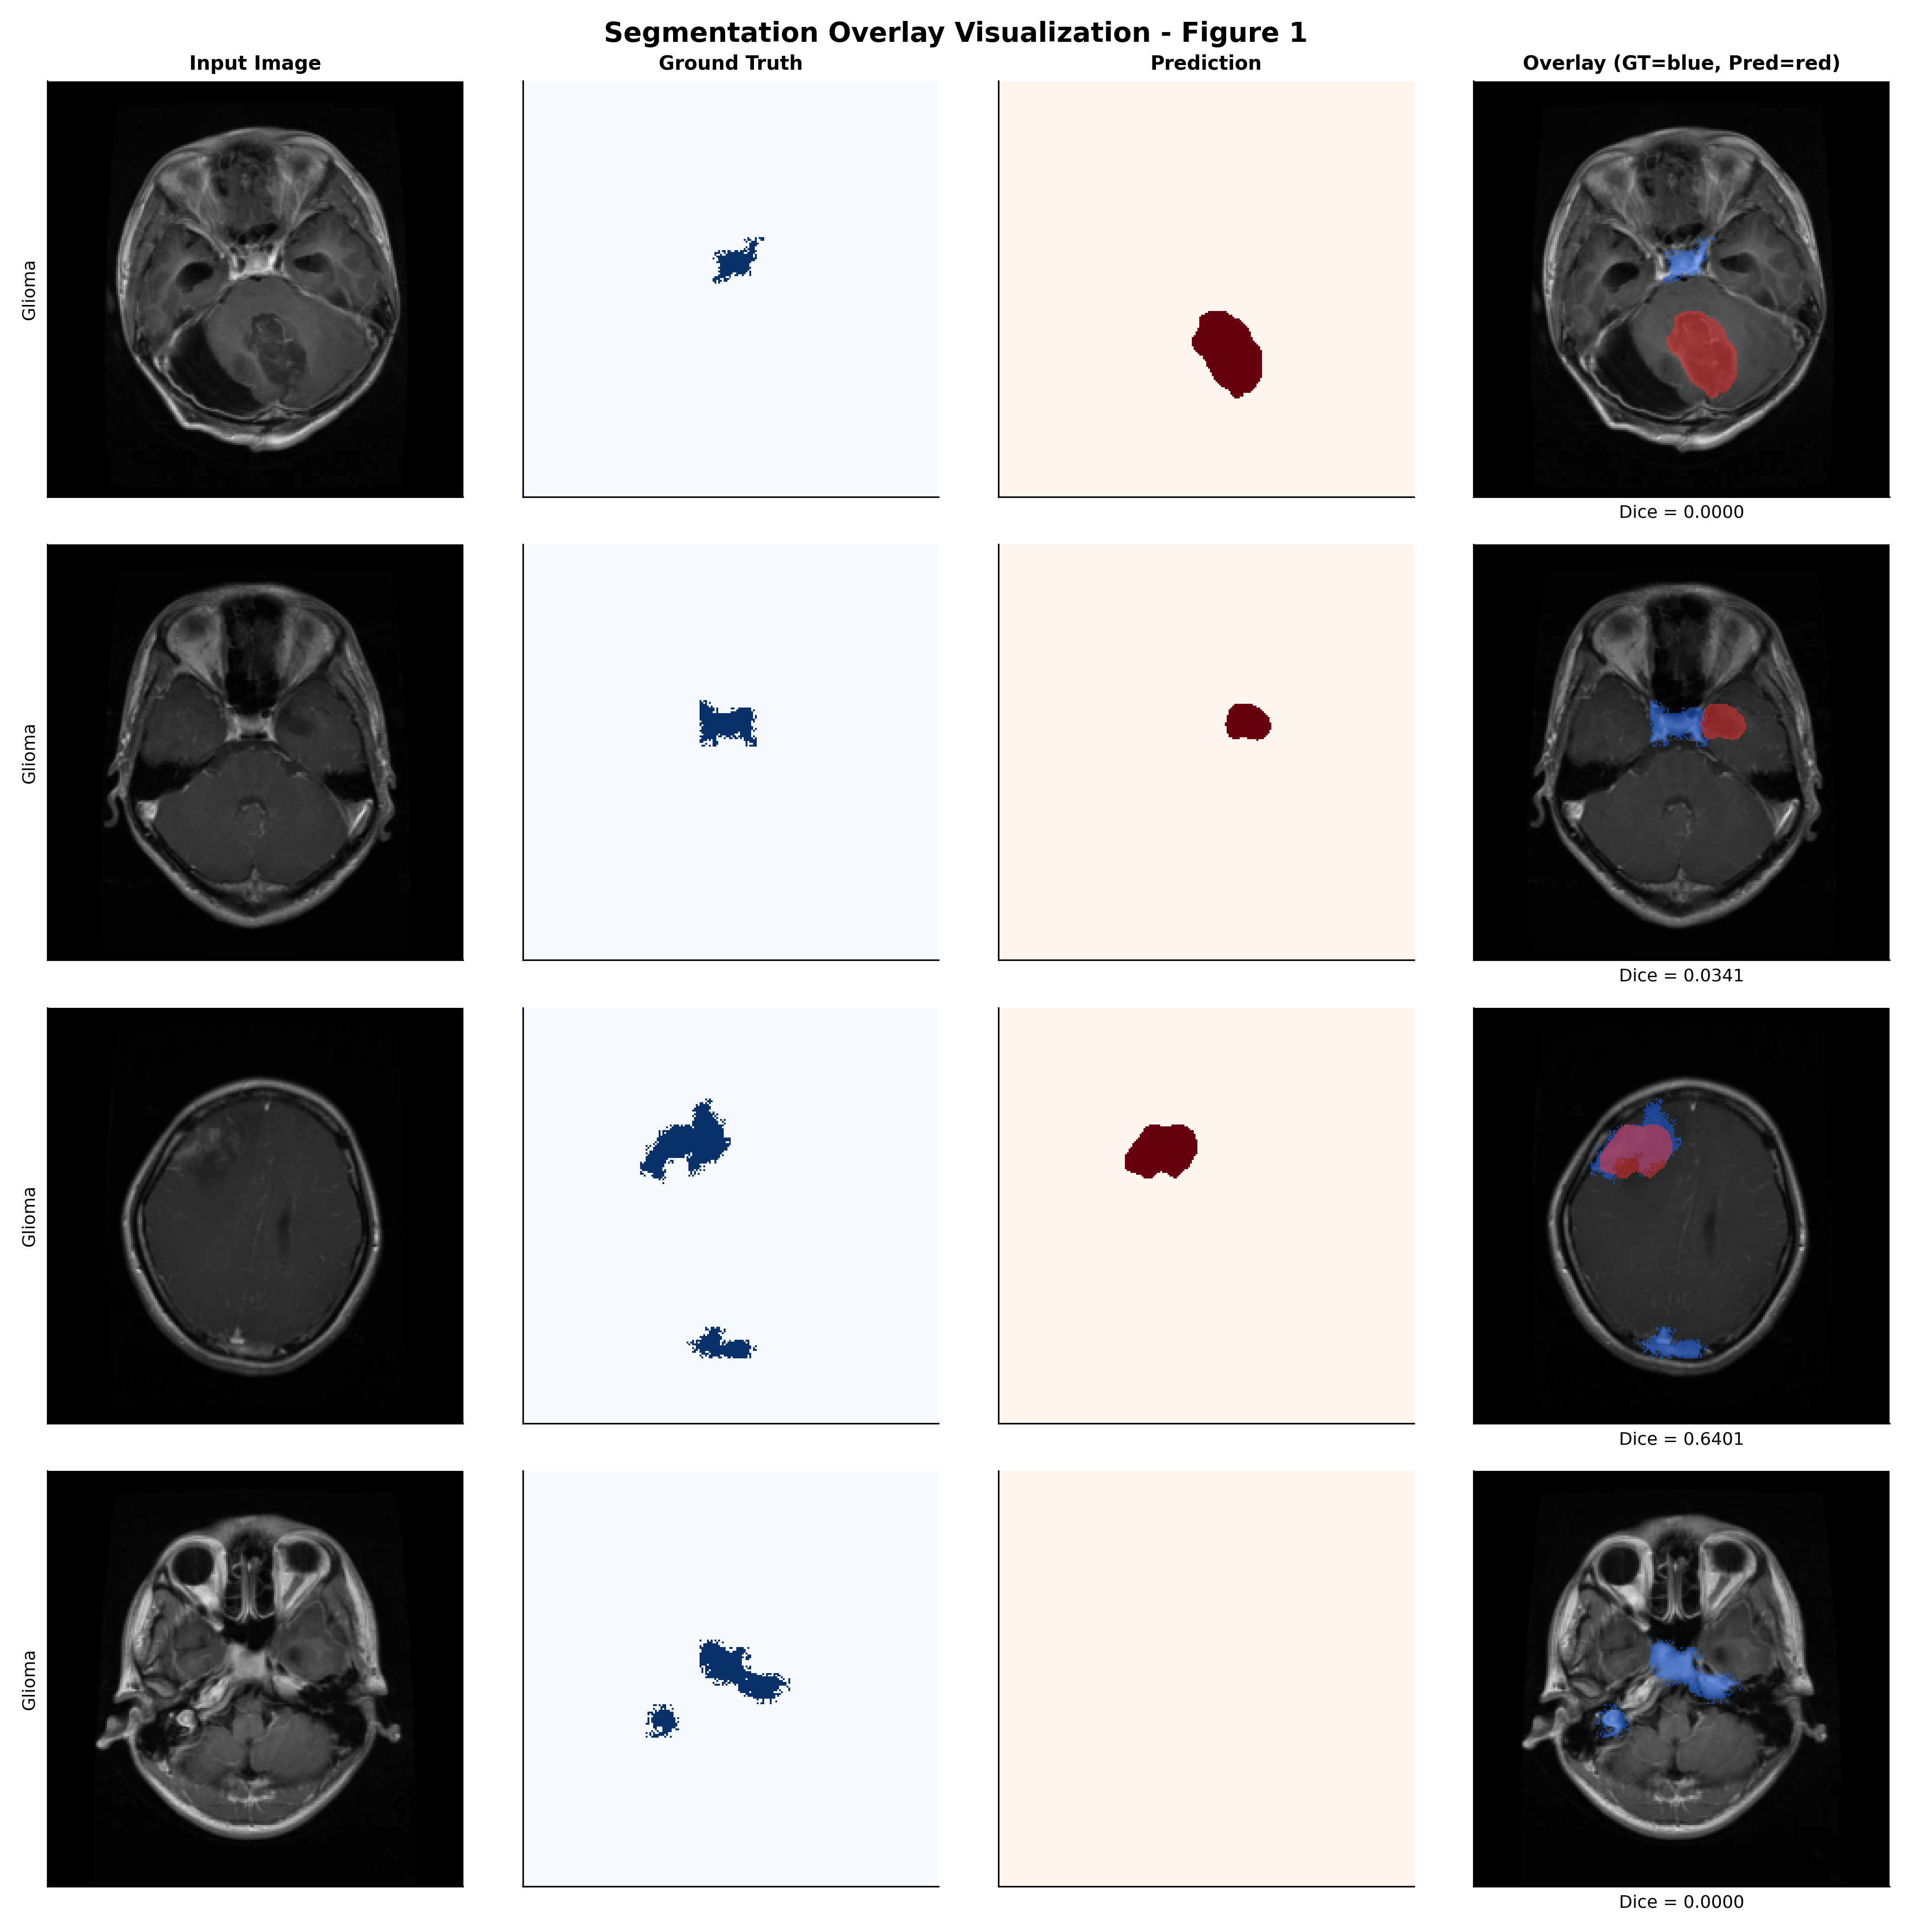

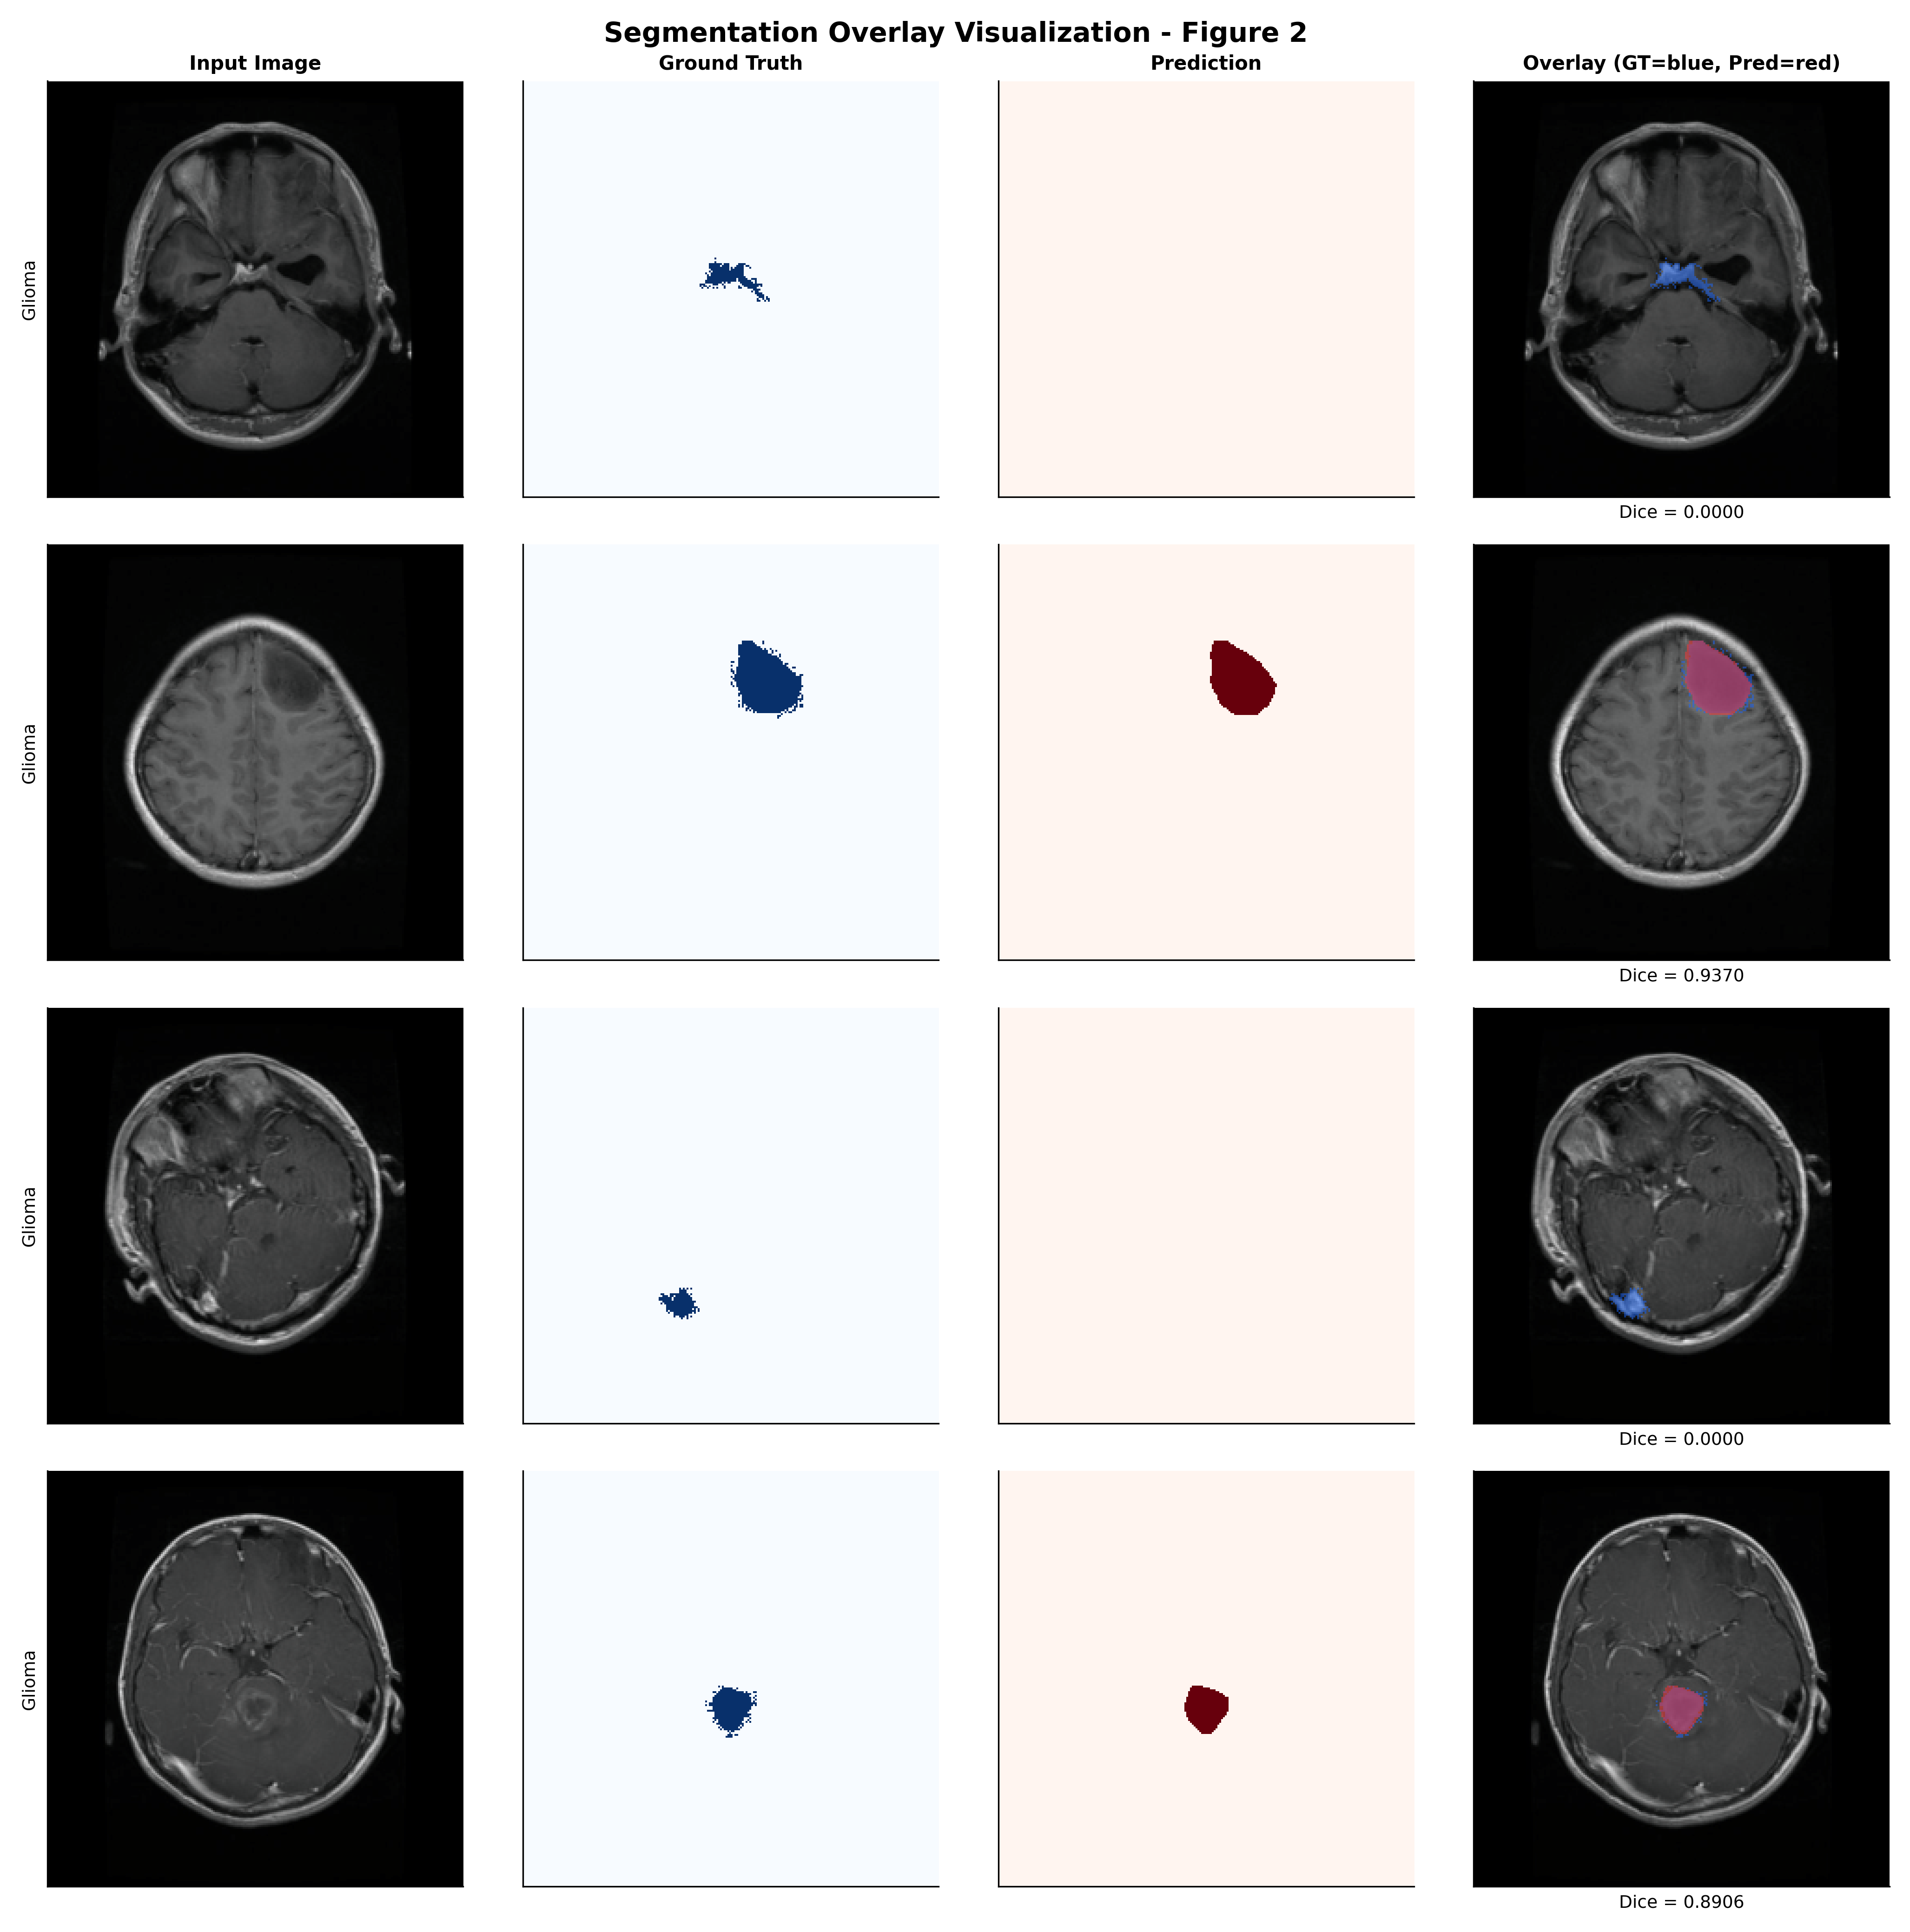

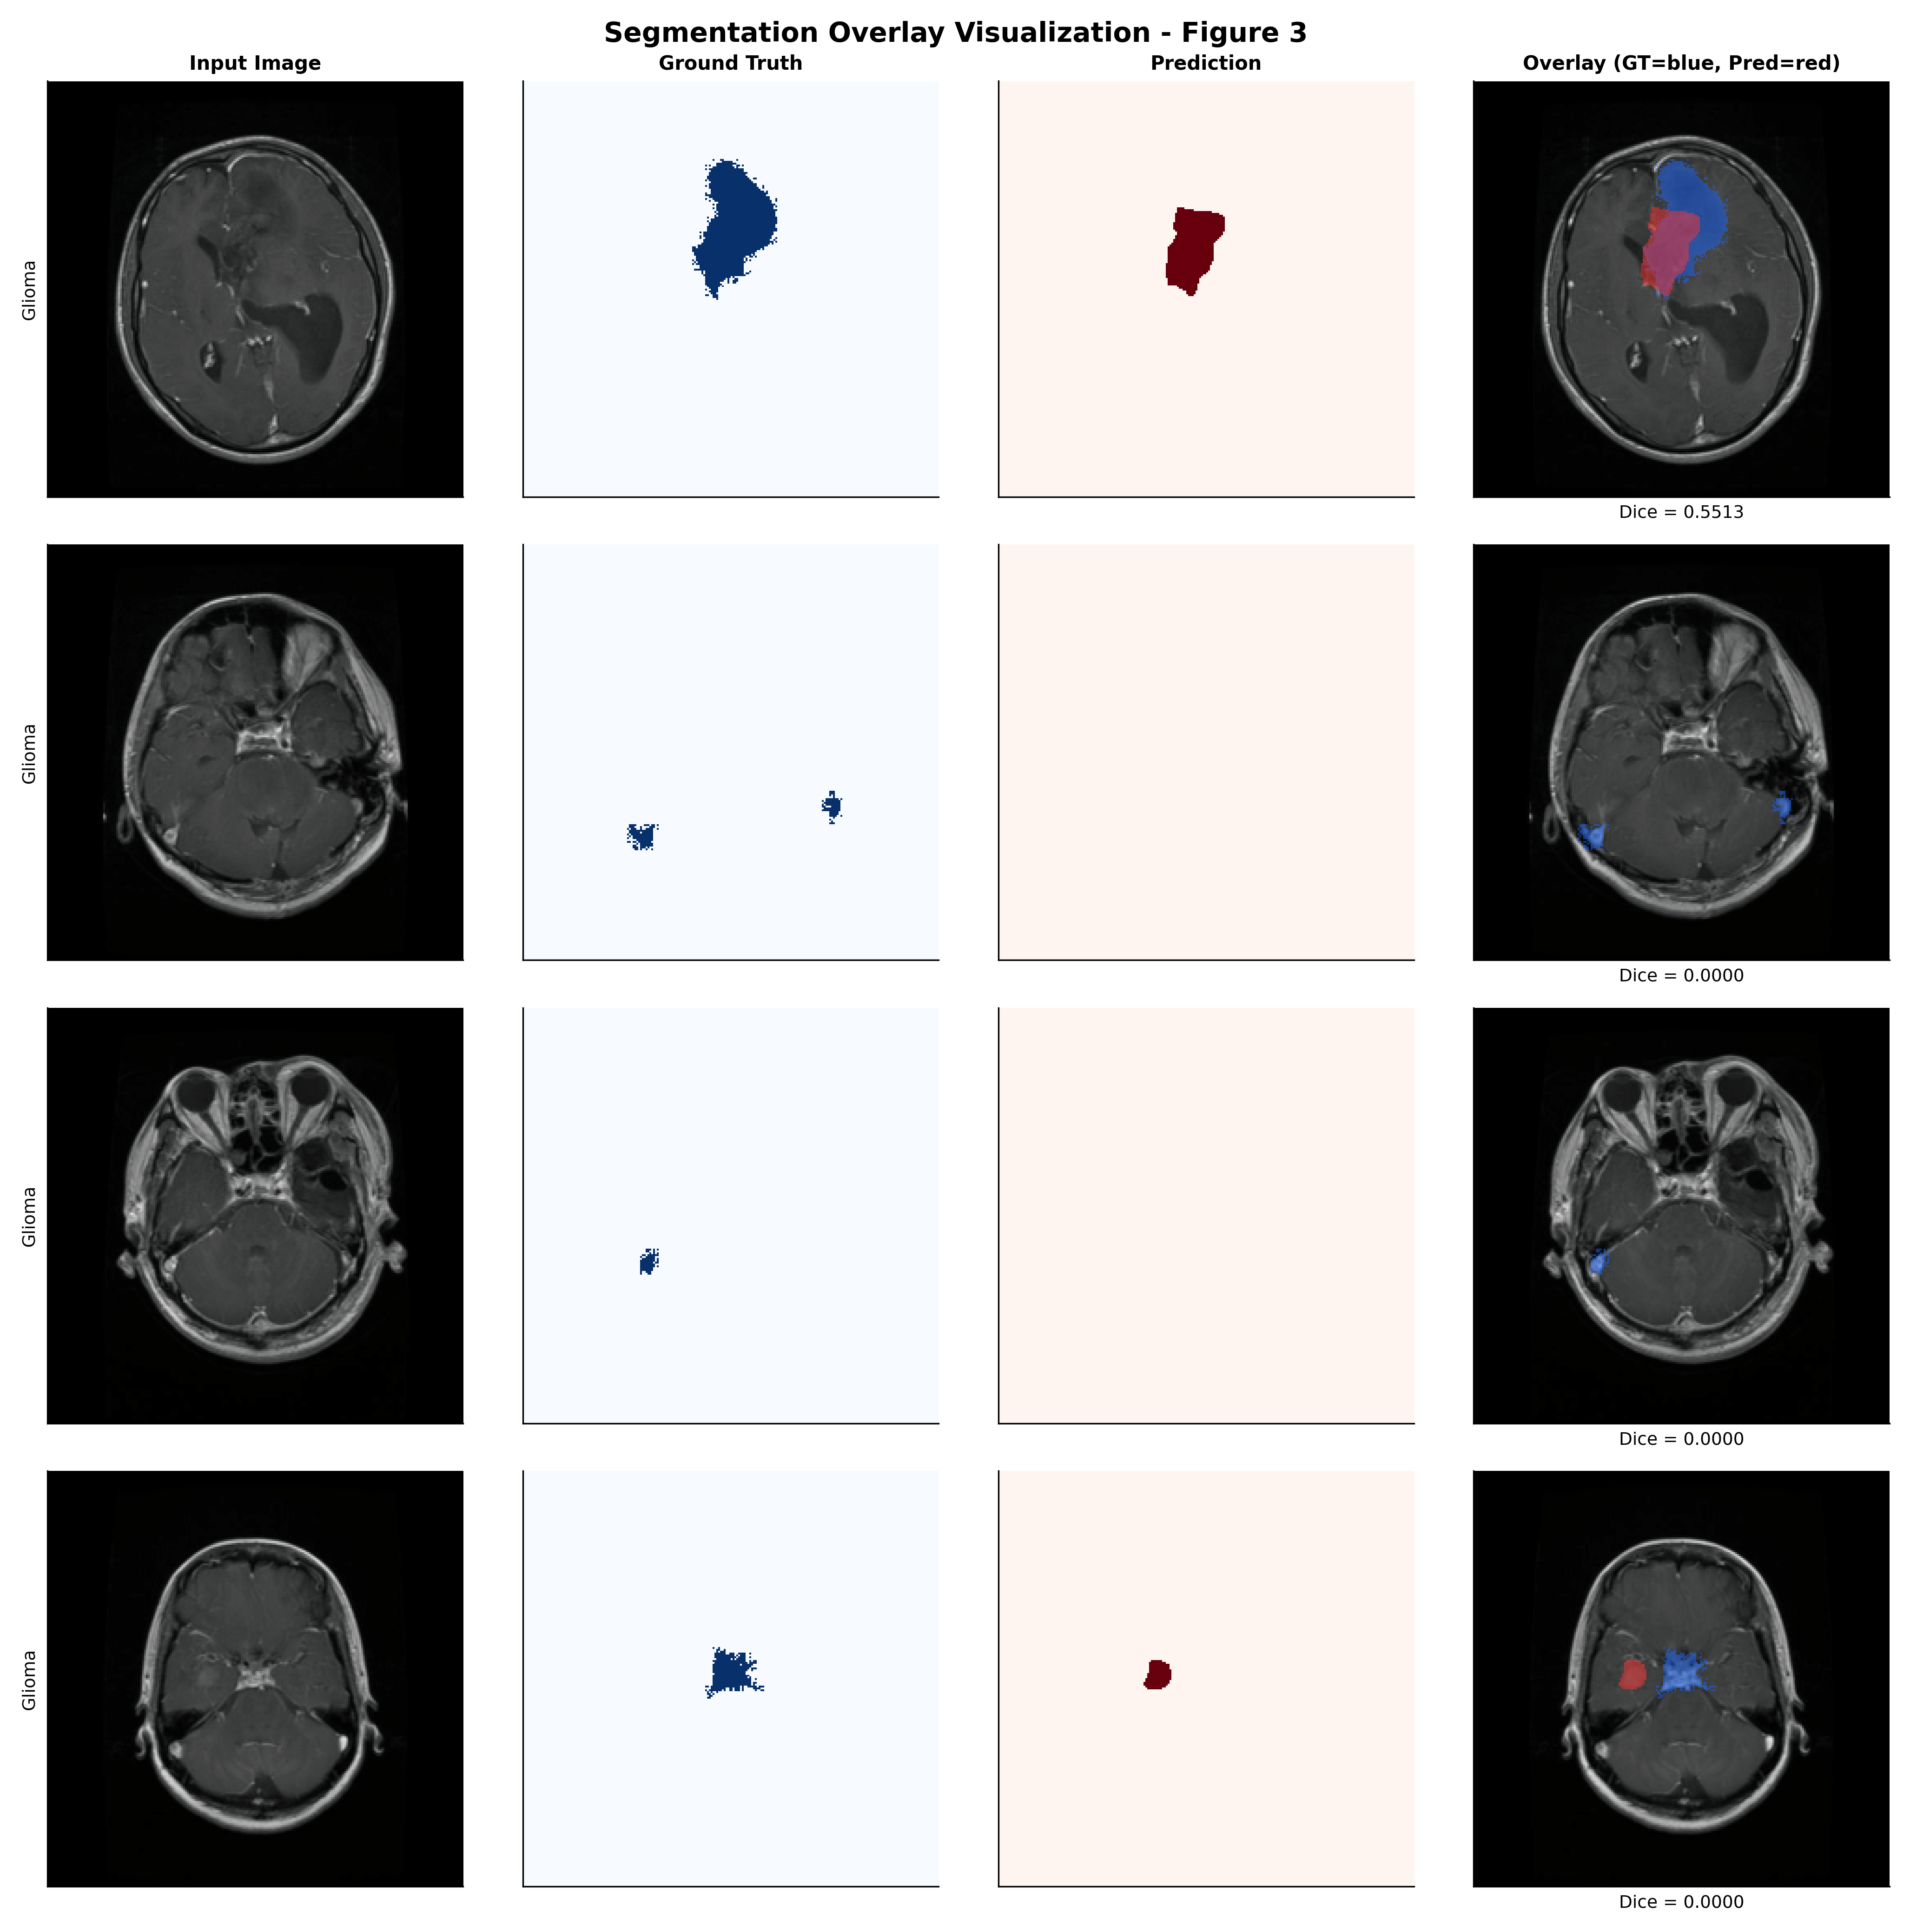

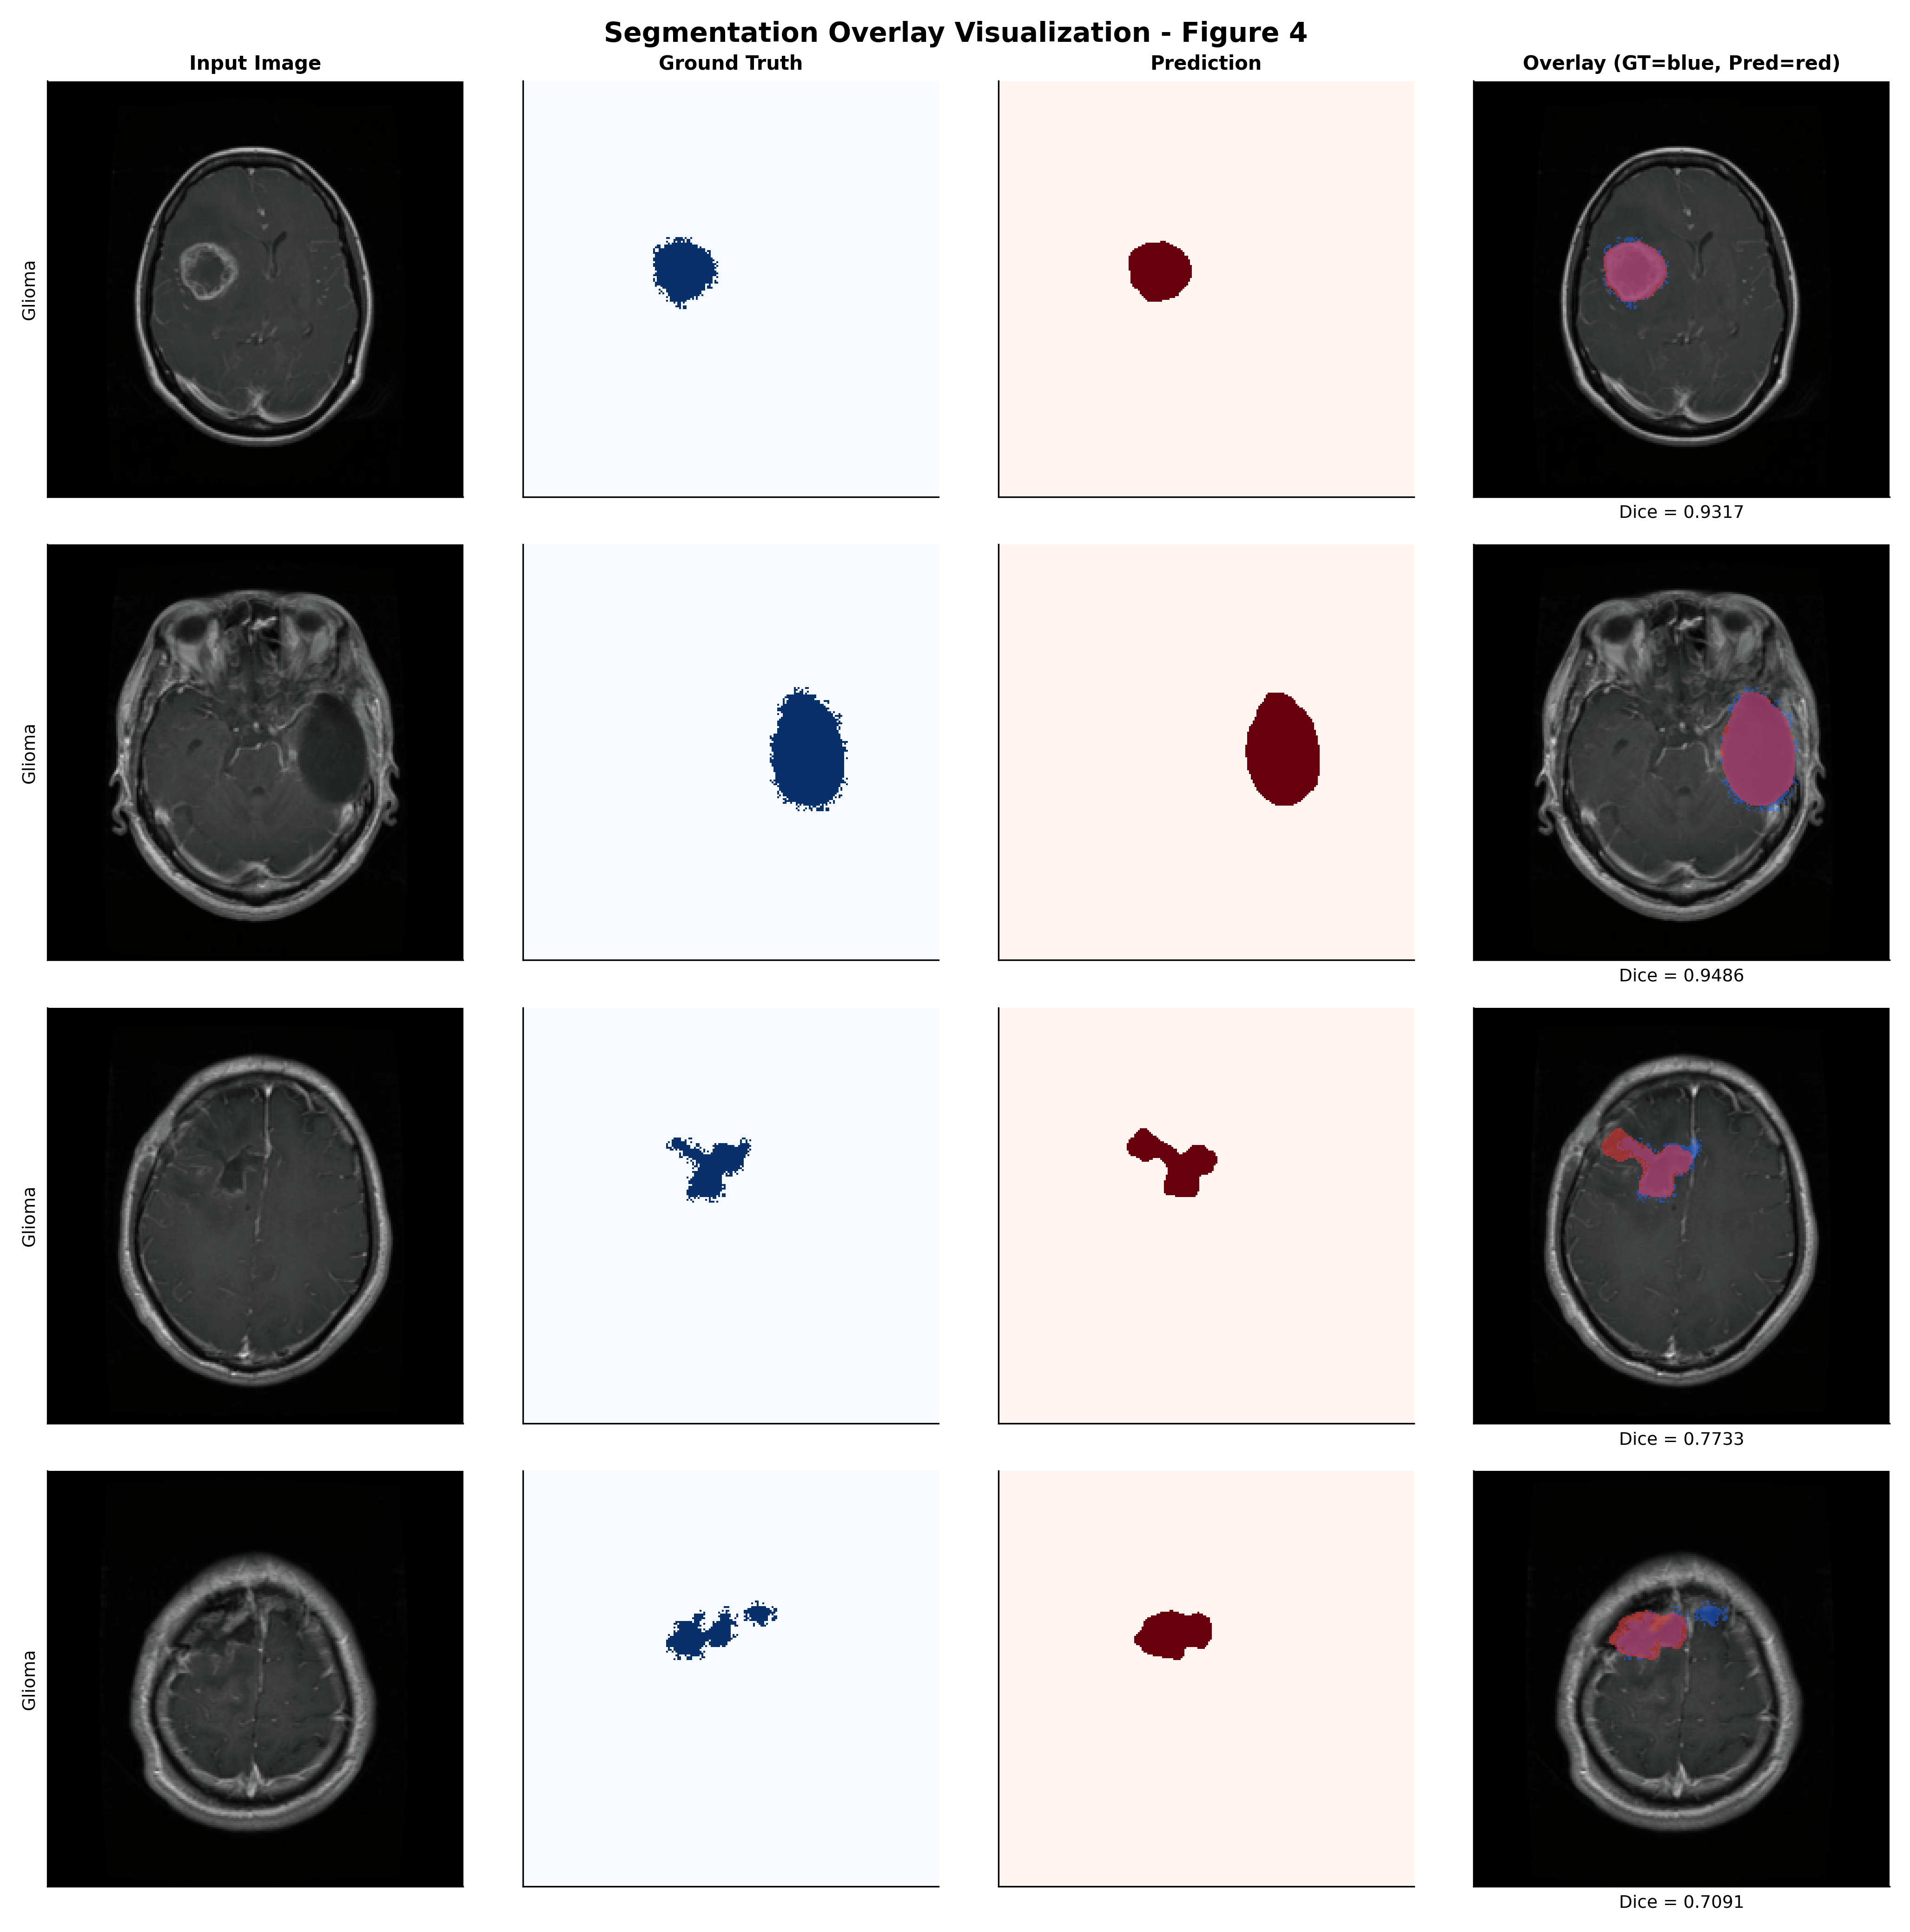

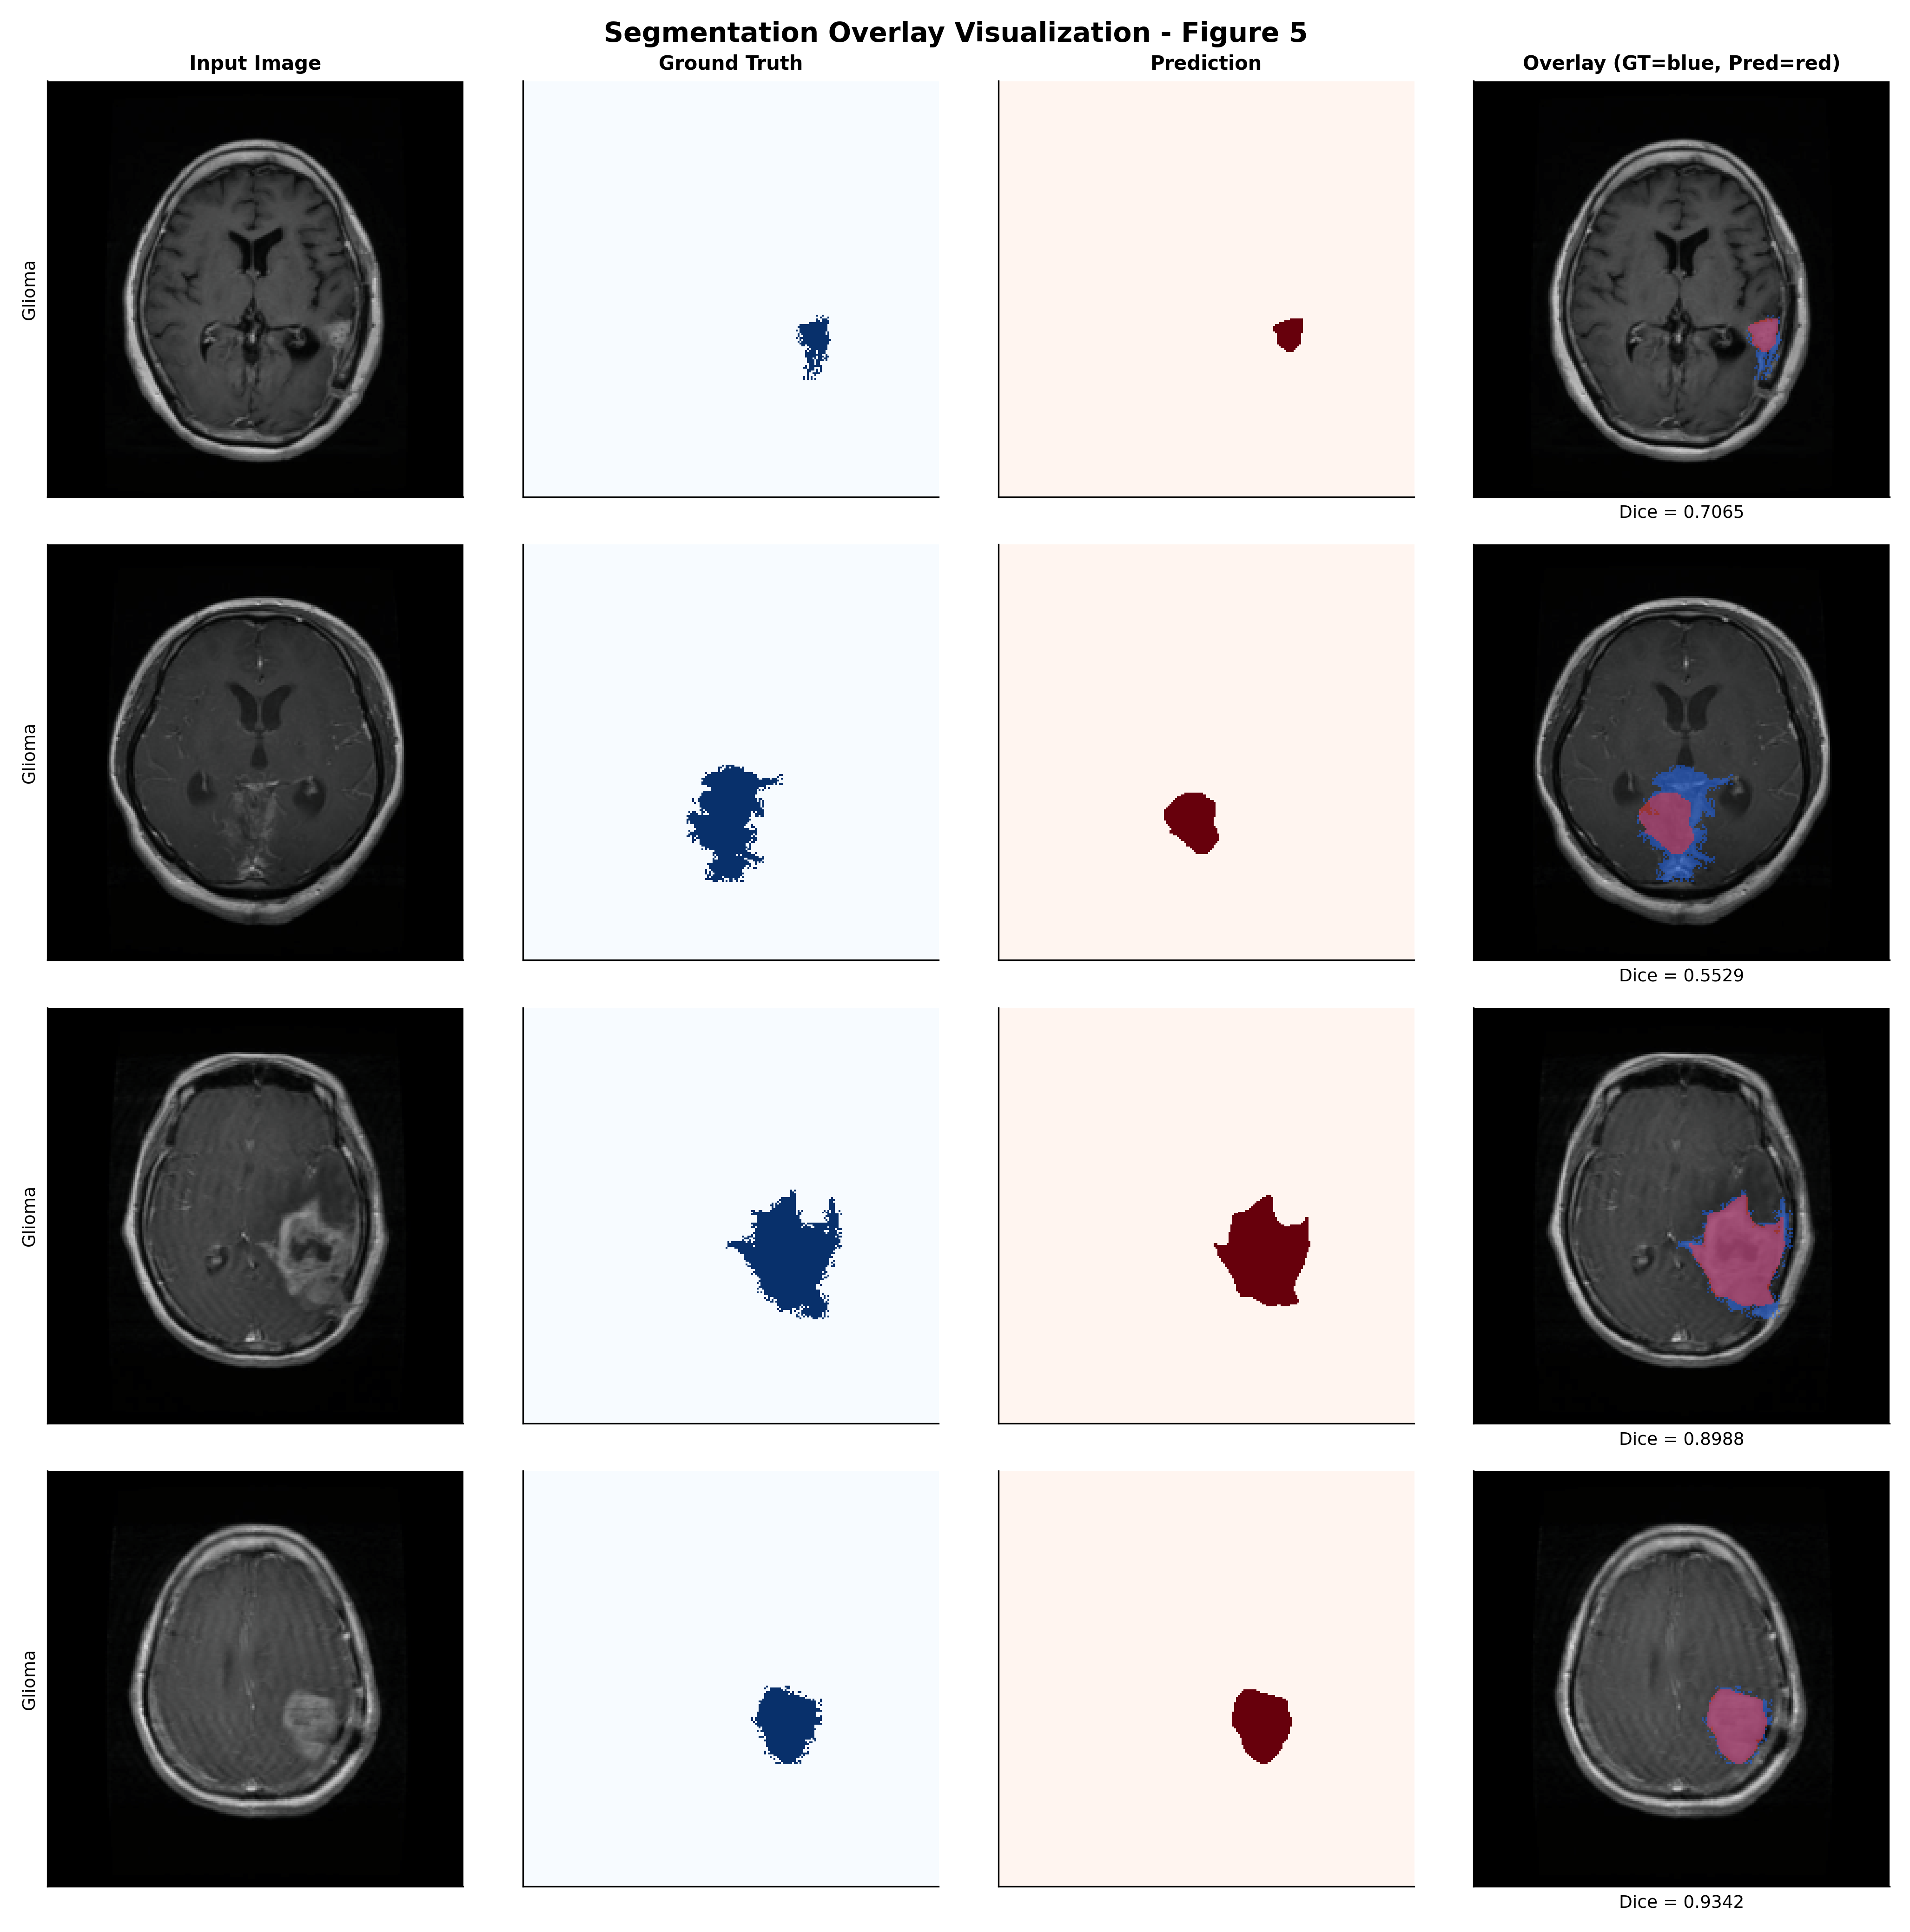

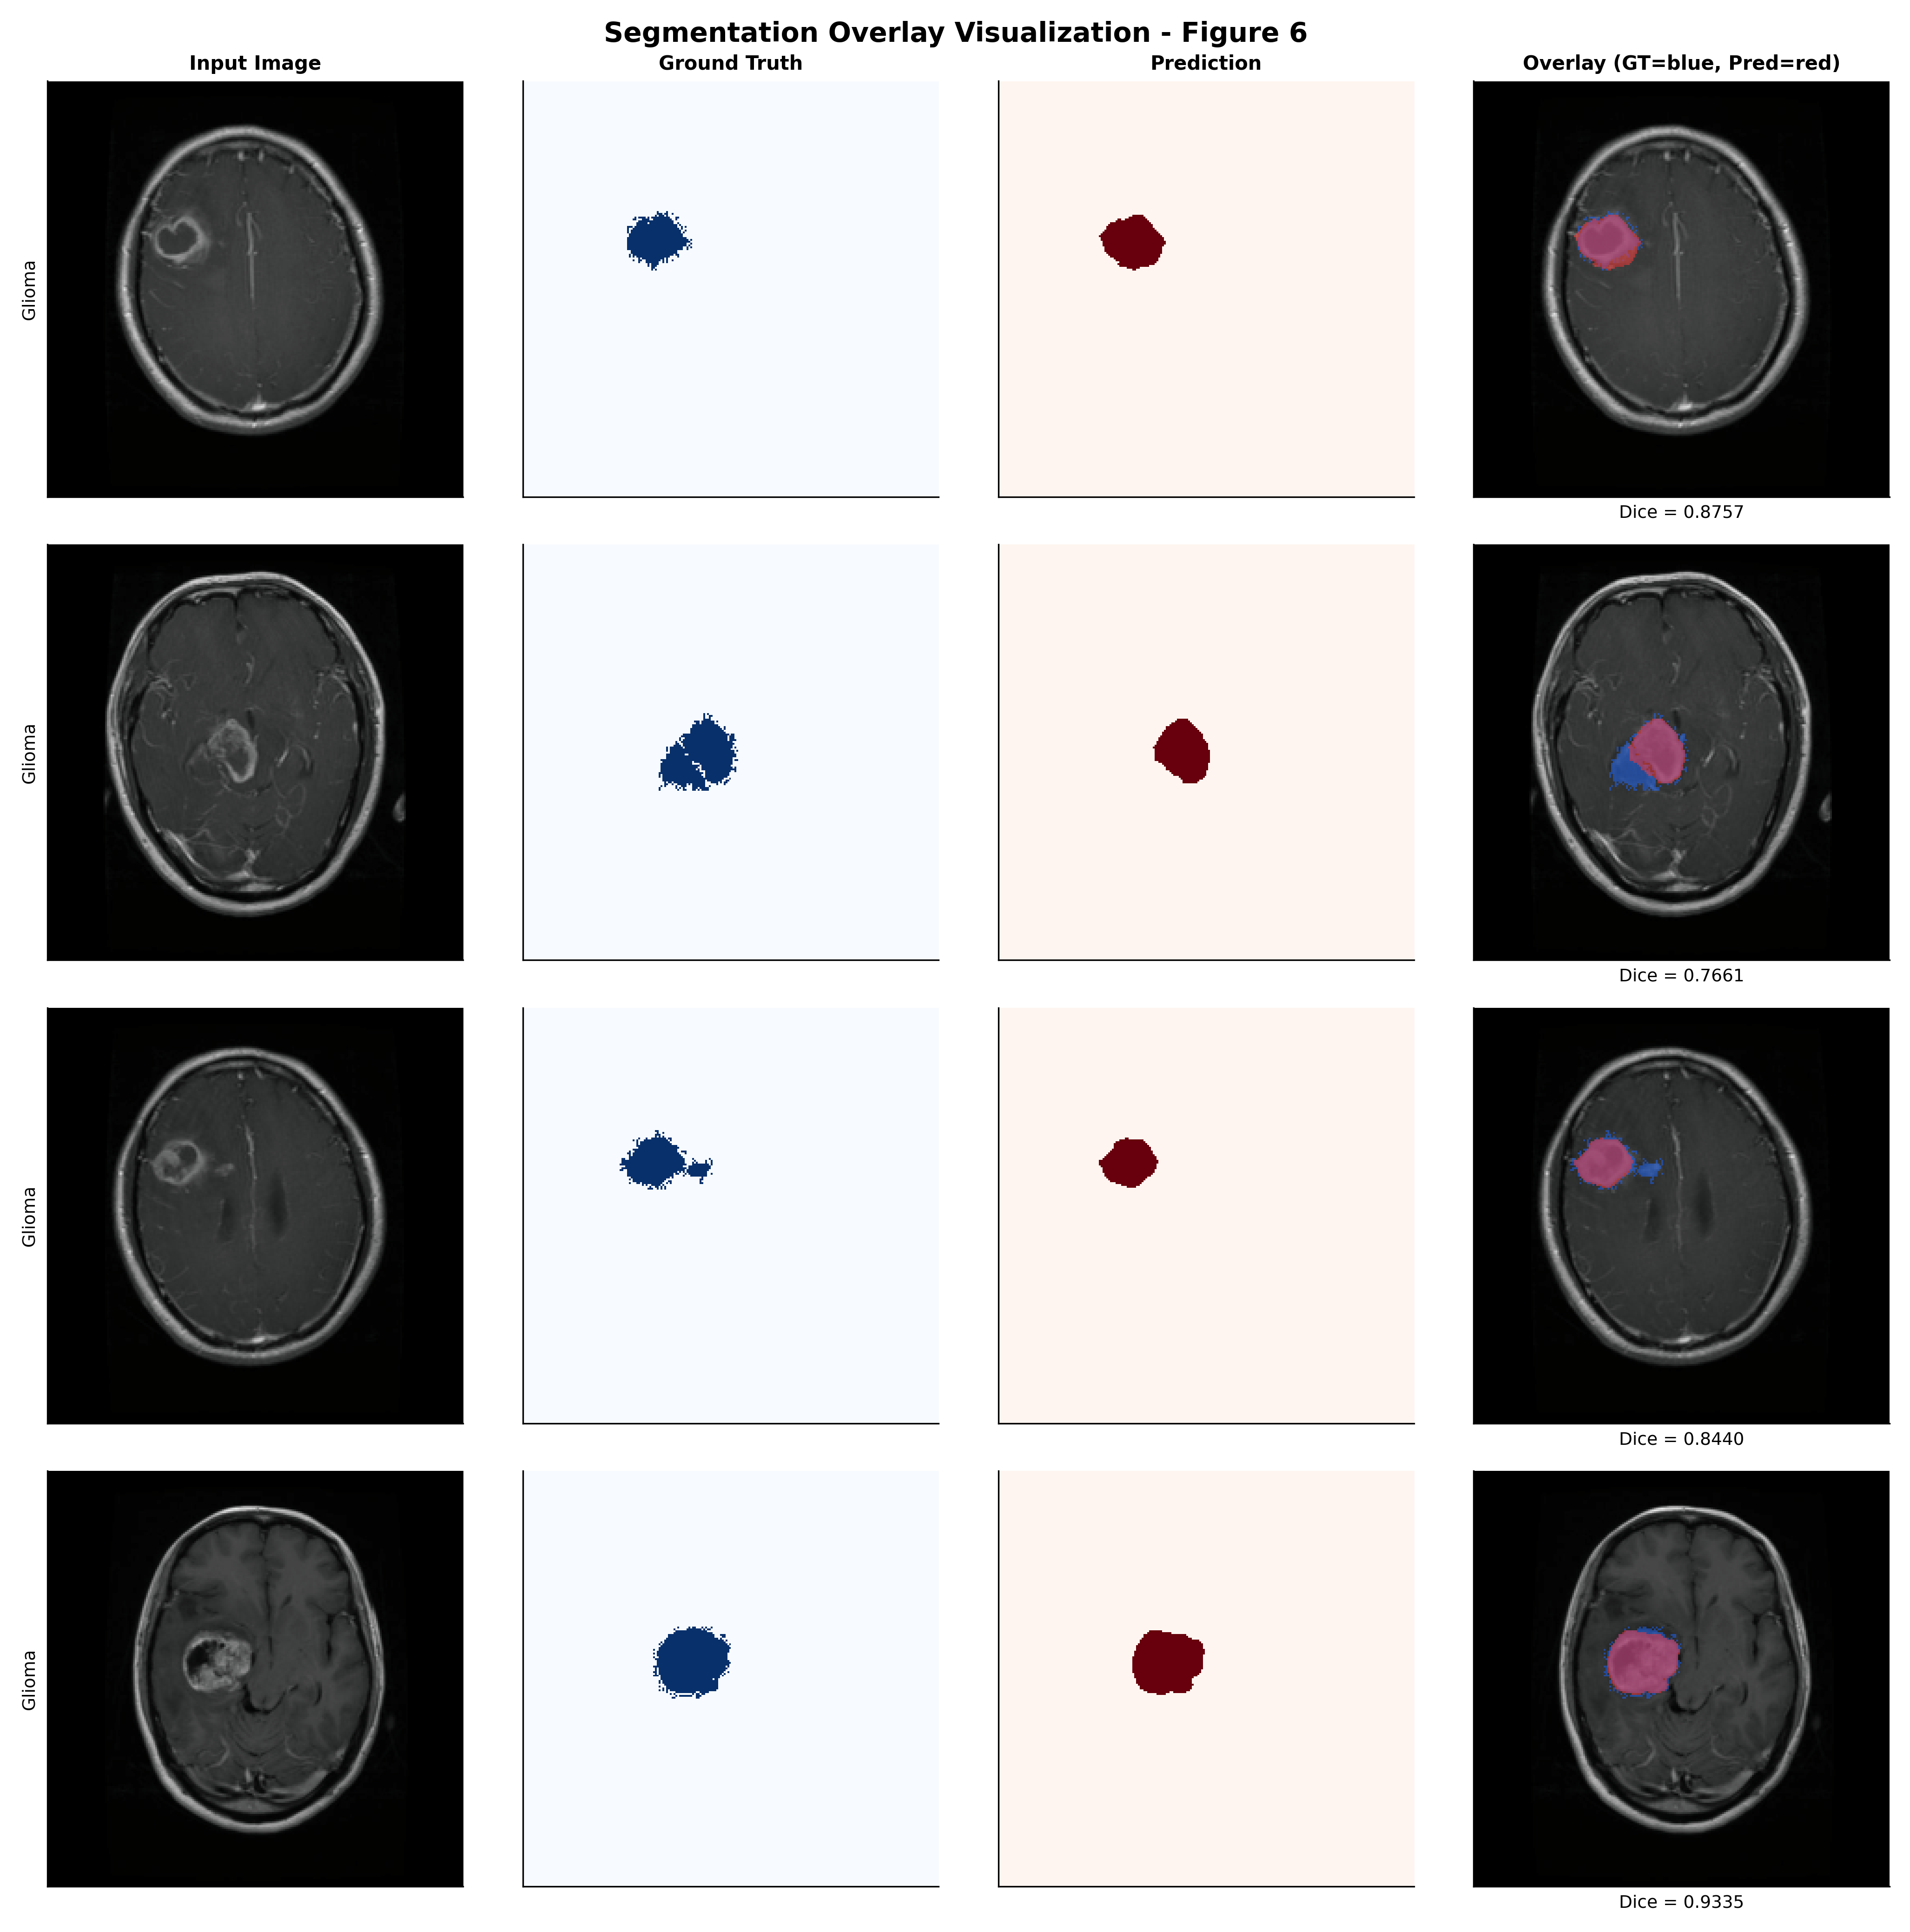

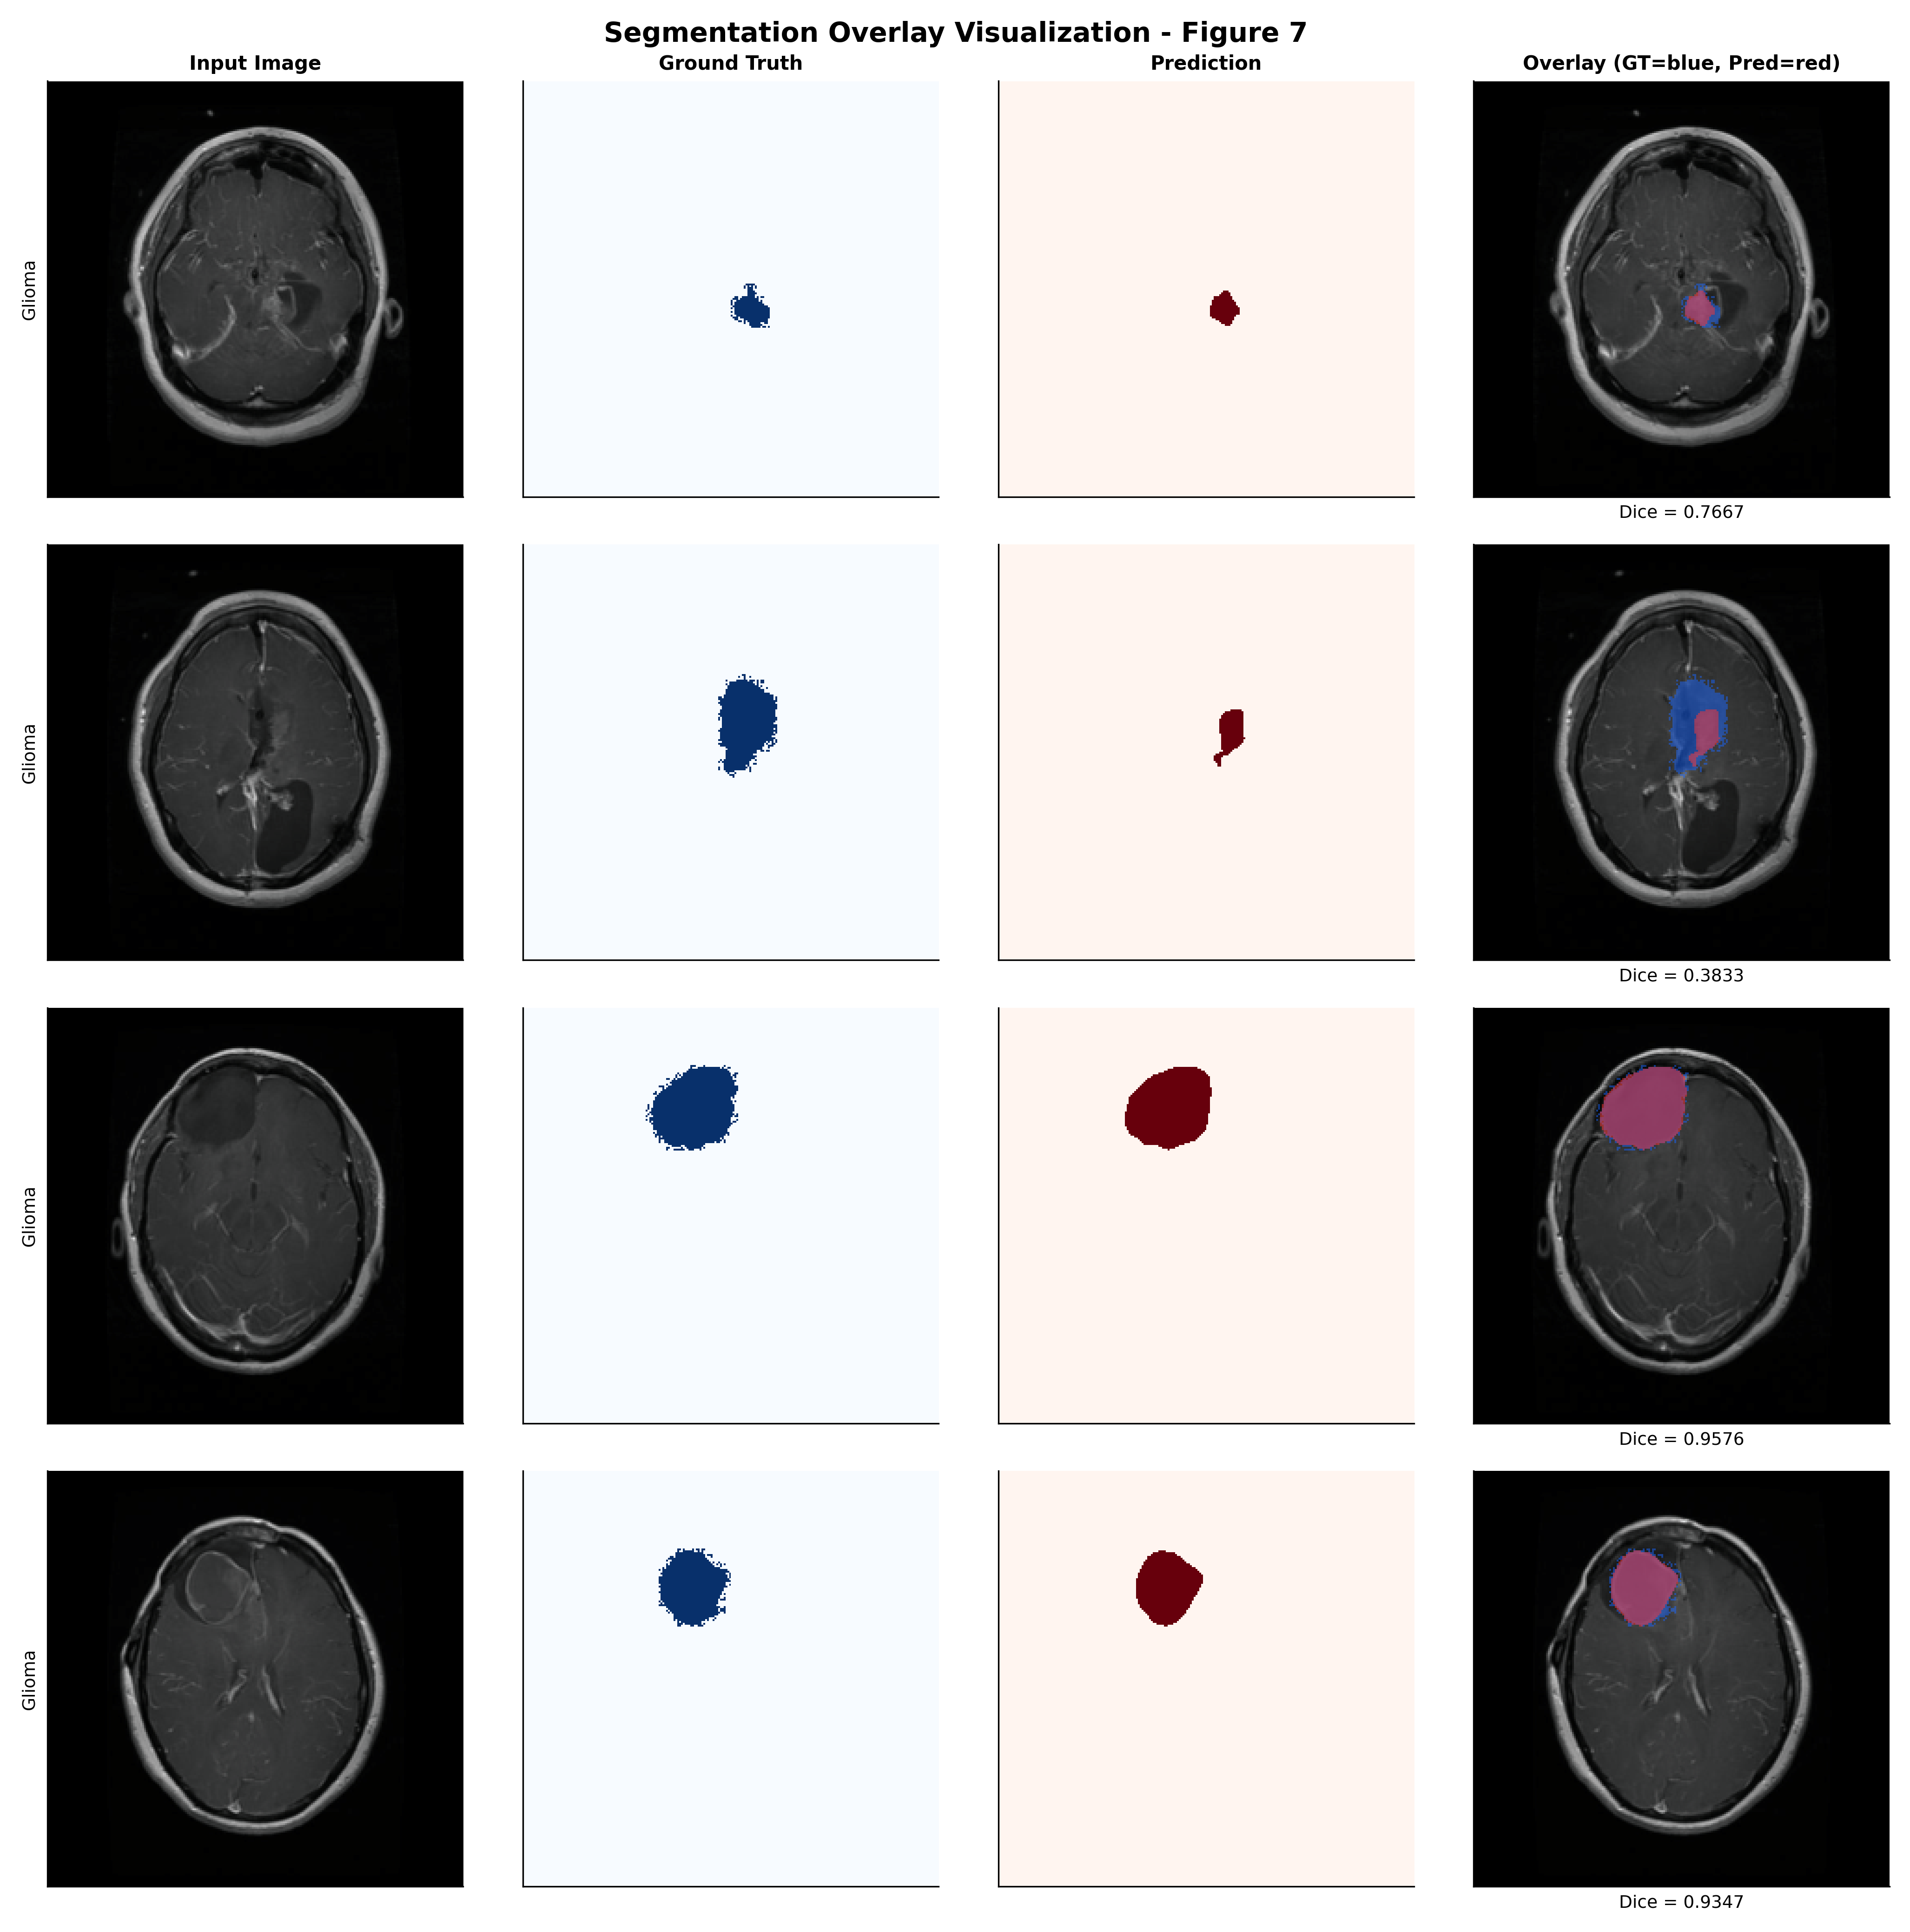

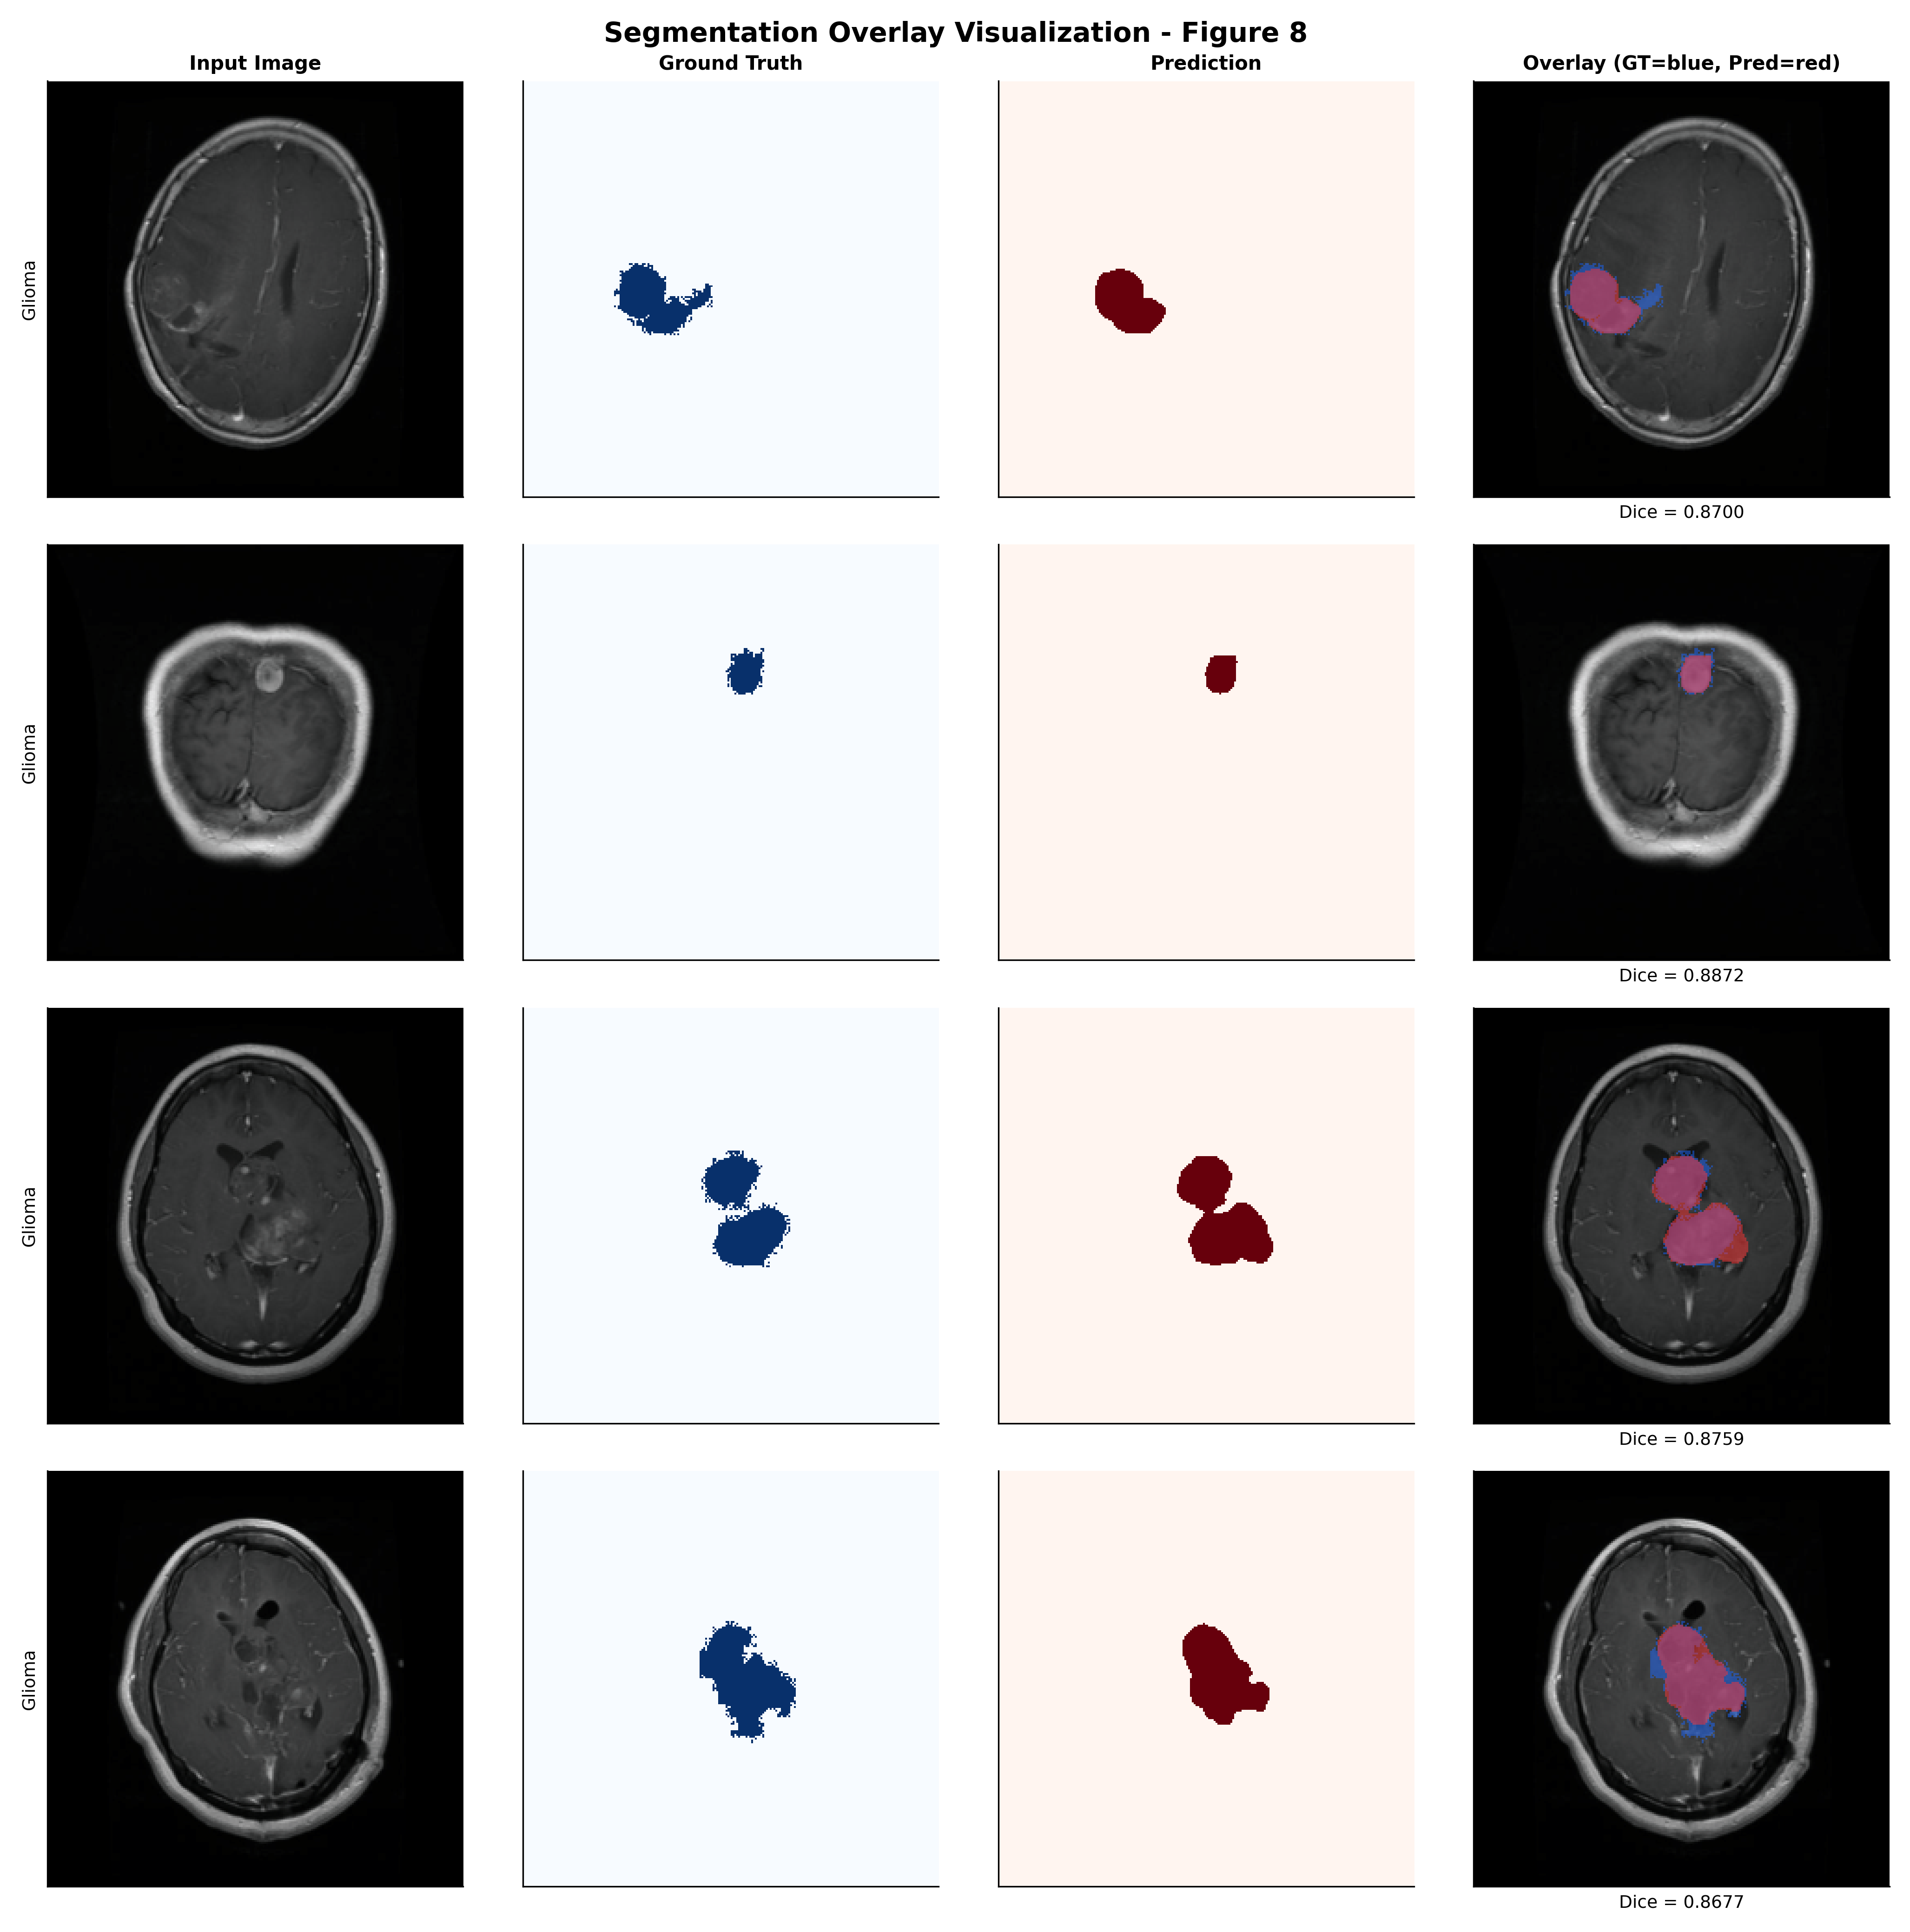

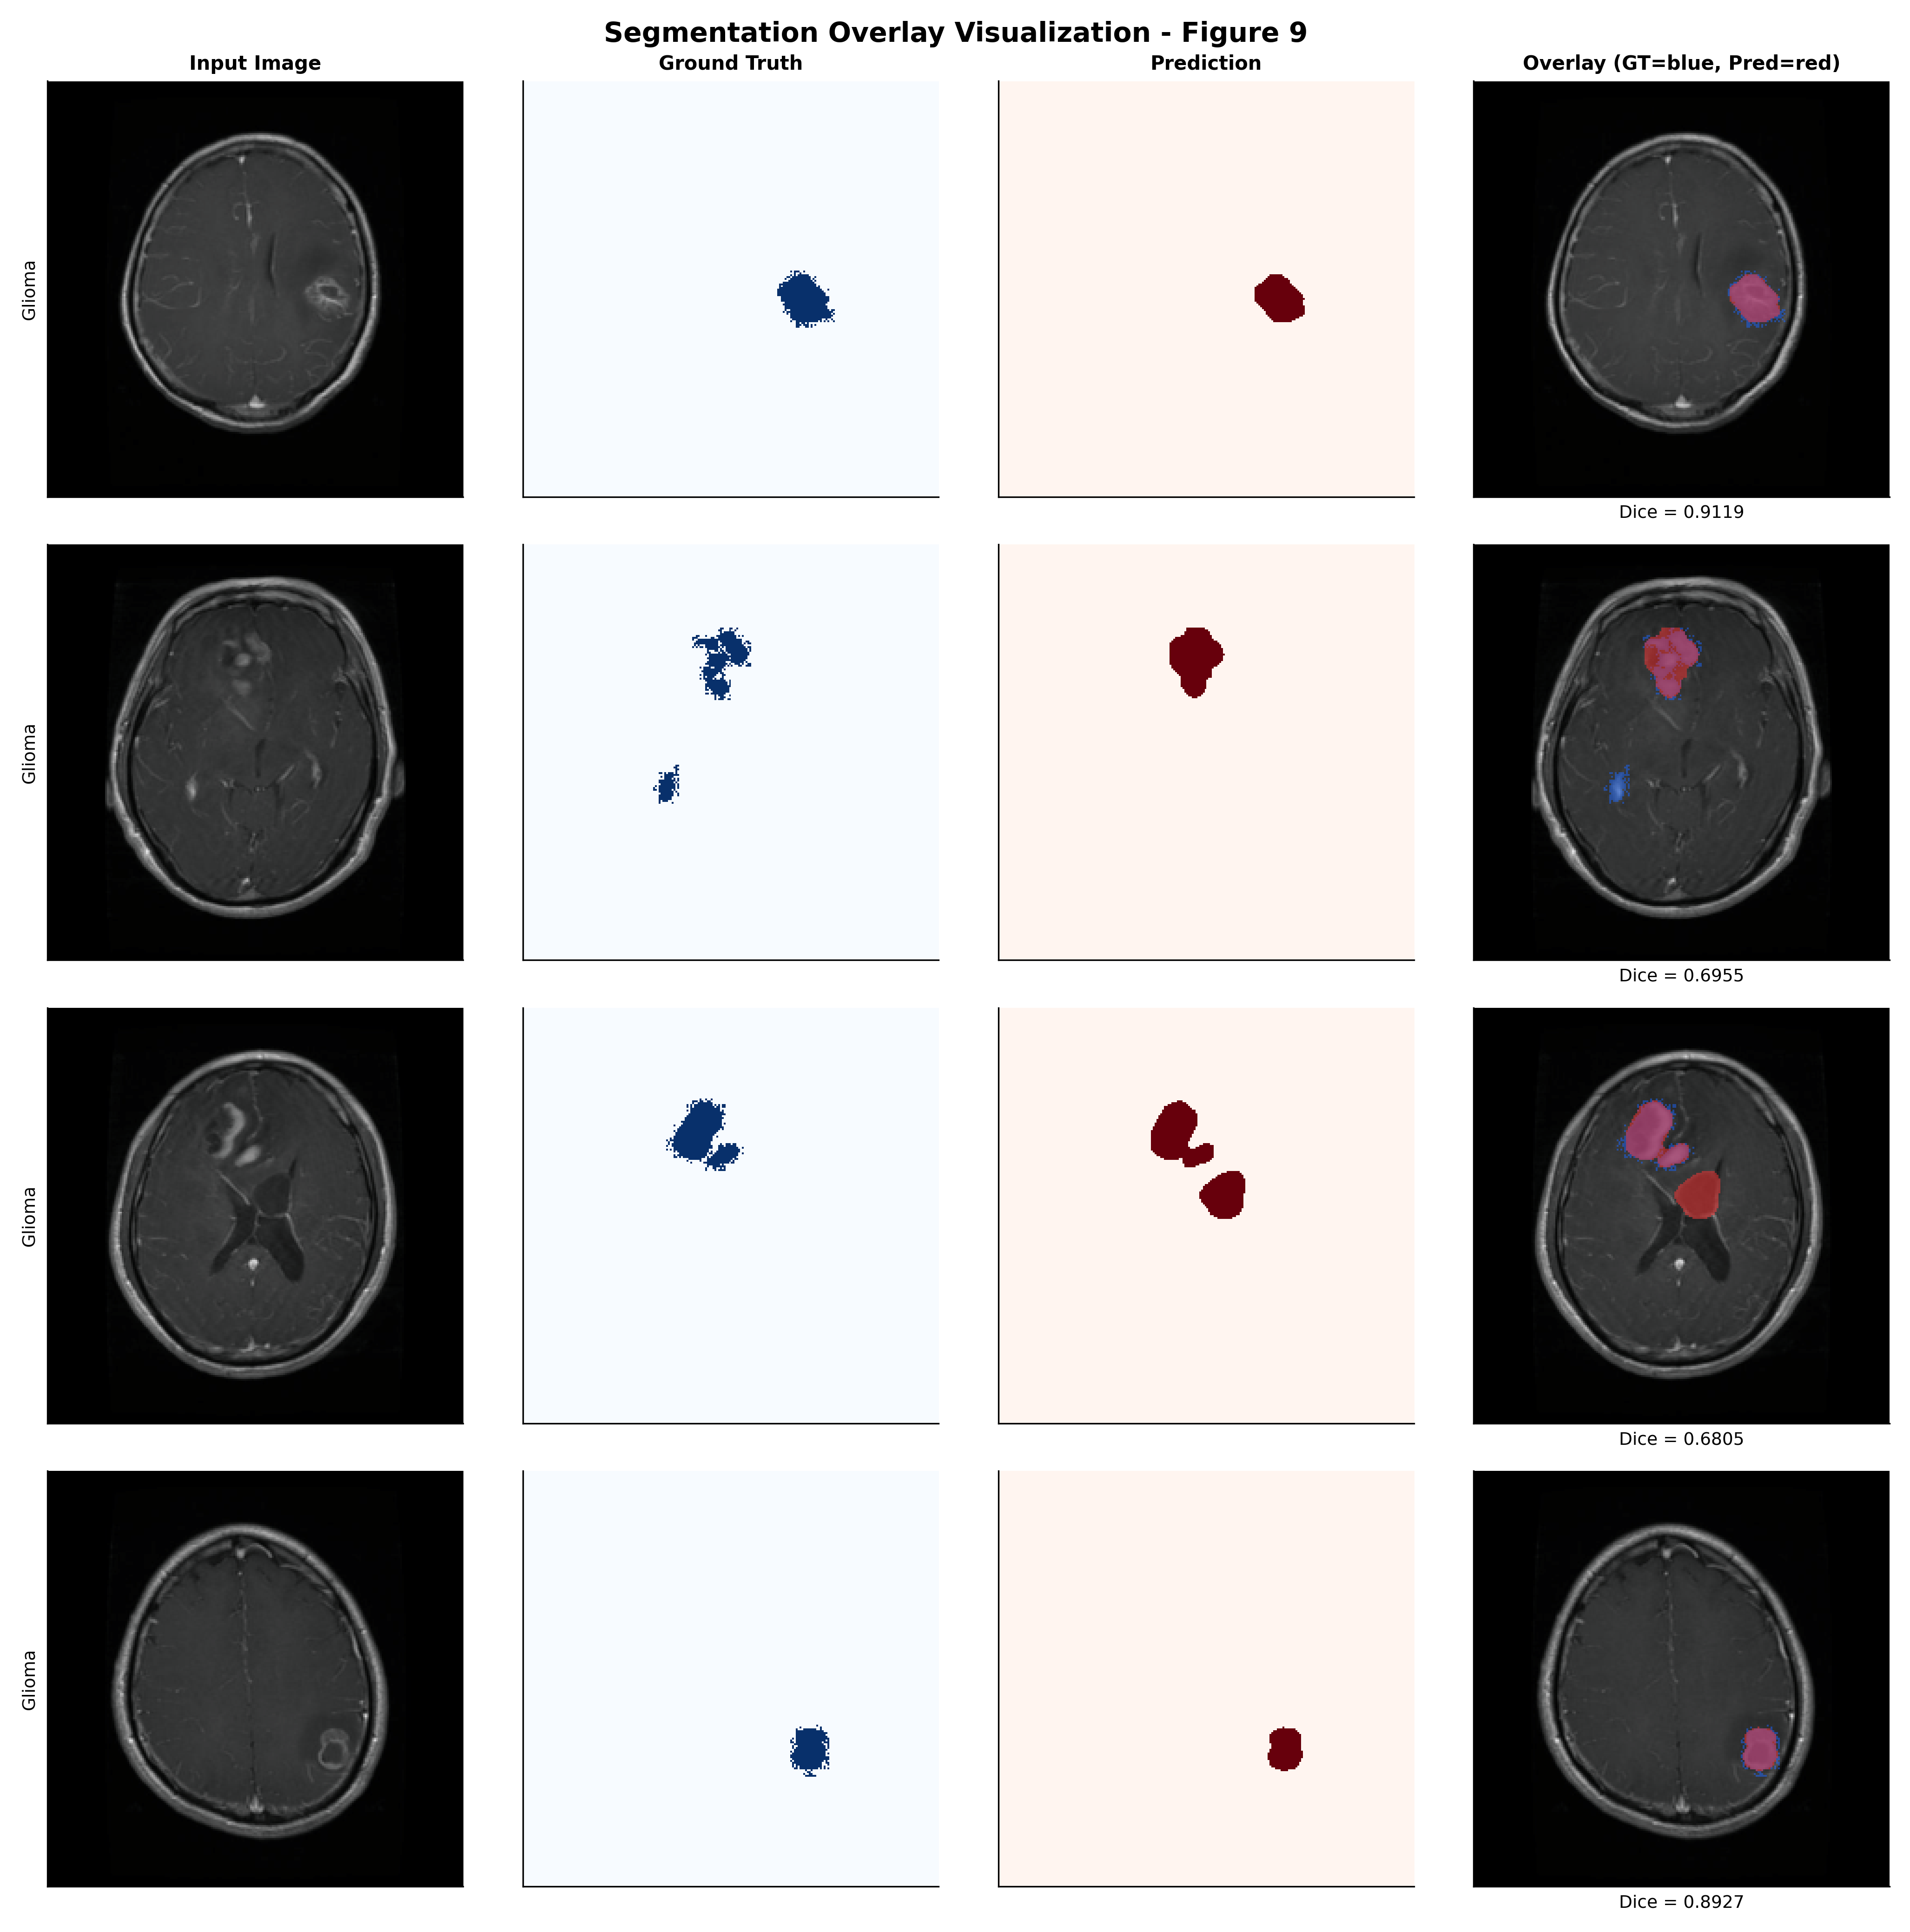

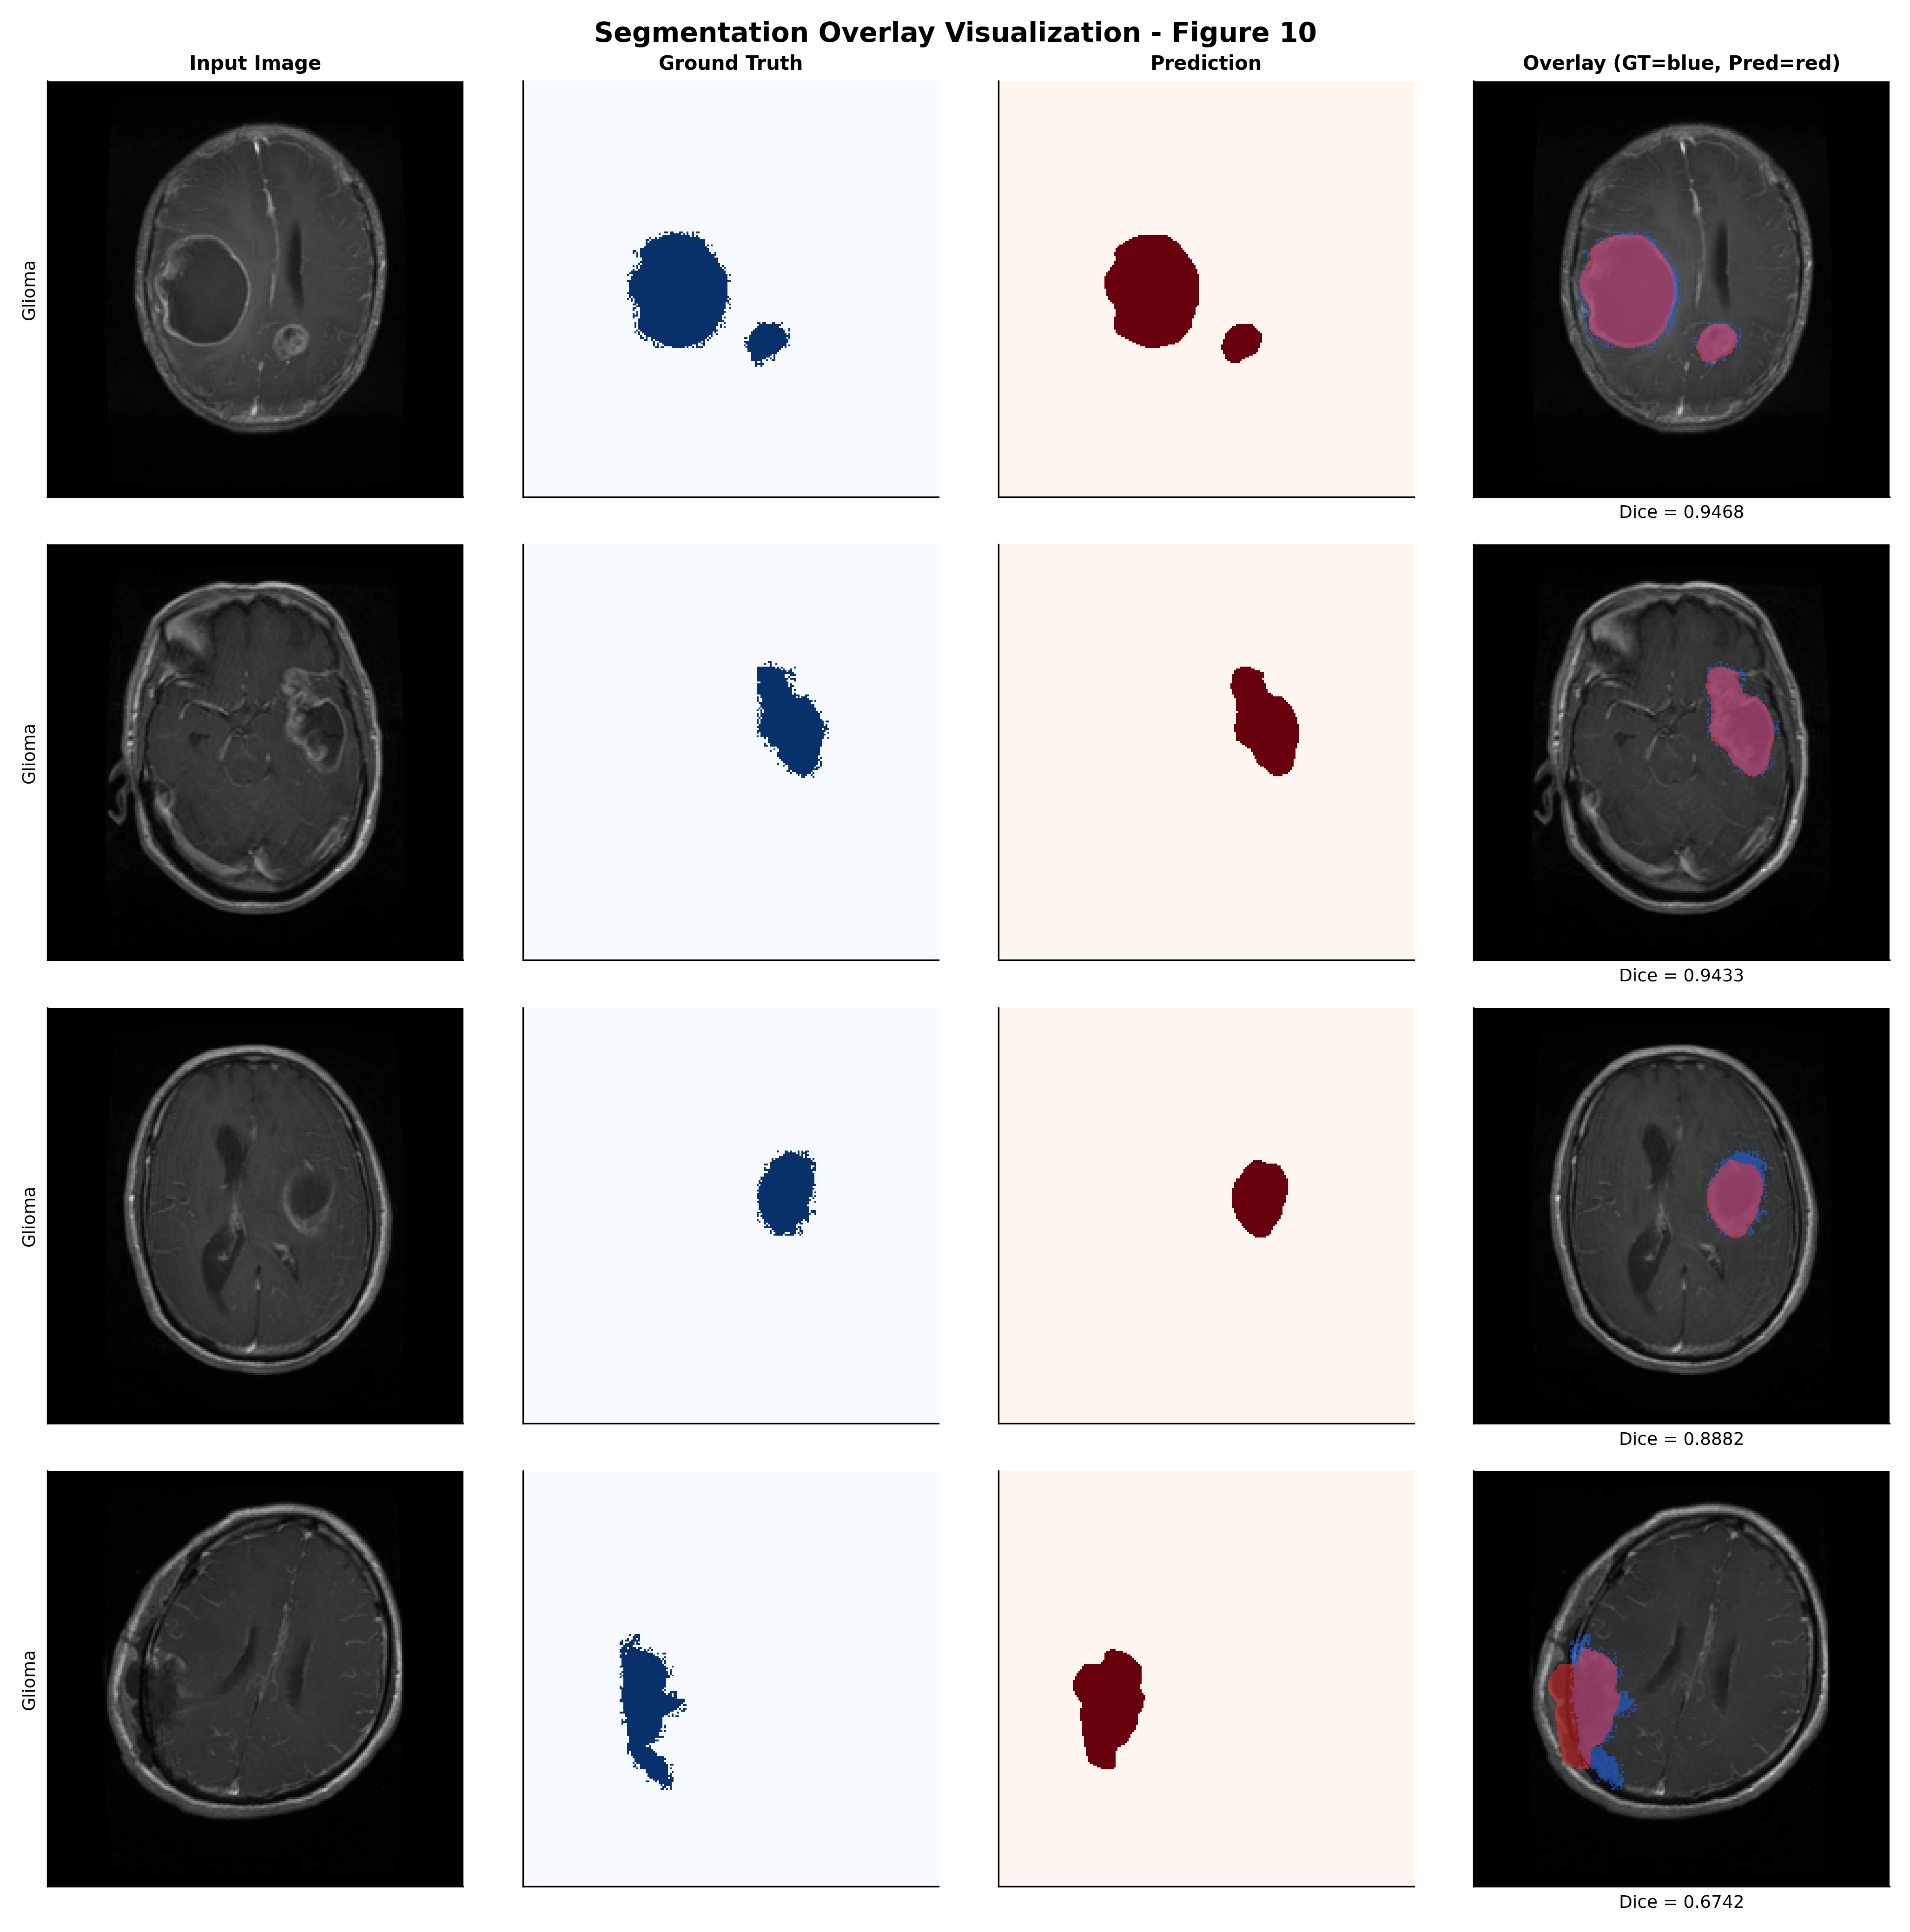

In [16]:
# ============================================================
# GENERATE 10 SEPARATE SEGMENTATION FIGURES
# Each figure = 4 cases like your screenshot
# Total figures = 10
# Total samples used = 40
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# Fix Image conflict problem
from PIL import Image as PILImage
Image = PILImage

from IPython.display import Image as IPyImage, display

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
NUM_FIGURES = 10
SAMPLES_PER_FIGURE = 4
TOTAL_SAMPLES = NUM_FIGURES * SAMPLES_PER_FIGURE

# Collect 40 samples for 10 figures
seg_samples_many = collect_seg_predictions(
    seg_test_loader,
    max_samples=TOTAL_SAMPLES,
    model_ref=model
)

print(f"Collected {len(seg_samples_many)} segmentation samples.")

# ------------------------------------------------------------
# Function: one figure with 4 rows like your screenshot
# ------------------------------------------------------------
def save_seg_overlay_figure(seg_samples, save_path, fig_no):
    n = min(len(seg_samples), SAMPLES_PER_FIGURE)

    if n == 0:
        print(f"No samples for Figure {fig_no}")
        return

    fig, axes = plt.subplots(
        n, 4,
        figsize=(14, 3.5 * n),
        dpi=300
    )

    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = [
        "Input Image",
        "Ground Truth",
        "Prediction",
        "Overlay (GT=blue, Pred=red)"
    ]

    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontweight="bold", fontsize=10)

    for row, (img_np, mask_np, pred_np, dice, lbl) in enumerate(seg_samples[:n]):

        # Input image
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_ylabel(
            DISPLAY_NAMES[lbl] if 0 <= lbl < NUM_CLASSES else "Unknown",
            fontsize=9,
            rotation=90,
            labelpad=5
        )

        # Ground truth
        axes[row, 1].imshow(mask_np, cmap="Blues", vmin=0, vmax=1)

        # Prediction
        axes[row, 2].imshow(pred_np, cmap="Reds", vmin=0, vmax=1)

        # Overlay
        gt_rgba = np.zeros((*mask_np.shape, 4))
        gt_rgba[mask_np > 0.5] = [0.1, 0.4, 1.0, 0.50]

        pr_rgba = np.zeros((*pred_np.shape, 4))
        pr_rgba[pred_np > 0.5] = [1.0, 0.2, 0.2, 0.50]

        axes[row, 3].imshow(img_np)
        axes[row, 3].imshow(gt_rgba)
        axes[row, 3].imshow(pr_rgba)
        axes[row, 3].set_xlabel(f"Dice = {dice:.4f}", fontsize=9)

    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(
        f"Segmentation Overlay Visualization - Figure {fig_no}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {save_path}")


# ------------------------------------------------------------
# Generate 10 separate figures
# ------------------------------------------------------------
generated_files = []

for fig_idx in range(NUM_FIGURES):
    start = fig_idx * SAMPLES_PER_FIGURE
    end = start + SAMPLES_PER_FIGURE

    samples_chunk = seg_samples_many[start:end]

    if len(samples_chunk) == 0:
        break

    save_path = os.path.join(
        FIG_DIR,
        f"seg_overlay_figure_{fig_idx + 1:02d}.png"
    )

    save_seg_overlay_figure(
        samples_chunk,
        save_path,
        fig_no=fig_idx + 1
    )

    generated_files.append(save_path)

print("\nAll generated figures:")
for f in generated_files:
    print(f)

# Display all 10 figures in notebook
for f in generated_files:
    display(IPyImage(filename=f))